In [1]:
# CELL 1 -- Install dependencies

!pip install -q transformers accelerate sentencepiece shap

print("Dependencies installed successfully.")


Dependencies installed successfully.


In [2]:
# CELL 2 — Imports, reproducibility and device

import os
import sys
import gc
import re
import json
import math
import random
import warnings
import platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    log_loss,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

SEED = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


In [3]:
# CELL 3 -- Central configuration

CONFIG = {
    # Reproducibility
    "seed": 42,

    # Dataset
    "disease_column": "diseases",
    # NOTE: corrected to match the Part-2 specification exactly.
    # Diseases with MORE THAN this many samples are kept, and exactly
    # this many samples are drawn from each of them.
    "samples_per_disease": 340,

    # Split (group-disjoint on symptom_text)
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,

    # Calibration-pool sub-split fractions (of the 15% validation pool)
    "model_validation_fraction": 0.40,
    "temperature_fraction": 0.20,
    "conformal_fraction": 0.40,
    

    # PubMedBERT
    "model_name": (
        "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"
    ),

    # Tokenization
    "max_length": 128,

    # Training
    "batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "num_epochs": 5,
    "patience": 3,
    "gradient_accumulation_steps": 1,
    "max_grad_norm": 1.0,
    "warmup_ratio": 0.10,
    "num_workers": 2,

    # OOF / nested CV
    "n_splits": 5,
    # Fraction of each outer fold's TRAINING portion held out as an
    # inner validation set used ONLY for early stopping / model
    # selection. The outer holdout itself is NEVER used for this.
    "inner_validation_fraction": 0.15,

    # Temperature scaling
    "temperature_lr": 0.01,
    "temperature_max_iter": 200,

    # Conformal
    "conformal_alpha": 0.10,
    "minimum_class_calibration_samples": 10,

  # Final locked-test guard. This is flipped to True by hand, only
    # in the Final Test section, immediately before the single
    # permitted evaluation call.
    "run_final_test": False,
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "disease_column": "diseases",
  "samples_per_disease": 340,
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "model_validation_fraction": 0.4,
  "temperature_fraction": 0.2,
  "conformal_fraction": 0.4,
  "model_name": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
  "max_length": 128,
  "batch_size": 16,
  "eval_batch_size": 32,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "num_epochs": 5,
  "patience": 3,
  "gradient_accumulation_steps": 1,
  "max_grad_norm": 1.0,
  "warmup_ratio": 0.1,
  "num_workers": 2,
  "n_splits": 5,
  "inner_validation_fraction": 0.15,
  "temperature_lr": 0.01,
  "temperature_max_iter": 200,
  "conformal_alpha": 0.1,
  "minimum_class_calibration_samples": 10,
  "run_final_test": false
}


In [3]:
# CELL 3 -- Central configuration

CONFIG = {
    # Reproducibility
    "seed": 42,

    # Dataset
    "disease_column": "diseases",
    # NOTE: corrected to match the Part-2 specification exactly.
    # Diseases with MORE THAN this many samples are kept, and exactly
    # this many samples are drawn from each of them.
    "samples_per_disease": 340,

    # Split (group-disjoint on symptom_text)
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,

    # Calibration-pool sub-split fractions (of the 15% validation pool)
    "model_validation_fraction": 0.40,
    "temperature_fraction": 0.20,
    "conformal_fraction": 0.40,
    

    # PubMedBERT
    "model_name": (
        "google-bert/bert-base-uncased"
    ),

    # Tokenization
    "max_length": 128,

    # Training
    "batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "num_epochs": 5,
    "patience": 3,
    "gradient_accumulation_steps": 1,
    "max_grad_norm": 1.0,
    "warmup_ratio": 0.10,
    "num_workers": 2,

    # OOF / nested CV
    "n_splits": 5,
    # Fraction of each outer fold's TRAINING portion held out as an
    # inner validation set used ONLY for early stopping / model
    # selection. The outer holdout itself is NEVER used for this.
    "inner_validation_fraction": 0.15,

    # Temperature scaling
    "temperature_lr": 0.01,
    "temperature_max_iter": 200,

    # Conformal
    "conformal_alpha": 0.10,
    "minimum_class_calibration_samples": 10,

  # Final locked-test guard. This is flipped to True by hand, only
    # in the Final Test section, immediately before the single
    # permitted evaluation call.
    "run_final_test": False,
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "disease_column": "diseases",
  "samples_per_disease": 340,
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "model_validation_fraction": 0.4,
  "temperature_fraction": 0.2,
  "conformal_fraction": 0.4,
  "model_name": "google-bert/bert-base-uncased",
  "max_length": 128,
  "batch_size": 16,
  "eval_batch_size": 32,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "num_epochs": 5,
  "patience": 3,
  "gradient_accumulation_steps": 1,
  "max_grad_norm": 1.0,
  "warmup_ratio": 0.1,
  "num_workers": 2,
  "n_splits": 5,
  "inner_validation_fraction": 0.15,
  "temperature_lr": 0.01,
  "temperature_max_iter": 200,
  "conformal_alpha": 0.1,
  "minimum_class_calibration_samples": 10,
  "run_final_test": false
}


In [3]:
# CELL 3 -- Central configuration

CONFIG = {
    # Reproducibility
    "seed": 42,

    # Dataset
    "disease_column": "diseases",
    # NOTE: corrected to match the Part-2 specification exactly.
    # Diseases with MORE THAN this many samples are kept, and exactly
    # this many samples are drawn from each of them.
    "samples_per_disease": 340,

    # Split (group-disjoint on symptom_text)
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,

    # Calibration-pool sub-split fractions (of the 15% validation pool)
    "model_validation_fraction": 0.40,
    "temperature_fraction": 0.20,
    "conformal_fraction": 0.40,
    

    # PubMedBERT
    "model_name": (
        "emilyalsentzer/Bio_ClinicalBERT"
    ),

    # Tokenization
    "max_length": 128,

    # Training
    "batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "num_epochs": 5,
    "patience": 3,
    "gradient_accumulation_steps": 1,
    "max_grad_norm": 1.0,
    "warmup_ratio": 0.10,
    "num_workers": 2,

    # OOF / nested CV
    "n_splits": 5,
    # Fraction of each outer fold's TRAINING portion held out as an
    # inner validation set used ONLY for early stopping / model
    # selection. The outer holdout itself is NEVER used for this.
    "inner_validation_fraction": 0.15,

    # Temperature scaling
    "temperature_lr": 0.01,
    "temperature_max_iter": 200,

    # Conformal
    "conformal_alpha": 0.10,
    "minimum_class_calibration_samples": 10,

  # Final locked-test guard. This is flipped to True by hand, only
    # in the Final Test section, immediately before the single
    # permitted evaluation call.
    "run_final_test": False,
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "disease_column": "diseases",
  "samples_per_disease": 340,
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "model_validation_fraction": 0.4,
  "temperature_fraction": 0.2,
  "conformal_fraction": 0.4,
  "model_name": "emilyalsentzer/Bio_ClinicalBERT",
  "max_length": 128,
  "batch_size": 16,
  "eval_batch_size": 32,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "num_epochs": 5,
  "patience": 3,
  "gradient_accumulation_steps": 1,
  "max_grad_norm": 1.0,
  "warmup_ratio": 0.1,
  "num_workers": 2,
  "n_splits": 5,
  "inner_validation_fraction": 0.15,
  "temperature_lr": 0.01,
  "temperature_max_iter": 200,
  "conformal_alpha": 0.1,
  "minimum_class_calibration_samples": 10,
  "run_final_test": false
}


In [4]:
# CELL 4 — Artifact directories

PROJECT_ROOT = Path(
    "/kaggle/working/reliable_disease_framework"
)

DIRS = {
    "root": PROJECT_ROOT,
    "data": PROJECT_ROOT / "data",
    "mappings": PROJECT_ROOT / "mappings",
    "splits": PROJECT_ROOT / "splits",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "oof": PROJECT_ROOT / "oof",
    
    "evidential": PROJECT_ROOT / "evidential",
    "calibration": PROJECT_ROOT / "calibration",
    "conformal": PROJECT_ROOT / "conformal",
   
    "results": PROJECT_ROOT / "results",
    "plots": PROJECT_ROOT / "plots",
}

for directory in DIRS.values():
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Artifact directories:")

for name, path in DIRS.items():
    print(f"{name:15s}: {path}")

Artifact directories:
root           : /kaggle/working/reliable_disease_framework
data           : /kaggle/working/reliable_disease_framework/data
mappings       : /kaggle/working/reliable_disease_framework/mappings
splits         : /kaggle/working/reliable_disease_framework/splits
checkpoints    : /kaggle/working/reliable_disease_framework/checkpoints
oof            : /kaggle/working/reliable_disease_framework/oof
evidential     : /kaggle/working/reliable_disease_framework/evidential
calibration    : /kaggle/working/reliable_disease_framework/calibration
conformal      : /kaggle/working/reliable_disease_framework/conformal
results        : /kaggle/working/reliable_disease_framework/results
plots          : /kaggle/working/reliable_disease_framework/plots


In [ ]:
# CELL 5 — Dataset path

DATA_PATH = (
    "/kaggle/input/datasets/tahaminaakter12/disease-and-symptom/Disease and symptoms dataset.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}\n\n"
        "Copy the exact Kaggle input path and replace DATA_PATH."
    )

print("Dataset path:")
print(DATA_PATH)

file_size_mb = (
    os.path.getsize(DATA_PATH)
    / (1024 ** 2)
)

print(f"File size: {file_size_mb:.2f} MB")

In [ ]:
# CELL 6 — Load dataset

def robust_read_csv(path):
    encoding_attempts = [
        "utf-8",
        "utf-8-sig",
        "latin1",
        "cp1252",
    ]

    errors = []

    for encoding in encoding_attempts:
        try:
            dataframe = pd.read_csv(
                path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="warn",
            )

            if dataframe.empty:
                raise ValueError(
                    "Loaded dataset is empty."
                )

            dataframe.columns = [
                str(column)
                .replace("\ufeff", "")
                .strip()
                for column in dataframe.columns
            ]

            print(
                f"Loaded using encoding={encoding!r}"
            )
            print("Shape:", dataframe.shape)

            return dataframe

        except Exception as error:
            errors.append(
                f"{encoding}: {repr(error)}"
            )

    try:
        dataframe = pd.read_csv(
            path,
            sep=None,
            engine="python",
            encoding="latin1",
            on_bad_lines="warn",
        )

        if dataframe.empty:
            raise ValueError(
                "Loaded dataset is empty."
            )

        dataframe.columns = [
            str(column)
            .replace("\ufeff", "")
            .strip()
            for column in dataframe.columns
        ]

        print(
            "Loaded using delimiter-sniffing fallback."
        )
        print("Shape:", dataframe.shape)

        return dataframe

    except Exception as sniff_error:
        raise RuntimeError(
            "All CSV loading attempts failed.\n"
            + "\n".join(errors)
            + f"\nSniffing error: {repr(sniff_error)}"
        )


df = robust_read_csv(DATA_PATH)

df["original_index"] = np.arange(len(df))

# NOTE: a full raw-dataset CSV copy is NOT written here. It duplicates
# the source file on disk with zero downstream benefit -- nothing in
# this notebook ever reads it back. `df` (in memory) is what every
# later cell actually uses.

display(df.head())

In [ ]:
# CELL 7 — Inspect raw dataset

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Shape:", df.shape)

print("\nColumns:")
for index, column in enumerate(df.columns):
    print(f"[{index}] {column}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
missing_table = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().mean().values * 100
    ).round(2),
})

display(missing_table)

print(
    "\nExact duplicate rows:",
    df.drop(
        columns=["original_index"],
        errors="ignore"
    ).duplicated().sum()
)

print("\nFirst five rows:")
display(df.head())

In [ ]:
# Identify disease and symptom columns

DISEASE_COLUMN = CONFIG["disease_column"]

if DISEASE_COLUMN not in df.columns:
    raise KeyError(
        f"Column {DISEASE_COLUMN!r} was not found.\n"
        f"Available columns:\n{df.columns.tolist()}"
    )

excluded_columns = {DISEASE_COLUMN, "original_index", "symptom_text", "label"}

candidate_symptom_columns = [
    column for column in df.columns if column not in excluded_columns
]

SYMPTOM_COLUMNS = []
NON_BINARY_COLUMNS = []

for column in candidate_symptom_columns:
    numeric_values = pd.to_numeric(df[column], errors="coerce")
    unique_values = set(numeric_values.dropna().unique().tolist())

    if unique_values.issubset({0, 1, 0.0, 1.0}):
        SYMPTOM_COLUMNS.append(column)
    else:
        NON_BINARY_COLUMNS.append(column)

if len(SYMPTOM_COLUMNS) == 0:
    raise ValueError("No binary symptom columns were detected.")

print("Disease column:", DISEASE_COLUMN)
print("Number of symptom columns:", len(SYMPTOM_COLUMNS))
print("\nFirst 20 symptom columns:")
print(SYMPTOM_COLUMNS[:20])

if NON_BINARY_COLUMNS:
    print("\nExcluded non-binary columns:")
    print(NON_BINARY_COLUMNS)


In [ ]:
# Clean disease labels and build symptom_text
#
# symptom_text is the grouping variable used everywhere downstream
# (deduplication key, group-disjoint split). It must be built BEFORE
# deduplication, because deduplication in this framework is defined
# on (symptom_text, disease_clean), not on raw columns.

def normalize_disease_name(value):
    if pd.isna(value):
        return None
    value = str(value).replace("_", " ")
    value = re.sub(r"\s+", " ", value).strip().lower()
    return value if value else None


def normalize_symptom_name(value):
    value = str(value).replace("_", " ").replace("-", " ")
    value = re.sub(r"\s+", " ", value).strip().lower()
    return value


working_df = df.copy()

working_df["disease_original"] = working_df[DISEASE_COLUMN].astype(str)
working_df["disease_clean"] = working_df[DISEASE_COLUMN].apply(normalize_disease_name)

for column in SYMPTOM_COLUMNS:
    working_df[column] = pd.to_numeric(working_df[column], errors="coerce").fillna(0)
    working_df[column] = (working_df[column] > 0).astype(np.int8)


def get_symptom_list(row):
    symptoms = []
    for column in SYMPTOM_COLUMNS:
        if row[column] == 1:
            name = normalize_symptom_name(column)
            if name:
                symptoms.append(name)
    return symptoms


working_df["symptom_list"] = working_df.apply(get_symptom_list, axis=1)
working_df["symptom_count"] = working_df["symptom_list"].apply(len)

# Sort each row's symptom list so that symptom_text is a canonical,
# order-independent representation of the symptom SET. Without this,
# the same symptom combination collected in a different column order
# would be treated as a different group -- a leakage risk for the
# group-disjoint split.
working_df["symptom_text"] = working_df["symptom_list"].apply(
    lambda symptoms: ", ".join(sorted(symptoms))
)

missing_disease_mask = working_df["disease_clean"].isna()
empty_symptoms_mask = working_df["symptom_count"] == 0

print("Rows with missing disease:", missing_disease_mask.sum())
print("Rows without active symptoms:", empty_symptoms_mask.sum())

# Rows with a missing disease label or zero active symptoms are dropped
# in memory. They are diagnostic-only and are not written to disk --
# nothing downstream reads them back.
removed_rows_count = int((missing_disease_mask | empty_symptoms_mask).sum())

clean_df = working_df[~(missing_disease_mask | empty_symptoms_mask)].copy()
clean_df.reset_index(drop=True, inplace=True)

print("\nClean dataset shape:", clean_df.shape)
display(clean_df[["disease_clean", "symptom_count", "symptom_text"]].head())


In [ ]:
# Remove exact duplicates on (symptom_text, disease_clean)

print("=" * 80)
print("REMOVING EXACT DUPLICATES ON (symptom_text, disease_clean)")
print("=" * 80)

rows_before_dedup = len(clean_df)

duplicate_mask = clean_df.duplicated(
    subset=["symptom_text", "disease_clean"],
    keep="first",
)

duplicate_count = int(duplicate_mask.sum())

print(f"Rows before duplicate removal : {rows_before_dedup:,}")
print(f"Duplicates found              : {duplicate_count:,}")

deduped_df = clean_df.loc[~duplicate_mask].copy()
deduped_df.reset_index(drop=True, inplace=True)

rows_after_dedup = len(deduped_df)
print(f"Rows after duplicate removal   : {rows_after_dedup:,}")
print(f"Rows removed                  : {rows_before_dedup - rows_after_dedup:,}")

remaining_duplicates = deduped_df.duplicated(
    subset=["symptom_text", "disease_clean"]
).sum()
assert remaining_duplicates == 0, "Duplicate removal failed."
print(f"Remaining duplicates          : {remaining_duplicates}")

diseases_after_dedup = deduped_df["disease_clean"].nunique()
print(f"Distinct diseases after dedup : {diseases_after_dedup}")


In [ ]:
# Keep ONLY diseases having MORE THAN 340 samples, then sample exactly
# 340 rows per remaining disease (random_state = SEED).

SAMPLES_PER_DISEASE = CONFIG["samples_per_disease"]

disease_counts_before_filter = deduped_df["disease_clean"].value_counts()

eligible_disease_names = disease_counts_before_filter[
    disease_counts_before_filter > SAMPLES_PER_DISEASE
].index.tolist()

excluded_disease_names = disease_counts_before_filter[
    disease_counts_before_filter <= SAMPLES_PER_DISEASE
].index.tolist()

print("=" * 80)
print("DISEASE ELIGIBILITY FILTER (> 340 samples required)")
print("=" * 80)
print("Diseases before filtering :", deduped_df["disease_clean"].nunique())
print("Eligible diseases (>340)  :", len(eligible_disease_names))
print("Excluded diseases (<=340) :", len(excluded_disease_names))

if len(eligible_disease_names) == 0:
    raise ValueError(f"No disease has more than {SAMPLES_PER_DISEASE} samples.")

excluded_disease_table = (
    disease_counts_before_filter.loc[excluded_disease_names]
    .rename_axis("disease_name")
    .reset_index(name="sample_count")
    .sort_values(["sample_count", "disease_name"])
)
# Diagnostic-only table (kept in memory / shown below); not written to
# disk since nothing downstream reads it back.

filtered_df = deduped_df[
    deduped_df["disease_clean"].isin(eligible_disease_names)
].copy()
filtered_df.reset_index(drop=True, inplace=True)

balanced_df = (
    filtered_df.groupby("disease_clean", group_keys=False)
    .apply(lambda g: g.sample(n=SAMPLES_PER_DISEASE, random_state=CONFIG["seed"]))
    .reset_index(drop=True)
)

# Shuffle after class-wise sampling
balanced_df = balanced_df.sample(
    frac=1.0, random_state=CONFIG["seed"]
).reset_index(drop=True)

balanced_counts = balanced_df["disease_clean"].value_counts()

assert balanced_counts.min() == SAMPLES_PER_DISEASE
assert balanced_counts.max() == SAMPLES_PER_DISEASE
assert (balanced_counts == SAMPLES_PER_DISEASE).all(), (
    "Every disease must have EXACTLY "
    f"{SAMPLES_PER_DISEASE} samples."
)

print("\n" + "=" * 80)
print("FINAL BALANCED DATASET")
print("=" * 80)
print("Original rows              :", rows_before_dedup + 0)
print("Rows after duplicate removal:", rows_after_dedup)
print("Remaining eligible diseases :", len(eligible_disease_names))
print("Final rows                  :", len(balanced_df))
print("Samples per disease         :", balanced_counts.unique().tolist())

display(balanced_counts.head(20).to_frame("sample_count"))




In [ ]:
# --- NEW: freeze balanced_df to CSV before label encoding happens ---
output_path = DIRS["data"] / "balanced_dataset_before_encoding_1.csv"
balanced_df.to_csv(output_path, index=False)

print("\nSaved:", output_path)
print("Shape:", balanced_df.shape)
print("Diseases:", balanced_df['disease_clean'].nunique())
# --- END NEW ---

In [5]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/tahaminaakter12/balanced-5/balanced_dataset_before_encoding_1.csv"

balanced_df = pd.read_csv(DATA_PATH)

SAMPLES_PER_DISEASE = CONFIG["samples_per_disease"]   # <-- এই লাইনটা যোগ করুন

print("Loaded balanced_df shape:", balanced_df.shape)
print("Diseases:", balanced_df["disease_clean"].nunique())
assert balanced_df["disease_clean"].value_counts().nunique() == 1, "Sample count per disease not uniform!"

Loaded balanced_df shape: (62900, 386)
Diseases: 185


In [6]:
# Encode labels after balancing

label_encoder = LabelEncoder()
balanced_df["label"] = label_encoder.fit_transform(balanced_df["disease_clean"])
balanced_df["disease_index"] = balanced_df["label"].astype(int)

disease_names = label_encoder.classes_.tolist()
disease_to_index = {name: int(i) for i, name in enumerate(disease_names)}
index_to_disease = {int(i): name for i, name in enumerate(disease_names)}
NUM_DISEASES = len(disease_names)

assert balanced_df["label"].min() == 0
assert balanced_df["label"].max() == NUM_DISEASES - 1
assert balanced_df["label"].nunique() == NUM_DISEASES

print("Total balanced rows:", len(balanced_df))
print("Number of diseases:", NUM_DISEASES)

with open(DIRS["mappings"] / "disease_to_index.json", "w", encoding="utf-8") as f:
    json.dump(disease_to_index, f, indent=2, ensure_ascii=False)

with open(DIRS["mappings"] / "index_to_disease.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in index_to_disease.items()}, f, indent=2, ensure_ascii=False)

balanced_df.to_csv(DIRS["data"] / "balanced_model_dataset.csv", index=False)
print("Label mappings saved.")


Total balanced rows: 62900
Number of diseases: 185
Label mappings saved.


In [7]:
def allocate_groups(dataframe, group_column, label_column, split_fractions, seed):
    """
    Greedily assign groups to splits.

    split_fractions: dict split_name -> target fraction (must sum to 1.0)

    For each group (processed in a random but fixed order), the group is
    assigned to the split whose current row-count share is furthest BELOW
    its target share, computed jointly over all classes present in the
    group. This approximates stratified allocation under a hard grouping
    constraint.
    """

    assert abs(sum(split_fractions.values()) - 1.0) < 1e-8

    rng = np.random.RandomState(seed)

    groups = dataframe.groupby(group_column)
    group_keys = list(groups.groups.keys())
    rng.shuffle(group_keys)

    split_names = list(split_fractions.keys())

    # running per-split, per-class row counts
    classes = sorted(dataframe[label_column].unique().tolist())
    class_index = {c: i for i, c in enumerate(classes)}

    running_counts = {s: np.zeros(len(classes), dtype=np.float64) for s in split_names}
    total_counts = np.zeros(len(classes), dtype=np.float64)

    assignment = {}

    for key in group_keys:
        group_rows = groups.get_group(key)
        group_label_counts = np.zeros(len(classes), dtype=np.float64)
        for lbl, cnt in group_rows[label_column].value_counts().items():
            group_label_counts[class_index[lbl]] += cnt

        best_split = None
        best_score = None

        for s in split_names:
            hypothetical = running_counts[s] + group_label_counts
            hypothetical_total = total_counts + group_label_counts
            # deficit = how far below target this split would be, on
            # average across the classes present in this group, if we
            # DON'T place the group here (i.e. current deficit, used to
            # rank candidate splits before assignment)
            with np.errstate(divide="ignore", invalid="ignore"):
                current_share = np.divide(
                    running_counts[s], np.maximum(total_counts, 1.0)
                )
            deficit = split_fractions[s] - current_share
            # weight deficit by how many rows of this group belong to
            # each class, so classes actually present in the group drive
            # the decision
            weighted_deficit = float(np.sum(deficit * group_label_counts))

            if best_score is None or weighted_deficit > best_score:
                best_score = weighted_deficit
                best_split = s

        assignment[key] = best_split
        running_counts[best_split] += group_label_counts
        total_counts += group_label_counts

    dataframe = dataframe.copy()
    dataframe["_split_assignment"] = dataframe[group_column].map(assignment)
    return dataframe, running_counts, classes


print("Group allocator defined.")


Group allocator defined.


In [8]:
 #Apply the group allocator: 70% train / 15% validation-pool / 15% locked test

top_level_fractions = {
    "train": CONFIG["train_fraction"],
    "validation_pool": CONFIG["validation_fraction"],
    "test": CONFIG["test_fraction"],
}

assigned_df, running_counts, classes = allocate_groups(
    dataframe=balanced_df,
    group_column="symptom_text",
    label_column="label",
    split_fractions=top_level_fractions,
    seed=CONFIG["seed"],
)

train_df = assigned_df[assigned_df["_split_assignment"] == "train"].drop(
    columns=["_split_assignment"]
).reset_index(drop=True)

validation_full_df = assigned_df[assigned_df["_split_assignment"] == "validation_pool"].drop(
    columns=["_split_assignment"]
).reset_index(drop=True)

test_locked_df = assigned_df[assigned_df["_split_assignment"] == "test"].drop(
    columns=["_split_assignment"]
).reset_index(drop=True)

print("=" * 80)
print("FINAL DATA SPLIT (group-disjoint on symptom_text)")
print("=" * 80)
print(f"Train:              {len(train_df):6d} ({len(train_df)/len(balanced_df):.2%})")
print(f"Validation pool:    {len(validation_full_df):6d} ({len(validation_full_df)/len(balanced_df):.2%})")
print(f"Locked test:        {len(test_locked_df):6d} ({len(test_locked_df)/len(balanced_df):.2%})")

print("\nDiseases present per split:")
print("Train:          ", train_df["label"].nunique())
print("Validation pool:", validation_full_df["label"].nunique())
print("Locked test:    ", test_locked_df["label"].nunique())

print("\nPer-disease row-count range:")
print("Train:          ", train_df["label"].value_counts().min(), "-", train_df["label"].value_counts().max())
print("Validation pool:", validation_full_df["label"].value_counts().min(), "-", validation_full_df["label"].value_counts().max())
print("Locked test:    ", test_locked_df["label"].value_counts().min(), "-", test_locked_df["label"].value_counts().max())


FINAL DATA SPLIT (group-disjoint on symptom_text)
Train:               44030 (70.00%)
Validation pool:      9435 (15.00%)
Locked test:          9435 (15.00%)

Diseases present per split:
Train:           185
Validation pool: 185
Locked test:     185

Per-disease row-count range:
Train:           238 - 238
Validation pool: 51 - 51
Locked test:     51 - 51


In [10]:
# Split leakage checks: row overlap AND symptom-group overlap

train_original_indices = set(train_df["original_index"].tolist())
validation_original_indices = set(validation_full_df["original_index"].tolist())
test_original_indices = set(test_locked_df["original_index"].tolist())

assert len(train_original_indices & validation_original_indices) == 0
assert len(train_original_indices & test_original_indices) == 0
assert len(validation_original_indices & test_original_indices) == 0

train_symptom_groups = set(train_df["symptom_text"].tolist())
validation_symptom_groups = set(validation_full_df["symptom_text"].tolist())
test_symptom_groups = set(test_locked_df["symptom_text"].tolist())

train_val_group_overlap = train_symptom_groups & validation_symptom_groups
train_test_group_overlap = train_symptom_groups & test_symptom_groups
val_test_group_overlap = validation_symptom_groups & test_symptom_groups

assert len(train_val_group_overlap) == 0, "symptom_text leaked between train and validation"
assert len(train_test_group_overlap) == 0, "symptom_text leaked between train and test"
assert len(val_test_group_overlap) == 0, "symptom_text leaked between validation and test"

assert train_df["label"].nunique() == NUM_DISEASES
assert validation_full_df["label"].nunique() == NUM_DISEASES
assert test_locked_df["label"].nunique() == NUM_DISEASES

print("ROW OVERLAP REPORT")
print("  train-validation:", 0, " train-test:", 0, " validation-test:", 0)
print("\nSYMPTOM-GROUP OVERLAP REPORT")
print("  train-validation:", len(train_val_group_overlap))
print("  train-test:      ", len(train_test_group_overlap))
print("  validation-test:  ", len(val_test_group_overlap))
print("\nEvery disease exists in all three splits, and no symptom_text")
print("group is shared across splits.")


ROW OVERLAP REPORT
  train-validation: 0  train-test: 0  validation-test: 0

SYMPTOM-GROUP OVERLAP REPORT
  train-validation: 0
  train-test:       0
  validation-test:   0

Every disease exists in all three splits, and no symptom_text
group is shared across splits.


In [ ]:
print("Train groups:", train_df["symptom_text"].nunique())
print("Validation groups:", validation_full_df["symptom_text"].nunique())
print("Test groups:", test_locked_df["symptom_text"].nunique())

In [11]:
# Save train, validation-pool and locked test

train_df.to_csv(DIRS["splits"] / "train.csv", index=False)
validation_full_df.to_csv(DIRS["splits"] / "validation_full.csv", index=False)
test_locked_df.to_csv(DIRS["splits"] / "test_locked.csv", index=False)

np.save(DIRS["splits"] / "train_indices.npy", train_df["original_index"].to_numpy())
np.save(DIRS["splits"] / "validation_indices.npy", validation_full_df["original_index"].to_numpy())
np.save(DIRS["splits"] / "test_locked_indices.npy", test_locked_df["original_index"].to_numpy())

split_config = {
    "dataset_path": DATA_PATH,
    "samples_per_disease": SAMPLES_PER_DISEASE,
    "number_of_diseases": NUM_DISEASES,
    "balanced_dataset_size": len(balanced_df),
    "train_size": len(train_df),
    "validation_size": len(validation_full_df),
    "locked_test_size": len(test_locked_df),
    "grouping_variable": "symptom_text",
    "train_validation_row_overlap": 0,
    "train_test_row_overlap": 0,
    "validation_test_row_overlap": 0,
    "train_validation_group_overlap": len(train_val_group_overlap),
    "train_test_group_overlap": len(train_test_group_overlap),
    "validation_test_group_overlap": len(val_test_group_overlap),
    "random_seed": CONFIG["seed"],
    "locked_test_used_for_training": False,
}

with open(DIRS["splits"] / "split_config.json", "w", encoding="utf-8") as f:
    json.dump(split_config, f, indent=2)

print("Split datasets and metadata saved.")


# ---------------------------------------------------------------------
# Locked-test access guard (real, programmatic isolation check).
#
# TEST_ACCESS_LOG records every legitimate touch of test_locked_df /
# test-derived arrays. guarded_test_access() raises immediately if
# anything tries to touch the locked test set while
# CONFIG["run_final_test"] is still False, i.e. anywhere above the
# "Final Test" section. This replaces a hand-typed claim ("the test set
# was only used once, trust us") with a runtime assertion that would
# fail the notebook loudly if any earlier cell attempted to reference
# the locked test set.
# ---------------------------------------------------------------------

TEST_ACCESS_LOG = []


def guarded_test_access(action_name):
    if not CONFIG.get("run_final_test", False):
        raise RuntimeError(
            "Illegal locked-test access attempted before the Final "
            f"Test section: {action_name!r}. CONFIG['run_final_test'] "
            "is still False, so nothing is permitted to touch "
            "test_locked_df yet."
        )
    TEST_ACCESS_LOG.append(action_name)


print("Locked-test access guard installed. CONFIG['run_final_test'] =", CONFIG["run_final_test"])


Split datasets and metadata saved.
Locked-test access guard installed. CONFIG['run_final_test'] = False


In [12]:
# Split the validation pool into 3 group-disjoint calibration subsets

calibration_fractions = {
    "model_validation": CONFIG["model_validation_fraction"],
    "temperature_calibration": CONFIG["temperature_fraction"],
    "conformal_calibration": CONFIG["conformal_fraction"],
    
}

assigned_val_df, val_running_counts, val_classes = allocate_groups(
    dataframe=validation_full_df,
    group_column="symptom_text",
    label_column="label",
    split_fractions=calibration_fractions,
    seed=CONFIG["seed"] + 1,
)

validation_subsets = {}
for name in calibration_fractions:
    subset_df = assigned_val_df[assigned_val_df["_split_assignment"] == name].drop(
        columns=["_split_assignment"]
    ).reset_index(drop=True)
    validation_subsets[name] = subset_df

model_validation_df = validation_subsets["model_validation"]
temperature_calibration_df = validation_subsets["temperature_calibration"]
conformal_calibration_df = validation_subsets["conformal_calibration"]


for name, subset_df in validation_subsets.items():
    print(f"{name:25s}: {len(subset_df):5d} rows, {subset_df['label'].nunique():4d} diseases")


model_validation         :  3881 rows,  185 diseases
temperature_calibration  :  1850 rows,  185 diseases
conformal_calibration    :  3704 rows,  185 diseases


In [13]:
# Verify calibration subsets are mutually group-disjoint and disjoint
# from train / locked test

subset_index_sets = {
    name: set(subset_df["original_index"].tolist())
    for name, subset_df in validation_subsets.items()
}

subset_group_sets = {
    name: set(subset_df["symptom_text"].tolist())
    for name, subset_df in validation_subsets.items()
}

subset_names = list(subset_index_sets.keys())

overlap_report = {}

for i in range(len(subset_names)):
    for j in range(i + 1, len(subset_names)):
        a, b = subset_names[i], subset_names[j]
        row_overlap = subset_index_sets[a] & subset_index_sets[b]
        group_overlap = subset_group_sets[a] & subset_group_sets[b]
        assert len(row_overlap) == 0, f"Row overlap between {a} and {b}"
        assert len(group_overlap) == 0, f"Group overlap between {a} and {b}"
        overlap_report[f"{a}__{b}"] = {
            "row_overlap": len(row_overlap),
            "group_overlap": len(group_overlap),
        }

for name in subset_names:
    assert subset_index_sets[name].isdisjoint(train_original_indices)
    assert subset_index_sets[name].isdisjoint(test_original_indices)
    assert subset_group_sets[name].isdisjoint(train_symptom_groups)
    assert subset_group_sets[name].isdisjoint(test_symptom_groups)

print("Overlap report (all must be zero):")
print(json.dumps(overlap_report, indent=2))
print("\nAll validation/calibration subsets are mutually group-disjoint,")
print("and disjoint from training and locked test.")


Overlap report (all must be zero):
{
  "model_validation__temperature_calibration": {
    "row_overlap": 0,
    "group_overlap": 0
  },
  "model_validation__conformal_calibration": {
    "row_overlap": 0,
    "group_overlap": 0
  },
  "temperature_calibration__conformal_calibration": {
    "row_overlap": 0,
    "group_overlap": 0
  }
}

All validation/calibration subsets are mutually group-disjoint,
and disjoint from training and locked test.


In [14]:
# Save validation / calibration subsets

for name, subset_df in validation_subsets.items():
    subset_df.to_csv(DIRS["splits"] / f"{name}.csv", index=False)
    np.save(DIRS["splits"] / f"{name}_indices.npy", subset_df["original_index"].to_numpy())

calibration_split_config = {
    "source_pool": "validation_full_15_percent",
    "grouping_variable": "symptom_text",
    "model_validation_fraction": CONFIG["model_validation_fraction"],
    "temperature_fraction": CONFIG["temperature_fraction"],
    "conformal_fraction": CONFIG["conformal_fraction"],
    
    "model_validation_size": len(model_validation_df),
    "temperature_size": len(temperature_calibration_df),
    "conformal_size": len(conformal_calibration_df),
    
    "all_subsets_group_disjoint": True,
    "locked_test_used": False,
    "overlap_report": overlap_report,
}

with open(DIRS["splits"] / "calibration_split_config.json", "w", encoding="utf-8") as f:
    json.dump(calibration_split_config, f, indent=2)

print("Calibration subsets saved.")


Calibration subsets saved.


In [15]:
# CELL 18b — Baseline: TF-IDF + LinearSVC (symptom_text -> disease)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    top_k_accuracy_score,
)

BASELINE_DIR = DIRS["results"] / "baseline_tfidf_svm"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

X_train_text = train_df["symptom_text"]
y_train_labels = train_df["label"]

X_val_text = validation_full_df["symptom_text"]
y_val_labels = validation_full_df["label"]

# --- Vectorize ---
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"[a-zA-Z][a-zA-Z\s]*[a-zA-Z]|[a-zA-Z]",
    ngram_range=(1, 1),
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)

print("TF-IDF vocabulary size:", len(tfidf_vectorizer.vocabulary_))
print("Train matrix shape:", X_train_tfidf.shape)
print("Validation matrix shape:", X_val_tfidf.shape)

# --- Train LinearSVC ---
baseline_svm = LinearSVC(
    class_weight="balanced",
    random_state=CONFIG["seed"],
    max_iter=10000,
)

baseline_svm.fit(X_train_tfidf, y_train_labels)

# --- Predict ---
val_predictions = baseline_svm.predict(X_val_tfidf)
val_decision_scores = baseline_svm.decision_function(X_val_tfidf)

# --- Metrics ---
baseline_accuracy = accuracy_score(y_val_labels, val_predictions)
baseline_macro_f1 = f1_score(y_val_labels, val_predictions, average="macro")

baseline_top3_accuracy = top_k_accuracy_score(
    y_val_labels,
    val_decision_scores,
    k=3,
    labels=baseline_svm.classes_,
)

baseline_results = {
    "model": "TF-IDF + LinearSVC",
    "split_evaluated_on": "validation_pool",
    "accuracy": float(baseline_accuracy),
    "macro_f1": float(baseline_macro_f1),
    "top_3_accuracy": float(baseline_top3_accuracy),
    "num_classes": int(NUM_DISEASES),
    "train_size": int(len(train_df)),
    "eval_size": int(len(validation_full_df)),
}

print("=" * 80)
print("BASELINE: TF-IDF + LinearSVC (validation pool)")
print("=" * 80)
print(f"Accuracy       : {baseline_accuracy:.4f}")
print(f"Macro-F1       : {baseline_macro_f1:.4f}")
print(f"Top-3 Accuracy : {baseline_top3_accuracy:.4f}")

with open(BASELINE_DIR / "tfidf_linearsvc_baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("\nSaved to:", BASELINE_DIR / "tfidf_linearsvc_baseline_results.json")

TF-IDF vocabulary size: 262
Train matrix shape: (44030, 262)
Validation matrix shape: (9435, 262)
BASELINE: TF-IDF + LinearSVC (validation pool)
Accuracy       : 0.8868
Macro-F1       : 0.8858
Top-3 Accuracy : 0.9799

Saved to: /kaggle/working/reliable_disease_framework/results/baseline_tfidf_svm/tfidf_linearsvc_baseline_results.json


In [16]:
# CELL 18c — Final locked-test evaluation (TF-IDF + LinearSVC baseline)
# WARNING: Run this ONLY ONCE. This is the single permitted touch of test_locked_df.

CONFIG["run_final_test"] = True
guarded_test_access("baseline_tfidf_svm_final_test_evaluation")

X_test_text = test_locked_df["symptom_text"]
y_test_labels = test_locked_df["label"]

# Reuse the SAME fitted vectorizer and model from CELL 18b (no refitting!)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

test_predictions = baseline_svm.predict(X_test_tfidf)
test_decision_scores = baseline_svm.decision_function(X_test_tfidf)

test_accuracy = accuracy_score(y_test_labels, test_predictions)
test_macro_f1 = f1_score(y_test_labels, test_predictions, average="macro")
test_top3_accuracy = top_k_accuracy_score(
    y_test_labels,
    test_decision_scores,
    k=3,
    labels=baseline_svm.classes_,
)

baseline_test_results = {
    "model": "TF-IDF + LinearSVC",
    "split_evaluated_on": "locked_test",
    "accuracy": float(test_accuracy),
    "macro_f1": float(test_macro_f1),
    "top_3_accuracy": float(test_top3_accuracy),
    "num_classes": int(NUM_DISEASES),
    "train_size": int(len(train_df)),
    "eval_size": int(len(test_locked_df)),
}

print("=" * 80)
print("FINAL LOCKED TEST: TF-IDF + LinearSVC (baseline)")
print("=" * 80)
print(f"Accuracy       : {test_accuracy:.4f}")
print(f"Macro-F1       : {test_macro_f1:.4f}")
print(f"Top-3 Accuracy : {test_top3_accuracy:.4f}")

with open(BASELINE_DIR / "tfidf_linearsvc_locked_test_results.json", "w") as f:
    json.dump(baseline_test_results, f, indent=2)

print("\nSaved to:", BASELINE_DIR / "tfidf_linearsvc_locked_test_results.json")

FINAL LOCKED TEST: TF-IDF + LinearSVC (baseline)
Accuracy       : 0.8694
Macro-F1       : 0.8680
Top-3 Accuracy : 0.9732

Saved to: /kaggle/working/reliable_disease_framework/results/baseline_tfidf_svm/tfidf_linearsvc_locked_test_results.json


In [17]:
# Module 1a — Module 1:
# PubMedBERT tokenizer, PyTorch Dataset and flat classifier

from sklearn.metrics import f1_score
from torch.cuda.amp import autocast, GradScaler


MODEL_PATH = CONFIG["model_name"]

print("PubMedBERT model:")
print(MODEL_PATH)

print("\nLoading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

print("Tokenizer loaded successfully.")


class SymptomDataset(Dataset):
    """
    Converts symptom_text into BioMedBERT token inputs.
    """

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length,
        label_column="label"
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.texts = (
            self.dataframe["symptom_text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        self.tokenizer = tokenizer
        self.max_length = max_length

        if label_column in self.dataframe.columns:
            self.labels = (
                self.dataframe[label_column]
                .astype(int)
                .tolist()
            )
        else:
            self.labels = None

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": (
                encoded["input_ids"]
                .squeeze(0)
            ),
            "attention_mask": (
                encoded["attention_mask"]
                .squeeze(0)
            ),
        }

        if self.labels is not None:
            item["label"] = torch.tensor(
                self.labels[index],
                dtype=torch.long
            )

        return item


def attention_mask_mean_pool(
    last_hidden_state,
    attention_mask
):
    """
    Mean pooling that excludes padding tokens.
    """

    expanded_mask = (
        attention_mask
        .unsqueeze(-1)
        .expand(
            last_hidden_state.size()
        )
        .float()
    )

    masked_embeddings = (
        last_hidden_state
        * expanded_mask
    )

    summed_embeddings = (
        masked_embeddings.sum(dim=1)
    )

    valid_token_counts = (
        expanded_mask
        .sum(dim=1)
        .clamp(min=1e-9)
    )

    pooled_embedding = (
        summed_embeddings
        / valid_token_counts
    )

    return pooled_embedding


class BiomedBERTClassifier(nn.Module):
    """
    PubMedBERT encoder followed by a disease-classification head.
    """

    def __init__(
        self,
        model_path,
        number_of_classes,
        dropout=0.10
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_path
        )

        hidden_size = (
            self.encoder.config.hidden_size
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            hidden_size,
            number_of_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):
        encoder_output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_embedding = (
            attention_mask_mean_pool(
                encoder_output.last_hidden_state,
                attention_mask
            )
        )

        logits = self.classifier(
            self.dropout(
                pooled_embedding
            )
        )

        return logits, pooled_embedding


# Basic test before training
sample_dataset = SymptomDataset(
    train_df.head(2),
    tokenizer,
    CONFIG["max_length"]
)

sample_item = sample_dataset[0]

print("\nSample input shape:")
print(
    "input_ids:",
    sample_item["input_ids"].shape
)

print(
    "attention_mask:",
    sample_item["attention_mask"].shape
)

print(
    "label:",
    sample_item["label"]
)

del sample_dataset
gc.collect()

PubMedBERT model:
microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract

Loading tokenizer...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.

Sample input shape:
input_ids: torch.Size([128])
attention_mask: torch.Size([128])
label: tensor(175)


670

In [18]:
# Module 1b — Module 1:
# Reusable training and prediction functions

def create_data_loader(
    dataframe,
    tokenizer,
    batch_size,
    shuffle=False,
    label_column="label"
):
    dataset = SymptomDataset(
        dataframe=dataframe,
        tokenizer=tokenizer,
        max_length=CONFIG["max_length"],
        label_column=label_column
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

    return loader


def calculate_class_weights(
    labels,
    number_of_classes
):
    """
    Inverse-frequency class weighting.

    Your dataset is balanced, so these weights should
    normally be close to 1.
    """

    counts = np.bincount(
        np.asarray(labels, dtype=int),
        minlength=number_of_classes
    )

    counts = np.maximum(
        counts,
        1
    )

    weights = (
        len(labels)
        / (
            number_of_classes
            * counts
        )
    )

    weights = (
        weights
        / weights.mean()
    )

    return weights.astype(
        np.float32
    )


def evaluate_classifier(
    model,
    data_loader,
    criterion=None
):
    model.eval()

    total_loss = 0.0
    total_batches = 0

    all_logits = []
    all_labels = []
    all_embeddings = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )

            labels = batch[
                "label"
            ].to(
                DEVICE,
                non_blocking=True
            )

            with autocast(
                enabled=torch.cuda.is_available()
            ):
                logits, embeddings = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                if criterion is not None:
                    loss = criterion(
                        logits,
                        labels
                    )
                else:
                    loss = None

            if loss is not None:
                total_loss += loss.item()
                total_batches += 1

            all_logits.append(
                logits.detach()
                .float()
                .cpu()
                .numpy()
            )

            all_labels.append(
                labels.detach()
                .cpu()
                .numpy()
            )

            all_embeddings.append(
                embeddings.detach()
                .float()
                .cpu()
                .numpy()
            )

    logits_array = np.concatenate(
        all_logits,
        axis=0
    )

    labels_array = np.concatenate(
        all_labels,
        axis=0
    )

    embeddings_array = np.concatenate(
        all_embeddings,
        axis=0
    )

    probabilities = torch.softmax(
        torch.tensor(
            logits_array,
            dtype=torch.float32
        ),
        dim=1
    ).numpy()

    predictions = probabilities.argmax(
        axis=1
    )

    average_loss = (
        total_loss / max(total_batches, 1)
    )

    metrics = {
        "loss": float(average_loss),
        "accuracy": float(
            accuracy_score(
                labels_array,
                predictions
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels_array,
                predictions
            )
        ),
        "macro_f1": float(
            f1_score(
                labels_array,
                predictions,
                average="macro",
                zero_division=0
            )
        ),
        "weighted_f1": float(
            f1_score(
                labels_array,
                predictions,
                average="weighted",
                zero_division=0
            )
        ),
    }

    return {
        "metrics": metrics,
        "logits": logits_array,
        "probabilities": probabilities,
        "predictions": predictions,
        "labels": labels_array,
        "embeddings": embeddings_array,
    }


def train_classifier(
    model,
    training_dataframe,
    validation_dataframe,
    checkpoint_path,
    number_of_classes,
    freeze_encoder=False
):
    """
    Generic training function used by Module 1
    and later cluster classifiers.
    """

    training_loader = create_data_loader(
        dataframe=training_dataframe,
        tokenizer=tokenizer,
        batch_size=CONFIG["batch_size"],
        shuffle=True
    )

    validation_loader = create_data_loader(
        dataframe=validation_dataframe,
        tokenizer=tokenizer,
        batch_size=CONFIG["eval_batch_size"],
        shuffle=False
    )

    if freeze_encoder:
        for parameter in (
            model.encoder.parameters()
        ):
            parameter.requires_grad = False

    model = model.to(
        DEVICE
    )

    class_weights = calculate_class_weights(
        training_dataframe[
            "label"
        ].to_numpy(),
        number_of_classes
    )

    class_weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor
    )

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"]
    )

    updates_per_epoch = math.ceil(
        len(training_loader)
        / CONFIG[
            "gradient_accumulation_steps"
        ]
    )

    total_training_steps = (
        updates_per_epoch
        * CONFIG["num_epochs"]
    )

    warmup_steps = int(
        CONFIG["warmup_ratio"]
        * total_training_steps
    )

    scheduler = (
        get_linear_schedule_with_warmup(
            optimizer=optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=(
                total_training_steps
            )
        )
    )

    scaler = GradScaler(
        enabled=torch.cuda.is_available()
    )

    best_validation_f1 = -np.inf
    epochs_without_improvement = 0
    training_history = []

    gradient_accumulation_steps = (
        CONFIG[
            "gradient_accumulation_steps"
        ]
    )

    print("=" * 80)
    print("TRAINING STARTED")
    print("=" * 80)

    print(
        "Training rows:",
        len(training_dataframe)
    )

    print(
        "Validation rows:",
        len(validation_dataframe)
    )

    print(
        "Number of classes:",
        number_of_classes
    )

    print(
        "Training batches:",
        len(training_loader)
    )

    print(
        "Validation batches:",
        len(validation_loader)
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    for epoch in range(
        CONFIG["num_epochs"]
    ):
        model.train()

        running_loss = 0.0
        processed_batches = 0

        for batch_index, batch in enumerate(
            training_loader
        ):
            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )

            labels = batch[
                "label"
            ].to(
                DEVICE,
                non_blocking=True
            )

            with autocast(
                enabled=torch.cuda.is_available()
            ):
                logits, _ = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = criterion(
                    logits,
                    labels
                )

                scaled_loss = (
                    loss
                    / gradient_accumulation_steps
                )

            scaler.scale(
                scaled_loss
            ).backward()

            should_update = (
                (
                    batch_index + 1
                )
                % gradient_accumulation_steps
                == 0
            )

            is_final_batch = (
                batch_index + 1
                == len(training_loader)
            )

            if (
                should_update
                or is_final_batch
            ):
                scaler.unscale_(
                    optimizer
                )

                torch.nn.utils.clip_grad_norm_(
                    trainable_parameters,
                    CONFIG["max_grad_norm"]
                )

                scaler.step(
                    optimizer
                )

                scaler.update()

                scheduler.step()

                optimizer.zero_grad(
                    set_to_none=True
                )

            running_loss += loss.item()
            processed_batches += 1

            if (
                batch_index + 1
            ) % 200 == 0:
                print(
                    f"Epoch {epoch + 1} | "
                    f"Batch {batch_index + 1}/"
                    f"{len(training_loader)} | "
                    f"Loss "
                    f"{running_loss / processed_batches:.4f}"
                )

        average_training_loss = (
            running_loss
            / max(processed_batches, 1)
        )

        validation_result = (
            evaluate_classifier(
                model=model,
                data_loader=validation_loader,
                criterion=criterion
            )
        )

        validation_metrics = (
            validation_result["metrics"]
        )

        epoch_record = {
            "epoch": int(epoch + 1),
            "train_loss": float(
                average_training_loss
            ),
            "validation_loss": float(
                validation_metrics["loss"]
            ),
            "validation_accuracy": float(
                validation_metrics["accuracy"]
            ),
            "validation_balanced_accuracy":
                float(
                    validation_metrics[
                        "balanced_accuracy"
                    ]
                ),
            "validation_macro_f1": float(
                validation_metrics[
                    "macro_f1"
                ]
            ),
            "validation_weighted_f1": float(
                validation_metrics[
                    "weighted_f1"
                ]
            ),
        }

        training_history.append(
            epoch_record
        )

        print(
            f"\nEpoch {epoch + 1}/"
            f"{CONFIG['num_epochs']}"
        )

        print(
            f"Train loss: "
            f"{average_training_loss:.4f}"
        )

        print(
            f"Validation loss: "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy: "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation balanced accuracy: "
            f"{validation_metrics['balanced_accuracy']:.4f}"
        )

        print(
            f"Validation macro-F1: "
            f"{validation_metrics['macro_f1']:.4f}"
        )

        current_f1 = (
            validation_metrics[
                "macro_f1"
            ]
        )

        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict":
                        model.state_dict(),
                    "number_of_classes":
                        number_of_classes,
                    "model_path":
                        MODEL_PATH,
                    "best_validation_macro_f1":
                        best_validation_f1,
                    "config":
                        CONFIG,
                },
                checkpoint_path
            )

            print(
                "Best checkpoint saved:",
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

            print(
                "No improvement count:",
                epochs_without_improvement
            )

            if (
                epochs_without_improvement
                >= CONFIG["patience"]
            ):
                print(
                    "Early stopping activated."
                )
                break

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not os.path.exists(
        checkpoint_path
    ):
        raise FileNotFoundError(
            "Training completed but checkpoint "
            f"was not created: {checkpoint_path}"
        )

    saved_checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        saved_checkpoint[
            "model_state_dict"
        ]
    )

    model = model.to(
        DEVICE
    )

    print("\nBest model restored.")

    return model, training_history


@torch.no_grad()
def predict_dataframe(
    model,
    dataframe,
    include_embeddings=True
):
    prediction_loader = create_data_loader(
        dataframe=dataframe,
        tokenizer=tokenizer,
        batch_size=CONFIG[
            "eval_batch_size"
        ],
        shuffle=False
    )

    result = evaluate_classifier(
        model=model,
        data_loader=prediction_loader,
        criterion=None
    )

    if not include_embeddings:
        result["embeddings"] = None

    return result


print("Training and prediction functions created.")

Training and prediction functions created.


In [20]:
# Module 1c — Module 1:
# Train and evaluate flat PubMedBERT classifier

MODULE1_CHECKPOINT = (
    DIRS["checkpoints"]
    / "module1_flat_classifier.pt"
)

MODULE1_HISTORY_PATH = (
    DIRS["checkpoints"]
    / "module1_training_history.json"
)

MODULE1_METRICS_PATH = (
    DIRS["results"]
    / "module1_validation_metrics.json"
)

MODULE1_OUTPUT_PATH = (
    DIRS["results"]
    / "module1_validation_outputs.npz"
)

TOKENIZER_PATH = (
    DIRS["checkpoints"]
    / "Pubmedbert_tokenizer"
)

print("=" * 80)
print("MODULE 1 — FLAT PubMEDBERT CLASSIFIER")
print("=" * 80)

print(
    "Training samples:",
    len(train_df)
)

print(
    "Model-validation samples:",
    len(model_validation_df)
)

print(
    "Number of diseases:",
    NUM_DISEASES
)

print(
    "Locked-test samples:",
    len(test_locked_df),
    "(not used)"
)

# Create a fresh model
flat_model = BiomedBERTClassifier(
    model_path=MODEL_PATH,
    number_of_classes=NUM_DISEASES,
    dropout=0.10
)

# Train only with train_df.
# Early stopping uses only model_validation_df.
flat_model, module1_history = (
    train_classifier(
        model=flat_model,
        training_dataframe=train_df,
        validation_dataframe=(
            model_validation_df
        ),
        checkpoint_path=(
            MODULE1_CHECKPOINT
        ),
        number_of_classes=(
            NUM_DISEASES
        ),
        freeze_encoder=False
    )
)

# Save tokenizer
tokenizer.save_pretrained(
    TOKENIZER_PATH
)

# Evaluate again using the restored best checkpoint
module1_validation_result = (
    predict_dataframe(
        model=flat_model,
        dataframe=model_validation_df,
        include_embeddings=True
    )
)

module1_metrics = (
    module1_validation_result[
        "metrics"
    ]
)

module1_val_logits = (
    module1_validation_result[
        "logits"
    ]
)

module1_val_probs = (
    module1_validation_result[
        "probabilities"
    ]
)

module1_val_predictions = (
    module1_validation_result[
        "predictions"
    ]
)

module1_val_labels = (
    module1_validation_result[
        "labels"
    ]
)

module1_val_embeddings = (
    module1_validation_result[
        "embeddings"
    ]
)

# Top-3 accuracy
top_k = min(
    3,
    NUM_DISEASES
)

top3_indices = np.argsort(
    -module1_val_probs,
    axis=1
)[:, :top_k]

top3_correct = [
    module1_val_labels[index]
    in top3_indices[index]
    for index in range(
        len(module1_val_labels)
    )
]

module1_metrics[
    "top3_accuracy"
] = float(
    np.mean(top3_correct)
)

print("\n" + "=" * 80)
print("MODULE 1 VALIDATION RESULTS")
print("=" * 80)

print(
    "Accuracy:",
    f"{module1_metrics['accuracy']:.4f}"
)

print(
    "Balanced accuracy:",
    f"{module1_metrics['balanced_accuracy']:.4f}"
)

print(
    "Macro-F1:",
    f"{module1_metrics['macro_f1']:.4f}"
)

print(
    "Weighted-F1:",
    f"{module1_metrics['weighted_f1']:.4f}"
)

print(
    "Top-3 accuracy:",
    f"{module1_metrics['top3_accuracy']:.4f}"
)

# Save history
with open(
    MODULE1_HISTORY_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        module1_history,
        file,
        indent=2
    )

# Save metrics
with open(
    MODULE1_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        module1_metrics,
        file,
        indent=2
    )

# Save all validation outputs together
np.savez_compressed(
    MODULE1_OUTPUT_PATH,
    logits=module1_val_logits,
    probabilities=module1_val_probs,
    predictions=module1_val_predictions,
    labels=module1_val_labels,
    embeddings=module1_val_embeddings
)

print("\nSaved checkpoint:")
print(MODULE1_CHECKPOINT)

print("\nSaved tokenizer:")
print(TOKENIZER_PATH)

print("\nSaved metrics:")
print(MODULE1_METRICS_PATH)

print("\nSaved validation outputs:")
print(MODULE1_OUTPUT_PATH)

print("\nModule 1 completed successfully.")

MODULE 1 — FLAT PubMEDBERT CLASSIFIER
Training samples: 44030
Model-validation samples: 3881
Number of diseases: 185
Locked-test samples: 9435 (not used)


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TRAINING STARTED
Training rows: 44030
Validation rows: 3881
Number of classes: 185
Training batches: 2752
Validation batches: 122
Epoch 1 | Batch 200/2752 | Loss 5.2385
Epoch 1 | Batch 400/2752 | Loss 5.1314
Epoch 1 | Batch 600/2752 | Loss 4.8308
Epoch 1 | Batch 800/2752 | Loss 4.4595
Epoch 1 | Batch 1000/2752 | Loss 4.0934
Epoch 1 | Batch 1200/2752 | Loss 3.7486
Epoch 1 | Batch 1400/2752 | Loss 3.4361
Epoch 1 | Batch 1600/2752 | Loss 3.1557
Epoch 1 | Batch 1800/2752 | Loss 2.9146
Epoch 1 | Batch 2000/2752 | Loss 2.7151
Epoch 1 | Batch 2200/2752 | Loss 2.5405
Epoch 1 | Batch 2400/2752 | Loss 2.3878
Epoch 1 | Batch 2600/2752 | Loss 2.2589

Epoch 1/5
Train loss: 2.1677
Validation loss: 0.4622
Validation accuracy: 0.8598
Validation balanced accuracy: 0.8598
Validation macro-F1: 0.8586
Best checkpoint saved: /kaggle/working/reliable_disease_framework/checkpoints/module1_flat_classifier.pt
Epoch 2 | Batch 200/2752 | Loss 0.6034
Epoch 2 | Batch 400/2752 | Loss 0.5921
Epoch 2 | Batch 600/2752

In [19]:
# Module 1c-REPLACEMENT (Consolidated) — Load ALL Module 1 artifacts at once
# (checkpoint, training history, validation metrics, validation outputs, tokenizer)
# No training needed.

import json
import torch
import numpy as np
from pathlib import Path

# ---- আপডেটেড path — তোমার নতুন uploaded dataset ----
MODULE1_INPUT_DIR = Path("/kaggle/input/datasets/tahaminaakter12/module-1-last-5")
# --------------------------------------------------------------

# ---- Sanity check: dataset-এর ভেতরে আসলে কী কী ফাইল আছে দেখো ----
print("Files found in", MODULE1_INPUT_DIR)
for f in sorted(MODULE1_INPUT_DIR.rglob("*")):
    if f.is_file():
        print(" -", f)

# ---- 1. Load model checkpoint ----
checkpoint_path = MODULE1_INPUT_DIR / "module1_flat_classifier.pt"
saved_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

flat_model = BiomedBERTClassifier(
    model_path=MODEL_PATH,
    number_of_classes=NUM_DISEASES,
    dropout=0.10,
)
flat_model.load_state_dict(saved_checkpoint["model_state_dict"])
flat_model = flat_model.to(DEVICE)
flat_model.eval()

print("\n[OK] flat_model restored.")
print("Best validation macro-F1 (from training):",
      saved_checkpoint.get("best_validation_macro_f1"))

# ---- 2. Load training history ----
history_path = MODULE1_INPUT_DIR / "module1_training_history.json"
if history_path.exists():
    with open(history_path, "r") as f:
        module1_history = json.load(f)
    print("[OK] module1_history loaded — epochs:", len(module1_history))
else:
    module1_history = None
    print("[SKIP] module1_training_history.json not found")

# ---- 3. Load validation metrics ----
metrics_path = MODULE1_INPUT_DIR / "module1_validation_metrics.json"
if metrics_path.exists():
    with open(metrics_path, "r") as f:
        module1_validation_metrics = json.load(f)
    print("[OK] module1_validation_metrics loaded")
    print(module1_validation_metrics)
else:
    module1_validation_metrics = None
    print("[SKIP] module1_validation_metrics.json not found")

# ---- 4. Load validation outputs (npz: e.g. embeddings/probs/labels) ----
outputs_path = MODULE1_INPUT_DIR / "module1_validation_outputs.npz"
if outputs_path.exists():
    module1_validation_outputs = np.load(outputs_path)
    print("[OK] module1_validation_outputs loaded — keys:", list(module1_validation_outputs.keys()))
else:
    module1_validation_outputs = None
    print("[SKIP] module1_validation_outputs.npz not found")

# ---- 5. Tokenizer (already loaded earlier as `tokenizer`? re-point path if needed) ----
tokenizer_dir = MODULE1_INPUT_DIR / "Pubmedbert_tokenizer"
if tokenizer_dir.exists():
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_dir))
    print("[OK] tokenizer reloaded from uploaded checkpoint dir")
else:
    print("[SKIP] Pubmedbert_tokenizer folder not found — using existing `tokenizer` variable")

print("\n" + "=" * 60)
print("ALL MODULE 1 ARTIFACTS LOADED — ready to continue from Module 2a onward.")
print("=" * 60)

Files found in /kaggle/input/datasets/tahaminaakter12/module-1-last-5
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/Pubmedbert_tokenizer/tokenizer.json
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/Pubmedbert_tokenizer/tokenizer_config.json
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/module1_flat_classifier.pt
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/module1_training_history.json
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/module1_validation_metrics.json
 - /kaggle/input/datasets/tahaminaakter12/module-1-last-5/module1_validation_outputs.npz


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[OK] flat_model restored.
Best validation macro-F1 (from training): 0.9053951604880364
[OK] module1_history loaded — epochs: 5
[OK] module1_validation_metrics loaded
{'loss': 0.0, 'accuracy': 0.9056944086575625, 'balanced_accuracy': 0.9056499356499357, 'macro_f1': 0.9053951604880364, 'weighted_f1': 0.9054275631580714, 'top3_accuracy': 0.9863437258438547}
[OK] module1_validation_outputs loaded — keys: ['logits', 'probabilities', 'predictions', 'labels', 'embeddings']
[OK] tokenizer reloaded from uploaded checkpoint dir

ALL MODULE 1 ARTIFACTS LOADED — ready to continue from Module 2a onward.


In [ ]:
# Module 1c — Train loss vs Validation loss curve (compact figure)

import matplotlib.pyplot as plt

epochs = [record["epoch"] for record in module1_history]
train_losses = [record["train_loss"] for record in module1_history]
validation_losses = [record["validation_loss"] for record in module1_history]

fig, ax = plt.subplots(figsize=(4.5, 3))

ax.plot(epochs, train_losses, marker="o", markersize=3, linewidth=1.5, label="Train Loss")
ax.plot(epochs, validation_losses, marker="o", markersize=3, linewidth=1.5, label="Validation Loss")

ax.set_xlabel("Epoch", fontsize=9)
ax.set_ylabel("Loss", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()

plot_save_path = DIRS["plots"] / "module1c_train_vs_validation_loss.png"
fig.savefig(plot_save_path, dpi=200, bbox_inches="tight")
print("Saved plot to:", plot_save_path)

plt.show()

In [ ]:
# Module 2a -- configure leakage-free nested OOF prediction

OOF_SPLITS = CONFIG["n_splits"]

OOF_ROOT = DIRS["oof"]
OOF_ROOT.mkdir(parents=True, exist_ok=True)

OOF_CHECKPOINT_DIR = DIRS["checkpoints"] / "oof_folds"
OOF_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

OOF_LOGITS_PATH = OOF_ROOT / "train_oof_logits.npy"
OOF_PROBABILITIES_PATH = OOF_ROOT / "train_oof_probabilities.npy"
OOF_PREDICTIONS_PATH = OOF_ROOT / "train_oof_predictions.npy"
OOF_LABELS_PATH = OOF_ROOT / "train_oof_labels.npy"
OOF_EMBEDDINGS_PATH = OOF_ROOT / "train_oof_embeddings.npy"
OOF_FOLD_ASSIGNMENTS_PATH = OOF_ROOT / "train_oof_fold_assignments.npy"
OOF_METRICS_PATH = DIRS["results"] / "module2_oof_metrics.json"

number_of_training_rows = len(train_df)
encoder_hidden_size = flat_model.encoder.config.hidden_size

oof_logits = np.zeros((number_of_training_rows, NUM_DISEASES), dtype=np.float32)
oof_probabilities = np.zeros((number_of_training_rows, NUM_DISEASES), dtype=np.float32)
oof_predictions = np.full(number_of_training_rows, -1, dtype=np.int64)
oof_labels = train_df["label"].to_numpy().astype(np.int64)
oof_embeddings = np.zeros((number_of_training_rows, encoder_hidden_size), dtype=np.float32)
oof_fold_assignments = np.full(number_of_training_rows, -1, dtype=np.int64)
oof_completed_mask = np.zeros(number_of_training_rows, dtype=bool)

print("Training rows:", number_of_training_rows)
print("Number of diseases:", NUM_DISEASES)
print("Number of outer folds:", OOF_SPLITS)
print("Encoder hidden size:", encoder_hidden_size)

minimum_train_class_count = train_df["label"].value_counts().min()
print("Minimum training samples per disease:", minimum_train_class_count)

if minimum_train_class_count < OOF_SPLITS:
    raise ValueError(
        "At least one disease has fewer samples than the requested "
        "number of OOF folds."
    )

print("OOF arrays initialized.")


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

In [ ]:
# Module 2b -- fold-specific training with a strict, group-disjoint
# inner train/validation split.
#
# The outer holdout (fold_holdout_df) is passed in ONLY for prediction
# at the end. It is never seen by train_classifier().

def train_oof_fold(
    fold_number,
    fold_train_df,
    fold_holdout_df,
    checkpoint_path
):
    print("\n" + "=" * 80)
    print(f"OOF FOLD {fold_number + 1}/{OOF_SPLITS}")
    print("=" * 80)

    set_seed(CONFIG["seed"] + fold_number)

    # -------------------------------------------------------------
    # Inner split for model selection.
    #
    # StratifiedGroupKFold keeps every identical symptom_text group
    # entirely inside either inner-train or inner-validation.
    # Therefore, the same symptom group cannot appear in both.
    # -------------------------------------------------------------

    inner_labels = (
        fold_train_df["label"]
        .to_numpy()
        .astype(np.int64)
    )

    inner_groups = (
        fold_train_df["symptom_text"]
        .fillna("")
        .astype(str)
        .to_numpy()
    )

    requested_validation_fraction = float(
        CONFIG["inner_validation_fraction"]
    )

    if not 0.0 < requested_validation_fraction < 1.0:
        raise ValueError(
            "CONFIG['inner_validation_fraction'] must be between 0 and 1."
        )

    # Example:
    # validation fraction 0.20 -> approximately 5 folds,
    # where one fold becomes the inner-validation set.
    inner_number_of_splits = max(
        2,
        int(round(
            1.0 / requested_validation_fraction
        ))
    )

    minimum_class_count = (
        fold_train_df["label"]
        .value_counts()
        .min()
    )

    unique_group_count = (
        fold_train_df["symptom_text"]
        .nunique()
    )

    inner_number_of_splits = min(
        inner_number_of_splits,
        int(minimum_class_count),
        int(unique_group_count)
    )

    if inner_number_of_splits < 2:
        raise ValueError(
            "Not enough samples or symptom_text groups to create "
            "a group-disjoint inner train/validation split."
        )

    inner_splitter = StratifiedGroupKFold(
        n_splits=inner_number_of_splits,
        shuffle=True,
        random_state=CONFIG["seed"] + fold_number,
    )

    inner_train_positions, inner_val_positions = next(
        inner_splitter.split(
            X=np.zeros(len(fold_train_df)),
            y=inner_labels,
            groups=inner_groups,
        )
    )

    inner_train_df = (
        fold_train_df
        .iloc[inner_train_positions]
        .reset_index(drop=True)
    )

    inner_val_df = (
        fold_train_df
        .iloc[inner_val_positions]
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------
    # Verify that inner-train and inner-validation do not share any
    # symptom_text group.
    # -------------------------------------------------------------

    inner_train_groups = set(
        inner_train_df["symptom_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    inner_val_groups = set(
        inner_val_df["symptom_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    inner_group_overlap = (
        inner_train_groups
        & inner_val_groups
    )

    if inner_group_overlap:
        raise RuntimeError(
            "Group leakage detected between inner-train and "
            f"inner-validation. Overlapping groups: "
            f"{list(inner_group_overlap)[:10]}"
        )

    # The outer holdout must also remain group-disjoint from all data
    # used for model fitting and checkpoint selection.
    outer_holdout_groups = set(
        fold_holdout_df["symptom_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    train_holdout_group_overlap = (
        inner_train_groups
        & outer_holdout_groups
    )

    validation_holdout_group_overlap = (
        inner_val_groups
        & outer_holdout_groups
    )

    if train_holdout_group_overlap:
        raise RuntimeError(
            "Group leakage detected between inner-train and "
            "the outer holdout."
        )

    if validation_holdout_group_overlap:
        raise RuntimeError(
            "Group leakage detected between inner-validation and "
            "the outer holdout."
        )

    print("Inner-train rows:", len(inner_train_df))
    print(
        "Inner-validation rows (model selection only):",
        len(inner_val_df)
    )
    print(
        "Outer holdout rows (never used for training/selection):",
        len(fold_holdout_df)
    )

    print(
        "Inner-train unique symptom groups:",
        len(inner_train_groups)
    )
    print(
        "Inner-validation unique symptom groups:",
        len(inner_val_groups)
    )
    print(
        "Inner train-validation group overlap:",
        len(inner_group_overlap)
    )
    print(
        "Inner train-outer holdout group overlap:",
        len(train_holdout_group_overlap)
    )
    print(
        "Inner validation-outer holdout group overlap:",
        len(validation_holdout_group_overlap)
    )

    fold_model = BiomedBERTClassifier(
        model_path=MODEL_PATH,
        number_of_classes=NUM_DISEASES,
        dropout=0.10,
    )

    fold_model, fold_history = train_classifier(
        model=fold_model,
        training_dataframe=inner_train_df,
        validation_dataframe=inner_val_df,
        checkpoint_path=checkpoint_path,
        number_of_classes=NUM_DISEASES,
        freeze_encoder=False,
    )

    # Prediction on the outer holdout happens only after training and
    # checkpoint selection have finished.
    fold_result = predict_dataframe(
        model=fold_model,
        dataframe=fold_holdout_df,
        include_embeddings=True,
    )

    return fold_model, fold_history, fold_result


print(
    "Group-disjoint nested OOF fold-training function created."
)

In [ ]:
# Module 2c — Module 2:
# Run leakage-free 5-fold OOF training

from sklearn.model_selection import StratifiedGroupKFold

stratified_group_kfold = StratifiedGroupKFold(
    n_splits=OOF_SPLITS,
    shuffle=True,
    random_state=CONFIG["seed"]
)

train_labels_for_split = (
    train_df["label"]
    .to_numpy()
)

train_groups_for_split = (
    train_df["symptom_text"]
    .fillna("")
    .astype(str)
    .to_numpy()
)

fold_histories = {}
fold_metrics = {}

for fold_number, (
    fold_train_positions,
    fold_holdout_positions
) in enumerate(
    stratified_group_kfold.split(
        X=train_df,
        y=train_labels_for_split,
        groups=train_groups_for_split
    )
):
    print("\n" + "#" * 80)
    print(
        f"STARTING FOLD "
        f"{fold_number + 1}/{OOF_SPLITS}"
    )
    print("#" * 80)

    fold_checkpoint_path = (
        OOF_CHECKPOINT_DIR
        / f"oof_fold_{fold_number + 1}.pt"
    )

    fold_history_path = (
        OOF_ROOT
        / f"oof_fold_{fold_number + 1}_history.json"
    )

    fold_metrics_path = (
        OOF_ROOT
        / f"oof_fold_{fold_number + 1}_metrics.json"
    )

    fold_train_dataframe = (
        train_df.iloc[
            fold_train_positions
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_holdout_dataframe = (
        train_df.iloc[
            fold_holdout_positions
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_train_original_indices = set(
        fold_train_dataframe[
            "original_index"
        ].tolist()
    )

    fold_holdout_original_indices = set(
        fold_holdout_dataframe[
            "original_index"
        ].tolist()
    )

    assert (
        fold_train_original_indices
        .isdisjoint(
            fold_holdout_original_indices
        )
    )

    fold_train_groups = set(
        fold_train_dataframe["symptom_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    fold_holdout_groups = set(
        fold_holdout_dataframe["symptom_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    fold_group_overlap = (
        fold_train_groups
        & fold_holdout_groups
    )

    if fold_group_overlap:
        raise RuntimeError(
            "Group leakage detected between outer-train and "
            f"outer-holdout. Overlapping groups: "
            f"{list(fold_group_overlap)[:10]}"
        )

    print(
        "Outer train-holdout group overlap:",
        len(fold_group_overlap)
    )

    (
        fold_model,
        fold_history,
        fold_result
    ) = train_oof_fold(
        fold_number=fold_number,
        fold_train_df=fold_train_dataframe,
        fold_holdout_df=fold_holdout_dataframe,
        checkpoint_path=fold_checkpoint_path
    )

    fold_logits = fold_result[
        "logits"
    ]

    fold_probabilities = fold_result[
        "probabilities"
    ]

    fold_predictions = fold_result[
        "predictions"
    ]

    fold_labels = fold_result[
        "labels"
    ]

    fold_embeddings = fold_result[
        "embeddings"
    ]

    expected_labels = (
        train_df.iloc[
            fold_holdout_positions
        ]["label"]
        .to_numpy()
    )

    assert np.array_equal(
        fold_labels,
        expected_labels
    )

    oof_logits[
        fold_holdout_positions
    ] = fold_logits

    oof_probabilities[
        fold_holdout_positions
    ] = fold_probabilities

    oof_predictions[
        fold_holdout_positions
    ] = fold_predictions

    oof_embeddings[
        fold_holdout_positions
    ] = fold_embeddings

    oof_fold_assignments[
        fold_holdout_positions
    ] = fold_number

    oof_completed_mask[
        fold_holdout_positions
    ] = True

    fold_histories[
        str(fold_number + 1)
    ] = fold_history

    fold_metrics[
        str(fold_number + 1)
    ] = fold_result[
        "metrics"
    ]

    with open(
        fold_history_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            fold_history,
            file,
            indent=2
        )

    with open(
        fold_metrics_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            fold_result["metrics"],
            file,
            indent=2
        )

    np.save(
        OOF_LOGITS_PATH,
        oof_logits
    )

    np.save(
        OOF_PROBABILITIES_PATH,
        oof_probabilities
    )

    np.save(
        OOF_PREDICTIONS_PATH,
        oof_predictions
    )

    np.save(
        OOF_LABELS_PATH,
        oof_labels
    )

    np.save(
        OOF_EMBEDDINGS_PATH,
        oof_embeddings
    )

    np.save(
        OOF_FOLD_ASSIGNMENTS_PATH,
        oof_fold_assignments
    )

    np.save(
        OOF_ROOT
        / "oof_completed_mask.npy",
        oof_completed_mask
    )

    print(
        f"\nFold {fold_number + 1} "
        "outputs stored."
    )

    print(
        "Fold accuracy:",
        f"{fold_result['metrics']['accuracy']:.4f}"
    )

    print(
        "Fold macro-F1:",
        f"{fold_result['metrics']['macro_f1']:.4f}"
    )

    del fold_model
    del fold_result
    del fold_train_dataframe
    del fold_holdout_dataframe

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll OOF folds completed.")

In [ ]:
import numpy as np

fold_numbers = sorted(fold_metrics.keys(), key=int)

fold_accuracy_scores = [fold_metrics[fn]["accuracy"] for fn in fold_numbers]
fold_macro_f1_scores = [fold_metrics[fn]["macro_f1"] for fn in fold_numbers]

print("Per-fold Accuracy and Macro-F1:")
for fn, acc, f1 in zip(fold_numbers, fold_accuracy_scores, fold_macro_f1_scores):
    print(f"  Fold {fn}: Accuracy = {acc:.4f} | Macro-F1 = {f1:.4f}")

mean_accuracy = np.mean(fold_accuracy_scores)
std_accuracy = np.std(fold_accuracy_scores)

mean_macro_f1 = np.mean(fold_macro_f1_scores)
std_macro_f1 = np.std(fold_macro_f1_scores)

print(f"\nMean Accuracy: {mean_accuracy:.4f}")
print(f"Std  Accuracy: {std_accuracy:.4f}")
print(f"Reported as: {mean_accuracy:.4f} ± {std_accuracy:.4f}")

print(f"\nMean Macro-F1: {mean_macro_f1:.4f}")
print(f"Std  Macro-F1: {std_macro_f1:.4f}")
print(f"Reported as: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")

In [20]:
# Compute embeddings for every calibration subset using the FINAL
# flat_model (frozen encoder + head). This is pure feature extraction
# (a forward pass), not fitting -- it does not use any label
# information from these subsets, so it introduces no leakage. The
# locked test set is deliberately excluded here and is only embedded
# inside the Final Test section.

def embed_dataframe(dataframe, name):
    result = predict_dataframe(model=flat_model, dataframe=dataframe, include_embeddings=True)
    print(f"{name:25s}: embeddings {result['embeddings'].shape}")
    return result

model_validation_result = embed_dataframe(model_validation_df, "model_validation")
temperature_calibration_result = embed_dataframe(temperature_calibration_df, "temperature_calibration")
conformal_calibration_result = embed_dataframe(conformal_calibration_df, "conformal_calibration")


model_validation_embeddings = model_validation_result["embeddings"]
temperature_calibration_embeddings = temperature_calibration_result["embeddings"]
conformal_calibration_embeddings = conformal_calibration_result["embeddings"]

np.save(DIRS["oof"] / "model_validation_embeddings.npy", model_validation_embeddings)
np.save(DIRS["oof"] / "temperature_calibration_embeddings.npy", temperature_calibration_embeddings)
np.save(DIRS["oof"] / "conformal_calibration_embeddings.npy", conformal_calibration_embeddings)


print("\nAll calibration-subset embeddings extracted and saved.")


model_validation         : embeddings (3881, 768)
temperature_calibration  : embeddings (1850, 768)
conformal_calibration    : embeddings (3704, 768)

All calibration-subset embeddings extracted and saved.


In [21]:
# ============================================================
# Module 10 — FLAT PUBMEDBERT TEMPERATURE SCALING
#
# Fit one scalar temperature using only
# temperature_calibration_df.
#
# Input:
#   flat-model logits for temperature calibration split
#
# Output:
#   LEARNED_TEMPERATURE
#   apply_temperature_to_logits(...)
# ============================================================

import json
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import log_loss


# ------------------------------------------------------------
# 1. Get flat-model outputs for temperature calibration split
# ------------------------------------------------------------

temperature_calibration_result = predict_dataframe(
    model=flat_model,
    dataframe=temperature_calibration_df,
    include_embeddings=False,
)

temperature_calibration_logits = np.asarray(
    temperature_calibration_result["logits"],
    dtype=np.float32,
)

temperature_calibration_labels = (
    temperature_calibration_df["label"]
    .to_numpy(dtype=np.int64)
)

if temperature_calibration_logits.shape != (
    len(temperature_calibration_df),
    NUM_DISEASES,
):
    raise RuntimeError(
        "Unexpected temperature-calibration logits shape: "
        f"{temperature_calibration_logits.shape}"
    )

if not np.isfinite(
    temperature_calibration_logits
).all():
    raise RuntimeError(
        "Temperature-calibration logits contain NaN or infinity."
    )


# ------------------------------------------------------------
# 2. Move logits and labels to device
# ------------------------------------------------------------

temperature_logits_tensor = torch.tensor(
    temperature_calibration_logits,
    dtype=torch.float32,
    device=DEVICE,
)

temperature_labels_tensor = torch.tensor(
    temperature_calibration_labels,
    dtype=torch.long,
    device=DEVICE,
)


# ------------------------------------------------------------
# 3. Optimize positive scalar temperature
# ------------------------------------------------------------

log_temperature = torch.zeros(
    1,
    dtype=torch.float32,
    requires_grad=True,
    device=DEVICE,
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=float(CONFIG["temperature_lr"]),
    max_iter=int(CONFIG["temperature_max_iter"]),
)

cross_entropy_criterion = nn.CrossEntropyLoss()


def temperature_closure():

    temperature_optimizer.zero_grad()

    temperature = torch.exp(
        log_temperature
    )

    scaled_logits = (
        temperature_logits_tensor
        / temperature
    )

    loss = cross_entropy_criterion(
        scaled_logits,
        temperature_labels_tensor,
    )

    loss.backward()

    return loss


temperature_optimizer.step(
    temperature_closure
)

LEARNED_TEMPERATURE = float(
    torch.exp(
        log_temperature.detach()
    ).item()
)

print("=" * 80)
print("MODULE 10 — FLAT TEMPERATURE SCALING")
print("=" * 80)

print(
    "Learned temperature T =",
    LEARNED_TEMPERATURE,
)


# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def softmax_numpy(logits):

    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    shifted_logits = (
        logits
        - logits.max(
            axis=1,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted_logits
    )

    probabilities = (
        exponentials
        / exponentials.sum(
            axis=1,
            keepdims=True,
        )
    )

    return probabilities.astype(
        np.float32
    )


def apply_temperature_to_logits(
    logits,
    temperature=LEARNED_TEMPERATURE,
):

    if temperature <= 0:
        raise ValueError(
            "Temperature must be positive."
        )

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float32,
        )
        / float(temperature)
    )

    return softmax_numpy(
        scaled_logits
    )


# ------------------------------------------------------------
# 5. Compare calibration before and after scaling
# ------------------------------------------------------------

temperature_calibration_unscaled_probs = (
    softmax_numpy(
        temperature_calibration_logits
    )
)

temperature_calibration_scaled_probs = (
    apply_temperature_to_logits(
        temperature_calibration_logits
    )
)

pre_scaling_predictions = (
    temperature_calibration_unscaled_probs.argmax(
        axis=1
    )
)

post_scaling_predictions = (
    temperature_calibration_scaled_probs.argmax(
        axis=1
    )
)

rank_preserved = float(
    np.mean(
        pre_scaling_predictions
        == post_scaling_predictions
    )
)

print(
    "Ranking (argmax) preserved on",
    f"{rank_preserved:.4%}",
    "of temperature-calibration rows.",
)

if rank_preserved != 1.0:
    raise RuntimeError(
        "Positive scalar temperature changed argmax predictions."
    )


pre_scaling_nll = log_loss(
    temperature_calibration_labels,
    np.clip(
        temperature_calibration_unscaled_probs,
        1e-12,
        1.0,
    ),
    labels=list(
        range(NUM_DISEASES)
    ),
)

post_scaling_nll = log_loss(
    temperature_calibration_labels,
    np.clip(
        temperature_calibration_scaled_probs,
        1e-12,
        1.0,
    ),
    labels=list(
        range(NUM_DISEASES)
    ),
)

print(
    f"NLL before scaling: {pre_scaling_nll:.4f}"
)

print(
    f"NLL after scaling:  {post_scaling_nll:.4f}"
)


# ------------------------------------------------------------
# 6. Safety rule:
# keep T=1 if optimization made NLL worse
# ------------------------------------------------------------

if post_scaling_nll > pre_scaling_nll + 1e-8:

    print(
        "\nWARNING: optimized temperature increased NLL."
    )

    print(
        "Falling back to T = 1.0."
    )

    LEARNED_TEMPERATURE = 1.0

    temperature_calibration_scaled_probs = (
        temperature_calibration_unscaled_probs.copy()
    )

    post_scaling_nll = pre_scaling_nll


# ------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------

with open(
    DIRS["calibration"]
    / "temperature_scaling.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        {
            "source_model": (
                "flat PubMedBERT"
            ),
            "temperature": float(
                LEARNED_TEMPERATURE
            ),
            "rank_preservation": float(
                rank_preserved
            ),
            "pre_scaling_nll": float(
                pre_scaling_nll
            ),
            "post_scaling_nll": float(
                post_scaling_nll
            ),
            "calibration_rows": int(
                len(
                    temperature_calibration_df
                )
            ),
        },
        file,
        indent=2,
    )

np.save(
    DIRS["calibration"]
    / "temperature_calibration_logits.npy",
    temperature_calibration_logits,
)

np.save(
    DIRS["calibration"]
    / "temperature_calibration_scaled_probs.npy",
    temperature_calibration_scaled_probs,
)

print(
    "\nFlat-model temperature scaling saved."
)

MODULE 10 — FLAT TEMPERATURE SCALING
Learned temperature T = 1.008865475654602
Ranking (argmax) preserved on 100.0000% of temperature-calibration rows.
NLL before scaling: 0.3036
NLL after scaling:  0.3036

Flat-model temperature scaling saved.


In [22]:
# ============================================================
# TEMPERATURE-CALIBRATION SUBSET METRICS — NLL, ECE, BRIER
# (Before vs After Temperature Scaling)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import log_loss

# ------------------------------------------------------------
# 1. NLL (already computed in Module 10, reused here)
# ------------------------------------------------------------

calib_nll_before = log_loss(
    temperature_calibration_labels,
    np.clip(temperature_calibration_unscaled_probs, 1e-12, 1.0),
    labels=list(range(NUM_DISEASES)),
)

calib_nll_after = log_loss(
    temperature_calibration_labels,
    np.clip(temperature_calibration_scaled_probs, 1e-12, 1.0),
    labels=list(range(NUM_DISEASES)),
)

# ------------------------------------------------------------
# 2. ECE (Expected Calibration Error)
# ------------------------------------------------------------

def compute_ece(probabilities, labels, n_bins=20):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(labels)

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        count = mask.sum()
        if count > 0:
            bin_accuracy = accuracies[mask].mean()
            bin_confidence = confidences[mask].mean()
            ece += (count / n) * abs(bin_accuracy - bin_confidence)

    return float(ece)

calib_ece_before = compute_ece(temperature_calibration_unscaled_probs, temperature_calibration_labels)
calib_ece_after = compute_ece(temperature_calibration_scaled_probs, temperature_calibration_labels)

# ------------------------------------------------------------
# 3. Brier Score
# ------------------------------------------------------------

def compute_brier_score(probabilities, labels, num_classes):
    one_hot_true = np.zeros_like(probabilities)
    one_hot_true[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probabilities - one_hot_true) ** 2, axis=1)))

calib_brier_before = compute_brier_score(
    temperature_calibration_unscaled_probs, temperature_calibration_labels, NUM_DISEASES
)
calib_brier_after = compute_brier_score(
    temperature_calibration_scaled_probs, temperature_calibration_labels, NUM_DISEASES
)

# ------------------------------------------------------------
# 4. Combined summary table
# ------------------------------------------------------------

calibration_subset_summary_df = pd.DataFrame({
    "metric": ["NLL", "ECE", "Brier Score"],
    "before_scaling": [calib_nll_before, calib_ece_before, calib_brier_before],
    "after_scaling": [calib_nll_after, calib_ece_after, calib_brier_after],
})

calibration_subset_summary_df["improvement_percent"] = (
    (calibration_subset_summary_df["before_scaling"] - calibration_subset_summary_df["after_scaling"])
    / calibration_subset_summary_df["before_scaling"] * 100
)

print("=" * 80)
print("TEMPERATURE-CALIBRATION SUBSET — NLL, ECE, BRIER (BEFORE vs AFTER SCALING)")
print("=" * 80)
print("Calibration rows:", len(temperature_calibration_df))
print("Learned temperature T =", LEARNED_TEMPERATURE)
display(calibration_subset_summary_df)

for _, row in calibration_subset_summary_df.iterrows():
    print(f"{row['metric']:12s} | before: {row['before_scaling']:.4f} | "
          f"after: {row['after_scaling']:.4f} | improvement: {row['improvement_percent']:.2f}%")

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

calibration_subset_summary_df.to_csv(
    DIRS["calibration"] / "calibration_subset_nll_ece_brier.csv", index=False
)

print("\nSaved to:", DIRS["calibration"] / "calibration_subset_nll_ece_brier.csv")

TEMPERATURE-CALIBRATION SUBSET — NLL, ECE, BRIER (BEFORE vs AFTER SCALING)
Calibration rows: 1850
Learned temperature T = 1.008865475654602


,metric,before_scaling,after_scaling,improvement_percent
0,NLL,0.303648,0.303599,0.016091
1,ECE,0.028782,0.028493,1.004591
2,Brier Score,0.151827,0.151595,0.152401


NLL          | before: 0.3036 | after: 0.3036 | improvement: 0.02%
ECE          | before: 0.0288 | after: 0.0285 | improvement: 1.00%
Brier Score  | before: 0.1518 | after: 0.1516 | improvement: 0.15%

Saved to: /kaggle/working/reliable_disease_framework/calibration/calibration_subset_nll_ece_brier.csv


In [23]:
# ============================================================
# Module 11 — FLAT MONDRIAN CONFORMAL CALIBRATION
#
# Uses:
#   flat PubMedBERT logits
#   learned temperature from Module 10
#
# Calibration split:
#   conformal_calibration_df only
#
# Final held-out coverage will be measured later on locked test.
# ============================================================

import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Generate flat-model logits for conformal calibration split
# ------------------------------------------------------------

conformal_calibration_result = predict_dataframe(
    model=flat_model,
    dataframe=conformal_calibration_df,
    include_embeddings=False,
)

conformal_calibration_logits = np.asarray(
    conformal_calibration_result["logits"],
    dtype=np.float32,
)

conformal_calibration_labels = (
    conformal_calibration_df["label"]
    .to_numpy(dtype=np.int64)
)

expected_shape = (
    len(conformal_calibration_df),
    NUM_DISEASES,
)

if conformal_calibration_logits.shape != expected_shape:
    raise RuntimeError(
        "Unexpected conformal-calibration logits shape: "
        f"{conformal_calibration_logits.shape}. "
        f"Expected {expected_shape}."
    )

if not np.isfinite(
    conformal_calibration_logits
).all():
    raise RuntimeError(
        "Conformal-calibration logits contain NaN or infinity."
    )


# ------------------------------------------------------------
# 2. Apply learned temperature
# ------------------------------------------------------------

conformal_calibration_probs = (
    apply_temperature_to_logits(
        conformal_calibration_logits,
        temperature=LEARNED_TEMPERATURE,
    )
)

if not np.isfinite(
    conformal_calibration_probs
).all():
    raise RuntimeError(
        "Conformal-calibration probabilities contain NaN or infinity."
    )

if not np.allclose(
    conformal_calibration_probs.sum(axis=1),
    1.0,
    atol=1e-5,
):
    raise RuntimeError(
        "Conformal probability rows do not sum to 1."
    )


# ------------------------------------------------------------
# 3. Configuration
# ------------------------------------------------------------

alpha_level = float(
    CONFIG["conformal_alpha"]
)

min_class_samples = int(
    CONFIG["minimum_class_calibration_samples"]
)

if not 0.0 < alpha_level < 1.0:
    raise ValueError(
        "CONFIG['conformal_alpha'] must be between 0 and 1."
    )

if min_class_samples <= 0:
    raise ValueError(
        "minimum_class_calibration_samples must be positive."
    )


# ------------------------------------------------------------
# 4. True-class nonconformity scores
#
# score_i = 1 - P(true class | x_i)
# ------------------------------------------------------------

row_indices = np.arange(
    len(conformal_calibration_labels)
)

true_class_probabilities = (
    conformal_calibration_probs[
        row_indices,
        conformal_calibration_labels,
    ]
)

nonconformity_scores = (
    1.0 - true_class_probabilities
)

if not np.isfinite(
    nonconformity_scores
).all():
    raise RuntimeError(
        "Nonconformity scores contain NaN or infinity."
    )


# ------------------------------------------------------------
# 5. Exact finite-sample conformal threshold
#
# For n calibration scores:
#
#   k = ceil((n + 1) * (1 - alpha))
#
# If k <= n:
#   threshold = k-th smallest calibration score
#
# If k > n:
#   threshold = 1.0
#
# Here the nonconformity score is 1 - probability,
# therefore its maximum possible value is 1.0.
#
# IMPORTANT:
# Do NOT convert k into a quantile level and then call
# np.quantile(..., method="higher"), because that can shift
# the selected order statistic upward.
# ------------------------------------------------------------

def conformal_threshold(
    scores,
    alpha,
):

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    if scores.ndim != 1:
        raise ValueError(
            "Conformal scores must be a 1D array."
        )

    number_of_samples = int(
        len(scores)
    )

    if number_of_samples <= 0:
        raise ValueError(
            "Calibration sample count must be positive."
        )

    if not 0.0 < alpha < 1.0:
        raise ValueError(
            "alpha must be between 0 and 1."
        )

    if not np.isfinite(
        scores
    ).all():
        raise ValueError(
            "Conformal scores contain NaN or infinity."
        )

    rank = int(
        np.ceil(
            (number_of_samples + 1)
            * (1.0 - alpha)
        )
    )

    if rank > number_of_samples:
        return 1.0

    sorted_scores = np.sort(
        scores
    )

    threshold = float(
        sorted_scores[
            rank - 1
        ]
    )

    return threshold


# ------------------------------------------------------------
# 6. Pooled fallback threshold
# ------------------------------------------------------------

pooled_n = int(
    len(nonconformity_scores)
)

pooled_threshold = conformal_threshold(
    scores=nonconformity_scores,
    alpha=alpha_level,
)


# ------------------------------------------------------------
# 7. Class-conditional Mondrian thresholds
# ------------------------------------------------------------

class_thresholds = {}

insufficient_classes = []

class_calibration_counts = {}


for disease_index in range(
    NUM_DISEASES
):

    class_mask = (
        conformal_calibration_labels
        == disease_index
    )

    number_of_class_samples = int(
        class_mask.sum()
    )

    class_calibration_counts[
        str(disease_index)
    ] = number_of_class_samples


    # --------------------------------------------------------
    # Use pooled fallback if this class has too few
    # calibration samples.
    # --------------------------------------------------------

    if (
        number_of_class_samples
        < min_class_samples
    ):

        insufficient_classes.append(
            {
                "disease_index": int(
                    disease_index
                ),

                "disease": str(
                    index_to_disease[
                        disease_index
                    ]
                ),

                "n_calibration": int(
                    number_of_class_samples
                ),

                "threshold_source":
                    "pooled fallback",
            }
        )

        class_thresholds[
            disease_index
        ] = float(
            pooled_threshold
        )

        continue


    class_scores = (
        nonconformity_scores[
            class_mask
        ]
    )


    class_thresholds[
        disease_index
    ] = conformal_threshold(
        scores=class_scores,
        alpha=alpha_level,
    )


# ------------------------------------------------------------
# 8. Threshold diagnostics
# ------------------------------------------------------------

print("=" * 80)

print(
    "MODULE 11 — FLAT MONDRIAN CONFORMAL"
)

print("=" * 80)


print(
    "Conformal alpha:",
    alpha_level,
)

print(
    "Nominal target coverage:",
    1.0 - alpha_level,
)

print(
    "Conformal calibration samples:",
    len(
        conformal_calibration_labels
    ),
)

print(
    "Pooled threshold:",
    f"{pooled_threshold:.6f}",
)

print(
    "Classes using pooled fallback:",
    len(
        insufficient_classes
    ),
)


if insufficient_classes:

    display(
        pd.DataFrame(
            insufficient_classes
        ).head(20)
    )


# ------------------------------------------------------------
# 9. Prediction-set builder
#
# For candidate class c:
#
#   score(x, c) = 1 - P(c | x)
#
# Include class c when:
#
#   score(x, c) <= threshold_c
#
# Empty conformal sets are preserved.
# No top-1 fallback is inserted.
# ------------------------------------------------------------

def build_prediction_sets(
    probabilities,
    thresholds=class_thresholds,
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float32,
    )

    if probabilities.ndim != 2:
        raise ValueError(
            "probabilities must be a 2D matrix."
        )

    if (
        probabilities.shape[1]
        != NUM_DISEASES
    ):
        raise ValueError(
            "Unexpected number of disease columns."
        )

    if not np.isfinite(
        probabilities
    ).all():
        raise ValueError(
            "Probabilities contain NaN or infinity."
        )

    if not np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5,
    ):
        raise ValueError(
            "Probability rows do not sum to 1."
        )


    prediction_sets = []


    for row_index in range(
        len(probabilities)
    ):

        included_classes = []


        for disease_index in range(
            NUM_DISEASES
        ):

            candidate_score = (
                1.0
                - probabilities[
                    row_index,
                    disease_index,
                ]
            )

            if (
                candidate_score
                <= thresholds[
                    disease_index
                ]
            ):

                included_classes.append(
                    disease_index
                )


        prediction_sets.append(
            included_classes
        )


    return prediction_sets


# ------------------------------------------------------------
# 10. Calibration-set diagnostics only
#
# This is NOT the final held-out coverage estimate.
# ------------------------------------------------------------

conformal_calibration_sets = (
    build_prediction_sets(
        conformal_calibration_probs
    )
)


covered = np.asarray(
    [
        conformal_calibration_labels[
            row_index
        ]
        in conformal_calibration_sets[
            row_index
        ]

        for row_index in range(
            len(
                conformal_calibration_labels
            )
        )
    ],
    dtype=bool,
)


conformal_calibration_coverage = float(
    covered.mean()
)


conformal_calibration_set_sizes = (
    np.asarray(
        [
            len(
                prediction_set
            )

            for prediction_set
            in conformal_calibration_sets
        ],
        dtype=np.int64,
    )
)


conformal_calibration_avg_set_size = float(
    conformal_calibration_set_sizes.mean()
)


conformal_calibration_median_set_size = float(
    np.median(
        conformal_calibration_set_sizes
    )
)


conformal_calibration_empty_set_rate = float(
    np.mean(
        conformal_calibration_set_sizes
        == 0
    )
)


conformal_calibration_singleton_set_rate = float(
    np.mean(
        conformal_calibration_set_sizes
        == 1
    )
)


conformal_calibration_multiple_set_rate = float(
    np.mean(
        conformal_calibration_set_sizes
        > 1
    )
)


print(
    "\nCoverage on calibration data itself:",
    f"{conformal_calibration_coverage:.4f}",
)

print(
    "Average prediction-set size:",
    f"{conformal_calibration_avg_set_size:.4f}",
)

print(
    "Median prediction-set size:",
    f"{conformal_calibration_median_set_size:.4f}",
)

print(
    "Empty-set rate:",
    f"{conformal_calibration_empty_set_rate:.4f}",
)

print(
    "Singleton-set rate:",
    f"{conformal_calibration_singleton_set_rate:.4f}",
)

print(
    "Multiple-set rate:",
    f"{conformal_calibration_multiple_set_rate:.4f}",
)

print(
    "Held-out coverage will be reported once "
    "on the locked test."
)


# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------

np.save(
    DIRS["conformal"]
    / "conformal_calibration_logits.npy",
    conformal_calibration_logits,
)


np.save(
    DIRS["conformal"]
    / "conformal_calibration_probs.npy",
    conformal_calibration_probs,
)


np.save(
    DIRS["conformal"]
    / "conformal_nonconformity_scores.npy",
    nonconformity_scores,
)


with open(
    DIRS["conformal"]
    / "mondrian_thresholds.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        {
            "source_model":
                "flat PubMedBERT",

            "temperature": float(
                LEARNED_TEMPERATURE
            ),

            "alpha": float(
                alpha_level
            ),

            "nominal_target_coverage":
                float(
                    1.0 - alpha_level
                ),

            "pooled_calibration_count":
                int(
                    pooled_n
                ),

            "pooled_threshold":
                float(
                    pooled_threshold
                ),

            "class_thresholds": {
                str(
                    disease_index
                ): float(
                    threshold
                )

                for disease_index, threshold
                in class_thresholds.items()
            },

            "class_calibration_counts":
                class_calibration_counts,

            "insufficient_classes":
                insufficient_classes,

            "calibration_coverage":
                float(
                    conformal_calibration_coverage
                ),

            "calibration_average_set_size":
                float(
                    conformal_calibration_avg_set_size
                ),

            "calibration_median_set_size":
                float(
                    conformal_calibration_median_set_size
                ),

            "calibration_empty_set_rate":
                float(
                    conformal_calibration_empty_set_rate
                ),

            "calibration_singleton_set_rate":
                float(
                    conformal_calibration_singleton_set_rate
                ),

            "calibration_multiple_set_rate":
                float(
                    conformal_calibration_multiple_set_rate
                ),
        },
        file,
        indent=2,
    )


print(
    "\nFlat Mondrian conformal thresholds saved."
)

MODULE 11 — FLAT MONDRIAN CONFORMAL
Conformal alpha: 0.1
Nominal target coverage: 0.9
Conformal calibration samples: 3704
Pooled threshold: 0.671957
Classes using pooled fallback: 0

Coverage on calibration data itself: 0.9501
Average prediction-set size: 1.2211
Median prediction-set size: 1.0000
Empty-set rate: 0.0143
Singleton-set rate: 0.8294
Multiple-set rate: 0.1563
Held-out coverage will be reported once on the locked test.

Flat Mondrian conformal thresholds saved.


In [24]:
CONFIG["run_final_test"] = True

In [25]:

# ============================================================
# FINAL LOCKED-TEST GUARD
#
#  
# This cell itself does not evaluate the test set.
# ============================================================

if not bool(CONFIG.get("run_final_test", False)):
    raise RuntimeError(
        "Final-test execution is disabled. "
        "Set CONFIG['run_final_test'] = True only when the "
        "entire flat pipeline is frozen and ready."
    )

if globals().get("FINAL_TEST_ALREADY_RUN", False):
    raise RuntimeError(
        "The locked test has already been evaluated in this "
        "notebook session. Do not use it again for model selection."
    )

required_final_variables = [
    "flat_model",
    "LEARNED_TEMPERATURE",
    "class_thresholds",
    
]

missing_final_variables = [
    name for name in required_final_variables
    if name not in globals()
]

if missing_final_variables:
    raise RuntimeError(
        "Final pipeline is incomplete. Missing variables: "
        + ", ".join(missing_final_variables)
    )

print("=" * 80)
print("LOCKED-TEST PIPELINE READY")
print("=" * 80)
print("All required flat-pipeline components are available.")
print("The test set has not yet been evaluated in this session.")

LOCKED-TEST PIPELINE READY
All required flat-pipeline components are available.
The test set has not yet been evaluated in this session.


In [26]:
# ============================================================
# FINAL LOCKED-TEST INFERENCE — FLAT PUBMEDBERT
# ============================================================

import numpy as np

FINAL_TEST_ALREADY_RUN = True

test_result = predict_dataframe(
    model=flat_model,
    dataframe=test_locked_df,
    include_embeddings=False,
)

test_logits = np.asarray(
    test_result["logits"],
    dtype=np.float32,
)

test_true_labels = (
    test_locked_df["label"]
    .to_numpy(dtype=np.int64)
)

test_calibrated_probs = apply_temperature_to_logits(
    test_logits,
    temperature=LEARNED_TEMPERATURE,
)

test_predictions = test_calibrated_probs.argmax(axis=1)

assert test_logits.shape == (
    len(test_locked_df),
    NUM_DISEASES,
)

assert test_calibrated_probs.shape == (
    len(test_locked_df),
    NUM_DISEASES,
)

assert np.allclose(
    test_calibrated_probs.sum(axis=1),
    1.0,
    atol=1e-5,
)

print("Locked-test inference completed once.")
print("Test rows:", len(test_locked_df))

Locked-test inference completed once.
Test rows: 9435


In [28]:
import numpy as np
from sklearn.metrics import log_loss

# ------------------------------------------------------------
# 1. Unscaled (before) probabilities from raw test logits
# ------------------------------------------------------------

test_unscaled_probs = softmax_numpy(test_logits)

# ------------------------------------------------------------
# 2. NLL — before vs after scaling (locked test)
# ------------------------------------------------------------

test_nll_before = log_loss(
    test_true_labels,
    np.clip(test_unscaled_probs, 1e-12, 1.0),
    labels=list(range(NUM_DISEASES)),
)

test_nll_after = log_loss(
    test_true_labels,
    np.clip(test_calibrated_probs, 1e-12, 1.0),
    labels=list(range(NUM_DISEASES)),
)

# ------------------------------------------------------------
# 3. ECE — before vs after scaling (locked test)
# ------------------------------------------------------------

def compute_ece(probabilities, labels, n_bins=20):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(labels)

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        count = mask.sum()

        if count > 0:
            bin_accuracy = accuracies[mask].mean()
            bin_confidence = confidences[mask].mean()
            ece += (count / n) * abs(bin_accuracy - bin_confidence)

    return float(ece)


test_ece_before = compute_ece(test_unscaled_probs, test_true_labels)
test_ece_after  = compute_ece(test_calibrated_probs, test_true_labels)

# ------------------------------------------------------------
# 4. Print summary
# ------------------------------------------------------------

print("=" * 80)
print("LOCKED-TEST — NLL & ECE (BEFORE vs AFTER SCALING)")
print("=" * 80)

print(f"NLL BEFORE scaling: {test_nll_before:.4f}")
print(f"NLL AFTER  scaling: {test_nll_after:.4f}")
nll_improvement = (test_nll_before - test_nll_after) / test_nll_before * 100
print(f"NLL improvement: {nll_improvement:.2f}%\n")

print(f"ECE BEFORE scaling: {test_ece_before:.4f}")
print(f"ECE AFTER  scaling: {test_ece_after:.4f}")
ece_improvement = (test_ece_before - test_ece_after) / test_ece_before * 100
print(f"ECE improvement: {ece_improvement:.2f}%")

LOCKED-TEST — NLL & ECE (BEFORE vs AFTER SCALING)
NLL BEFORE scaling: 0.3469
NLL AFTER  scaling: 0.3466
NLL improvement: 0.08%

ECE BEFORE scaling: 0.0356
ECE AFTER  scaling: 0.0346
ECE improvement: 2.92%


LOCKED TEST — FINAL FLAT MODEL METRICS
{
  "source_model": "flat PubMedBERT",
  "number_of_test_rows": 9435,
  "accuracy": 0.8687864334923159,
  "macro_f1": 0.8686967397839758,
  "weighted_f1": 0.8686967397839755,
  "precision_macro": 0.8817380669303524,
  "recall_macro": 0.868786433492316,
  "top3_accuracy": 0.9730789613142554,
  "calibration": {
    "temperature": 1.008865475654602,
    "ece": 0.03457174166586893,
    "nll": 0.3466187620640469,
    "brier_score": 0.17178240418434143
  },
  "uncertainty": {
    "mean_predictive_entropy": 0.32044804096221924,
    "mean_max_confidence": 0.9033582210540771,
    "mean_probability_margin": 0.8479784727096558
  },
  "mondrian_conformal": {
    "alpha": 0.1,
    "coverage": 0.8970853206147323,
    "average_set_size": 1.1844197138314785,
    "median_set_size": 1.0
  }
}


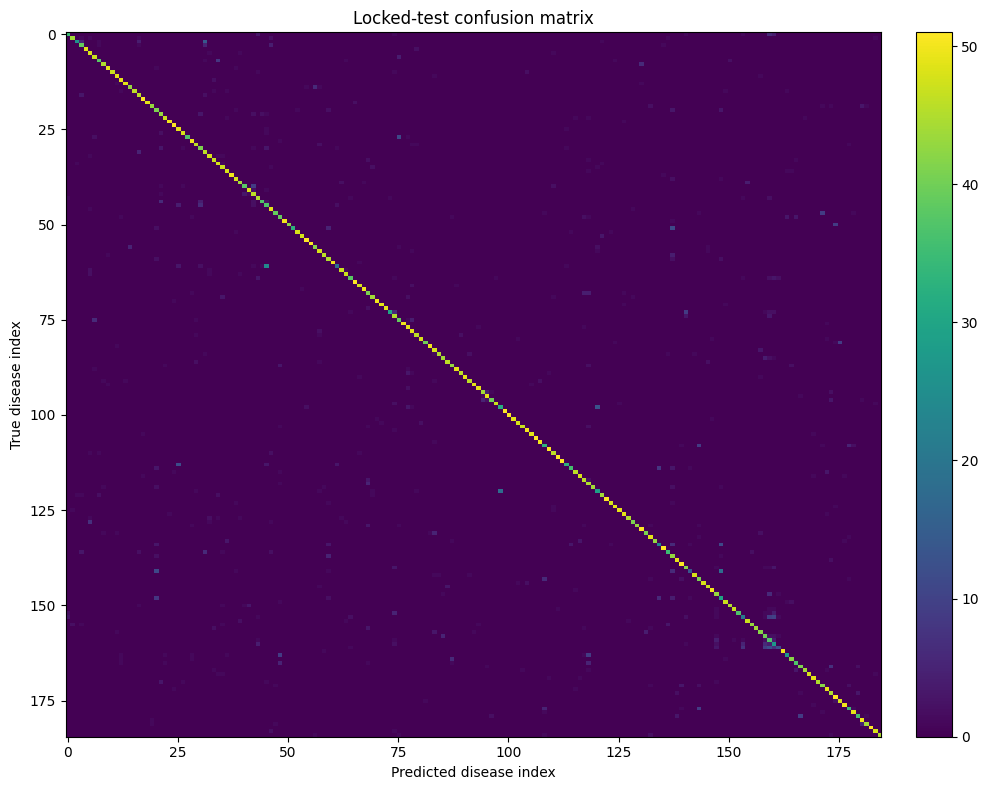

Final locked-test metrics and outputs saved.


In [29]:
# ============================================================
# FINAL LOCKED-TEST METRICS — FLAT PUBMEDBERT
# ============================================================

import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    log_loss,
)


# ------------------------------------------------------------
# 1. Core classification metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions,
)

test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0,
)

test_weighted_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0,
)

test_precision_macro = precision_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0,
)

test_recall_macro = recall_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0,
)


# ------------------------------------------------------------
# 2. Top-3 accuracy
# ------------------------------------------------------------

top_k_for_test = min(
    3,
    NUM_DISEASES,
)

top_k_indices = np.argsort(
    -test_calibrated_probs,
    axis=1,
)[:, :top_k_for_test]

test_topk_accuracy = float(
    np.mean(
        [
            test_true_labels[row_index]
            in top_k_indices[row_index]
            for row_index in range(
                len(test_true_labels)
            )
        ]
    )
)


# ------------------------------------------------------------
# 3. Calibration metrics
# ------------------------------------------------------------

test_nll = log_loss(
    test_true_labels,
    np.clip(
        test_calibrated_probs,
        1e-12,
        1.0,
    ),
    labels=list(
        range(NUM_DISEASES)
    ),
)

one_hot_true = np.zeros_like(
    test_calibrated_probs
)

one_hot_true[
    np.arange(
        len(test_true_labels)
    ),
    test_true_labels,
] = 1.0

test_brier = float(
    np.mean(
        np.sum(
            (
                test_calibrated_probs
                - one_hot_true
            ) ** 2,
            axis=1,
        )
    )
)


def expected_calibration_error(
    probabilities,
    true_labels,
    number_of_bins=20,
):
    confidences = probabilities.max(
        axis=1
    )

    predictions = probabilities.argmax(
        axis=1
    )

    accuracies = (
        predictions == true_labels
    ).astype(np.float64)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    ece = 0.0
    number_of_rows = len(
        true_labels
    )

    for lower_bound, upper_bound in zip(
        bin_edges[:-1],
        bin_edges[1:],
    ):

        if lower_bound == 0.0:
            bin_mask = (
                confidences >= lower_bound
            ) & (
                confidences <= upper_bound
            )
        else:
            bin_mask = (
                confidences > lower_bound
            ) & (
                confidences <= upper_bound
            )

        if bin_mask.sum() == 0:
            continue

        bin_confidence = float(
            confidences[
                bin_mask
            ].mean()
        )

        bin_accuracy = float(
            accuracies[
                bin_mask
            ].mean()
        )

        ece += (
            bin_mask.sum()
            / number_of_rows
        ) * abs(
            bin_accuracy
            - bin_confidence
        )

    return float(ece)


test_ece = expected_calibration_error(
    test_calibrated_probs,
    test_true_labels,
)


# ------------------------------------------------------------
# 4. Mondrian conformal metrics
# ------------------------------------------------------------

test_conformal_sets = build_prediction_sets(
    test_calibrated_probs
)

test_conformal_covered = [
    test_true_labels[row_index]
    in test_conformal_sets[row_index]
    for row_index in range(
        len(test_true_labels)
    )
]

test_conformal_coverage = float(
    np.mean(
        test_conformal_covered
    )
)

test_conformal_set_sizes = np.asarray(
    [
        len(prediction_set)
        for prediction_set
        in test_conformal_sets
    ],
    dtype=np.int64,
)

test_conformal_avg_set_size = float(
    test_conformal_set_sizes.mean()
)

test_conformal_median_set_size = float(
    np.median(
        test_conformal_set_sizes
    )
)


# ------------------------------------------------------------
# 5. Confidence-based uncertainty summaries
#
# EDL has been removed, so use entropy and confidence instead.
# ------------------------------------------------------------

clipped_test_probs = np.clip(
    test_calibrated_probs,
    1e-12,
    1.0,
)

test_predictive_entropy = -np.sum(
    clipped_test_probs
    * np.log(
        clipped_test_probs
    ),
    axis=1,
)

test_max_confidence = (
    test_calibrated_probs.max(
        axis=1
    )
)

sorted_test_probs = np.sort(
    test_calibrated_probs,
    axis=1,
)

test_probability_margin = (
    sorted_test_probs[:, -1]
    - sorted_test_probs[:, -2]
)


# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

test_confusion = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=np.arange(
        NUM_DISEASES
    ),
)


# ------------------------------------------------------------
# 7. Final metric dictionary
# ------------------------------------------------------------

final_test_metrics = {
    "source_model": "flat PubMedBERT",
    "number_of_test_rows": int(
        len(test_true_labels)
    ),
    "accuracy": float(
        test_accuracy
    ),
    "macro_f1": float(
        test_macro_f1
    ),
    "weighted_f1": float(
        test_weighted_f1
    ),
    "precision_macro": float(
        test_precision_macro
    ),
    "recall_macro": float(
        test_recall_macro
    ),
    "top3_accuracy": float(
        test_topk_accuracy
    ),
    "calibration": {
        "temperature": float(
            LEARNED_TEMPERATURE
        ),
        "ece": float(
            test_ece
        ),
        "nll": float(
            test_nll
        ),
        "brier_score": float(
            test_brier
        ),
    },
    "uncertainty": {
        "mean_predictive_entropy": float(
            np.mean(
                test_predictive_entropy
            )
        ),
        "mean_max_confidence": float(
            np.mean(
                test_max_confidence
            )
        ),
        "mean_probability_margin": float(
            np.mean(
                test_probability_margin
            )
        ),
    },
    "mondrian_conformal": {
        "alpha": float(
            alpha_level
        ),
        "coverage": float(
            test_conformal_coverage
        ),
        "average_set_size": float(
            test_conformal_avg_set_size
        ),
        "median_set_size": float(
            test_conformal_median_set_size
        ),
    },
}


print("=" * 80)
print("LOCKED TEST — FINAL FLAT MODEL METRICS")
print("=" * 80)

print(
    json.dumps(
        final_test_metrics,
        indent=2,
    )
)


# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------

with open(
    DIRS["results"]
    / "final_test_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_test_metrics,
        file,
        indent=2,
    )

np.save(
    DIRS["results"]
    / "final_test_logits.npy",
    test_logits,
)

np.save(
    DIRS["results"]
    / "final_test_calibrated_probs.npy",
    test_calibrated_probs,
)

np.save(
    DIRS["results"]
    / "final_test_predictions.npy",
    test_predictions,
)

np.save(
    DIRS["results"]
    / "final_test_true_labels.npy",
    test_true_labels,
)

np.save(
    DIRS["results"]
    / "final_test_confusion_matrix.npy",
    test_confusion,
)


# ------------------------------------------------------------
# 9. Confusion-matrix plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    test_confusion,
    aspect="auto",
)

plt.title(
    "Locked-test confusion matrix"
)

plt.xlabel(
    "Predicted disease index"
)

plt.ylabel(
    "True disease index"
)

plt.colorbar(
    fraction=0.046,
    pad=0.04,
)

plt.tight_layout()

plt.savefig(
    DIRS["plots"]
    / "final_test_confusion_matrix.png",
    dpi=200,
)

plt.show()

print(
    "Final locked-test metrics and outputs saved."
)

In [30]:
# ============================================================
# LOCKED-TEST CLASSIFICATION METRICS
# Accuracy, Precision, Recall, F1, Cohen's Kappa, MCC
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
)

locked_test_true_labels = np.asarray(test_true_labels, dtype=np.int64).reshape(-1)
locked_test_predictions = np.asarray(test_predictions, dtype=np.int64).reshape(-1)

# 1. Accuracy
test_accuracy = accuracy_score(locked_test_true_labels, locked_test_predictions)
test_balanced_accuracy = balanced_accuracy_score(locked_test_true_labels, locked_test_predictions)

# 2. Precision
test_precision_macro = precision_score(locked_test_true_labels, locked_test_predictions, average="macro", zero_division=0)
test_precision_weighted = precision_score(locked_test_true_labels, locked_test_predictions, average="weighted", zero_division=0)

# 3. Recall
test_recall_macro = recall_score(locked_test_true_labels, locked_test_predictions, average="macro", zero_division=0)
test_recall_weighted = recall_score(locked_test_true_labels, locked_test_predictions, average="weighted", zero_division=0)

# 4. F1-score
test_f1_macro = f1_score(locked_test_true_labels, locked_test_predictions, average="macro", zero_division=0)
test_f1_weighted = f1_score(locked_test_true_labels, locked_test_predictions, average="weighted", zero_division=0)

# 5. Cohen's Kappa
test_cohen_kappa = cohen_kappa_score(locked_test_true_labels, locked_test_predictions)

# 6. MCC
test_mcc = matthews_corrcoef(locked_test_true_labels, locked_test_predictions)

print("Locked-test Accuracy:", f"{test_accuracy:.4f}")
print("Locked-test Balanced Accuracy:", f"{test_balanced_accuracy:.4f}")
print("Locked-test Precision (macro):", f"{test_precision_macro:.4f}")
print("Locked-test Precision (weighted):", f"{test_precision_weighted:.4f}")
print("Locked-test Recall (macro):", f"{test_recall_macro:.4f}")
print("Locked-test Recall (weighted):", f"{test_recall_weighted:.4f}")
print("Locked-test F1-score (macro):", f"{test_f1_macro:.4f}")
print("Locked-test F1-score (weighted):", f"{test_f1_weighted:.4f}")
print("Locked-test Cohen's Kappa:", f"{test_cohen_kappa:.4f}")
print("Locked-test MCC:", f"{test_mcc:.4f}")

import json

locked_test_summary_metrics = {
    "accuracy": float(test_accuracy),
    "balanced_accuracy": float(test_balanced_accuracy),
    "precision_macro": float(test_precision_macro),
    "precision_weighted": float(test_precision_weighted),
    "recall_macro": float(test_recall_macro),
    "recall_weighted": float(test_recall_weighted),
    "f1_macro": float(test_f1_macro),
    "f1_weighted": float(test_f1_weighted),
    "cohen_kappa": float(test_cohen_kappa),
    "mcc": float(test_mcc),
}

with open(DIRS["results"] / "locked_test_summary_metrics.json", "w") as f:
    json.dump(locked_test_summary_metrics, f, indent=2)

print("\nSaved to:", DIRS["results"] / "locked_test_summary_metrics.json")
print("\nSummary:")
for name, value in locked_test_summary_metrics.items():
    print(f"  {name:22s}: {value:.4f}")

Locked-test Accuracy: 0.8688
Locked-test Balanced Accuracy: 0.8688
Locked-test Precision (macro): 0.8817
Locked-test Precision (weighted): 0.8817
Locked-test Recall (macro): 0.8688
Locked-test Recall (weighted): 0.8688
Locked-test F1-score (macro): 0.8687
Locked-test F1-score (weighted): 0.8687
Locked-test Cohen's Kappa: 0.8681
Locked-test MCC: 0.8682

Saved to: /kaggle/working/reliable_disease_framework/results/locked_test_summary_metrics.json

Summary:
  accuracy              : 0.8688
  balanced_accuracy     : 0.8688
  precision_macro       : 0.8817
  precision_weighted    : 0.8817
  recall_macro          : 0.8688
  recall_weighted       : 0.8688
  f1_macro              : 0.8687
  f1_weighted           : 0.8687
  cohen_kappa           : 0.8681
  mcc                   : 0.8682


In [31]:
# ============================================================
# MODULE 14A — MONDRIAN SET CARDINALITY ANALYSIS
#
# Purpose:
# - Evaluate treatment-retrieval gate before actual retrieval
#
# Final gating policy:
#   Empty set     -> no retrieval
#   Singleton set -> allow retrieval for singleton disease
#   Multiple set  -> no retrieval
#
# Uses already frozen locked-test outputs.
# It does NOT tune or modify the model.
#
#     uncertainty = 1 - top1_calibrated_probability
# This is NOT true evidential/Dirichlet uncertainty -- it is a
# simple confidence-complement derived from the flat model's
# temperature-calibrated softmax output.
# ============================================================

import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "test_calibrated_probs",
    "test_predictions",
    "test_true_labels",
    "class_thresholds",
    "test_locked_df",
    "index_to_disease",
    "CONFIG",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------
# 1a. SOFTMAX-BASED UNCERTAINTY (replaces EDL uncertainty)
#
# uncertainty = 1 - top1_calibrated_probability
# Higher value => less confident / more uncertain.
# ------------------------------------------------------------

test_edl_uncertainty = 1.0 - np.asarray(
    test_calibrated_probs,
    dtype=np.float64,
).max(axis=1)


# ------------------------------------------------------------
# 2. Prepare arrays
# ------------------------------------------------------------

probabilities = np.asarray(
    test_calibrated_probs,
    dtype=np.float64,
)

predictions = np.asarray(
    test_predictions,
    dtype=np.int64,
).reshape(-1)

true_labels = np.asarray(
    test_true_labels,
    dtype=np.int64,
).reshape(-1)

edl_uncertainty = np.asarray(
    test_edl_uncertainty,
    dtype=np.float64,
).reshape(-1)


if probabilities.ndim != 2:
    raise RuntimeError(
        "test_calibrated_probs must be a 2D matrix."
    )


number_of_rows, number_of_classes = (
    probabilities.shape
)


if len(predictions) != number_of_rows:
    raise RuntimeError(
        "test_predictions length does not match "
        "test_calibrated_probs."
    )

if len(true_labels) != number_of_rows:
    raise RuntimeError(
        "test_true_labels length does not match "
        "test_calibrated_probs."
    )

if len(edl_uncertainty) != number_of_rows:
    raise RuntimeError(
        "test_edl_uncertainty length does not match "
        "test_calibrated_probs."
    )

if len(test_locked_df) != number_of_rows:
    raise RuntimeError(
        "test_locked_df length does not match "
        "test_calibrated_probs."
    )

if number_of_classes != len(index_to_disease):
    raise RuntimeError(
        "Number of probability columns does not match "
        "index_to_disease."
    )


if not np.isfinite(
    probabilities
).all():
    raise RuntimeError(
        "test_calibrated_probs contains NaN or infinity."
    )


if not np.allclose(
    probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
):
    raise RuntimeError(
        "Calibrated probability rows do not sum to 1."
    )


if not np.isfinite(
    edl_uncertainty
).all():
    raise RuntimeError(
        "test_edl_uncertainty contains NaN or infinity."
    )


# ------------------------------------------------------------
# 3. Convert Mondrian thresholds to one array
#
# Nonconformity score:
#   score(x, c) = 1 - P(c | x)
#
# Include class c when:
#   score(x, c) <= threshold[c]
# ------------------------------------------------------------

if isinstance(
    class_thresholds,
    dict,
):

    threshold_array = np.empty(
        number_of_classes,
        dtype=np.float64,
    )

    for class_index in range(
        number_of_classes
    ):

        possible_keys = [
            class_index,
            str(class_index),
            index_to_disease[class_index],
            str(index_to_disease[class_index]),
        ]

        matched_key = None

        for key in possible_keys:

            if key in class_thresholds:
                matched_key = key
                break

        if matched_key is None:
            raise KeyError(
                "No Mondrian threshold found for class "
                f"{class_index}: "
                f"{index_to_disease[class_index]}"
            )

        threshold_array[
            class_index
        ] = float(
            class_thresholds[
                matched_key
            ]
        )

else:

    threshold_array = np.asarray(
        class_thresholds,
        dtype=np.float64,
    ).reshape(-1)


if len(threshold_array) != number_of_classes:
    raise RuntimeError(
        "Number of Mondrian thresholds does not match "
        f"number of diseases: "
        f"{len(threshold_array)} vs "
        f"{number_of_classes}"
    )


if not np.isfinite(
    threshold_array
).all():
    raise RuntimeError(
        "class_thresholds contains non-finite values."
    )


# ------------------------------------------------------------
# 4. Generate Mondrian prediction sets
# ------------------------------------------------------------

test_nonconformity_scores = (
    1.0 - probabilities
)


test_mondrian_inclusion = (
    test_nonconformity_scores
    <= threshold_array.reshape(
        1,
        -1,
    )
)


test_mondrian_set_sizes = (
    test_mondrian_inclusion
    .sum(axis=1)
    .astype(np.int64)
)


test_mondrian_sets = [
    np.where(
        test_mondrian_inclusion[
            row_index
        ]
    )[0].astype(np.int64)

    for row_index in range(
        number_of_rows
    )
]


# ------------------------------------------------------------
# 5. Row-level indicators
# ------------------------------------------------------------

row_indices = np.arange(
    number_of_rows
)


top1_confidence = probabilities[
    row_indices,
    predictions,
]


prediction_correct = (
    predictions
    == true_labels
)


top1_in_conformal_set = (
    test_mondrian_inclusion[
        row_indices,
        predictions,
    ]
)


true_label_in_conformal_set = (
    test_mondrian_inclusion[
        row_indices,
        true_labels,
    ]
)


set_group = np.select(
    [
        test_mondrian_set_sizes == 0,
        test_mondrian_set_sizes == 1,
        test_mondrian_set_sizes > 1,
    ],
    [
        "Empty set",
        "Singleton set",
        "Multiple-disease set",
    ],
    default="Unknown",
)


# ------------------------------------------------------------
# 6. Treatment-gate logic
#
# Only singleton sets are eligible for retrieval.
# The disease passed to retrieval is the SINGLETON class.
# ------------------------------------------------------------

singleton_mask = (
    test_mondrian_set_sizes
    == 1
)

multiple_mask = (
    test_mondrian_set_sizes
    > 1
)

empty_mask = (
    test_mondrian_set_sizes
    == 0
)


treatment_gate_open = (
    singleton_mask.copy()
)


singleton_class = np.full(
    number_of_rows,
    -1,
    dtype=np.int64,
)


singleton_row_indices = np.where(
    singleton_mask
)[0]


for row_index in singleton_row_indices:

    singleton_class[
        row_index
    ] = int(
        test_mondrian_sets[
            row_index
        ][0]
    )


# ------------------------------------------------------------
# 7. Singleton disease correctness
#
# IMPORTANT:
# This is NOT actual treatment retrieval accuracy.
#
# It measures whether the singleton conformal disease
# selected for retrieval is the true disease.
# ------------------------------------------------------------

singleton_disease_correct = np.full(
    number_of_rows,
    np.nan,
    dtype=np.float64,
)


singleton_disease_correct[
    singleton_mask
] = (
    singleton_class[
        singleton_mask
    ]
    ==
    true_labels[
        singleton_mask
    ]
).astype(
    np.float64
)


if singleton_mask.any():

    singleton_disease_accuracy = float(
        np.nanmean(
            singleton_disease_correct
        )
    )

    singleton_disease_error_rate = float(
        1.0
        - singleton_disease_accuracy
    )

else:

    singleton_disease_accuracy = np.nan
    singleton_disease_error_rate = np.nan


# ------------------------------------------------------------
# 8. Singleton disease names
# ------------------------------------------------------------

singleton_disease_name = np.asarray(
    [
        (
            str(
                index_to_disease[
                    singleton_class[
                        row_index
                    ]
                ]
            )
            if singleton_mask[
                row_index
            ]
            else None
        )

        for row_index in range(
            number_of_rows
        )
    ],
    dtype=object,
)


# ------------------------------------------------------------
# 9. Detailed row-level table
# ------------------------------------------------------------

cardinality_analysis_df = pd.DataFrame(
    {
        "row_index":
            row_indices,

        "set_group":
            set_group,

        "conformal_set_size":
            test_mondrian_set_sizes,

        "prediction_correct":
            prediction_correct,

        "true_label_in_set":
            true_label_in_conformal_set,

        "top1_in_set":
            top1_in_conformal_set,

        "treatment_gate_open":
            treatment_gate_open,

        "singleton_class":
            np.where(
                singleton_mask,
                singleton_class,
                np.nan,
            ),

        "singleton_disease":
            singleton_disease_name,

        "singleton_disease_correct":
            singleton_disease_correct,

        "true_disease": [
            str(
                index_to_disease[
                    int(label)
                ]
            )
            for label in true_labels
        ],

        "predicted_disease": [
            str(
                index_to_disease[
                    int(label)
                ]
            )
            for label in predictions
        ],

        "calibrated_confidence":
            top1_confidence,

        "softmax_uncertainty":
            edl_uncertainty,

        "conformal_diseases": [
            [
                str(
                    index_to_disease[
                        int(class_index)
                    ]
                )
                for class_index
                in disease_set
            ]
            for disease_set
            in test_mondrian_sets
        ],

        "patient_text": (
            test_locked_df[
                "symptom_text"
            ]
            .astype(str)
            .to_numpy()
        ),
    }
)


# ------------------------------------------------------------
# 10. Group summary
# ------------------------------------------------------------

group_order = [
    "Empty set",
    "Singleton set",
    "Multiple-disease set",
]


summary_records = []


for group_name in group_order:

    group_mask = (
        set_group
        == group_name
    )

    group_count = int(
        group_mask.sum()
    )


    if group_count == 0:

        summary_records.append(
            {
                "set_group":
                    group_name,

                "rows":
                    0,

                "percentage_of_test":
                    0.0,

                "top1_accuracy":
                    np.nan,

                "true_label_coverage":
                    np.nan,

                "top1_in_set_rate":
                    np.nan,

                "mean_set_size":
                    np.nan,

                "mean_confidence":
                    np.nan,

                "median_confidence":
                    np.nan,

                "mean_softmax_uncertainty":
                    np.nan,

                "median_softmax_uncertainty":
                    np.nan,

                "singleton_disease_accuracy":
                    np.nan,
            }
        )

        continue


    if group_name == "Singleton set":

        group_singleton_accuracy = float(
            np.nanmean(
                singleton_disease_correct[
                    group_mask
                ]
            )
        )

    else:

        group_singleton_accuracy = np.nan


    summary_records.append(
        {
            "set_group":
                group_name,

            "rows":
                group_count,

            "percentage_of_test":
                float(
                    group_count
                    / number_of_rows
                    * 100.0
                ),

            "top1_accuracy":
                float(
                    prediction_correct[
                        group_mask
                    ].mean()
                ),

            "true_label_coverage":
                float(
                    true_label_in_conformal_set[
                        group_mask
                    ].mean()
                ),

            "top1_in_set_rate":
                float(
                    top1_in_conformal_set[
                        group_mask
                    ].mean()
                ),

            "mean_set_size":
                float(
                    test_mondrian_set_sizes[
                        group_mask
                    ].mean()
                ),

            "mean_confidence":
                float(
                    top1_confidence[
                        group_mask
                    ].mean()
                ),

            "median_confidence":
                float(
                    np.median(
                        top1_confidence[
                            group_mask
                        ]
                    )
                ),

            "mean_softmax_uncertainty":
                float(
                    edl_uncertainty[
                        group_mask
                    ].mean()
                ),

            "median_softmax_uncertainty":
                float(
                    np.median(
                        edl_uncertainty[
                            group_mask
                        ]
                    )
                ),

            "singleton_disease_accuracy":
                group_singleton_accuracy,
        }
    )


conformal_cardinality_summary = (
    pd.DataFrame(
        summary_records
    )
)


# ------------------------------------------------------------
# 11. Overall cardinality + gate metrics
# ------------------------------------------------------------

singleton_rows = int(
    singleton_mask.sum()
)

empty_rows = int(
    empty_mask.sum()
)

multiple_rows = int(
    multiple_mask.sum()
)

abstained_rows = int(
    empty_rows
    + multiple_rows
)


alpha_value = float(
    CONFIG[
        "conformal_alpha"
    ]
)


overall_cardinality_results = {

    "number_of_test_rows":
        int(
            number_of_rows
        ),

    "mondrian_nominal_alpha":
        alpha_value,

    "empirical_mondrian_coverage":
        float(
            true_label_in_conformal_set.mean()
        ),

    "average_prediction_set_size":
        float(
            test_mondrian_set_sizes.mean()
        ),

    "median_prediction_set_size":
        float(
            np.median(
                test_mondrian_set_sizes
            )
        ),

    "empty_set_rows":
        empty_rows,

    "empty_set_rate":
        float(
            empty_mask.mean()
        ),

    "singleton_set_rows":
        singleton_rows,

    "singleton_set_rate":
        float(
            singleton_mask.mean()
        ),

    "multiple_set_rows":
        multiple_rows,

    "multiple_set_rate":
        float(
            multiple_mask.mean()
        ),

    "treatment_gate_open_rows":
        singleton_rows,

    "treatment_gate_open_rate":
        float(
            treatment_gate_open.mean()
        ),

    "abstained_rows":
        abstained_rows,

    "abstention_rate_total":
        float(
            (
                ~treatment_gate_open
            ).mean()
        ),

    "singleton_disease_accuracy":
        singleton_disease_accuracy,

    "singleton_disease_error_rate":
        singleton_disease_error_rate,

    "top1_accuracy_among_singleton_cases":
        (
            float(
                prediction_correct[
                    singleton_mask
                ].mean()
            )
            if singleton_mask.any()
            else np.nan
        ),
}


# ------------------------------------------------------------
# 12. Internal consistency checks
# ------------------------------------------------------------

if (
    empty_rows
    + singleton_rows
    + multiple_rows
    != number_of_rows
):

    raise RuntimeError(
        "Empty + singleton + multiple counts "
        "do not equal locked-test size."
    )


rate_sum = (
    overall_cardinality_results[
        "empty_set_rate"
    ]
    +
    overall_cardinality_results[
        "singleton_set_rate"
    ]
    +
    overall_cardinality_results[
        "multiple_set_rate"
    ]
)


if not np.isclose(
    rate_sum,
    1.0,
    atol=1e-12,
):

    raise RuntimeError(
        "Empty/singleton/multiple rates "
        "do not sum to 1."
    )


# For singleton sets:
# true label is in set iff singleton class is true class.

if singleton_mask.any():

    singleton_true_label_coverage = float(
        true_label_in_conformal_set[
            singleton_mask
        ].mean()
    )

    if not np.isclose(
        singleton_true_label_coverage,
        singleton_disease_accuracy,
        atol=1e-12,
    ):

        raise RuntimeError(
            "Singleton disease accuracy does not match "
            "singleton true-label coverage."
        )


# ------------------------------------------------------------
# 13. Print results
# ------------------------------------------------------------

print("=" * 80)

print(
    "MODULE 14A — MONDRIAN SET "
    "CARDINALITY ANALYSIS"
)

print("=" * 80)


print(
    json.dumps(
        overall_cardinality_results,
        indent=2,
    )
)


print(
    "\nPerformance by conformal set cardinality:"
)

display(
    conformal_cardinality_summary
)


# ------------------------------------------------------------
# 14. Reliability by set cardinality
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 80
)

print(
    "RELIABILITY BY SET CARDINALITY"
)

print("=" * 80)


if singleton_mask.any():

    print(
        "Singleton-set disease accuracy:",
        f"{singleton_disease_accuracy:.4f}",
    )

    print(
        "Singleton-set top-1 accuracy:",
        f"{prediction_correct[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set true-label coverage:",
        f"{true_label_in_conformal_set[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set mean confidence:",
        f"{top1_confidence[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set mean softmax uncertainty:",
        f"{edl_uncertainty[singleton_mask].mean():.4f}",
    )

else:

    print(
        "No singleton prediction sets found."
    )


if multiple_mask.any():

    print(
        "\nMultiple-set top-1 accuracy:",
        f"{prediction_correct[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set true-label coverage:",
        f"{true_label_in_conformal_set[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set mean confidence:",
        f"{top1_confidence[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set mean softmax uncertainty:",
        f"{edl_uncertainty[multiple_mask].mean():.4f}",
    )

else:

    print(
        "\nNo multiple-disease prediction sets found."
    )


# ------------------------------------------------------------
# 15. Save results
# ------------------------------------------------------------

CARDINALITY_RESULTS_DIR = (
    DIRS["results"]
    / "treatment_retrieval_gate"
)


CARDINALITY_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cardinality_analysis_df.to_csv(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_per_row.csv",
    index=False,
)


conformal_cardinality_summary.to_csv(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_summary.csv",
    index=False,
)


with open(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_overall.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        overall_cardinality_results,
        file,
        indent=2,
    )


print(
    "\nModule 14A results saved successfully."
)

MODULE 14A — MONDRIAN SET CARDINALITY ANALYSIS
{
  "number_of_test_rows": 9435,
  "mondrian_nominal_alpha": 0.1,
  "empirical_mondrian_coverage": 0.8970853206147323,
  "average_prediction_set_size": 1.1844197138314785,
  "median_prediction_set_size": 1.0,
  "empty_set_rows": 300,
  "empty_set_rate": 0.03179650238473768,
  "singleton_set_rows": 7747,
  "singleton_set_rate": 0.8210916799152094,
  "multiple_set_rows": 1388,
  "multiple_set_rate": 0.147111817700053,
  "treatment_gate_open_rows": 7747,
  "treatment_gate_open_rate": 0.8210916799152094,
  "abstained_rows": 1688,
  "abstention_rate_total": 0.17890832008479068,
  "singleton_disease_accuracy": 0.9452691364399122,
  "singleton_disease_error_rate": 0.05473086356008783,
  "top1_accuracy_among_singleton_cases": 0.9495288498773718
}

Performance by conformal set cardinality:


,set_group,rows,percentage_of_test,top1_accuracy,true_label_coverage,top1_in_set_rate,mean_set_size,mean_confidence,median_confidence,mean_softmax_uncertainty,median_softmax_uncertainty,singleton_disease_accuracy
0,Empty set,300,3.179650,0.700000,0.000000,0.000000,0.000000,0.803052,0.909355,0.196948,0.090645,NaN
1,Singleton set,7747,82.109168,0.949529,0.945269,0.978701,1.000000,0.968157,0.996425,0.031843,0.003575,0.945269
2,Multiple-disease set,1388,14.711182,0.454611,0.822046,0.953170,2.469741,0.563367,0.553396,0.436633,0.446604,NaN



RELIABILITY BY SET CARDINALITY
Singleton-set disease accuracy: 0.9453
Singleton-set top-1 accuracy: 0.9495
Singleton-set true-label coverage: 0.9453
Singleton-set mean confidence: 0.9682
Singleton-set mean softmax uncertainty: 0.0318

Multiple-set top-1 accuracy: 0.4546
Multiple-set true-label coverage: 0.8220
Multiple-set mean confidence: 0.5634
Multiple-set mean softmax uncertainty: 0.4366

Module 14A results saved successfully.


In [32]:
# ============================================================
# MONDRIAN CLASS-WISE COVERAGE + 95% CONFIDENCE INTERVALS
#
# Run AFTER corrected Module 14A.
#
# Reports:
# - Overall locked-test Mondrian coverage + exact 95% CI
# - Class-wise Mondrian coverage + exact 95% CI
# - Singleton conformal-disease accuracy + exact 95% CI
# - Top-1 accuracy among singleton cases as a separate diagnostic
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import binomtest


# ------------------------------------------------------------
# 1. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "test_true_labels",
    "test_predictions",
    "test_mondrian_inclusion",
    "test_mondrian_set_sizes",
    "NUM_DISEASES",
    "index_to_disease",
    "CONFIG",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------
# 2. Prepare arrays
# ------------------------------------------------------------

true_labels = np.asarray(
    test_true_labels,
    dtype=np.int64,
).reshape(-1)

predictions = np.asarray(
    test_predictions,
    dtype=np.int64,
).reshape(-1)

mondrian_inclusion = np.asarray(
    test_mondrian_inclusion,
    dtype=bool,
)

mondrian_set_sizes = np.asarray(
    test_mondrian_set_sizes,
    dtype=np.int64,
).reshape(-1)


number_of_rows = len(
    true_labels
)


if len(predictions) != number_of_rows:
    raise RuntimeError(
        "test_predictions length does not match "
        "test_true_labels."
    )

if len(mondrian_set_sizes) != number_of_rows:
    raise RuntimeError(
        "test_mondrian_set_sizes length does not match "
        "test_true_labels."
    )

if mondrian_inclusion.shape != (
    number_of_rows,
    NUM_DISEASES,
):
    raise RuntimeError(
        "Unexpected test_mondrian_inclusion shape: "
        f"{mondrian_inclusion.shape}. "
        f"Expected {(number_of_rows, NUM_DISEASES)}."
    )


# ------------------------------------------------------------
# 3. Overall Mondrian coverage
# ------------------------------------------------------------

row_indices = np.arange(
    number_of_rows
)

true_label_in_set = (
    mondrian_inclusion[
        row_indices,
        true_labels,
    ]
)


overall_covered = int(
    true_label_in_set.sum()
)

overall_total = int(
    number_of_rows
)

overall_coverage = float(
    overall_covered
    / overall_total
)


overall_ci = binomtest(
    overall_covered,
    overall_total,
).proportion_ci(
    confidence_level=0.95,
    method="exact",
)


# ------------------------------------------------------------
# 4. Singleton-set disease correctness
#
# For a singleton set:
# true label in set
#     <=>
# singleton conformal disease == true disease
#
# Therefore singleton true-label coverage is exactly the
# correctness of the disease that would be passed to retrieval.
#
# This is NOT yet actual treatment lookup accuracy.
# ------------------------------------------------------------

singleton_mask = (
    mondrian_set_sizes
    == 1
)

singleton_total = int(
    singleton_mask.sum()
)


if singleton_total > 0:

    singleton_correct = int(
        true_label_in_set[
            singleton_mask
        ].sum()
    )

    singleton_disease_accuracy = float(
        singleton_correct
        / singleton_total
    )

    singleton_ci = binomtest(
        singleton_correct,
        singleton_total,
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    # Separate diagnostic:
    # flat-model top-1 correctness among singleton cases.
    singleton_top1_correct = int(
        (
            predictions[
                singleton_mask
            ]
            ==
            true_labels[
                singleton_mask
            ]
        ).sum()
    )

    singleton_top1_accuracy = float(
        singleton_top1_correct
        / singleton_total
    )

else:

    singleton_correct = 0
    singleton_disease_accuracy = np.nan
    singleton_ci = None

    singleton_top1_correct = 0
    singleton_top1_accuracy = np.nan


# ------------------------------------------------------------
# 5. Class-wise Mondrian coverage + exact 95% CI
# ------------------------------------------------------------

class_records = []


for class_index in range(
    NUM_DISEASES
):

    class_mask = (
        true_labels
        == class_index
    )

    n_class = int(
        class_mask.sum()
    )

    if n_class == 0:
        continue


    covered_class = int(
        true_label_in_set[
            class_mask
        ].sum()
    )


    class_coverage = float(
        covered_class
        / n_class
    )


    class_ci = binomtest(
        covered_class,
        n_class,
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )


    class_records.append(
        {
            "class_index":
                int(
                    class_index
                ),

            "disease":
                str(
                    index_to_disease[
                        class_index
                    ]
                ),

            "test_samples":
                n_class,

            "covered_samples":
                covered_class,

            "class_coverage":
                class_coverage,

            "coverage_ci_low":
                float(
                    class_ci.low
                ),

            "coverage_ci_high":
                float(
                    class_ci.high
                ),
        }
    )


class_coverage_df = pd.DataFrame(
    class_records
)


# ------------------------------------------------------------
# 6. Class-wise summary statistics
# ------------------------------------------------------------

coverage_values = (
    class_coverage_df[
        "class_coverage"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


mean_class_coverage = float(
    coverage_values.mean()
)

median_class_coverage = float(
    np.median(
        coverage_values
    )
)

minimum_class_coverage = float(
    coverage_values.min()
)

maximum_class_coverage = float(
    coverage_values.max()
)


nominal_coverage = float(
    1.0
    - CONFIG[
        "conformal_alpha"
    ]
)


classes_meeting_nominal = int(
    np.sum(
        coverage_values
        >= nominal_coverage
    )
)


classes_below_nominal = int(
    np.sum(
        coverage_values
        < nominal_coverage
    )
)


percentage_classes_meeting_nominal = float(
    classes_meeting_nominal
    / len(
        class_coverage_df
    )
    * 100.0
)


# ------------------------------------------------------------
# 7. Internal consistency checks
# ------------------------------------------------------------

if (
    classes_meeting_nominal
    + classes_below_nominal
    != len(class_coverage_df)
):

    raise RuntimeError(
        "Class nominal-coverage counts are inconsistent."
    )


if singleton_total > 0:

    singleton_true_label_coverage = float(
        true_label_in_set[
            singleton_mask
        ].mean()
    )

    if not np.isclose(
        singleton_true_label_coverage,
        singleton_disease_accuracy,
        atol=1e-12,
    ):

        raise RuntimeError(
            "Singleton disease accuracy does not match "
            "singleton true-label coverage."
        )


# ------------------------------------------------------------
# 8. Print paper-useful summary
# ------------------------------------------------------------

print("=" * 80)

print(
    "MONDRIAN CONFORMAL — "
    "CLASS-WISE COVERAGE SUMMARY"
)

print("=" * 80)


print(
    "Nominal coverage:",
    f"{nominal_coverage:.2%}",
)

print(
    "Overall locked-test coverage:",
    f"{overall_coverage:.4%}",
)

print(
    "Overall coverage 95% CI:",
    f"[{overall_ci.low:.4%}, "
    f"{overall_ci.high:.4%}]",
)


print()


print(
    "Mean class-wise coverage:",
    f"{mean_class_coverage:.4%}",
)

print(
    "Median class-wise coverage:",
    f"{median_class_coverage:.4%}",
)

print(
    "Minimum class-wise coverage:",
    f"{minimum_class_coverage:.4%}",
)

print(
    "Maximum class-wise coverage:",
    f"{maximum_class_coverage:.4%}",
)


print()


print(
    "Classes meeting nominal coverage:",
    f"{classes_meeting_nominal}/"
    f"{len(class_coverage_df)} "
    f"({percentage_classes_meeting_nominal:.2f}%)",
)

print(
    "Classes below nominal coverage:",
    f"{classes_below_nominal}/"
    f"{len(class_coverage_df)}",
)


print()


print(
    "Singleton cases:",
    singleton_total,
)

print(
    "Correct singleton diseases:",
    singleton_correct,
)

if singleton_total > 0:

    print(
        "Singleton disease accuracy:",
        f"{singleton_disease_accuracy:.4%}",
    )

    print(
        "Singleton disease accuracy 95% CI:",
        f"[{singleton_ci.low:.4%}, "
        f"{singleton_ci.high:.4%}]",
    )

    print(
        "Top-1 accuracy among singleton cases:",
        f"{singleton_top1_accuracy:.4%}",
    )

else:

    print(
        "No singleton prediction sets found."
    )


# ------------------------------------------------------------
# 9. Lowest/highest class-wise coverage
# ------------------------------------------------------------

print(
    "\nLowest class-wise coverage:"
)

display(
    class_coverage_df
    .sort_values(
        [
            "class_coverage",
            "disease",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .head(15)
)


print(
    "\nHighest class-wise coverage:"
)

display(
    class_coverage_df
    .sort_values(
        [
            "class_coverage",
            "disease",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .head(15)
)

MONDRIAN CONFORMAL — CLASS-WISE COVERAGE SUMMARY
Nominal coverage: 90.00%
Overall locked-test coverage: 89.7085%
Overall coverage 95% CI: [89.0778%, 90.3146%]

Mean class-wise coverage: 89.7085%
Median class-wise coverage: 92.1569%
Minimum class-wise coverage: 52.9412%
Maximum class-wise coverage: 100.0000%

Classes meeting nominal coverage: 118/185 (63.78%)
Classes below nominal coverage: 67/185

Singleton cases: 7747
Correct singleton diseases: 7323
Singleton disease accuracy: 94.5269%
Singleton disease accuracy 95% CI: [93.9970%, 95.0230%]
Top-1 accuracy among singleton cases: 94.9529%

Lowest class-wise coverage:


,class_index,disease,test_samples,covered_samples,class_coverage,coverage_ci_low,coverage_ci_high
75,75,gallstone,51,27,0.529412,0.384587,0.670700
30,30,chronic glaucoma,51,30,0.588235,0.441693,0.724157
2,2,acute bronchitis,51,34,0.666667,0.520787,0.792417
32,32,chronic otitis media,51,36,0.705882,0.561711,0.825120
152,152,seborrheic dermatitis,51,36,0.705882,0.561711,0.825120
181,181,vaginitis,51,36,0.705882,0.561711,0.825120
27,27,cholecystitis,51,37,0.725490,0.582552,0.841073
114,114,marijuana abuse,51,37,0.725490,0.582552,0.841073
117,117,muscle spasm,51,37,0.725490,0.582552,0.841073
148,148,schizophrenia,51,37,0.725490,0.582552,0.841073



Highest class-wise coverage:


,class_index,disease,test_samples,covered_samples,class_coverage,coverage_ci_low,coverage_ci_high
11,11,angina,51,51,1.000000,0.930223,1.000000
16,16,asthma,51,51,1.000000,0.930223,1.000000
45,45,corneal disorder,51,51,1.000000,0.930223,1.000000
66,66,esophagitis,51,51,1.000000,0.930223,1.000000
79,79,gastrointestinal hemorrhage,51,51,1.000000,0.930223,1.000000
101,101,injury to the arm,51,51,1.000000,0.930223,1.000000
139,139,prostatitis,51,51,1.000000,0.930223,1.000000
162,162,smoking or tobacco addiction,51,51,1.000000,0.930223,1.000000
169,169,stroke,51,51,1.000000,0.930223,1.000000
177,177,urinary tract infection,51,51,1.000000,0.930223,1.000000


In [33]:
# ============================================================
# LOCKED-TEST AUC (Multiclass ROC-AUC)
# ============================================================

import numpy as np
from sklearn.metrics import roc_auc_score

locked_test_true_labels = np.asarray(
    test_true_labels,
    dtype=np.int64,
).reshape(-1)

# ------------------------------------------------------------
# 1. Macro-averaged One-vs-Rest AUC (each class treated equally)
# ------------------------------------------------------------

test_auc_macro_ovr = roc_auc_score(
    locked_test_true_labels,
    test_calibrated_probs,
    multi_class="ovr",
    average="macro",
)

# ------------------------------------------------------------
# 2. Weighted One-vs-Rest AUC (class-size weighted)
# ------------------------------------------------------------

test_auc_weighted_ovr = roc_auc_score(
    locked_test_true_labels,
    test_calibrated_probs,
    multi_class="ovr",
    average="weighted",
)

# ------------------------------------------------------------
# 3. Macro-averaged One-vs-One AUC (pairwise, more robust
#    but slower for 185+ classes)
# ------------------------------------------------------------

test_auc_macro_ovo = roc_auc_score(
    locked_test_true_labels,
    test_calibrated_probs,
    multi_class="ovo",
    average="macro",
)

print("Locked-test AUC (macro, One-vs-Rest):", f"{test_auc_macro_ovr:.4f}")
print("Locked-test AUC (weighted, One-vs-Rest):", f"{test_auc_weighted_ovr:.4f}")
print("Locked-test AUC (macro, One-vs-One):", f"{test_auc_macro_ovo:.4f}")

# ------------------------------------------------------------
# 4. Save alongside other metrics
# ------------------------------------------------------------

import json

auc_results = {
    "auc_macro_ovr": float(test_auc_macro_ovr),
    "auc_weighted_ovr": float(test_auc_weighted_ovr),
    "auc_macro_ovo": float(test_auc_macro_ovo),
}

with open(DIRS["results"] / "locked_test_auc.json", "w") as f:
    json.dump(auc_results, f, indent=2)

print("\nSaved to:", DIRS["results"] / "locked_test_auc.json")

Locked-test AUC (macro, One-vs-Rest): 0.9995
Locked-test AUC (weighted, One-vs-Rest): 0.9995
Locked-test AUC (macro, One-vs-One): 0.9995

Saved to: /kaggle/working/reliable_disease_framework/results/locked_test_auc.json


In [34]:
# ============================================================
# LOCKED-TEST DATASET AMBIGUITY CHECK
# (same symptom_text mapped to more than one disease?)
# ============================================================

import pandas as pd

symptom_disease_df = pd.DataFrame({
    "symptom_text": test_locked_df["symptom_text"].astype(str).str.strip(),
    "true_disease": [index_to_disease[int(x)] for x in test_true_labels],
})

grouped = (
    symptom_disease_df
    .groupby("symptom_text")
    .agg(
        number_of_rows=("true_disease", "count"),
        number_of_unique_diseases=("true_disease", "nunique"),
        diseases=("true_disease", lambda x: sorted(set(x))),
    )
    .reset_index()
)

ambiguous = grouped[grouped["number_of_unique_diseases"] > 1].copy()
ambiguous = ambiguous.sort_values(
    ["number_of_unique_diseases", "number_of_rows"], ascending=False
)

print("=" * 80)
print("LOCKED-TEST AMBIGUITY CHECK")
print("=" * 80)
print("Total locked-test rows          :", len(symptom_disease_df))
print("Unique symptom texts            :", grouped.shape[0])
print("Ambiguous symptom texts         :", len(ambiguous))
print(f"Percentage ambiguous            : {100 * len(ambiguous) / grouped.shape[0]:.2f}%")

if len(ambiguous) > 0:
    print("\nAmbiguous examples (same text -> multiple diseases):")
    display(ambiguous.head(20))
else:
    print("\nNo ambiguity found -- every distinct symptom_text in the locked test set maps to exactly one disease.")

# Save
AMBIG_DIR = DIRS["results"] / "dataset_ambiguity"
AMBIG_DIR.mkdir(parents=True, exist_ok=True)
ambiguous.to_csv(AMBIG_DIR / "locked_test_ambiguous_symptom_texts.csv", index=False)
print("\nSaved to:", AMBIG_DIR / "locked_test_ambiguous_symptom_texts.csv")

LOCKED-TEST AMBIGUITY CHECK
Total locked-test rows          : 9435
Unique symptom texts            : 9047
Ambiguous symptom texts         : 344
Percentage ambiguous            : 3.80%

Ambiguous examples (same text -> multiple diseases):


,symptom_text,number_of_rows,number_of_unique_diseases,diseases
561,"abnormal appearing skin, skin lesion, skin mol...",7,7,"[hemangioma, rosacea, sebaceous cyst, seborrhe..."
6245,"delusions or hallucinations, depression, depre...",5,5,"[depression, drug abuse, personality disorder,..."
3501,"back pain, hip pain, neck pain",4,4,"[degenerative disc disease, fibromyalgia, spin..."
7079,"diminished vision, itchiness of eye, lacrimati...",4,4,"[blepharitis, chronic glaucoma, corneal disord..."
7605,"eye redness, itchiness of eye, pain in eye, sy...",4,4,"[conjunctivitis due to allergy, cornea infecti..."
69,"abnormal appearing skin, acne or pimples, irre...",3,3,"[seborrheic keratosis, skin pigmentation disor..."
95,"abnormal appearing skin, acne or pimples, itch...",3,3,"[fungal infection of the skin, rosacea, seborr..."
120,"abnormal appearing skin, acne or pimples, skin...",3,3,"[rosacea, sebaceous cyst, skin disorder]"
431,"abnormal appearing skin, irregular appearing s...",3,3,"[seborrheic dermatitis, skin cancer, skin diso..."
453,"abnormal appearing skin, irregular appearing s...",3,3,"[seborrheic keratosis, skin disorder, skin polyp]"



Saved to: /kaggle/working/reliable_disease_framework/results/dataset_ambiguity/locked_test_ambiguous_symptom_texts.csv


In [35]:
# ============================================================
# ACCURACY/RECALL/ETC AFTER EXCLUDING AMBIGUOUS SYMPTOM-TEXT ROWS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
)

analysis_df = pd.DataFrame({
    "row_index": np.arange(len(test_locked_df)),
    "symptom_text": test_locked_df["symptom_text"].astype(str).str.strip(),
    "true_label": test_true_labels,
    "predicted_label": test_predictions,
})

ambiguous_text_set = set(ambiguous["symptom_text"].astype(str).str.strip())
analysis_df["is_ambiguous_text"] = analysis_df["symptom_text"].isin(ambiguous_text_set)

unambiguous_df = analysis_df[~analysis_df["is_ambiguous_text"]].copy()

print("=" * 80)
print("UNAMBIGUOUS-SUBSET METRICS (ambiguous symptom_text rows removed)")
print("=" * 80)
print("Original locked-test rows :", len(analysis_df))
print("Removed (ambiguous) rows  :", len(analysis_df) - len(unambiguous_df))
print("Remaining rows            :", len(unambiguous_df))

y_true = unambiguous_df["true_label"].to_numpy(dtype=np.int64)
y_pred = unambiguous_df["predicted_label"].to_numpy(dtype=np.int64)

unamb_accuracy = accuracy_score(y_true, y_pred)
unamb_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
unamb_precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
unamb_recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
unamb_f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
unamb_cohen_kappa = cohen_kappa_score(y_true, y_pred)
unamb_mcc = matthews_corrcoef(y_true, y_pred)

print("\nAccuracy (unambiguous subset)          :", f"{unamb_accuracy:.4f}")
print("Balanced Accuracy (unambiguous subset)  :", f"{unamb_balanced_accuracy:.4f}")
print("Precision macro (unambiguous subset)    :", f"{unamb_precision_macro:.4f}")
print("Recall macro (unambiguous subset)       :", f"{unamb_recall_macro:.4f}")
print("F1 macro (unambiguous subset)           :", f"{unamb_f1_macro:.4f}")
print("Cohen's Kappa (unambiguous subset)      :", f"{unamb_cohen_kappa:.4f}")
print("MCC (unambiguous subset)                :", f"{unamb_mcc:.4f}")

comparison_df = pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro", "cohen_kappa", "mcc"],
    "full_locked_test": [
        test_accuracy, test_balanced_accuracy, test_precision_macro,
        test_recall_macro, test_f1_macro, test_cohen_kappa, test_mcc,
    ],
    "unambiguous_subset": [
        unamb_accuracy, unamb_balanced_accuracy, unamb_precision_macro,
        unamb_recall_macro, unamb_f1_macro, unamb_cohen_kappa, unamb_mcc,
    ],
})

comparison_df["difference"] = comparison_df["unambiguous_subset"] - comparison_df["full_locked_test"]

print("\nComparison: full locked-test vs unambiguous subset")
display(comparison_df)

AMBIG_DIR = DIRS["results"] / "dataset_ambiguity"
AMBIG_DIR.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(AMBIG_DIR / "accuracy_with_vs_without_ambiguous_rows.csv", index=False)
print("\nSaved to:", AMBIG_DIR / "accuracy_with_vs_without_ambiguous_rows.csv")

UNAMBIGUOUS-SUBSET METRICS (ambiguous symptom_text rows removed)
Original locked-test rows : 9435
Removed (ambiguous) rows  : 732
Remaining rows            : 8703

Accuracy (unambiguous subset)          : 0.9132
Balanced Accuracy (unambiguous subset)  : 0.9070
Precision macro (unambiguous subset)    : 0.9120
Recall macro (unambiguous subset)       : 0.9070
F1 macro (unambiguous subset)           : 0.9059
Cohen's Kappa (unambiguous subset)      : 0.9128
MCC (unambiguous subset)                : 0.9128

Comparison: full locked-test vs unambiguous subset


,metric,full_locked_test,unambiguous_subset,difference
0,accuracy,0.868786,0.913248,0.044462
1,balanced_accuracy,0.868786,0.907041,0.038254
2,precision_macro,0.881738,0.912000,0.030262
3,recall_macro,0.868786,0.907041,0.038254
4,f1_macro,0.868697,0.905925,0.037229
5,cohen_kappa,0.868073,0.912773,0.044700
6,mcc,0.868155,0.912806,0.044651



Saved to: /kaggle/working/reliable_disease_framework/results/dataset_ambiguity/accuracy_with_vs_without_ambiguous_rows.csv


In [36]:
# Ambiguous cases বাদ দেওয়ার পর — ROC-AUC (macro, OvR), PR-AUC (macro, OvR),
# এবং Top-3 Accuracy — locked test set-এর unambiguous subset-এ

import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# unambiguous_df তোমার notebook-এ আগেই বানানো হয়েছে (ambiguous rows বাদ দিয়ে)
# row_index দিয়ে সেই একই sample-গুলোর probability বের করছি

unambiguous_row_indices = unambiguous_df["row_index"].to_numpy()

y_true_unamb = unambiguous_df["true_label"].to_numpy(dtype=np.int64)
probs_unamb = test_calibrated_probs[unambiguous_row_indices]  # (N_unamb, NUM_DISEASES)

print("Unambiguous subset size:", len(y_true_unamb))
print("Number of disease classes:", NUM_DISEASES)

# ---- 1. Top-3 Accuracy ----
top3_preds = np.argsort(probs_unamb, axis=1)[:, -3:]  # প্রতিটা sample-এর top-3 predicted class
top3_correct = np.any(top3_preds == y_true_unamb[:, None], axis=1)
top3_accuracy = top3_correct.mean()

print(f"\nTop-3 Accuracy (unambiguous subset): {top3_accuracy:.4f}")

# ---- 2. ROC-AUC (macro, One-vs-Rest) ----
y_true_binarized = label_binarize(y_true_unamb, classes=np.arange(NUM_DISEASES))

# কিছু disease class হয়তো unambiguous subset-এ একদমই না থাকতে পারে (0 positive sample)
# সেগুলো বাদ দিয়ে হিসাব করছি, নাহলে sklearn error দেবে
present_classes_mask = y_true_binarized.sum(axis=0) > 0
n_present_classes = present_classes_mask.sum()

if n_present_classes < NUM_DISEASES:
    print(f"\nNote: {NUM_DISEASES - n_present_classes} disease class(es) have zero samples "
          f"in the unambiguous subset — excluded from ROC-AUC/PR-AUC macro averaging.")

roc_auc_macro = roc_auc_score(
    y_true_binarized[:, present_classes_mask],
    probs_unamb[:, present_classes_mask],
    average="macro",
    multi_class="ovr",
)

print(f"ROC-AUC (macro, OvR, unambiguous subset): {roc_auc_macro:.4f}")

# ---- 3. PR-AUC (macro, One-vs-Rest) ----
pr_auc_macro = average_precision_score(
    y_true_binarized[:, present_classes_mask],
    probs_unamb[:, present_classes_mask],
    average="macro",
)

print(f"PR-AUC (macro, OvR, unambiguous subset): {pr_auc_macro:.4f}")

# ---- Save ----
import json

unamb_ranking_metrics = {
    "num_samples": int(len(y_true_unamb)),
    "top3_accuracy": float(top3_accuracy),
    "roc_auc_macro_ovr": float(roc_auc_macro),
    "pr_auc_macro_ovr": float(pr_auc_macro),
    "num_classes_present": int(n_present_classes),
    "num_classes_total": int(NUM_DISEASES),
}

with open(DIRS["results"] / "unambiguous_subset_ranking_metrics.json", "w") as f:
    json.dump(unamb_ranking_metrics, f, indent=2)

print("\nSaved to:", DIRS["results"] / "unambiguous_subset_ranking_metrics.json")

Unambiguous subset size: 8703
Number of disease classes: 185

Top-3 Accuracy (unambiguous subset): 0.9891
ROC-AUC (macro, OvR, unambiguous subset): 0.9998
PR-AUC (macro, OvR, unambiguous subset): 0.9606

Saved to: /kaggle/working/reliable_disease_framework/results/unambiguous_subset_ranking_metrics.json


In [37]:
# Ambiguous symptom_text গুলো আসলেই exact-identical কিনা যাচাই করা,
# নাকি symptom count/content-এ কোনো subtle পার্থক্য আছে কিনা

import pandas as pd

# ambiguous DataFrame-এ প্রতিটা group-এর সব raw row বের করে দেখাচ্ছি
verification_rows = []

for symptom_text in ambiguous["symptom_text"]:
    matching_rows = symptom_disease_df[
        symptom_disease_df["symptom_text"] == symptom_text
    ]
    
    # Symptom count (comma দিয়ে ভাগ করে, যদি symptom_text comma-separated হয়)
    symptom_count = len(symptom_text.split(","))
    
    verification_rows.append({
        "symptom_text": symptom_text,
        "symptom_count": symptom_count,
        "num_occurrences": len(matching_rows),
        "unique_diseases": sorted(matching_rows["true_disease"].unique().tolist()),
        "is_truly_identical_text": matching_rows["symptom_text"].nunique() == 1,  # সবসময় True হওয়া উচিত, যেহেতু groupby exact string-এ হয়েছে
    })

verification_df = pd.DataFrame(verification_rows)

print("=" * 80)
print("AMBIGUOUS SYMPTOM_TEXT — EXACT MATCH VERIFICATION")
print("=" * 80)
print("Total ambiguous groups:", len(verification_df))
print("\nAll groups have truly identical text (character-for-character)?",
      verification_df["is_truly_identical_text"].all())

# Symptom count-এ কোনো variation আছে কিনা (একই group-এর ভেতরে না,
# বরং বিভিন্ন ambiguous group জুড়ে কত শব্দ/symptom থাকে সেটা দেখানো)
print("\nSymptom count distribution across ambiguous texts:")
print(verification_df["symptom_count"].describe())

display(verification_df.head(20))

# Save
verification_df.to_csv(
    AMBIG_DIR / "ambiguous_symptom_text_exact_match_verification.csv",
    index=False,
)
print("\nSaved to:", AMBIG_DIR / "ambiguous_symptom_text_exact_match_verification.csv")

AMBIGUOUS SYMPTOM_TEXT — EXACT MATCH VERIFICATION
Total ambiguous groups: 344

All groups have truly identical text (character-for-character)? True

Symptom count distribution across ambiguous texts:
count    344.000000
mean       4.744186
std        1.795271
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: symptom_count, dtype: float64


,symptom_text,symptom_count,num_occurrences,unique_diseases,is_truly_identical_text
0,"abnormal appearing skin, skin lesion, skin mol...",4,7,"[hemangioma, rosacea, sebaceous cyst, seborrhe...",True
1,"delusions or hallucinations, depression, depre...",4,5,"[depression, drug abuse, personality disorder,...",True
2,"back pain, hip pain, neck pain",3,4,"[degenerative disc disease, fibromyalgia, spin...",True
3,"diminished vision, itchiness of eye, lacrimati...",5,4,"[blepharitis, chronic glaucoma, corneal disord...",True
4,"eye redness, itchiness of eye, pain in eye, sy...",4,4,"[conjunctivitis due to allergy, cornea infecti...",True
5,"abnormal appearing skin, acne or pimples, irre...",6,3,"[seborrheic keratosis, skin pigmentation disor...",True
6,"abnormal appearing skin, acne or pimples, itch...",4,3,"[fungal infection of the skin, rosacea, seborr...",True
7,"abnormal appearing skin, acne or pimples, skin...",4,3,"[rosacea, sebaceous cyst, skin disorder]",True
8,"abnormal appearing skin, irregular appearing s...",8,3,"[seborrheic dermatitis, skin cancer, skin diso...",True
9,"abnormal appearing skin, irregular appearing s...",5,3,"[seborrheic keratosis, skin disorder, skin polyp]",True



Saved to: /kaggle/working/reliable_disease_framework/results/dataset_ambiguity/ambiguous_symptom_text_exact_match_verification.csv


Saved to: /kaggle/working/reliable_disease_framework/plots/top20_ambiguous_confusion_matrix_print_ready.png


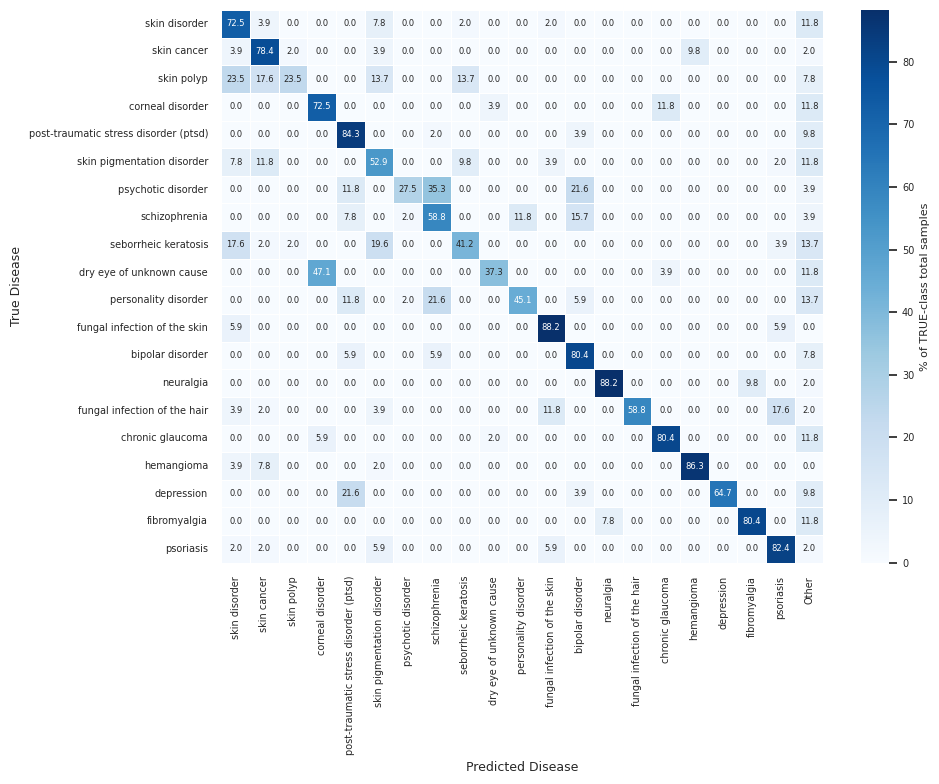

In [38]:
# Confusion Matrix - Top-20 diseases, optimized for smaller print size
# (no bold, tuned font sizes for readability at reduced scale)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

sns.set_theme(style="white")

# 1. Count how many ambiguous groups each disease appears in
disease_involvement = Counter()
for disease_list in ambiguous["diseases"]:
    for d in disease_list:
        disease_involvement[d] += 1

TOP_N = 20

top_diseases = [d for d, _ in disease_involvement.most_common(TOP_N)]
top_disease_indices = [disease_to_index[d] for d in top_diseases]

# 2. Compute row-normalized confusion matrix against FULL true-class count
n = len(top_diseases)
cm_raw = np.zeros((n, NUM_DISEASES), dtype=np.int64)

for i, true_idx in enumerate(top_disease_indices):
    true_class_mask = (test_true_labels == true_idx)
    preds_for_this_true_class = test_predictions[true_class_mask]

    for pred_idx in range(NUM_DISEASES):
        cm_raw[i, pred_idx] = (preds_for_this_true_class == pred_idx).sum()

cm_subset_counts = cm_raw[:, top_disease_indices]
row_totals = cm_raw.sum(axis=1, keepdims=True)

cm_normalized = (cm_subset_counts.astype(float) / row_totals) * 100
cm_normalized = np.nan_to_num(cm_normalized)

other_percentage = 100 - cm_normalized.sum(axis=1, keepdims=True)
other_percentage = np.clip(other_percentage, 0, 100)

cm_df = pd.DataFrame(cm_normalized, index=top_diseases, columns=top_diseases)
cm_df["Other"] = other_percentage.flatten()

# 3. Plot - print-ready size, regular (non-bold) font
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "% of TRUE-class total samples"},
    annot_kws={"size": 6},
    ax=ax,
)

ax.set_xlabel("Predicted Disease", fontsize=9)
ax.set_ylabel("True Disease", fontsize=9)

ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label("% of TRUE-class total samples", fontsize=8)

fig.tight_layout()

plot_path = DIRS["plots"] / "top20_ambiguous_confusion_matrix_print_ready.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print("Saved to:", plot_path)

plt.show()

In [39]:
# ============================================================
# PER-CLASS PRECISION, RECALL, F1-SCORE AND SUPPORT
# Locked test set
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_fscore_support
)


# All disease-class indices
class_indices = np.arange(
    len(index_to_disease)
)


# Calculate per-class metrics
(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support,
) = precision_recall_fscore_support(
    test_true_labels,
    test_predictions,
    labels=class_indices,
    average=None,
    zero_division=0,
)


# Create per-class result table
per_class_metrics_df = pd.DataFrame(
    {
        "class_index":
            class_indices,

        "disease":
            [
                str(
                    index_to_disease[
                        int(class_index)
                    ]
                )
                for class_index
                in class_indices
            ],

        "precision":
            per_class_precision,

        "recall":
            per_class_recall,

        "f1_score":
            per_class_f1,

        "support":
            per_class_support.astype(
                int
            ),
    }
)


# Sort alphabetically by disease name
per_class_metrics_df = (
    per_class_metrics_df
    .sort_values(
        "disease"
    )
    .reset_index(
        drop=True
    )
)


print(
    "=" * 90
)

print(
    "PER-CLASS LOCKED-TEST METRICS"
)

print(
    "=" * 90
)

print(
    "Number of diseases:",
    len(
        per_class_metrics_df
    )
)

print(
    "Total support:",
    int(
        per_class_metrics_df[
            "support"
        ].sum()
    )
)


display(
    per_class_metrics_df.style.format(
        {
            "precision":
                "{:.4f}",

            "recall":
                "{:.4f}",

            "f1_score":
                "{:.4f}",

            "support":
                "{:.0f}",
        }
    )
)


# Save the complete table
PER_CLASS_METRICS_PATH = (
    DIRS["results"]
    / "locked_test_per_class_metrics.csv"
)


per_class_metrics_df.to_csv(
    PER_CLASS_METRICS_PATH,
    index=False,
)


print(
    "\nSaved to:"
)

print(
    PER_CLASS_METRICS_PATH
)

PER-CLASS LOCKED-TEST METRICS
Number of diseases: 185
Total support: 9435


,class_index,disease,precision,recall,f1_score,support
0,0,actinic keratosis,0.8537,0.6863,0.7609,51
1,1,acute bronchiolitis,0.9362,0.8627,0.8980,51
2,2,acute bronchitis,0.9286,0.5098,0.6582,51
3,3,acute bronchospasm,0.7358,0.7647,0.7500,51
4,4,acute kidney injury,1.0000,0.9608,0.9800,51
5,5,acute otitis media,0.7500,0.9412,0.8348,51
6,6,acute pancreatitis,0.8393,0.9216,0.8785,51
7,7,acute sinusitis,0.8837,0.7451,0.8085,51
8,8,acute stress reaction,0.9375,0.8824,0.9091,51
9,9,alcohol withdrawal,0.9608,0.9608,0.9608,51



Saved to:
/kaggle/working/reliable_disease_framework/results/locked_test_per_class_metrics.csv


In [41]:
# ============================================================
# SOFTMAX-BASED UNCERTAINTY + ERROR-DETECTION METRICS
# FULL LOCKED TEST SET — NO SUBSET, NO EDL NAMING
#
# uncertainty = 1 - top1_calibrated_probability
# This is a softmax confidence-complement, NOT evidential/
# Dirichlet uncertainty. (EDL module was removed; this replaces
# the old test_edl_uncertainty variable name.)
# ============================================================

import json
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

# ------------------------------------------------------------
# 1. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "test_calibrated_probs",
    "test_predictions",
    "test_true_labels",
    "test_locked_df",
    "DIRS",
]

missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
    )

n_test = len(test_true_labels)
assert test_calibrated_probs.shape[0] == n_test
assert len(test_predictions) == n_test
print(f"Running on FULL locked test set: {n_test} rows (no subset)")

# ------------------------------------------------------------
# 2. Softmax-based uncertainty (renamed from EDL)
# ------------------------------------------------------------

test_softmax_uncertainty = 1.0 - np.asarray(
    test_calibrated_probs, dtype=np.float64
).max(axis=1)

pred_labels = np.asarray(test_predictions, dtype=np.int64).reshape(-1)
true_labels_arr = np.asarray(test_true_labels, dtype=np.int64).reshape(-1)

if not np.isfinite(test_softmax_uncertainty).all():
    raise RuntimeError("test_softmax_uncertainty contains NaN or infinity.")

# ------------------------------------------------------------
# 3. Binary error label: 1 = misclassified, 0 = correct
# ------------------------------------------------------------

is_correct = (pred_labels == true_labels_arr)
is_error = (~is_correct).astype(int)

number_of_errors = int(is_error.sum())
number_of_correct = int(n_test - number_of_errors)
error_prevalence = float(is_error.mean())

# ------------------------------------------------------------
# 4. AUROC / AUPRC for error detection using uncertainty
# ------------------------------------------------------------

if number_of_errors == 0 or number_of_errors == n_test:
    auroc_uncertainty = np.nan
    auprc_uncertainty = np.nan
    print("WARNING: Only one class present among correct/incorrect "
          "predictions -- AUROC/AUPRC cannot be computed.")
else:
    auroc_uncertainty = float(roc_auc_score(is_error, test_softmax_uncertainty))
    auprc_uncertainty = float(average_precision_score(is_error, test_softmax_uncertainty))

auprc_baseline = error_prevalence  # random-classifier AUPRC = error prevalence

# ------------------------------------------------------------
# 5. Mean / median uncertainty -- overall, correct, incorrect
# ------------------------------------------------------------

mean_uncertainty_overall = float(test_softmax_uncertainty.mean())
median_uncertainty_overall = float(np.median(test_softmax_uncertainty))
std_uncertainty_overall = float(test_softmax_uncertainty.std(ddof=1))

mean_uncertainty_correct = (
    float(test_softmax_uncertainty[is_correct].mean()) if number_of_correct > 0 else np.nan
)
median_uncertainty_correct = (
    float(np.median(test_softmax_uncertainty[is_correct])) if number_of_correct > 0 else np.nan
)

mean_uncertainty_incorrect = (
    float(test_softmax_uncertainty[~is_correct].mean()) if number_of_errors > 0 else np.nan
)
median_uncertainty_incorrect = (
    float(np.median(test_softmax_uncertainty[~is_correct])) if number_of_errors > 0 else np.nan
)

uncertainty_gap = mean_uncertainty_incorrect - mean_uncertainty_correct

# ------------------------------------------------------------
# 6. Assemble results
# ------------------------------------------------------------

softmax_uncertainty_results = {
    "number_of_test_rows": n_test,
    "number_of_correct_predictions": number_of_correct,
    "number_of_incorrect_predictions": number_of_errors,
    "error_prevalence": error_prevalence,

    "auroc_uncertainty_vs_error": auroc_uncertainty,
    "auprc_uncertainty_vs_error": auprc_uncertainty,
    "auprc_baseline_random": auprc_baseline,

    "mean_uncertainty_overall": mean_uncertainty_overall,
    "median_uncertainty_overall": median_uncertainty_overall,
    "std_uncertainty_overall": std_uncertainty_overall,

    "mean_uncertainty_correct": mean_uncertainty_correct,
    "median_uncertainty_correct": median_uncertainty_correct,

    "mean_uncertainty_incorrect": mean_uncertainty_incorrect,
    "median_uncertainty_incorrect": median_uncertainty_incorrect,

    "uncertainty_gap_incorrect_minus_correct": uncertainty_gap,
}

# ------------------------------------------------------------
# 7. Print results
# ------------------------------------------------------------

print("=" * 80)
print("SOFTMAX-UNCERTAINTY ERROR-DETECTION METRICS (FULL LOCKED TEST)")
print("=" * 80)
print(json.dumps(softmax_uncertainty_results, indent=2))

print("\nSummary:")
print(f"Error prevalence (base rate)       : {error_prevalence:.4f}")
print(f"AUROC (uncertainty vs error)       : {auroc_uncertainty:.4f}")
print(f"AUPRC (uncertainty vs error)       : {auprc_uncertainty:.4f}")
print(f"AUPRC baseline (random)            : {auprc_baseline:.4f}")
print(f"Mean uncertainty (overall)         : {mean_uncertainty_overall:.4f}")
print(f"Mean uncertainty (correct)         : {mean_uncertainty_correct:.4f}")
print(f"Mean uncertainty (incorrect)       : {mean_uncertainty_incorrect:.4f}")
print(f"Uncertainty gap (incorrect-correct): {uncertainty_gap:.4f}")

# ------------------------------------------------------------
# 8. Save results
# ------------------------------------------------------------

UNCERTAINTY_RESULTS_DIR = DIRS["results"] / "softmax_uncertainty"
UNCERTAINTY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(
    UNCERTAINTY_RESULTS_DIR / "softmax_uncertainty_error_detection.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(softmax_uncertainty_results, f, indent=2)

print("\nSaved to:", UNCERTAINTY_RESULTS_DIR / "softmax_uncertainty_error_detection.json")

Running on FULL locked test set: 9435 rows (no subset)
SOFTMAX-UNCERTAINTY ERROR-DETECTION METRICS (FULL LOCKED TEST)
{
  "number_of_test_rows": 9435,
  "number_of_correct_predictions": 8197,
  "number_of_incorrect_predictions": 1238,
  "error_prevalence": 0.13121356650768415,
  "auroc_uncertainty_vs_error": 0.9479382700988166,
  "auprc_uncertainty_vs_error": 0.6697933229159122,
  "auprc_baseline_random": 0.13121356650768415,
  "mean_uncertainty_overall": 0.0966418286433091,
  "median_uncertainty_overall": 0.004623055458068848,
  "std_uncertainty_overall": 0.18862255976346878,
  "mean_uncertainty_correct": 0.0483446832970321,
  "median_uncertainty_correct": 0.0037606358528137207,
  "mean_uncertainty_incorrect": 0.41642510845222075,
  "median_uncertainty_incorrect": 0.4364185631275177,
  "uncertainty_gap_incorrect_minus_correct": 0.36808042515518863
}

Summary:
Error prevalence (base rate)       : 0.1312
AUROC (uncertainty vs error)       : 0.9479
AUPRC (uncertainty vs error)       : 0.

In [42]:
# ============================================================
# MODULE 14A — MONDRIAN SET CARDINALITY ANALYSIS
#
# Purpose:
# - Evaluate treatment-retrieval gate before actual retrieval
#
# Final gating policy:
#   Empty set     -> no retrieval
#   Singleton set -> allow retrieval for singleton disease
#   Multiple set  -> no retrieval
#
# Uses already frozen locked-test outputs.
# It does NOT tune or modify the model.
# ============================================================

import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "test_calibrated_probs",
    "test_predictions",
    "test_true_labels",
    "class_thresholds",
    "test_edl_uncertainty",
    "test_locked_df",
    "index_to_disease",
    "CONFIG",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------
# 2. Prepare arrays
# ------------------------------------------------------------

probabilities = np.asarray(
    test_calibrated_probs,
    dtype=np.float64,
)

predictions = np.asarray(
    test_predictions,
    dtype=np.int64,
).reshape(-1)

true_labels = np.asarray(
    test_true_labels,
    dtype=np.int64,
).reshape(-1)

edl_uncertainty = np.asarray(
    test_edl_uncertainty,
    dtype=np.float64,
).reshape(-1)


if probabilities.ndim != 2:
    raise RuntimeError(
        "test_calibrated_probs must be a 2D matrix."
    )


number_of_rows, number_of_classes = (
    probabilities.shape
)


if len(predictions) != number_of_rows:
    raise RuntimeError(
        "test_predictions length does not match "
        "test_calibrated_probs."
    )

if len(true_labels) != number_of_rows:
    raise RuntimeError(
        "test_true_labels length does not match "
        "test_calibrated_probs."
    )

if len(edl_uncertainty) != number_of_rows:
    raise RuntimeError(
        "test_edl_uncertainty length does not match "
        "test_calibrated_probs."
    )

if len(test_locked_df) != number_of_rows:
    raise RuntimeError(
        "test_locked_df length does not match "
        "test_calibrated_probs."
    )

if number_of_classes != len(index_to_disease):
    raise RuntimeError(
        "Number of probability columns does not match "
        "index_to_disease."
    )


if not np.isfinite(
    probabilities
).all():
    raise RuntimeError(
        "test_calibrated_probs contains NaN or infinity."
    )


if not np.allclose(
    probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
):
    raise RuntimeError(
        "Calibrated probability rows do not sum to 1."
    )


if not np.isfinite(
    edl_uncertainty
).all():
    raise RuntimeError(
        "test_edl_uncertainty contains NaN or infinity."
    )


# ------------------------------------------------------------
# 3. Convert Mondrian thresholds to one array
#
# Nonconformity score:
#   score(x, c) = 1 - P(c | x)
#
# Include class c when:
#   score(x, c) <= threshold[c]
# ------------------------------------------------------------

if isinstance(
    class_thresholds,
    dict,
):

    threshold_array = np.empty(
        number_of_classes,
        dtype=np.float64,
    )

    for class_index in range(
        number_of_classes
    ):

        possible_keys = [
            class_index,
            str(class_index),
            index_to_disease[class_index],
            str(index_to_disease[class_index]),
        ]

        matched_key = None

        for key in possible_keys:

            if key in class_thresholds:
                matched_key = key
                break

        if matched_key is None:
            raise KeyError(
                "No Mondrian threshold found for class "
                f"{class_index}: "
                f"{index_to_disease[class_index]}"
            )

        threshold_array[
            class_index
        ] = float(
            class_thresholds[
                matched_key
            ]
        )

else:

    threshold_array = np.asarray(
        class_thresholds,
        dtype=np.float64,
    ).reshape(-1)


if len(threshold_array) != number_of_classes:
    raise RuntimeError(
        "Number of Mondrian thresholds does not match "
        f"number of diseases: "
        f"{len(threshold_array)} vs "
        f"{number_of_classes}"
    )


if not np.isfinite(
    threshold_array
).all():
    raise RuntimeError(
        "class_thresholds contains non-finite values."
    )


# ------------------------------------------------------------
# 4. Generate Mondrian prediction sets
# ------------------------------------------------------------

test_nonconformity_scores = (
    1.0 - probabilities
)


test_mondrian_inclusion = (
    test_nonconformity_scores
    <= threshold_array.reshape(
        1,
        -1,
    )
)


test_mondrian_set_sizes = (
    test_mondrian_inclusion
    .sum(axis=1)
    .astype(np.int64)
)


test_mondrian_sets = [
    np.where(
        test_mondrian_inclusion[
            row_index
        ]
    )[0].astype(np.int64)

    for row_index in range(
        number_of_rows
    )
]


# ------------------------------------------------------------
# 5. Row-level indicators
# ------------------------------------------------------------

row_indices = np.arange(
    number_of_rows
)


top1_confidence = probabilities[
    row_indices,
    predictions,
]


prediction_correct = (
    predictions
    == true_labels
)


top1_in_conformal_set = (
    test_mondrian_inclusion[
        row_indices,
        predictions,
    ]
)


true_label_in_conformal_set = (
    test_mondrian_inclusion[
        row_indices,
        true_labels,
    ]
)


set_group = np.select(
    [
        test_mondrian_set_sizes == 0,
        test_mondrian_set_sizes == 1,
        test_mondrian_set_sizes > 1,
    ],
    [
        "Empty set",
        "Singleton set",
        "Multiple-disease set",
    ],
    default="Unknown",
)


# ------------------------------------------------------------
# 6. Treatment-gate logic
#
# Only singleton sets are eligible for retrieval.
# The disease passed to retrieval is the SINGLETON class.
# ------------------------------------------------------------

singleton_mask = (
    test_mondrian_set_sizes
    == 1
)

multiple_mask = (
    test_mondrian_set_sizes
    > 1
)

empty_mask = (
    test_mondrian_set_sizes
    == 0
)


treatment_gate_open = (
    singleton_mask.copy()
)


singleton_class = np.full(
    number_of_rows,
    -1,
    dtype=np.int64,
)


singleton_row_indices = np.where(
    singleton_mask
)[0]


for row_index in singleton_row_indices:

    singleton_class[
        row_index
    ] = int(
        test_mondrian_sets[
            row_index
        ][0]
    )


# ------------------------------------------------------------
# 7. Singleton disease correctness
#
# IMPORTANT:
# This is NOT actual treatment retrieval accuracy.
#
# It measures whether the singleton conformal disease
# selected for retrieval is the true disease.
# ------------------------------------------------------------

singleton_disease_correct = np.full(
    number_of_rows,
    np.nan,
    dtype=np.float64,
)


singleton_disease_correct[
    singleton_mask
] = (
    singleton_class[
        singleton_mask
    ]
    ==
    true_labels[
        singleton_mask
    ]
).astype(
    np.float64
)


if singleton_mask.any():

    singleton_disease_accuracy = float(
        np.nanmean(
            singleton_disease_correct
        )
    )

    singleton_disease_error_rate = float(
        1.0
        - singleton_disease_accuracy
    )

else:

    singleton_disease_accuracy = np.nan
    singleton_disease_error_rate = np.nan


# ------------------------------------------------------------
# 8. Singleton disease names
# ------------------------------------------------------------

singleton_disease_name = np.asarray(
    [
        (
            str(
                index_to_disease[
                    singleton_class[
                        row_index
                    ]
                ]
            )
            if singleton_mask[
                row_index
            ]
            else None
        )

        for row_index in range(
            number_of_rows
        )
    ],
    dtype=object,
)


# ------------------------------------------------------------
# 9. Detailed row-level table
# ------------------------------------------------------------

cardinality_analysis_df = pd.DataFrame(
    {
        "row_index":
            row_indices,

        "set_group":
            set_group,

        "conformal_set_size":
            test_mondrian_set_sizes,

        "prediction_correct":
            prediction_correct,

        "true_label_in_set":
            true_label_in_conformal_set,

        "top1_in_set":
            top1_in_conformal_set,

        "treatment_gate_open":
            treatment_gate_open,

        "singleton_class":
            np.where(
                singleton_mask,
                singleton_class,
                np.nan,
            ),

        "singleton_disease":
            singleton_disease_name,

        "singleton_disease_correct":
            singleton_disease_correct,

        "true_disease": [
            str(
                index_to_disease[
                    int(label)
                ]
            )
            for label in true_labels
        ],

        "predicted_disease": [
            str(
                index_to_disease[
                    int(label)
                ]
            )
            for label in predictions
        ],

        "calibrated_confidence":
            top1_confidence,

        "edl_uncertainty":
            edl_uncertainty,

        "conformal_diseases": [
            [
                str(
                    index_to_disease[
                        int(class_index)
                    ]
                )
                for class_index
                in disease_set
            ]
            for disease_set
            in test_mondrian_sets
        ],

        "patient_text": (
            test_locked_df[
                "symptom_text"
            ]
            .astype(str)
            .to_numpy()
        ),
    }
)


# ------------------------------------------------------------
# 10. Group summary
# ------------------------------------------------------------

group_order = [
    "Empty set",
    "Singleton set",
    "Multiple-disease set",
]


summary_records = []


for group_name in group_order:

    group_mask = (
        set_group
        == group_name
    )

    group_count = int(
        group_mask.sum()
    )


    if group_count == 0:

        summary_records.append(
            {
                "set_group":
                    group_name,

                "rows":
                    0,

                "percentage_of_test":
                    0.0,

                "top1_accuracy":
                    np.nan,

                "true_label_coverage":
                    np.nan,

                "top1_in_set_rate":
                    np.nan,

                "mean_set_size":
                    np.nan,

                "mean_confidence":
                    np.nan,

                "median_confidence":
                    np.nan,

                "mean_edl_uncertainty":
                    np.nan,

                "median_edl_uncertainty":
                    np.nan,

                "singleton_disease_accuracy":
                    np.nan,
            }
        )

        continue


    if group_name == "Singleton set":

        group_singleton_accuracy = float(
            np.nanmean(
                singleton_disease_correct[
                    group_mask
                ]
            )
        )

    else:

        group_singleton_accuracy = np.nan


    summary_records.append(
        {
            "set_group":
                group_name,

            "rows":
                group_count,

            "percentage_of_test":
                float(
                    group_count
                    / number_of_rows
                    * 100.0
                ),

            "top1_accuracy":
                float(
                    prediction_correct[
                        group_mask
                    ].mean()
                ),

            "true_label_coverage":
                float(
                    true_label_in_conformal_set[
                        group_mask
                    ].mean()
                ),

            "top1_in_set_rate":
                float(
                    top1_in_conformal_set[
                        group_mask
                    ].mean()
                ),

            "mean_set_size":
                float(
                    test_mondrian_set_sizes[
                        group_mask
                    ].mean()
                ),

            "mean_confidence":
                float(
                    top1_confidence[
                        group_mask
                    ].mean()
                ),

            "median_confidence":
                float(
                    np.median(
                        top1_confidence[
                            group_mask
                        ]
                    )
                ),

            "mean_edl_uncertainty":
                float(
                    edl_uncertainty[
                        group_mask
                    ].mean()
                ),

            "median_edl_uncertainty":
                float(
                    np.median(
                        edl_uncertainty[
                            group_mask
                        ]
                    )
                ),

            "singleton_disease_accuracy":
                group_singleton_accuracy,
        }
    )


conformal_cardinality_summary = (
    pd.DataFrame(
        summary_records
    )
)


# ------------------------------------------------------------
# 11. Overall cardinality + gate metrics
# ------------------------------------------------------------

singleton_rows = int(
    singleton_mask.sum()
)

empty_rows = int(
    empty_mask.sum()
)

multiple_rows = int(
    multiple_mask.sum()
)

abstained_rows = int(
    empty_rows
    + multiple_rows
)


alpha_value = float(
    CONFIG[
        "conformal_alpha"
    ]
)


overall_cardinality_results = {

    "number_of_test_rows":
        int(
            number_of_rows
        ),

    "mondrian_nominal_alpha":
        alpha_value,

    "empirical_mondrian_coverage":
        float(
            true_label_in_conformal_set.mean()
        ),

    "average_prediction_set_size":
        float(
            test_mondrian_set_sizes.mean()
        ),

    "median_prediction_set_size":
        float(
            np.median(
                test_mondrian_set_sizes
            )
        ),

    "empty_set_rows":
        empty_rows,

    "empty_set_rate":
        float(
            empty_mask.mean()
        ),

    "singleton_set_rows":
        singleton_rows,

    "singleton_set_rate":
        float(
            singleton_mask.mean()
        ),

    "multiple_set_rows":
        multiple_rows,

    "multiple_set_rate":
        float(
            multiple_mask.mean()
        ),

    "treatment_gate_open_rows":
        singleton_rows,

    "treatment_gate_open_rate":
        float(
            treatment_gate_open.mean()
        ),

    "abstained_rows":
        abstained_rows,

    "abstention_rate_total":
        float(
            (
                ~treatment_gate_open
            ).mean()
        ),

    "singleton_disease_accuracy":
        singleton_disease_accuracy,

    "singleton_disease_error_rate":
        singleton_disease_error_rate,

    "top1_accuracy_among_singleton_cases":
        (
            float(
                prediction_correct[
                    singleton_mask
                ].mean()
            )
            if singleton_mask.any()
            else np.nan
        ),
}


# ------------------------------------------------------------
# 12. Internal consistency checks
# ------------------------------------------------------------

if (
    empty_rows
    + singleton_rows
    + multiple_rows
    != number_of_rows
):

    raise RuntimeError(
        "Empty + singleton + multiple counts "
        "do not equal locked-test size."
    )


rate_sum = (
    overall_cardinality_results[
        "empty_set_rate"
    ]
    +
    overall_cardinality_results[
        "singleton_set_rate"
    ]
    +
    overall_cardinality_results[
        "multiple_set_rate"
    ]
)


if not np.isclose(
    rate_sum,
    1.0,
    atol=1e-12,
):

    raise RuntimeError(
        "Empty/singleton/multiple rates "
        "do not sum to 1."
    )


# For singleton sets:
# true label is in set iff singleton class is true class.

if singleton_mask.any():

    singleton_true_label_coverage = float(
        true_label_in_conformal_set[
            singleton_mask
        ].mean()
    )

    if not np.isclose(
        singleton_true_label_coverage,
        singleton_disease_accuracy,
        atol=1e-12,
    ):

        raise RuntimeError(
            "Singleton disease accuracy does not match "
            "singleton true-label coverage."
        )


# ------------------------------------------------------------
# 13. Print results
# ------------------------------------------------------------

print("=" * 80)

print(
    "MODULE 14A — MONDRIAN SET "
    "CARDINALITY ANALYSIS"
)

print("=" * 80)


print(
    json.dumps(
        overall_cardinality_results,
        indent=2,
    )
)


print(
    "\nPerformance by conformal set cardinality:"
)

display(
    conformal_cardinality_summary
)


# ------------------------------------------------------------
# 14. Reliability by set cardinality
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 80
)

print(
    "RELIABILITY BY SET CARDINALITY"
)

print("=" * 80)


if singleton_mask.any():

    print(
        "Singleton-set disease accuracy:",
        f"{singleton_disease_accuracy:.4f}",
    )

    print(
        "Singleton-set top-1 accuracy:",
        f"{prediction_correct[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set true-label coverage:",
        f"{true_label_in_conformal_set[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set mean confidence:",
        f"{top1_confidence[singleton_mask].mean():.4f}",
    )

    print(
        "Singleton-set mean EDL uncertainty:",
        f"{edl_uncertainty[singleton_mask].mean():.4f}",
    )

else:

    print(
        "No singleton prediction sets found."
    )


if multiple_mask.any():

    print(
        "\nMultiple-set top-1 accuracy:",
        f"{prediction_correct[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set true-label coverage:",
        f"{true_label_in_conformal_set[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set mean confidence:",
        f"{top1_confidence[multiple_mask].mean():.4f}",
    )

    print(
        "Multiple-set mean EDL uncertainty:",
        f"{edl_uncertainty[multiple_mask].mean():.4f}",
    )

else:

    print(
        "\nNo multiple-disease prediction sets found."
    )


# ------------------------------------------------------------
# 15. Save results
# ------------------------------------------------------------

CARDINALITY_RESULTS_DIR = (
    DIRS["results"]
    / "treatment_retrieval_gate"
)


CARDINALITY_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cardinality_analysis_df.to_csv(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_per_row.csv",
    index=False,
)


conformal_cardinality_summary.to_csv(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_summary.csv",
    index=False,
)


with open(
    CARDINALITY_RESULTS_DIR
    / "mondrian_cardinality_overall.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        overall_cardinality_results,
        file,
        indent=2,
    )


print(
    "\nModule 14A results saved successfully."
)

MODULE 14A — MONDRIAN SET CARDINALITY ANALYSIS
{
  "number_of_test_rows": 9435,
  "mondrian_nominal_alpha": 0.1,
  "empirical_mondrian_coverage": 0.8970853206147323,
  "average_prediction_set_size": 1.1844197138314785,
  "median_prediction_set_size": 1.0,
  "empty_set_rows": 300,
  "empty_set_rate": 0.03179650238473768,
  "singleton_set_rows": 7747,
  "singleton_set_rate": 0.8210916799152094,
  "multiple_set_rows": 1388,
  "multiple_set_rate": 0.147111817700053,
  "treatment_gate_open_rows": 7747,
  "treatment_gate_open_rate": 0.8210916799152094,
  "abstained_rows": 1688,
  "abstention_rate_total": 0.17890832008479068,
  "singleton_disease_accuracy": 0.9452691364399122,
  "singleton_disease_error_rate": 0.05473086356008783,
  "top1_accuracy_among_singleton_cases": 0.9495288498773718
}

Performance by conformal set cardinality:


,set_group,rows,percentage_of_test,top1_accuracy,true_label_coverage,top1_in_set_rate,mean_set_size,mean_confidence,median_confidence,mean_edl_uncertainty,median_edl_uncertainty,singleton_disease_accuracy
0,Empty set,300,3.179650,0.700000,0.000000,0.000000,0.000000,0.803052,0.909355,0.196948,0.090645,NaN
1,Singleton set,7747,82.109168,0.949529,0.945269,0.978701,1.000000,0.968157,0.996425,0.031843,0.003575,0.945269
2,Multiple-disease set,1388,14.711182,0.454611,0.822046,0.953170,2.469741,0.563367,0.553396,0.436633,0.446604,NaN



RELIABILITY BY SET CARDINALITY
Singleton-set disease accuracy: 0.9453
Singleton-set top-1 accuracy: 0.9495
Singleton-set true-label coverage: 0.9453
Singleton-set mean confidence: 0.9682
Singleton-set mean EDL uncertainty: 0.0318

Multiple-set top-1 accuracy: 0.4546
Multiple-set true-label coverage: 0.8220
Multiple-set mean confidence: 0.5634
Multiple-set mean EDL uncertainty: 0.4366

Module 14A results saved successfully.


In [43]:
# ============================================================
# MODULE 14A-EXT — CLASS-WISE (PER-DISEASE) BREAKDOWN
#
# Purpose:
# - Identify which diseases are driving Empty-set / Multiple-set
#   (i.e. abstention) rows, and which diseases have low singleton
#   disease accuracy.
# - Uses cardinality_analysis_df produced by Module 14A (Cell 76).
# - Does NOT modify the model, thresholds, or CONFIG.
# ============================================================

import numpy as np
import pandas as pd

required_variables = [
    "cardinality_analysis_df",
]

missing_variables = [
    name for name in required_variables if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
        + ". Run Module 14A (Cell 76) first."
    )

MIN_ROWS_PER_DISEASE = 5  # ignore diseases with too few test rows (noisy stats)

df = cardinality_analysis_df.copy()

# ------------------------------------------------------------
# 1. Per-disease aggregation (grouped by TRUE disease)
# ------------------------------------------------------------

def summarize_group(group):
    n = len(group)

    empty_rows = int((group["set_group"] == "Empty set").sum())
    singleton_rows = int((group["set_group"] == "Singleton set").sum())
    multiple_rows = int((group["set_group"] == "Multiple-disease set").sum())

    singleton_correct = group.loc[
        group["set_group"] == "Singleton set", "singleton_disease_correct"
    ]

    return pd.Series({
        "n_rows": n,
        "empty_rate": empty_rows / n,
        "singleton_rate": singleton_rows / n,
        "multiple_rate": multiple_rows / n,
        "abstention_rate": (empty_rows + multiple_rows) / n,
        "true_label_coverage": group["true_label_in_set"].mean(),
        "top1_accuracy": group["prediction_correct"].mean(),
        "singleton_disease_accuracy": (
            singleton_correct.mean() if len(singleton_correct) > 0 else np.nan
        ),
        "mean_confidence": group["calibrated_confidence"].mean(),
        "mean_edl_uncertainty": group["edl_uncertainty"].mean(),
    })

classwise_breakdown = (
    df.groupby("true_disease")
    .apply(summarize_group)
    .reset_index()
    .rename(columns={"true_disease": "disease"})
)

classwise_breakdown["n_rows"] = classwise_breakdown["n_rows"].astype(int)

# ------------------------------------------------------------
# 2. Filter out tiny classes (unreliable rates) for ranking views
# ------------------------------------------------------------

reliable_view = classwise_breakdown[
    classwise_breakdown["n_rows"] >= MIN_ROWS_PER_DISEASE
].copy()

# ------------------------------------------------------------
# 3. Worst offenders — highest abstention rate (empty + multiple)
# ------------------------------------------------------------

worst_abstention = (
    reliable_view.sort_values("abstention_rate", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Worst offenders — lowest singleton disease accuracy
#    (only diseases that actually had singleton rows)
# ------------------------------------------------------------

has_singletons = reliable_view[reliable_view["singleton_disease_accuracy"].notna()]

worst_singleton_accuracy = (
    has_singletons.sort_values("singleton_disease_accuracy", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Which OTHER diseases get confused with which TRUE disease
#    (only for incorrect predictions -> shows label overlap / confusion)
# ------------------------------------------------------------

confusion_pairs = (
    df[~df["prediction_correct"]]
    .groupby(["true_disease", "predicted_disease"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(25)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Print summaries
# ------------------------------------------------------------

print("=" * 80)
print("TOP 20 DISEASES BY ABSTENTION RATE (empty + multiple set)")
print(f"(diseases with fewer than {MIN_ROWS_PER_DISEASE} test rows excluded)")
print("=" * 80)
display(worst_abstention)

print("\n" + "=" * 80)
print("TOP 20 DISEASES BY LOWEST SINGLETON DISEASE ACCURACY")
print("=" * 80)
display(worst_singleton_accuracy)

print("\n" + "=" * 80)
print("TOP 25 MOST FREQUENT TRUE→PREDICTED CONFUSION PAIRS (errors only)")
print("=" * 80)
display(confusion_pairs)

# ------------------------------------------------------------
# 7. Save to disk (same results directory used by Module 14A)
# ------------------------------------------------------------

CARDINALITY_RESULTS_DIR = DIRS["results"] / "treatment_retrieval_gate"
CARDINALITY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

classwise_breakdown.to_csv(
    CARDINALITY_RESULTS_DIR / "mondrian_cardinality_by_disease.csv",
    index=False,
)

confusion_pairs.to_csv(
    CARDINALITY_RESULTS_DIR / "mondrian_confusion_pairs.csv",
    index=False,
)

print("\nClass-wise breakdown saved successfully.")

TOP 20 DISEASES BY ABSTENTION RATE (empty + multiple set)
(diseases with fewer than 5 test rows excluded)


,disease,n_rows,empty_rate,singleton_rate,multiple_rate,abstention_rate,true_label_coverage,top1_accuracy,singleton_disease_accuracy,mean_confidence,mean_edl_uncertainty
0,corneal disorder,51,0.000000,0.039216,0.960784,0.960784,1.000000,0.725490,1.000000,0.616361,0.383639
1,skin disorder,51,0.000000,0.039216,0.960784,0.960784,0.882353,0.725490,0.000000,0.493841,0.506159
2,skin polyp,51,0.000000,0.078431,0.921569,0.921569,0.843137,0.235294,0.250000,0.576562,0.423438
3,post-traumatic stress disorder (ptsd),51,0.000000,0.137255,0.862745,0.862745,0.823529,0.843137,0.714286,0.523991,0.476009
4,skin pigmentation disorder,51,0.000000,0.156863,0.843137,0.843137,0.941176,0.529412,0.750000,0.562346,0.437654
5,seborrheic keratosis,51,0.000000,0.156863,0.843137,0.843137,0.941176,0.411765,0.875000,0.588837,0.411163
6,schizophrenia,51,0.000000,0.176471,0.823529,0.823529,0.725490,0.588235,0.777778,0.546821,0.453179
7,pyelonephritis,51,0.039216,0.274510,0.686275,0.725490,0.960784,0.803922,1.000000,0.739553,0.260447
8,kidney stone,51,0.000000,0.333333,0.666667,0.666667,0.941176,0.647059,0.941176,0.710253,0.289747
9,dry eye of unknown cause,51,0.000000,0.352941,0.647059,0.647059,0.921569,0.372549,0.944444,0.733258,0.266742



TOP 20 DISEASES BY LOWEST SINGLETON DISEASE ACCURACY


,disease,n_rows,empty_rate,singleton_rate,multiple_rate,abstention_rate,true_label_coverage,top1_accuracy,singleton_disease_accuracy,mean_confidence,mean_edl_uncertainty
0,skin disorder,51,0.000000,0.039216,0.960784,0.960784,0.882353,0.725490,0.000000,0.493841,0.506159
1,skin polyp,51,0.000000,0.078431,0.921569,0.921569,0.843137,0.235294,0.250000,0.576562,0.423438
2,gallstone,51,0.117647,0.843137,0.039216,0.156863,0.529412,0.764706,0.627907,0.796827,0.203173
3,infectious gastroenteritis,51,0.039216,0.588235,0.372549,0.411765,0.745098,0.627451,0.666667,0.742968,0.257032
4,post-traumatic stress disorder (ptsd),51,0.000000,0.137255,0.862745,0.862745,0.823529,0.843137,0.714286,0.523991,0.476009
5,psychotic disorder,51,0.000000,0.352941,0.647059,0.647059,0.901961,0.274510,0.722222,0.590551,0.409449
6,acute bronchitis,51,0.000000,0.666667,0.333333,0.333333,0.666667,0.509804,0.735294,0.844635,0.155365
7,skin pigmentation disorder,51,0.000000,0.156863,0.843137,0.843137,0.941176,0.529412,0.750000,0.562346,0.437654
8,personality disorder,51,0.000000,0.392157,0.607843,0.607843,0.764706,0.450980,0.750000,0.581947,0.418053
9,cholecystitis,51,0.019608,0.960784,0.019608,0.039216,0.725490,0.725490,0.755102,0.923227,0.076773



TOP 25 MOST FREQUENT TRUE→PREDICTED CONFUSION PAIRS (errors only)


,true_disease,predicted_disease,count
0,dry eye of unknown cause,corneal disorder,24
1,psychotic disorder,schizophrenia,18
2,noninfectious gastroenteritis,infectious gastroenteritis,18
3,acute bronchitis,chronic obstructive pulmonary disease (copd),14
4,infectious gastroenteritis,noninfectious gastroenteritis,13
5,macular degeneration,cataract,12
6,skin polyp,skin disorder,12
7,depression,post-traumatic stress disorder (ptsd),11
8,personality disorder,schizophrenia,11
9,cholecystitis,gallstone,11



Class-wise breakdown saved successfully.


In [44]:
# ============================================================
# MONDRIAN CLASS-WISE COVERAGE + 95% CONFIDENCE INTERVALS
#
# Run AFTER corrected Module 14A.
#
# Reports:
# - Overall locked-test Mondrian coverage + exact 95% CI
# - Class-wise Mondrian coverage + exact 95% CI
# - Singleton conformal-disease accuracy + exact 95% CI
# - Top-1 accuracy among singleton cases as a separate diagnostic
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import binomtest


# ------------------------------------------------------------
# 1. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "test_true_labels",
    "test_predictions",
    "test_mondrian_inclusion",
    "test_mondrian_set_sizes",
    "NUM_DISEASES",
    "index_to_disease",
    "CONFIG",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


# ------------------------------------------------------------
# 2. Prepare arrays
# ------------------------------------------------------------

true_labels = np.asarray(
    test_true_labels,
    dtype=np.int64,
).reshape(-1)

predictions = np.asarray(
    test_predictions,
    dtype=np.int64,
).reshape(-1)

mondrian_inclusion = np.asarray(
    test_mondrian_inclusion,
    dtype=bool,
)

mondrian_set_sizes = np.asarray(
    test_mondrian_set_sizes,
    dtype=np.int64,
).reshape(-1)


number_of_rows = len(
    true_labels
)


if len(predictions) != number_of_rows:
    raise RuntimeError(
        "test_predictions length does not match "
        "test_true_labels."
    )

if len(mondrian_set_sizes) != number_of_rows:
    raise RuntimeError(
        "test_mondrian_set_sizes length does not match "
        "test_true_labels."
    )

if mondrian_inclusion.shape != (
    number_of_rows,
    NUM_DISEASES,
):
    raise RuntimeError(
        "Unexpected test_mondrian_inclusion shape: "
        f"{mondrian_inclusion.shape}. "
        f"Expected {(number_of_rows, NUM_DISEASES)}."
    )


# ------------------------------------------------------------
# 3. Overall Mondrian coverage
# ------------------------------------------------------------

row_indices = np.arange(
    number_of_rows
)

true_label_in_set = (
    mondrian_inclusion[
        row_indices,
        true_labels,
    ]
)


overall_covered = int(
    true_label_in_set.sum()
)

overall_total = int(
    number_of_rows
)

overall_coverage = float(
    overall_covered
    / overall_total
)


overall_ci = binomtest(
    overall_covered,
    overall_total,
).proportion_ci(
    confidence_level=0.95,
    method="exact",
)


# ------------------------------------------------------------
# 4. Singleton-set disease correctness
#
# For a singleton set:
# true label in set
#     <=>
# singleton conformal disease == true disease
#
# Therefore singleton true-label coverage is exactly the
# correctness of the disease that would be passed to retrieval.
#
# This is NOT yet actual treatment lookup accuracy.
# ------------------------------------------------------------

singleton_mask = (
    mondrian_set_sizes
    == 1
)

singleton_total = int(
    singleton_mask.sum()
)


if singleton_total > 0:

    singleton_correct = int(
        true_label_in_set[
            singleton_mask
        ].sum()
    )

    singleton_disease_accuracy = float(
        singleton_correct
        / singleton_total
    )

    singleton_ci = binomtest(
        singleton_correct,
        singleton_total,
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    # Separate diagnostic:
    # flat-model top-1 correctness among singleton cases.
    singleton_top1_correct = int(
        (
            predictions[
                singleton_mask
            ]
            ==
            true_labels[
                singleton_mask
            ]
        ).sum()
    )

    singleton_top1_accuracy = float(
        singleton_top1_correct
        / singleton_total
    )

else:

    singleton_correct = 0
    singleton_disease_accuracy = np.nan
    singleton_ci = None

    singleton_top1_correct = 0
    singleton_top1_accuracy = np.nan


# ------------------------------------------------------------
# 5. Class-wise Mondrian coverage + exact 95% CI
# ------------------------------------------------------------

class_records = []


for class_index in range(
    NUM_DISEASES
):

    class_mask = (
        true_labels
        == class_index
    )

    n_class = int(
        class_mask.sum()
    )

    if n_class == 0:
        continue


    covered_class = int(
        true_label_in_set[
            class_mask
        ].sum()
    )


    class_coverage = float(
        covered_class
        / n_class
    )


    class_ci = binomtest(
        covered_class,
        n_class,
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )


    class_records.append(
        {
            "class_index":
                int(
                    class_index
                ),

            "disease":
                str(
                    index_to_disease[
                        class_index
                    ]
                ),

            "test_samples":
                n_class,

            "covered_samples":
                covered_class,

            "class_coverage":
                class_coverage,

            "coverage_ci_low":
                float(
                    class_ci.low
                ),

            "coverage_ci_high":
                float(
                    class_ci.high
                ),
        }
    )


class_coverage_df = pd.DataFrame(
    class_records
)


# ------------------------------------------------------------
# 6. Class-wise summary statistics
# ------------------------------------------------------------

coverage_values = (
    class_coverage_df[
        "class_coverage"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


mean_class_coverage = float(
    coverage_values.mean()
)

median_class_coverage = float(
    np.median(
        coverage_values
    )
)

minimum_class_coverage = float(
    coverage_values.min()
)

maximum_class_coverage = float(
    coverage_values.max()
)


nominal_coverage = float(
    1.0
    - CONFIG[
        "conformal_alpha"
    ]
)


classes_meeting_nominal = int(
    np.sum(
        coverage_values
        >= nominal_coverage
    )
)


classes_below_nominal = int(
    np.sum(
        coverage_values
        < nominal_coverage
    )
)


percentage_classes_meeting_nominal = float(
    classes_meeting_nominal
    / len(
        class_coverage_df
    )
    * 100.0
)


# ------------------------------------------------------------
# 7. Internal consistency checks
# ------------------------------------------------------------

if (
    classes_meeting_nominal
    + classes_below_nominal
    != len(class_coverage_df)
):

    raise RuntimeError(
        "Class nominal-coverage counts are inconsistent."
    )


if singleton_total > 0:

    singleton_true_label_coverage = float(
        true_label_in_set[
            singleton_mask
        ].mean()
    )

    if not np.isclose(
        singleton_true_label_coverage,
        singleton_disease_accuracy,
        atol=1e-12,
    ):

        raise RuntimeError(
            "Singleton disease accuracy does not match "
            "singleton true-label coverage."
        )


# ------------------------------------------------------------
# 8. Print paper-useful summary
# ------------------------------------------------------------

print("=" * 80)

print(
    "MONDRIAN CONFORMAL — "
    "CLASS-WISE COVERAGE SUMMARY"
)

print("=" * 80)


print(
    "Nominal coverage:",
    f"{nominal_coverage:.2%}",
)

print(
    "Overall locked-test coverage:",
    f"{overall_coverage:.4%}",
)

print(
    "Overall coverage 95% CI:",
    f"[{overall_ci.low:.4%}, "
    f"{overall_ci.high:.4%}]",
)


print()


print(
    "Mean class-wise coverage:",
    f"{mean_class_coverage:.4%}",
)

print(
    "Median class-wise coverage:",
    f"{median_class_coverage:.4%}",
)

print(
    "Minimum class-wise coverage:",
    f"{minimum_class_coverage:.4%}",
)

print(
    "Maximum class-wise coverage:",
    f"{maximum_class_coverage:.4%}",
)


print()


print(
    "Classes meeting nominal coverage:",
    f"{classes_meeting_nominal}/"
    f"{len(class_coverage_df)} "
    f"({percentage_classes_meeting_nominal:.2f}%)",
)

print(
    "Classes below nominal coverage:",
    f"{classes_below_nominal}/"
    f"{len(class_coverage_df)}",
)


print()


print(
    "Singleton cases:",
    singleton_total,
)

print(
    "Correct singleton diseases:",
    singleton_correct,
)

if singleton_total > 0:

    print(
        "Singleton disease accuracy:",
        f"{singleton_disease_accuracy:.4%}",
    )

    print(
        "Singleton disease accuracy 95% CI:",
        f"[{singleton_ci.low:.4%}, "
        f"{singleton_ci.high:.4%}]",
    )

    print(
        "Top-1 accuracy among singleton cases:",
        f"{singleton_top1_accuracy:.4%}",
    )

else:

    print(
        "No singleton prediction sets found."
    )


# ------------------------------------------------------------
# 9. Lowest/highest class-wise coverage
# ------------------------------------------------------------

print(
    "\nLowest class-wise coverage:"
)

display(
    class_coverage_df
    .sort_values(
        [
            "class_coverage",
            "disease",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .head(15)
)


print(
    "\nHighest class-wise coverage:"
)

display(
    class_coverage_df
    .sort_values(
        [
            "class_coverage",
            "disease",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .head(15)
)

MONDRIAN CONFORMAL — CLASS-WISE COVERAGE SUMMARY
Nominal coverage: 90.00%
Overall locked-test coverage: 89.7085%
Overall coverage 95% CI: [89.0778%, 90.3146%]

Mean class-wise coverage: 89.7085%
Median class-wise coverage: 92.1569%
Minimum class-wise coverage: 52.9412%
Maximum class-wise coverage: 100.0000%

Classes meeting nominal coverage: 118/185 (63.78%)
Classes below nominal coverage: 67/185

Singleton cases: 7747
Correct singleton diseases: 7323
Singleton disease accuracy: 94.5269%
Singleton disease accuracy 95% CI: [93.9970%, 95.0230%]
Top-1 accuracy among singleton cases: 94.9529%

Lowest class-wise coverage:


,class_index,disease,test_samples,covered_samples,class_coverage,coverage_ci_low,coverage_ci_high
75,75,gallstone,51,27,0.529412,0.384587,0.670700
30,30,chronic glaucoma,51,30,0.588235,0.441693,0.724157
2,2,acute bronchitis,51,34,0.666667,0.520787,0.792417
32,32,chronic otitis media,51,36,0.705882,0.561711,0.825120
152,152,seborrheic dermatitis,51,36,0.705882,0.561711,0.825120
181,181,vaginitis,51,36,0.705882,0.561711,0.825120
27,27,cholecystitis,51,37,0.725490,0.582552,0.841073
114,114,marijuana abuse,51,37,0.725490,0.582552,0.841073
117,117,muscle spasm,51,37,0.725490,0.582552,0.841073
148,148,schizophrenia,51,37,0.725490,0.582552,0.841073



Highest class-wise coverage:


,class_index,disease,test_samples,covered_samples,class_coverage,coverage_ci_low,coverage_ci_high
11,11,angina,51,51,1.000000,0.930223,1.000000
16,16,asthma,51,51,1.000000,0.930223,1.000000
45,45,corneal disorder,51,51,1.000000,0.930223,1.000000
66,66,esophagitis,51,51,1.000000,0.930223,1.000000
79,79,gastrointestinal hemorrhage,51,51,1.000000,0.930223,1.000000
101,101,injury to the arm,51,51,1.000000,0.930223,1.000000
139,139,prostatitis,51,51,1.000000,0.930223,1.000000
162,162,smoking or tobacco addiction,51,51,1.000000,0.930223,1.000000
169,169,stroke,51,51,1.000000,0.930223,1.000000
177,177,urinary tract infection,51,51,1.000000,0.930223,1.000000


In [45]:
# ============================================================
# 67 DISEASES BELOW NOMINAL MONDRIAN COVERAGE — DETAILED TABLE
# Uses class_coverage_df already produced by Cell 78.
# ============================================================

import numpy as np
import pandas as pd

required_variables = ["class_coverage_df", "nominal_coverage"]
missing_variables = [v for v in required_variables if v not in globals()]
if missing_variables:
    raise RuntimeError(
        "Missing: " + ", ".join(missing_variables) + ". Run the Cell 78 first."
    )

below_nominal_df = class_coverage_df[
    class_coverage_df["class_coverage"] < nominal_coverage
].copy()

# "missed" = test samples whose true label was NOT in the conformal set
below_nominal_df["missed_samples"] = (
    below_nominal_df["test_samples"] - below_nominal_df["covered_samples"]
)

below_nominal_df = below_nominal_df.rename(
    columns={
        "test_samples": "n_test_samples",
        "covered_samples": "covered",
        "class_coverage": "coverage",
    }
)[
    ["disease", "coverage", "n_test_samples", "covered", "missed_samples",
     "coverage_ci_low", "coverage_ci_high"]
]

below_nominal_df = below_nominal_df.sort_values("coverage", ascending=True).reset_index(drop=True)

print("=" * 80)
print(f"DISEASES BELOW NOMINAL COVERAGE ({nominal_coverage:.2%}) — total: {len(below_nominal_df)}")
print("=" * 80)
display(below_nominal_df)

# sanity check against Cell 78's reported count
assert len(below_nominal_df) == classes_below_nominal, (
    f"Mismatch: found {len(below_nominal_df)} rows but Cell 78 reported "
    f"{classes_below_nominal} classes_below_nominal."
)

# ---- save ----
CARDINALITY_RESULTS_DIR = DIRS["results"] / "treatment_retrieval_gate"
CARDINALITY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

below_nominal_df.to_csv(
    CARDINALITY_RESULTS_DIR / "diseases_below_nominal_coverage.csv", index=False
)
print("\nSaved to:", CARDINALITY_RESULTS_DIR / "diseases_below_nominal_coverage.csv")

DISEASES BELOW NOMINAL COVERAGE (90.00%) — total: 67


,disease,coverage,n_test_samples,covered,missed_samples,coverage_ci_low,coverage_ci_high
0,gallstone,0.529412,51,27,24,0.384587,0.670700
1,chronic glaucoma,0.588235,51,30,21,0.441693,0.724157
2,acute bronchitis,0.666667,51,34,17,0.520787,0.792417
3,chronic otitis media,0.705882,51,36,15,0.561711,0.825120
4,seborrheic dermatitis,0.705882,51,36,15,0.561711,0.825120
...,...,...,...,...,...,...,...
62,fracture of the leg,0.882353,51,45,6,0.761324,0.955580
63,degenerative disc disease,0.882353,51,45,6,0.761324,0.955580
64,tooth disorder,0.882353,51,45,6,0.761324,0.955580
65,threatened pregnancy,0.882353,51,45,6,0.761324,0.955580



Saved to: /kaggle/working/reliable_disease_framework/results/treatment_retrieval_gate/diseases_below_nominal_coverage.csv


In [46]:
# ============================================================
# 67 DISEASES BELOW NOMINAL MONDRIAN COVERAGE — FULL TABLE
# Uses class_coverage_df already produced by Cell 78.
# ============================================================

import numpy as np
import pandas as pd

required_variables = ["class_coverage_df", "nominal_coverage"]
missing_variables = [v for v in required_variables if v not in globals()]
if missing_variables:
    raise RuntimeError(
        "Missing: " + ", ".join(missing_variables) + ". Run the Cell 78 first."
    )

below_nominal_df = class_coverage_df[
    class_coverage_df["class_coverage"] < nominal_coverage
].copy()

below_nominal_df["missed_samples"] = (
    below_nominal_df["test_samples"] - below_nominal_df["covered_samples"]
)

below_nominal_df = below_nominal_df.rename(
    columns={
        "test_samples": "n_test_samples",
        "covered_samples": "covered",
        "class_coverage": "coverage",
    }
)[
    ["disease", "coverage", "n_test_samples", "covered", "missed_samples",
     "coverage_ci_low", "coverage_ci_high"]
]

below_nominal_df = below_nominal_df.sort_values("coverage", ascending=True).reset_index(drop=True)

# sanity check
assert len(below_nominal_df) == classes_below_nominal, (
    f"Mismatch: found {len(below_nominal_df)} rows but Cell 78 reported "
    f"{classes_below_nominal} classes_below_nominal."
)

# ---- FORCE full display: no row/col truncation, no line-width wrap ----
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print("=" * 80)
print(f"DISEASES BELOW NOMINAL COVERAGE ({nominal_coverage:.2%}) — total: {len(below_nominal_df)}")
print("=" * 80)
display(below_nominal_df)

# ---- reset options back to default afterward (good practice) ----
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")
pd.reset_option("display.width")
pd.reset_option("display.max_colwidth")

# ---- save full CSV ----
CARDINALITY_RESULTS_DIR = DIRS["results"] / "treatment_retrieval_gate"
CARDINALITY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

csv_path = CARDINALITY_RESULTS_DIR / "diseases_below_nominal_coverage.csv"
below_nominal_df.to_csv(csv_path, index=False)
print("\nSaved full table (67 rows) to:", csv_path)



DISEASES BELOW NOMINAL COVERAGE (90.00%) — total: 67


,disease,coverage,n_test_samples,covered,missed_samples,coverage_ci_low,coverage_ci_high
0,gallstone,0.529412,51,27,24,0.384587,0.670700
1,chronic glaucoma,0.588235,51,30,21,0.441693,0.724157
2,acute bronchitis,0.666667,51,34,17,0.520787,0.792417
3,chronic otitis media,0.705882,51,36,15,0.561711,0.825120
4,seborrheic dermatitis,0.705882,51,36,15,0.561711,0.825120
5,vaginitis,0.705882,51,36,15,0.561711,0.825120
6,muscle spasm,0.725490,51,37,14,0.582552,0.841073
7,cholecystitis,0.725490,51,37,14,0.582552,0.841073
8,marijuana abuse,0.725490,51,37,14,0.582552,0.841073
9,spinal stenosis,0.725490,51,37,14,0.582552,0.841073



Saved full table (67 rows) to: /kaggle/working/reliable_disease_framework/results/treatment_retrieval_gate/diseases_below_nominal_coverage.csv


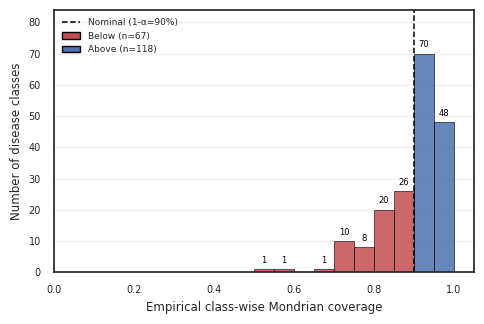

In [47]:
# ============================================================
# DISTRIBUTION OF DISEASE CLASSES BY EMPIRICAL MONDRIAN COVERAGE
# Uses class_coverage_df already produced by Cell 78.
# (No printed title/caption — figure name to be added separately.)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

required_variables = ["class_coverage_df", "nominal_coverage"]
missing_variables = [v for v in required_variables if v not in globals()]
if missing_variables:
    raise RuntimeError(
        "Missing: " + ", ".join(missing_variables) + ". Run the Cell 78 first."
    )

coverage_values = class_coverage_df["class_coverage"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(5.0, 3.4))   # <-- smaller

n_bins = 20
counts, bin_edges, patches = ax.hist(
    coverage_values,
    bins=n_bins,
    range=(0.0, 1.0),
    edgecolor="black",
    linewidth=0.5,
    color="#4C72B0",
    alpha=0.85,
)

for patch, left_edge in zip(patches, bin_edges[:-1]):
    if left_edge < nominal_coverage:
        patch.set_facecolor("#C44E52")

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
for count, center in zip(counts, bin_centers):
    if count > 0:
        ax.text(
            center, count + max(counts) * 0.02,
            f"{int(count)}",
            ha="center", va="bottom",
            fontsize=6, color="black",
        )

ax.axvline(
    x=nominal_coverage,
    color="black",
    linestyle="--",
    linewidth=1.1,
)

ax.set_xlabel("Empirical class-wise Mondrian coverage", fontsize=8.5)
ax.set_ylabel("Number of disease classes", fontsize=8.5)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, max(counts) * 1.20)
ax.set_xticks(np.linspace(0, 1, 6))
ax.tick_params(axis="both", labelsize=7)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.1,
               label=f"Nominal (1-\u03b1={nominal_coverage:.0%})"),
    Patch(facecolor="#C44E52", edgecolor="black",
          label=f"Below (n={classes_below_nominal})"),
    Patch(facecolor="#4C72B0", edgecolor="black",
          label=f"Above (n={classes_meeting_nominal})"),
]
ax.legend(handles=legend_handles, fontsize=6.5, frameon=False, loc="upper left")

plt.tight_layout()

RESULTS_FIG_DIR = DIRS["results"] / "treatment_retrieval_gate"
RESULTS_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(RESULTS_FIG_DIR / "class_coverage_distribution_1.png", dpi=300, bbox_inches="tight")
plt.savefig(RESULTS_FIG_DIR / "class_coverage_distribution_1.pdf", bbox_inches="tight")
plt.show()

Mondrian alpha sensitivity results:


,alpha,nominal_coverage,test_coverage,singleton_rate,singleton_disease_accuracy,empty_set_rate,multiple_set_rate,average_set_size,fallback_classes
0,0.10,90.0,89.71,82.11,94.53,3.18,14.71,1.18,0
1,0.15,85.0,84.92,82.03,93.49,7.78,10.19,1.05,0
2,0.20,80.0,79.98,79.93,93.25,13.25,6.83,0.95,0
3,0.30,70.0,70.04,72.31,93.84,24.98,2.71,0.78,0
4,0.50,50.0,51.39,53.12,96.11,46.50,0.38,0.54,0


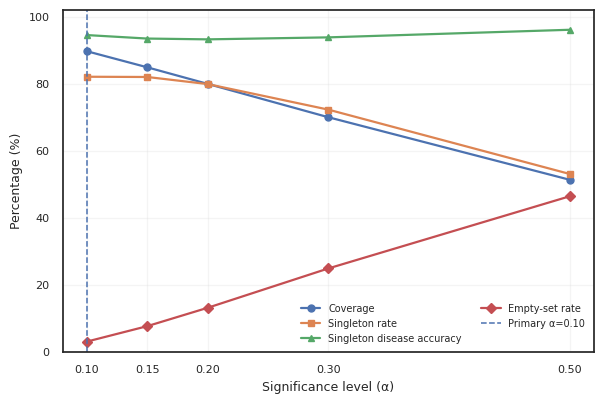


Saved figure + data to: /kaggle/working/reliable_disease_framework/results/conformal_alpha_sensitivity


In [48]:
# ============================================================
# MONDRIAN ALPHA SENSITIVITY — AUTO CALCULATION + SMALL FIGURE
#
# IMPORTANT:
# Uses the same finite-sample threshold rule as corrected Module 11.
#
# For each alpha:
# - recalibrate Mondrian class thresholds using ONLY the
#   conformal-calibration subset
# - evaluate on the frozen locked test
# - report coverage
# - report singleton/gate-open rate
# - report singleton conformal-disease accuracy
# - report empty-set rate
#
# This cell does NOT modify the primary alpha or frozen model.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Alpha values
# ------------------------------------------------------------

ALPHA_VALUES = [0.10, 0.15, 0.20, 0.30, 0.50]


# ------------------------------------------------------------
# 2. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "conformal_calibration_probs",
    "conformal_calibration_labels",
    "test_calibrated_probs",
    "test_true_labels",
    "NUM_DISEASES",
    "CONFIG",
]

missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise RuntimeError("Missing required variables: " + ", ".join(missing_variables))


# ------------------------------------------------------------
# 3. Existing calibrated probabilities
# ------------------------------------------------------------

calibration_probs = np.asarray(
    conformal_calibration_probs,
    dtype=np.float64
)

calibration_labels = np.asarray(
    conformal_calibration_labels,
    dtype=np.int64
).reshape(-1)

test_probs = np.asarray(
    test_calibrated_probs,
    dtype=np.float64
)

test_labels = np.asarray(
    test_true_labels,
    dtype=np.int64
).reshape(-1)

if calibration_probs.ndim != 2:
    raise RuntimeError("conformal_calibration_probs must be 2D.")

if test_probs.ndim != 2:
    raise RuntimeError("test_calibrated_probs must be 2D.")

if calibration_probs.shape != (
    len(calibration_labels),
    NUM_DISEASES
):
    raise RuntimeError(
        "Unexpected conformal calibration probability shape."
    )

if test_probs.shape != (
    len(test_labels),
    NUM_DISEASES
):
    raise RuntimeError(
        "Unexpected locked-test probability shape."
    )

if not np.isfinite(calibration_probs).all():
    raise RuntimeError(
        "Calibration probabilities contain NaN or infinity."
    )

if not np.isfinite(test_probs).all():
    raise RuntimeError(
        "Test probabilities contain NaN or infinity."
    )

if not np.allclose(
    calibration_probs.sum(axis=1),
    1.0,
    atol=1e-5
):
    raise RuntimeError(
        "Calibration probability rows do not sum to 1."
    )

if not np.allclose(
    test_probs.sum(axis=1),
    1.0,
    atol=1e-5
):
    raise RuntimeError(
        "Test probability rows do not sum to 1."
    )


# ------------------------------------------------------------
# 4. Calibration nonconformity scores
# score_i = 1 - P(true class | x_i)
# ------------------------------------------------------------

cal_rows = np.arange(len(calibration_labels))

cal_true_probs = calibration_probs[
    cal_rows,
    calibration_labels
]

cal_scores = 1.0 - cal_true_probs


# ------------------------------------------------------------
# 5. Exact finite-sample conformal threshold
# ------------------------------------------------------------

def conformal_threshold_for_alpha(scores, alpha):

    scores = np.asarray(
        scores,
        dtype=np.float64
    ).reshape(-1)

    n = int(len(scores))

    if n <= 0:
        raise ValueError(
            "Calibration score count must be positive."
        )

    if not 0.0 < alpha < 1.0:
        raise ValueError(
            "alpha must be between 0 and 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Calibration scores contain NaN or infinity."
        )

    rank = int(
        np.ceil(
            (n + 1) * (1.0 - alpha)
        )
    )

    if rank > n:
        return 1.0

    sorted_scores = np.sort(scores)

    return float(
        sorted_scores[rank - 1]
    )


# ------------------------------------------------------------
# 6. Evaluate one alpha
# ------------------------------------------------------------

def evaluate_mondrian_alpha(alpha):

    pooled_threshold = conformal_threshold_for_alpha(
        scores=cal_scores,
        alpha=alpha
    )

    thresholds = np.empty(
        NUM_DISEASES,
        dtype=np.float64
    )

    min_samples = int(
        CONFIG["minimum_class_calibration_samples"]
    )

    fallback_class_count = 0

    for class_index in range(NUM_DISEASES):

        class_mask = (
            calibration_labels == class_index
        )

        n_class = int(
            class_mask.sum()
        )

        if n_class < min_samples:

            thresholds[class_index] = (
                pooled_threshold
            )

            fallback_class_count += 1

            continue

        class_scores = cal_scores[
            class_mask
        ]

        thresholds[class_index] = (
            conformal_threshold_for_alpha(
                scores=class_scores,
                alpha=alpha
            )
        )

    test_inclusion = (
        (1.0 - test_probs)
        <= thresholds.reshape(1, -1)
    )

    test_sizes = (
        test_inclusion.sum(axis=1)
        .astype(np.int64)
    )

    row_indices = np.arange(
        len(test_labels)
    )

    true_label_in_set = (
        test_inclusion[
            row_indices,
            test_labels
        ]
    )

    test_coverage = float(
        true_label_in_set.mean()
    )

    empty_mask = (
        test_sizes == 0
    )

    singleton_mask = (
        test_sizes == 1
    )

    multiple_mask = (
        test_sizes > 1
    )

    if singleton_mask.any():

        singleton_disease_accuracy = float(
            true_label_in_set[
                singleton_mask
            ].mean()
        )

    else:

        singleton_disease_accuracy = np.nan

    average_set_size = float(
        test_sizes.mean()
    )

    return {

        "alpha": float(alpha),

        "nominal_coverage": float(
            1.0 - alpha
        ),

        "test_coverage": test_coverage,

        "singleton_rate": float(
            singleton_mask.mean()
        ),

        "singleton_disease_accuracy":
            singleton_disease_accuracy,

        "empty_set_rate": float(
            empty_mask.mean()
        ),

        "multiple_set_rate": float(
            multiple_mask.mean()
        ),

        "average_set_size":
            average_set_size,

        "fallback_classes":
            int(fallback_class_count),
    }


# ------------------------------------------------------------
# 7. Run all alpha values
# ------------------------------------------------------------

results = [
    evaluate_mondrian_alpha(alpha)
    for alpha in ALPHA_VALUES
]

alpha_results_df = pd.DataFrame(
    results
)


# ------------------------------------------------------------
# 8. Internal consistency checks
# ------------------------------------------------------------

for row_index in range(
    len(alpha_results_df)
):

    cardinality_sum = (

        alpha_results_df.loc[
            row_index,
            "empty_set_rate"
        ]

        +

        alpha_results_df.loc[
            row_index,
            "singleton_rate"
        ]

        +

        alpha_results_df.loc[
            row_index,
            "multiple_set_rate"
        ]
    )

    if not np.isclose(
        cardinality_sum,
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "Empty + singleton + multiple rates "
            "do not sum to 1."
        )


# ------------------------------------------------------------
# 9. Primary-alpha cross-check
# ------------------------------------------------------------

primary_alpha = float(
    CONFIG["conformal_alpha"]
)

matching_rows = alpha_results_df[
    np.isclose(
        alpha_results_df["alpha"].to_numpy(
            dtype=np.float64
        ),
        primary_alpha
    )
]

if len(matching_rows) == 1:

    primary_row = matching_rows.iloc[0]

    if "overall_cardinality_results" in globals():

        expected_coverage = float(
            overall_cardinality_results[
                "empirical_mondrian_coverage"
            ]
        )

        expected_singleton_rate = float(
            overall_cardinality_results[
                "singleton_set_rate"
            ]
        )

        expected_singleton_accuracy = float(
            overall_cardinality_results[
                "singleton_disease_accuracy"
            ]
        )

        if not np.isclose(
            float(
                primary_row["test_coverage"]
            ),
            expected_coverage,
            atol=1e-12
        ):

            raise RuntimeError(
                "Alpha-sensitivity coverage at "
                "primary alpha does not match Module 14A."
            )

        if not np.isclose(
            float(
                primary_row["singleton_rate"]
            ),
            expected_singleton_rate,
            atol=1e-12
        ):

            raise RuntimeError(
                "Alpha-sensitivity singleton rate at "
                "primary alpha does not match Module 14A."
            )

        if not np.isclose(
            float(
                primary_row[
                    "singleton_disease_accuracy"
                ]
            ),
            expected_singleton_accuracy,
            atol=1e-12
        ):

            raise RuntimeError(
                "Alpha-sensitivity singleton disease "
                "accuracy does not match Module 14A."
            )


# ------------------------------------------------------------
# 10. Percentage table for display
# ------------------------------------------------------------

alpha_results_display_df = (
    alpha_results_df.copy()
)

percentage_columns = [

    "nominal_coverage",

    "test_coverage",

    "singleton_rate",

    "singleton_disease_accuracy",

    "empty_set_rate",

    "multiple_set_rate",
]

for column in percentage_columns:

    alpha_results_display_df[column] = (
        alpha_results_display_df[column]
        * 100.0
    )


print(
    "Mondrian alpha sensitivity results:"
)

display(
    alpha_results_display_df.round(2)
)


# ------------------------------------------------------------
# 11. Small publication-style figure
# ------------------------------------------------------------

plt.figure(
    figsize=(6.2, 4.2)
)

plt.plot(
    alpha_results_display_df["alpha"],
    alpha_results_display_df["test_coverage"],
    marker="o",
    linewidth=1.6,
    markersize=5,
    label="Coverage",
)

plt.plot(
    alpha_results_display_df["alpha"],
    alpha_results_display_df["singleton_rate"],
    marker="s",
    linewidth=1.6,
    markersize=5,
    label="Singleton rate",
)

plt.plot(
    alpha_results_display_df["alpha"],
    alpha_results_display_df[
        "singleton_disease_accuracy"
    ],
    marker="^",
    linewidth=1.6,
    markersize=5,
    label="Singleton disease accuracy",
)

plt.plot(
    alpha_results_display_df["alpha"],
    alpha_results_display_df["empty_set_rate"],
    marker="D",
    linewidth=1.6,
    markersize=5,
    label="Empty-set rate",
)

plt.axvline(
    x=primary_alpha,
    linestyle="--",
    linewidth=1.1,
    label=f"Primary α={primary_alpha:.2f}"
)

plt.xlabel(
    "Significance level (α)",
    fontsize=9
)

plt.ylabel(
    "Percentage (%)",
    fontsize=9
)

# No title above the figure.
# Figure name/caption will be added below in the paper.

plt.xticks(
    ALPHA_VALUES,
    fontsize=8
)

plt.yticks(
    fontsize=8
)

plt.ylim(
    0,
    102
)

plt.grid(
    alpha=0.2
)

plt.legend(
    fontsize=7,
    frameon=False,
    ncol=2
)

plt.tight_layout()


# ------------------------------------------------------------
# 12. Save figure + data
# ------------------------------------------------------------

ALPHA_SENSITIVITY_DIR = (
    DIRS["results"]
    / "conformal_alpha_sensitivity"
)

ALPHA_SENSITIVITY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    ALPHA_SENSITIVITY_DIR
    / "mondrian_alpha_sensitivity_small_1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    ALPHA_SENSITIVITY_DIR
    / "mondrian_alpha_sensitivity_small_1.pdf",
    bbox_inches="tight",
)

alpha_results_df.to_csv(
    ALPHA_SENSITIVITY_DIR
    / "mondrian_alpha_sensitivity_results.csv",
    index=False
)

plt.show()

print(
    "\nSaved figure + data to:",
    ALPHA_SENSITIVITY_DIR
)

In [49]:
import json, pandas as pd
from scipy.stats import spearmanr

# --- per-class calibration n (reload if session restarted) ---
with open(DIRS["conformal"] / "mondrian_thresholds.json") as f:
    mondrian = json.load(f)
calib_counts = pd.Series(
    {int(k): v for k, v in mondrian["class_calibration_counts"].items()},
    name="n_calibration"
)
print(calib_counts.describe()[["min", "50%", "max"]])   # <-- reviewer bullet 1

# --- per-class test coverage (reconstruct if class_coverage_df is gone) ---
per_row = pd.read_csv(DIRS["results"] / "treatment_retrieval_gate" / "mondrian_cardinality_per_row.csv")
cov = (per_row.groupby("true_disease")
       .agg(test_samples=("true_label_in_set", "size"),
            covered=("true_label_in_set", "sum")))
cov["class_coverage"] = cov["covered"] / cov["test_samples"]

# join on disease name (safer than index across reruns)
name_to_n = {index_to_disease[k]: v for k, v in calib_counts.items()}
cov["n_calibration"] = cov.index.map(name_to_n)

rho, p = spearmanr(cov["n_calibration"], cov["class_coverage"])
print(f"Spearman(n_calib, coverage) = {rho:.3f}, p = {p:.4f}")

# also test the *dispersion* framing (see §4 below)
cov["abs_miscoverage"] = (cov["class_coverage"] - 0.90).abs()
rho2, p2 = spearmanr(cov["n_calibration"], cov["abs_miscoverage"])
print(f"Spearman(n_calib, |coverage-0.90|) = {rho2:.3f}, p = {p2:.4f}")

min    20.0
50%    20.0
max    21.0
Name: n_calibration, dtype: float64
Spearman(n_calib, coverage) = 0.095, p = 0.1996
Spearman(n_calib, |coverage-0.90|) = -0.028, p = 0.7090


In [50]:
# ============================================================
# ADDITIONAL ANALYSIS (not in original pipeline):
# Artificial calibration-size ablation to test whether smaller
# per-class n increases coverage VARIANCE. Uses already-frozen
# conformal_calibration_probs / labels and test_calibrated_probs.
# No retraining, no change to the primary (n=20-21) pipeline.
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.RandomState(CONFIG["seed"])
alpha_level = CONFIG["conformal_alpha"]

def class_thresholds_for_n(target_n, n_trials=20):
    """Subsample each class's calibration pool down to target_n
    (or keep all if fewer available), recompute thresholds,
    and return test-set class-wise coverage, repeated n_trials
    times to see variance across resamples."""
    all_trial_coverages = []  # list of arrays, one per trial, len 185

    for trial in range(n_trials):
        thresholds = {}
        for disease_index in range(NUM_DISEASES):
            class_mask = conformal_calibration_labels == disease_index
            class_scores_full = 1.0 - conformal_calibration_probs[class_mask, disease_index]
            n_avail = len(class_scores_full)
            n_use = min(target_n, n_avail)
            idx = rng.choice(n_avail, size=n_use, replace=False)
            scores = class_scores_full[idx]
            thresholds[disease_index] = conformal_threshold(scores, alpha_level)

        threshold_array = np.array([thresholds[i] for i in range(NUM_DISEASES)])
        test_scores = 1.0 - test_calibrated_probs
        inclusion = test_scores <= threshold_array.reshape(1, -1)
        true_in_set = inclusion[np.arange(len(test_true_labels)), test_true_labels]

        trial_cov = []
        for c in range(NUM_DISEASES):
            m = test_true_labels == c
            trial_cov.append(true_in_set[m].mean())
        all_trial_coverages.append(trial_cov)

    return np.array(all_trial_coverages)  # shape (n_trials, 185)

results = {}
for target_n in [10, 12, 15, 18, 20]:
    cov_matrix = class_thresholds_for_n(target_n, n_trials=20)
    per_class_std = cov_matrix.std(axis=0)          # variance across resamples, per class
    per_class_mean = cov_matrix.mean(axis=0)
    results[target_n] = {
        "mean_of_class_coverage": per_class_mean.mean(),
        "mean_per_class_std_across_resamples": per_class_std.mean(),
    }

summary_df = pd.DataFrame(results).T
summary_df.index.name = "target_calibration_n"
print(summary_df)

                      mean_of_class_coverage  \
target_calibration_n                           
10                                  0.903429   
12                                  0.918712   
15                                  0.935326   
18                                  0.946370   
20                                  0.897006   

                      mean_per_class_std_across_resamples  
target_calibration_n                                       
10                                               0.064278  
12                                               0.048867  
15                                               0.030986  
18                                               0.015098  
20                                               0.000274  


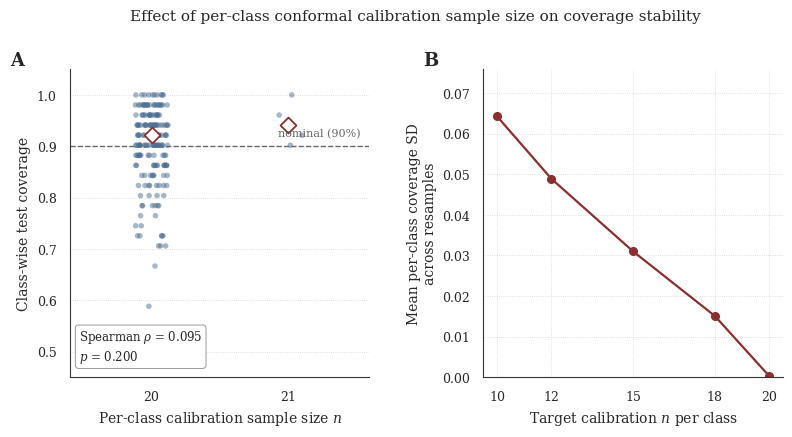

Saved: /kaggle/working/reliable_disease_framework/plots/calibration_n_coverage_two_panel.png


In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import spearmanr

# ===================================================================
# STEP 1 — Build `cov`: per-class calibration n + per-class test coverage
# ===================================================================

calib_counts = pd.Series(
    {int(k): v for k, v in class_calibration_counts.items()},
    name="n_calibration"
)

class_cov = class_coverage_df.set_index("class_index")["class_coverage"]

cov = pd.DataFrame({
    "n_calibration": calib_counts,
    "class_coverage": class_cov,
})
cov["disease"] = cov.index.map(index_to_disease)

assert cov.shape[0] == 185, f"Expected 185 classes, got {cov.shape[0]}"
assert cov.isna().sum().sum() == 0, "Missing values after join — check indices align"

# ===================================================================
# STEP 2 — Journal-style rcParams
# ===================================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "mathtext.fontset": "dejavuserif",
})

nominal_coverage = 1.0 - CONFIG["conformal_alpha"]

# ===================================================================
# STEP 3 — Two-panel figure
# ===================================================================

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.2, 4.0),
                                 gridspec_kw={"wspace": 0.38})

# --- PANEL A: actual 185 classes — n_calibration vs. class_coverage ---
color_points = "#4C6E91"
color_median = "#8B2E2E"
rng = np.random.RandomState(0)

unique_ns = sorted(cov["n_calibration"].unique())
for n_val in unique_ns:
    subset = cov.loc[cov["n_calibration"] == n_val, "class_coverage"]
    jitter = rng.uniform(-0.12, 0.12, size=len(subset))
    axA.scatter(np.full(len(subset), n_val) + jitter, subset,
                s=16, color=color_points, alpha=0.5,
                edgecolors="none", zorder=2)
    axA.scatter([n_val], [subset.median()], s=65, marker="D",
                facecolor="white", edgecolor=color_median,
                linewidth=1.3, zorder=3)

axA.axhline(nominal_coverage, color="#666666", linestyle="--", linewidth=1.0, zorder=1)
axA.text(0.97, nominal_coverage + 0.015, "nominal (90%)",
         transform=axA.get_yaxis_transform(),
         ha="right", va="bottom", fontsize=8, color="#666666")

axA.set_xticks(unique_ns)
axA.set_xlim(min(unique_ns) - 0.6, max(unique_ns) + 0.6)
axA.set_ylim(0.45, 1.05)
axA.set_xlabel("Per-class calibration sample size $n$")
axA.set_ylabel("Class-wise test coverage")
axA.grid(axis="y", linestyle=":", linewidth=0.6, color="#cccccc", alpha=0.8)
axA.set_axisbelow(True)
axA.spines[["top", "right"]].set_visible(False)

rho, pval = spearmanr(cov["n_calibration"], cov["class_coverage"])
axA.text(0.03, 0.04, f"Spearman $\\rho$ = {rho:.3f}\n$p$ = {pval:.3f}",
         transform=axA.transAxes, fontsize=8.5, va="bottom", ha="left",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                    edgecolor="#999999", linewidth=0.7))

axA.text(-0.20, 1.06, "A", transform=axA.transAxes,
         fontsize=13, fontweight="bold", va="top", ha="left")

# --- PANEL B: ablation — target n vs. mean per-class coverage SD ---
summary_df = summary_df.sort_index()
target_ns = summary_df.index.tolist()
mean_std = summary_df["mean_per_class_std_across_resamples"].tolist()

axB.plot(target_ns, mean_std, marker="o", markersize=5.5,
          linewidth=1.6, color=color_median)

axB.set_xticks(target_ns)
axB.set_xlabel("Target calibration $n$ per class")
axB.set_ylabel("Mean per-class coverage SD\nacross resamples")
axB.grid(axis="both", linestyle=":", linewidth=0.6, color="#cccccc", alpha=0.8)
axB.set_axisbelow(True)
axB.spines[["top", "right"]].set_visible(False)
axB.set_ylim(0, max(mean_std) * 1.18)

axB.text(-0.20, 1.06, "B", transform=axB.transAxes,
         fontsize=13, fontweight="bold", va="top", ha="left")

fig.suptitle("Effect of per-class conformal calibration sample size on coverage stability",
             fontsize=11, y=1.03)

plot_path = DIRS["plots"] / "calibration_n_coverage_two_panel.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

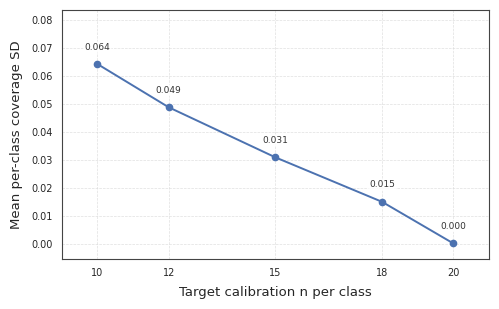

Saved: calibration_ablation_single_panel.{png,pdf,svg}


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#444444",
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_LINE = "#4C72B0"
GRID_COLOR = "#d8d8d8"

summary_df = summary_df.sort_index()
target_ns = summary_df.index.to_numpy()
mean_std  = summary_df["mean_per_class_std_across_resamples"].to_numpy()

fig, ax = plt.subplots(figsize=(5.0, 3.1))

ax.plot(
    target_ns, mean_std, marker="o", markersize=4.5, linewidth=1.4,
    color=COLOR_LINE
)

for x, y in zip(target_ns, mean_std):
    ax.annotate(
        f"{y:.3f}", (x, y), textcoords="offset points",
        xytext=(0, 9), ha="center", va="bottom",
        fontsize=6.5, color="#333333",
        bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                  edgecolor="none", alpha=0.85)
    )

ax.set_xticks(target_ns)
ax.set_xlabel("Target calibration n per class", labelpad=6)
ax.set_ylabel("Mean per-class coverage SD", labelpad=6)
ax.grid(True, linestyle="--", linewidth=0.5, color=GRID_COLOR, alpha=0.8)
ax.set_axisbelow(True)

# ---- full box border (all 4 spines), matching the loss-curve figure ----
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("#444444")

ax.set_ylim(-mean_std.max() * 0.08, mean_std.max() * 1.30)
ax.set_xlim(target_ns.min() - 1, target_ns.max() + 1)
ax.tick_params(length=3, width=0.7)

fig.tight_layout()

for ext in ("png", "pdf", "svg"):
    fig.savefig(DIRS["plots"] / f"calibration_ablation_single_panel.{ext}",
                dpi=300 if ext == "png" else None, bbox_inches="tight")

plt.show()
print("Saved: calibration_ablation_single_panel.{png,pdf,svg}")

In [53]:
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.8 MB/s eta 0:00:00


In [54]:
required_lig_variables = [
    "flat_model",
    "tokenizer",
    "test_locked_df",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "index_to_disease",
    "DEVICE",
    "CONFIG",
]

missing_lig_variables = [
    name
    for name in required_lig_variables
    if name not in globals()
]

if missing_lig_variables:
    raise RuntimeError(
        "Missing variables for LIG: "
        + ", ".join(missing_lig_variables)
    )

flat_model.eval()

print("All required LIG variables are ready.")
print("Model device:", next(flat_model.parameters()).device)

All required LIG variables are ready.
Model device: cuda:0


In [55]:
#   PubMedBERT word-embedding layer
# ============================================================

import numpy as np
import pandas as pd
import torch

from captum.attr import LayerIntegratedGradients


def lig_forward_function(
    input_ids,
    attention_mask,
    target_class,
):
    """
    Return the temperature-calibrated probability
    of the selected target disease.

    LayerIntegratedGradients requires a scalar output
    per sample for the selected target class.
    """

    model_output = flat_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

    if isinstance(model_output, tuple):
        logits = model_output[0]
    else:
        logits = model_output

    # Temperature scaling
    scaled_logits = logits / float(LEARNED_TEMPERATURE)

    # Convert to calibrated probabilities
    calibrated_probabilities = torch.softmax(
        scaled_logits,
        dim=1,
    )

    # Return probability of selected disease
    return calibrated_probabilities[:, int(target_class)]


embedding_layer = (
    flat_model.encoder.embeddings.word_embeddings
)

layer_integrated_gradients = LayerIntegratedGradients(
    lig_forward_function,
    embedding_layer,
)

print("Layer Integrated Gradients initialized.")
print("Attribution target: temperature-calibrated predicted-class probability")
print("Embedding layer:", embedding_layer)

Layer Integrated Gradients initialized.
Attribution target: temperature-calibrated predicted-class probability
Embedding layer: Embedding(30522, 768, padding_idx=0)


In [56]:
def build_lig_baseline(
    input_ids,
    attention_mask,
):
    """
    Create a PAD-token baseline while preserving special tokens.
    """

    baseline_ids = torch.full_like(
        input_ids,
        fill_value=tokenizer.pad_token_id,
    )

    special_token_ids = {
        token_id
        for token_id in [
            tokenizer.cls_token_id,
            tokenizer.sep_token_id,
        ]
        if token_id is not None
    }

    for special_token_id in special_token_ids:
        special_mask = (
            input_ids == special_token_id
        )

        baseline_ids[
            special_mask
        ] = special_token_id

    # Keep padded positions padded.
    baseline_ids[
        attention_mask == 0
    ] = tokenizer.pad_token_id

    return baseline_ids

In [57]:
def explain_patient_with_lig(
    row_index,
    n_steps=64,
):
    """
    Explain the final flat PubMedBERT prediction for one
    locked-test patient using Layer Integrated Gradients.
    """

    row_index = int(row_index)

    patient_text = str(
        test_locked_df.iloc[
            row_index
        ]["symptom_text"]
    )

    true_class = int(
        test_true_labels[
            row_index
        ]
    )

    predicted_class = int(
        test_predictions[
            row_index
        ]
    )

    calibrated_probability = float(
        test_calibrated_probs[
            row_index,
            predicted_class,
        ]
    )

    encoded = tokenizer(
        patient_text,
        truncation=True,
        max_length=int(
            CONFIG["max_length"]
        ),
        return_tensors="pt",
        add_special_tokens=True,
    )

    input_ids = encoded[
        "input_ids"
    ].to(DEVICE)

    attention_mask = encoded[
        "attention_mask"
    ].to(DEVICE)

    baseline_ids = build_lig_baseline(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

    flat_model.zero_grad(set_to_none=True)

    attributions, convergence_delta = (
        layer_integrated_gradients.attribute(
            inputs=input_ids,
            baselines=baseline_ids,
            additional_forward_args=(
                attention_mask,
                predicted_class,
            ),
            n_steps=int(n_steps),
            method="gausslegendre",
            return_convergence_delta=True,
        )
    )

    # Sum over embedding dimension to obtain one score per token.
    token_attributions = (
        attributions
        .sum(dim=-1)
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    token_ids = (
        input_ids
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    )

    tokens = tokenizer.convert_ids_to_tokens(
        token_ids
    )

    mask = (
        attention_mask
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(bool)
    )

    tokens = np.asarray(tokens)[mask]
    token_attributions = (
        token_attributions[mask]
    )

    # Remove special tokens from the displayed explanation.
    special_tokens = {
        token
        for token in [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
        ]
        if token is not None
    }

    display_mask = np.asarray(
        [
            token not in special_tokens
            for token in tokens
        ],
        dtype=bool,
    )

    display_tokens = tokens[
        display_mask
    ]

    display_attributions = (
        token_attributions[
            display_mask
        ]
    )

    # Normalize only for visualization/ranking.
    absolute_sum = float(
        np.abs(
            display_attributions
        ).sum()
    )

    if absolute_sum > 1e-12:
        normalized_attributions = (
            display_attributions
            / absolute_sum
        )
    else:
        normalized_attributions = (
            display_attributions.copy()
        )

    attribution_table = pd.DataFrame(
        {
            "token": display_tokens,
            "lig_attribution": (
                display_attributions
            ),
            "normalized_attribution": (
                normalized_attributions
            ),
            "absolute_attribution": np.abs(
                display_attributions
            ),
        }
    ).sort_values(
        "absolute_attribution",
        ascending=False,
    ).reset_index(drop=True)

    result = {
        "row_index": row_index,
        "patient_text": patient_text,
        "true_class": true_class,
        "predicted_class": predicted_class,
        "true_disease": str(
            index_to_disease[
                true_class
            ]
        ),
        "predicted_disease": str(
            index_to_disease[
                predicted_class
            ]
        ),
        "prediction_correct": bool(
            true_class == predicted_class
        ),
        "calibrated_probability": (
            calibrated_probability
        ),
        "tokens": display_tokens,
        "attributions": (
            display_attributions
        ),
        "normalized_attributions": (
            normalized_attributions
        ),
        "convergence_delta": float(
            convergence_delta
            .detach()
            .cpu()
            .reshape(-1)[0]
        ),
        "table": attribution_table,
    }

    print("=" * 80)
    print("LAYER INTEGRATED GRADIENTS EXPLANATION")
    print("=" * 80)
    print("Row index:", row_index)
    print("True disease:", result["true_disease"])
    print("Predicted disease:", result["predicted_disease"])
    print("Correct:", result["prediction_correct"])
    print(
        "Calibrated probability:",
        f"{calibrated_probability:.4f}",
    )
    print(
        "Convergence delta:",
        f"{result['convergence_delta']:.6f}",
    )

    return result

In [61]:
correct_indices = np.where(
    test_predictions == test_true_labels
)[0]

FIRST_CORRECT_INDEX = int(
    correct_indices[99]
)

correct_lig_result = explain_patient_with_lig(
    FIRST_CORRECT_INDEX,
    n_steps=64,
)

display(
    correct_lig_result[
        "table"
    ].head(20)
)

OFFSET-AWARE LAYER INTEGRATED GRADIENTS
Row index: 120
True disease: acute bronchitis
Explained disease: acute bronchitis
Calibrated probability: 0.9912
LIG steps: 64
Convergence delta: -0.00188637
Number of displayed tokens: 22
Number of surface words: 14

Top token-level contributions:


,token,char_start,char_end,lig_attribution,normalized_attribution,absolute_attribution
0,nasal,45,50,0.085545,0.086576,0.085545
1,fever,28,33,0.081246,0.082225,0.081246
2,headache,35,43,0.077976,0.078915,0.077976
3,wheezing,94,102,0.074593,0.075492,0.074593
4,throat,86,92,0.068161,0.068982,0.068161
5,cough,21,26,0.062635,0.063390,0.062635
6,chest,69,74,0.052392,0.053023,0.052392
7,sor,81,84,0.049701,0.050300,0.049701
8,chest,14,19,0.047719,0.048294,0.047719
9,congestion,51,61,0.047207,0.047776,0.047207



Surface-word-level contributions:


,char_start,char_end,word,lig_attribution,normalized_attribution,absolute_attribution
0,0,10,congestion,0.021657,0.021918,0.021657
1,11,13,in,0.029596,0.029952,0.029596
2,14,20,"chest,",0.083761,0.084770,0.083761
3,21,27,"cough,",0.087837,0.088895,0.087837
4,28,34,"fever,",0.104978,0.106242,0.104978
5,35,44,"headache,",0.101967,0.103195,0.101967
6,45,50,nasal,0.085545,0.086576,0.085545
7,51,62,"congestion,",0.069309,0.070144,0.069309
8,63,68,sharp,0.035031,0.035453,0.035031
9,69,74,chest,0.052392,0.053023,0.052392


,token,char_start,char_end,lig_attribution,normalized_attribution,absolute_attribution
0,nasal,45,50,0.085545,0.086576,0.085545
1,fever,28,33,0.081246,0.082225,0.081246
2,headache,35,43,0.077976,0.078915,0.077976
3,wheezing,94,102,0.074593,0.075492,0.074593
4,throat,86,92,0.068161,0.068982,0.068161
5,cough,21,26,0.062635,0.063390,0.062635
6,chest,69,74,0.052392,0.053023,0.052392
7,sor,81,84,0.049701,0.050300,0.049701
8,chest,14,19,0.047719,0.048294,0.047719
9,congestion,51,61,0.047207,0.047776,0.047207


In [63]:
# ============================================================
# MODULE 13B — OFFSET-AWARE LAYER INTEGRATED GRADIENTS
#
# No symptom dictionary
# No stop-word list
# No NER
# No handcrafted medical phrase rules
# ============================================================

import re
import numpy as np
import pandas as pd
import torch


def explain_patient_with_lig(
    row_index,
    n_steps=64,
    dataframe=None,
    target_class=None,
):
    """
    Generate token-level and exact surface-word-level LIG
    attribution for one patient.

    If dataframe is omitted, test_locked_df is used.

    If target_class is omitted, the flat model's Top-1
    predicted class is explained. If target_class is supplied,
    that specific class is explained.
    """

    if dataframe is None:
        dataframe = test_locked_df

    row_index = int(
        row_index
    )

    patient_text = str(
        dataframe.iloc[
            row_index
        ]["symptom_text"]
    )

    # --------------------------------------------------------
    # 1. DETERMINE THE CLASS TO EXPLAIN
    # --------------------------------------------------------

    # For the locked test, reuse the frozen predictions and
    # calibrated probabilities.
    if dataframe is test_locked_df:

        true_class = int(
            test_true_labels[
                row_index
            ]
        )

        predicted_class = int(
            test_predictions[
                row_index
            ]
        )

        # If a specific class is supplied, explain that class.
        if target_class is not None:

            predicted_class = int(
                target_class
            )

        number_of_classes = int(
            test_calibrated_probs.shape[1]
        )

        if not (
            0
            <= predicted_class
            < number_of_classes
        ):

            raise ValueError(
                f"target_class={predicted_class} "
                "is outside the valid class range "
                f"0 to {number_of_classes - 1}."
            )

        calibrated_probability = float(
            test_calibrated_probs[
                row_index,
                predicted_class,
            ]
        )

    # For another dataframe, generate probabilities first.
    else:

        patient_result = predict_dataframe(
            model=flat_model,

            dataframe=dataframe.iloc[
                [row_index]
            ].reset_index(
                drop=True
            ),

            include_embeddings=False,
        )

        patient_logits = np.asarray(
            patient_result[
                "logits"
            ],
            dtype=np.float32,
        )

        patient_probabilities = (
            apply_temperature_to_logits(
                patient_logits,
                temperature=(
                    LEARNED_TEMPERATURE
                ),
            )
        )

        true_class = int(
            dataframe.iloc[
                row_index
            ]["label"]
        )

        predicted_class = int(
            patient_probabilities[
                0
            ].argmax()
        )

        # If a specific class is supplied, explain that class.
        if target_class is not None:

            predicted_class = int(
                target_class
            )

        number_of_classes = int(
            patient_probabilities.shape[1]
        )

        if not (
            0
            <= predicted_class
            < number_of_classes
        ):

            raise ValueError(
                f"target_class={predicted_class} "
                "is outside the valid class range "
                f"0 to {number_of_classes - 1}."
            )

        calibrated_probability = float(
            patient_probabilities[
                0,
                predicted_class,
            ]
        )

    # --------------------------------------------------------
    # 2. TOKENIZE WITH OFFSET MAPPING
    # --------------------------------------------------------

    encoded = tokenizer(
        patient_text,

        truncation=True,

        max_length=int(
            CONFIG[
                "max_length"
            ]
        ),

        return_tensors="pt",

        return_offsets_mapping=True,

        add_special_tokens=True,
    )

    offset_mapping = (
        encoded.pop(
            "offset_mapping"
        )
        .squeeze(0)
        .cpu()
        .numpy()
    )

    input_ids = encoded[
        "input_ids"
    ].to(
        DEVICE
    )

    attention_mask = encoded[
        "attention_mask"
    ].to(
        DEVICE
    )

    baseline_ids = build_lig_baseline(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

    # --------------------------------------------------------
    # 3. COMPUTE LAYER INTEGRATED GRADIENTS
    # --------------------------------------------------------

    flat_model.zero_grad(
        set_to_none=True
    )

    attributions, convergence_delta = (
        layer_integrated_gradients.attribute(
            inputs=input_ids,

            baselines=baseline_ids,

            additional_forward_args=(
                attention_mask,
                predicted_class,
            ),

            n_steps=int(
                n_steps
            ),

            method="gausslegendre",

            return_convergence_delta=True,
        )
    )

    # Sum attribution values across the embedding dimension.
    token_attributions = (
        attributions
        .sum(
            dim=-1
        )
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    token_ids = (
        input_ids
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    )

    tokens = (
        tokenizer
        .convert_ids_to_tokens(
            token_ids
        )
    )

    attention_mask_array = (
        attention_mask
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(
            bool
        )
    )

    # Keep only tokens included by the attention mask.
    tokens = np.asarray(
        tokens,
        dtype=object,
    )[
        attention_mask_array
    ]

    token_attributions = (
        token_attributions[
            attention_mask_array
        ]
    )

    offset_mapping = (
        offset_mapping[
            attention_mask_array
        ]
    )

    # --------------------------------------------------------
    # 4. REMOVE SPECIAL TOKENS
    # --------------------------------------------------------

    special_tokens = {
        token
        for token in [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
        ]
        if token is not None
    }

    display_mask = np.asarray(
        [
            (
                token
                not in special_tokens
            )
            and (
                int(
                    offset[1]
                )
                >
                int(
                    offset[0]
                )
            )
            for token, offset
            in zip(
                tokens,
                offset_mapping,
            )
        ],
        dtype=bool,
    )

    display_tokens = (
        tokens[
            display_mask
        ]
    )

    display_attributions = (
        token_attributions[
            display_mask
        ]
    )

    display_offsets = (
        offset_mapping[
            display_mask
        ]
    )

    # --------------------------------------------------------
    # 5. NORMALIZE TOKEN ATTRIBUTIONS
    # --------------------------------------------------------

    absolute_sum = float(
        np.abs(
            display_attributions
        ).sum()
    )

    if absolute_sum > 1e-12:

        normalized_attributions = (
            display_attributions
            / absolute_sum
        )

    else:

        normalized_attributions = (
            display_attributions.copy()
        )

    # --------------------------------------------------------
    # 6. BUILD TOKEN-LEVEL TABLE
    # --------------------------------------------------------

    token_table = pd.DataFrame(
        {
            "token":
                display_tokens,

            "char_start":
                display_offsets[
                    :,
                    0
                ].astype(
                    int
                ),

            "char_end":
                display_offsets[
                    :,
                    1
                ].astype(
                    int
                ),

            "lig_attribution":
                display_attributions,

            "normalized_attribution":
                normalized_attributions,

            "absolute_attribution":
                np.abs(
                    display_attributions
                ),
        }
    )

    # --------------------------------------------------------
    # 7. MAP SUBWORD TOKENS TO EXACT SURFACE WORDS
    # --------------------------------------------------------

    word_records = []

    for match in re.finditer(
        r"\S+",
        patient_text,
    ):

        word_start = int(
            match.start()
        )

        word_end = int(
            match.end()
        )

        surface_word = str(
            match.group()
        )

        overlapping_indices = []

        for token_index, (
            token_start,
            token_end,
        ) in enumerate(
            display_offsets
        ):

            token_start = int(
                token_start
            )

            token_end = int(
                token_end
            )

            overlap_exists = (
                token_start
                < word_end
                and
                token_end
                > word_start
            )

            if overlap_exists:

                overlapping_indices.append(
                    token_index
                )

        if not overlapping_indices:
            continue

        word_attribution = float(
            display_attributions[
                overlapping_indices
            ].sum()
        )

        normalized_word_attribution = float(
            normalized_attributions[
                overlapping_indices
            ].sum()
        )

        word_records.append(
            {
                "char_start":
                    word_start,

                "char_end":
                    word_end,

                "word":
                    surface_word,

                "lig_attribution":
                    word_attribution,

                "normalized_attribution":
                    normalized_word_attribution,

                "absolute_attribution":
                    abs(
                        word_attribution
                    ),
            }
        )

    word_table = pd.DataFrame(
        word_records
    )

    if len(
        word_table
    ) > 0:

        word_table = (
            word_table
            .sort_values(
                "char_start",
                ascending=True,
            )
            .reset_index(
                drop=True
            )
        )

        word_absolute_sum = float(
            word_table[
                "lig_attribution"
            ]
            .abs()
            .sum()
        )

        if word_absolute_sum > 1e-12:

            word_table[
                "normalized_attribution"
            ] = (
                word_table[
                    "lig_attribution"
                ]
                / word_absolute_sum
            )

        else:

            word_table[
                "normalized_attribution"
            ] = 0.0

        word_table[
            "absolute_attribution"
        ] = (
            word_table[
                "lig_attribution"
            ]
            .abs()
        )

    else:

        word_table = pd.DataFrame(
            columns=[
                "char_start",
                "char_end",
                "word",
                "lig_attribution",
                "normalized_attribution",
                "absolute_attribution",
            ]
        )

    # Sort token table after word alignment is completed.
    token_table = (
        token_table
        .sort_values(
            "absolute_attribution",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    # --------------------------------------------------------
    # 8. BUILD RESULT
    # --------------------------------------------------------

    result = {
        "row_index":
            row_index,

        "patient_text":
            patient_text,

        "true_class":
            true_class,

        "predicted_class":
            predicted_class,

        "true_disease":
            str(
                index_to_disease[
                    true_class
                ]
            ),

        "predicted_disease":
            str(
                index_to_disease[
                    predicted_class
                ]
            ),

        "prediction_correct":
            bool(
                true_class
                == predicted_class
            ),

        "calibrated_probability":
            calibrated_probability,

        "tokens":
            display_tokens,

        "offsets":
            display_offsets,

        "attributions":
            display_attributions,

        "normalized_attributions":
            normalized_attributions,

        "convergence_delta":
            float(
                convergence_delta
                .detach()
                .cpu()
                .reshape(-1)[0]
            ),

        # Retain the original key for compatibility.
        "table":
            token_table,

        "token_table":
            token_table,

        "word_table":
            word_table,
    }

    # --------------------------------------------------------
    # 9. PRINT RESULTS
    # --------------------------------------------------------

    print(
        "=" * 80
    )

    print(
        "OFFSET-AWARE LAYER INTEGRATED GRADIENTS"
    )

    print(
        "=" * 80
    )

    print(
        "Row index:",
        row_index
    )

    print(
        "True disease:",
        result[
            "true_disease"
        ]
    )

    print(
        "Explained disease:",
        result[
            "predicted_disease"
        ]
    )

    print(
        "Calibrated probability:",
        f"{calibrated_probability:.4f}"
    )

    print(
        "LIG steps:",
        int(
            n_steps
        )
    )

    print(
        "Convergence delta:",
        f"{result['convergence_delta']:.8f}"
    )

    print(
        "Number of displayed tokens:",
        len(
            display_tokens
        )
    )

    print(
        "Number of surface words:",
        len(
            word_table
        )
    )

    print(
        "\nTop token-level contributions:"
    )

    display(
        token_table.head(
            20
        )
    )

    print(
        "\nSurface-word-level contributions:"
    )

    display(
        word_table
    )

    return result

In [64]:
# ============================================================
# GENERATE AND DISPLAY ONE OFFSET-AWARE LIG EXAMPLE
# ============================================================

# Select the first correctly classified locked-test case.
correct_indices = np.where(
    test_predictions
    ==
    test_true_labels
)[0]


if len(correct_indices) == 0:

    raise RuntimeError(
        "No correctly classified locked-test case "
        "was found for the LIG example."
    )


FIRST_CORRECT_INDEX = int(
    correct_indices[
        10
    ]
)


# Generate the offset-aware LIG result.
lig_result = explain_patient_with_lig(
    row_index=FIRST_CORRECT_INDEX,
    n_steps=64,
)


print(
    "\nPatient symptom text:"
)

print(
    lig_result[
        "patient_text"
    ]
)


print(
    "\nSurface-word-level LIG attribution:"
)


display(
    lig_result[
        "word_table"
    ][
        [
            "char_start",
            "char_end",
            "word",
            "lig_attribution",
        ]
    ]
    .sort_values(
        "char_start"
    )
    .reset_index(
        drop=True
    )
)

OFFSET-AWARE LAYER INTEGRATED GRADIENTS
Row index: 11
True disease: skin cancer
Explained disease: skin cancer
Calibrated probability: 0.6017
LIG steps: 64
Convergence delta: 0.00000304
Number of displayed tokens: 24
Number of surface words: 13

Top token-level contributions:


,token,char_start,char_end,lig_attribution,normalized_attribution,absolute_attribution
0,warts,92,97,0.153732,0.257367,0.153732
1,swelling,82,90,0.067705,0.113347,0.067705
2,irritation,53,63,0.053450,0.089483,0.053450
3,mole,70,74,0.036013,0.060291,0.036013
4,roughness,37,46,0.031341,0.052469,0.031341
5,peel,14,18,0.023870,0.039962,0.023870
6,skin,48,52,0.021827,0.036542,0.021827
7,##ing,18,21,0.020563,0.034426,0.020563
8,",",90,91,0.020522,0.034357,0.020522
9,skin,77,81,0.019302,0.032314,0.019302



Surface-word-level contributions:


,char_start,char_end,word,lig_attribution,normalized_attribution,absolute_attribution
0,0,4,skin,0.014111,0.023623,0.014111
1,5,13,"dryness,",0.024005,0.040188,0.024005
2,14,22,"peeling,",0.050112,0.083894,0.050112
3,23,33,"scaliness,",0.037995,0.063608,0.037995
4,34,36,or,0.015897,0.026614,0.015897
5,37,47,"roughness,",0.039211,0.065644,0.039211
6,48,52,skin,0.021827,0.036542,0.021827
7,53,64,"irritation,",0.065104,0.108992,0.065104
8,65,69,skin,0.016098,0.026949,0.016098
9,70,76,"moles,",0.051705,0.086561,0.051705



Patient symptom text:
skin dryness, peeling, scaliness, or roughness, skin irritation, skin moles, skin swelling, warts

Surface-word-level LIG attribution:


,char_start,char_end,word,lig_attribution
0,0,4,skin,0.014111
1,5,13,"dryness,",0.024005
2,14,22,"peeling,",0.050112
3,23,33,"scaliness,",0.037995
4,34,36,or,0.015897
5,37,47,"roughness,",0.039211
6,48,52,skin,0.021827
7,53,64,"irritation,",0.065104
8,65,69,skin,0.016098
9,70,76,"moles,",0.051705


In [ ]:
# ============================================================
# LIG COMPREHENSIVENESS
# FIXED 500 LOCKED-TEST SUBSET
#
# LIG Top-3 vs Random-3
# + Paired Wilcoxon Signed-Rank Test
#
# OUTPUT:
#   1. LIG Top-3 mean prediction drop
#   2. Random-3 mean prediction drop
#   3. Wilcoxon one-sided p-value
#
# SUPPRESSED OUTPUT:
#   - explain_patient_with_lig() internal heading/table
#   - case-by-case progress
# ============================================================

import numpy as np
import pandas as pd
import torch
import contextlib
import io

from scipy.stats import wilcoxon
from pathlib import Path
from IPython.utils.io import capture_output


# ============================================================
# 1. SETTINGS
# ============================================================

K = 3
N_LOCKED_SAMPLES = 1000
RANDOM_REPEATS = 10
RANDOM_SEED = 42
LIG_STEPS = 64


# ============================================================
# 2. REQUIRED VARIABLE CHECK
# ============================================================

required_variables = [
    "test_locked_df",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "flat_model",
    "tokenizer",
    "index_to_disease",
    "DEVICE",
    "CONFIG",
    "LEARNED_TEMPERATURE",
    "explain_patient_with_lig",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + ". Run the required notebook cells first."
    )


# ============================================================
# 3. VALIDATE LOCKED TEST SET
# ============================================================

number_of_locked_test_rows = len(test_locked_df)

if number_of_locked_test_rows < N_LOCKED_SAMPLES:
    raise ValueError(
        f"Locked test set contains only "
        f"{number_of_locked_test_rows} samples, "
        f"but {N_LOCKED_SAMPLES} are required."
    )


# ============================================================
# 4. CREATE REPRODUCIBLE FIXED 500-CASE SUBSET
# ============================================================

selection_rng = np.random.default_rng(RANDOM_SEED)

LOCKED_500_INDICES = np.sort(
    selection_rng.choice(
        number_of_locked_test_rows,
        size=N_LOCKED_SAMPLES,
        replace=False,
    )
).astype(int)


# ============================================================
# 5. RANDOM GENERATOR FOR RANDOM-3 BASELINE
# ============================================================

random_rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# 6. EXTRACT ORIGINAL SYMPTOMS
# ============================================================

def extract_original_symptoms(patient_text):

    symptoms = [
        symptom.strip()
        for symptom in str(patient_text).split(",")
        if symptom.strip()
    ]

    return symptoms


# ============================================================
# 7. REMOVE COMPLETE SYMPTOM UNITS
# ============================================================

def remove_selected_symptoms(
    patient_text,
    selected_symptoms,
):

    selected_set = {
        str(symptom).strip()
        for symptom in selected_symptoms
    }

    remaining_symptoms = [
        symptom.strip()
        for symptom in str(patient_text).split(",")
        if (
            symptom.strip()
            and symptom.strip() not in selected_set
        )
    ]

    return ", ".join(remaining_symptoms)


# ============================================================
# 8. GET ORIGINAL PREDICTED-CLASS PROBABILITY
# ============================================================

def get_original_predicted_probability(row_index):

    predicted_class = int(
        test_predictions[row_index]
    )

    original_probability = float(
        test_calibrated_probs[
            row_index,
            predicted_class,
        ]
    )

    return (
        predicted_class,
        original_probability,
    )


# ============================================================
# 9. GET TARGET-CLASS PROBABILITY AFTER DELETION
# ============================================================

def get_target_probability_after_deletion(
    text,
    target_class,
):

    text = str(text).strip()

    if not text:
        return 0.0

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_tensors="pt",
        add_special_tokens=True,
    )

    input_ids = encoded["input_ids"].to(DEVICE)

    attention_mask = encoded["attention_mask"].to(DEVICE)

    flat_model.eval()

    with torch.no_grad():

        model_output = flat_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        if isinstance(model_output, tuple):
            logits = model_output[0]
        else:
            logits = model_output

        scaled_logits = (
            logits / float(LEARNED_TEMPERATURE)
        )

        probabilities = torch.softmax(
            scaled_logits,
            dim=1,
        )

    return float(
        probabilities[
            0,
            int(target_class)
        ]
        .detach()
        .cpu()
    )


# ============================================================
# 10. LIG WORD-LEVEL → SYMPTOM-LEVEL ATTRIBUTION
#
# IMPORTANT:
# All console output AND all display()/table output generated
# internally by explain_patient_with_lig() is suppressed here
# using capture_output(), regardless of whether the Module 13B
# suppression cell was re-run in this kernel session.
# ============================================================

def get_lig_symptom_table(row_index):

    # --------------------------------------------------------
    # SUPPRESS ALL STDOUT + DISPLAY() OUTPUT FROM LIG FUNCTION
    # --------------------------------------------------------

    with capture_output():

        lig_result = explain_patient_with_lig(
            row_index=int(row_index),
            n_steps=LIG_STEPS,
        )

    # --------------------------------------------------------
    # Extract LIG result
    # --------------------------------------------------------

    patient_text = str(
        lig_result["patient_text"]
    )

    word_table = (
        lig_result["word_table"]
        .copy()
    )

    original_symptoms = (
        extract_original_symptoms(
            patient_text
        )
    )

    records = []

    search_start = 0

    # --------------------------------------------------------
    # Map word-level LIG attribution to symptoms
    # using character offsets
    # --------------------------------------------------------

    for symptom_index, symptom in enumerate(
        original_symptoms
    ):

        start = patient_text.find(
            symptom,
            search_start,
        )

        if start == -1:
            continue

        end = start + len(symptom)

        search_start = end

        if len(word_table) > 0:

            word_mask = (
                (
                    word_table["char_start"]
                    < end
                )
                &
                (
                    word_table["char_end"]
                    > start
                )
            )

            symptom_words = (
                word_table.loc[
                    word_mask
                ]
            )

        else:

            symptom_words = (
                word_table.iloc[0:0]
            )

        if len(symptom_words) > 0:

            lig_attribution = float(
                symptom_words[
                    "lig_attribution"
                ].sum()
            )

        else:

            lig_attribution = 0.0

        records.append({

            "symptom_index":
                symptom_index,

            "symptom":
                symptom,

            "lig_attribution":
                lig_attribution,

            "absolute_lig_attribution":
                abs(lig_attribution),

        })

    symptom_table = pd.DataFrame(
        records
    )

    if len(
        symptom_table
    ) == 0:

        return (
            patient_text,
            symptom_table,
        )

    # --------------------------------------------------------
    # Rank symptoms by absolute LIG attribution
    # --------------------------------------------------------

    symptom_table = (
        symptom_table
        .sort_values(
            "absolute_lig_attribution",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    symptom_table["lig_rank"] = (
        np.arange(
            len(symptom_table)
        ) + 1
    )

    return (
        patient_text,
        symptom_table,
    )


# ============================================================
# 11. MAIN EVALUATION
# ============================================================

results = []

for row_index in LOCKED_500_INDICES:

    row_index = int(row_index)

    try:

        # ----------------------------------------------------
        # ORIGINAL PATIENT TEXT
        # ----------------------------------------------------

        patient_text = str(
            test_locked_df.iloc[
                row_index
            ][
                "symptom_text"
            ]
        )

        # ----------------------------------------------------
        # ORIGINAL SYMPTOMS
        # ----------------------------------------------------

        original_symptoms = (
            extract_original_symptoms(
                patient_text
            )
        )

        number_of_symptoms = len(
            original_symptoms
        )

        # ----------------------------------------------------
        # EXCLUDE CASES WITH < 3 SYMPTOMS
        # ----------------------------------------------------

        if number_of_symptoms < K:
            continue

        # ----------------------------------------------------
        # ORIGINAL PREDICTED CLASS
        # ----------------------------------------------------

        (
            predicted_class,
            original_probability,
        ) = (
            get_original_predicted_probability(
                row_index
            )
        )

        predicted_disease = str(
            index_to_disease[
                predicted_class
            ]
        )

        # ----------------------------------------------------
        # LIG SYMPTOM ATTRIBUTION
        # ----------------------------------------------------

        (
            lig_patient_text,
            lig_symptom_table,
        ) = (
            get_lig_symptom_table(
                row_index
            )
        )

        if len(lig_symptom_table) < K:
            continue

        # ----------------------------------------------------
        # TOP-3 LIG SYMPTOMS
        # ----------------------------------------------------

        lig_top3_table = (
            lig_symptom_table
            .head(K)
            .copy()
        )

        lig_top3_symptoms = (
            lig_top3_table[
                "symptom"
            ]
            .tolist()
        )

        # ----------------------------------------------------
        # DELETE LIG TOP-3
        # ----------------------------------------------------

        lig_deleted_text = (
            remove_selected_symptoms(
                patient_text,
                lig_top3_symptoms,
            )
        )

        lig_probability_after = (
            get_target_probability_after_deletion(
                lig_deleted_text,
                predicted_class,
            )
        )

        lig_prediction_drop = (
            original_probability
            - lig_probability_after
        )

        # ----------------------------------------------------
        # RANDOM-3 BASELINE
        # ----------------------------------------------------

        random_drops = []

        random_examples = []

        for repeat_number in range(
            RANDOM_REPEATS
        ):

            random_indices = (
                random_rng.choice(
                    number_of_symptoms,
                    size=K,
                    replace=False,
                )
            )

            random_symptoms = [
                original_symptoms[
                    int(index)
                ]
                for index in random_indices
            ]

            random_deleted_text = (
                remove_selected_symptoms(
                    patient_text,
                    random_symptoms,
                )
            )

            random_probability_after = (
                get_target_probability_after_deletion(
                    random_deleted_text,
                    predicted_class,
                )
            )

            random_drop = (
                original_probability
                - random_probability_after
            )

            random_drops.append(
                random_drop
            )

            random_examples.append(
                " | ".join(
                    random_symptoms
                )
            )

        # ----------------------------------------------------
        # RANDOM SUMMARY
        # ----------------------------------------------------

        random_mean_drop = float(
            np.mean(
                random_drops
            )
        )

        random_median_drop = float(
            np.median(
                random_drops
            )
        )

        random_std_drop = float(
            np.std(
                random_drops,
                ddof=1,
            )
            if len(random_drops) > 1
            else 0.0
        )

        # ----------------------------------------------------
        # LIG ADVANTAGE
        # ----------------------------------------------------

        lig_minus_random = (
            lig_prediction_drop
            - random_mean_drop
        )

        lig_better = (
            lig_prediction_drop
            > random_mean_drop
        )

        # ----------------------------------------------------
        # SAVE PATIENT-LEVEL RESULT
        # ----------------------------------------------------

        results.append({

            "row_index":
                row_index,

            "predicted_class":
                predicted_class,

            "predicted_disease":
                predicted_disease,

            "number_of_original_symptoms":
                number_of_symptoms,

            "k":
                K,

            "original_probability":
                original_probability,

            "lig_top3_symptoms":
                " | ".join(
                    lig_top3_symptoms
                ),

            "lig_top3_attributions":
                " | ".join(
                    [
                        f"{value:.8f}"
                        for value
                        in lig_top3_table[
                            "lig_attribution"
                        ]
                    ]
                ),

            "lig_probability_after_removal":
                lig_probability_after,

            "lig_prediction_drop":
                lig_prediction_drop,

            "random_mean_prediction_drop":
                random_mean_drop,

            "random_median_prediction_drop":
                random_median_drop,

            "random_std_prediction_drop":
                random_std_drop,

            "lig_minus_random_drop":
                lig_minus_random,

            "lig_better_than_random":
                bool(lig_better),

            "random_trial_drops":
                " | ".join(
                    [
                        f"{value:.8f}"
                        for value
                        in random_drops
                    ]
                ),

            "random_trial_examples":
                " || ".join(
                    random_examples
                ),

        })

    except Exception:
        # Silently skip failed cases
        continue


# ============================================================
# 12. RESULT DATAFRAME
# ============================================================

lig_comprehensiveness_df = pd.DataFrame(
    results
)

if len(
    lig_comprehensiveness_df
) < 2:

    raise RuntimeError(
        "Fewer than 2 valid cases remained after "
        "the >=3-symptom criterion."
    )


# ============================================================
# 13. PATIENT-LEVEL PAIRED VALUES
# ============================================================

lig_drops = (
    lig_comprehensiveness_df[
        "lig_prediction_drop"
    ]
    .astype(float)
    .to_numpy()
)

random_mean_drops = (
    lig_comprehensiveness_df[
        "random_mean_prediction_drop"
    ]
    .astype(float)
    .to_numpy()
)

paired_differences = (
    lig_drops
    - random_mean_drops
)


# ============================================================
# 14. DESCRIPTIVE STATISTICS
# ============================================================

mean_lig_drop = float(
    np.mean(
        lig_drops
    )
)

median_lig_drop = float(
    np.median(
        lig_drops
    )
)

mean_random_drop = float(
    np.mean(
        random_mean_drops
    )
)

median_random_drop = float(
    np.median(
        random_mean_drops
    )
)

mean_difference = float(
    np.mean(
        paired_differences
    )
)

median_difference = float(
    np.median(
        paired_differences
    )
)

lig_win_rate = float(
    np.mean(
        lig_drops
        >
        random_mean_drops
    )
)


# ============================================================
# 15. PAIRED WILCOXON SIGNED-RANK TEST
# ============================================================

wilcoxon_statistic, wilcoxon_pvalue = (
    wilcoxon(
        lig_drops,
        random_mean_drops,
        alternative="greater",
        zero_method="wilcox",
    )
)

wilcoxon_statistic = float(
    wilcoxon_statistic
)

wilcoxon_pvalue = float(
    wilcoxon_pvalue
)


# ============================================================
# 16. RANK-BISERIAL EFFECT SIZE
# ============================================================

nonzero_differences = (
    paired_differences[
        paired_differences != 0
    ]
)

if len(
    nonzero_differences
) > 0:

    absolute_differences = np.abs(
        nonzero_differences
    )

    ranks = (
        pd.Series(
            absolute_differences
        )
        .rank(
            method="average"
        )
        .to_numpy()
    )

    positive_rank_sum = float(
        ranks[
            nonzero_differences > 0
        ].sum()
    )

    negative_rank_sum = float(
        ranks[
            nonzero_differences < 0
        ].sum()
    )

    rank_biserial_effect = (
        positive_rank_sum
        - negative_rank_sum
    ) / (
        positive_rank_sum
        + negative_rank_sum
    )

else:

    rank_biserial_effect = np.nan


# ============================================================
# 17. SAVE RESULTS
# ============================================================

output_dir = (
    Path(
        DIRS["results"]
    )
    / "lig_comprehensiveness"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Per-patient result
# ------------------------------------------------------------

per_patient_path = (
    output_dir
    / "lig_top3_vs_random3_per_patient_500.csv"
)

lig_comprehensiveness_df.to_csv(
    per_patient_path,
    index=False,
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    {
        "metric": [

            "fixed_locked_test_samples",

            "valid_cases",

            "excluded_less_than_3_symptoms",

            "k",

            "random_repeats",

            "lig_mean_prediction_drop",

            "lig_median_prediction_drop",

            "random3_mean_prediction_drop",

            "random3_median_prediction_drop",

            "mean_lig_minus_random",

            "median_lig_minus_random",

            "lig_better_than_random_rate",

            "wilcoxon_statistic",

            "wilcoxon_one_sided_pvalue",

            "rank_biserial_effect",

        ],

        "value": [

            N_LOCKED_SAMPLES,

            len(
                lig_comprehensiveness_df
            ),

            (
                N_LOCKED_SAMPLES
                -
                len(
                    lig_comprehensiveness_df
                )
            ),

            K,

            RANDOM_REPEATS,

            mean_lig_drop,

            median_lig_drop,

            mean_random_drop,

            median_random_drop,

            mean_difference,

            median_difference,

            lig_win_rate,

            wilcoxon_statistic,

            wilcoxon_pvalue,

            rank_biserial_effect,

        ],
    }
)


summary_path = (
    output_dir
    / "lig_top3_comprehensiveness_summary_500.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save exact 500 selected indices
# ------------------------------------------------------------

indices_path = (
    output_dir
    / "locked_500_indices.csv"
)

pd.DataFrame(
    {
        "locked_test_row_index":
            LOCKED_500_INDICES
    }
).to_csv(
    indices_path,
    index=False,
)


# ============================================================
# 18. ONLY 3 METRICS PRINT
# ============================================================

print("=" * 60)
print("LIG COMPREHENSIVENESS — FINAL METRICS")
print("=" * 60)

print(
    f"LIG Top-3 mean prediction drop : "
    f"{mean_lig_drop:.6f}"
)

print(
    f"Random-3 mean prediction drop  : "
    f"{mean_random_drop:.6f}"
)

print(
    f"Wilcoxon one-sided p-value     : "
    f"{wilcoxon_pvalue:.6g}"
)

In [65]:
# ============================================================
# MODULE 13C — PARTITION SHAP FOR FLAT PUBMEDBERT
#
# Purpose:
# - Explain the same predicted disease using Partition SHAP
# - No retraining
# - No symptom dictionary
# - No stop-word list
# - No NER
# - No handcrafted phrase rules
# ============================================================

!pip install -q shap

import numpy as np
import pandas as pd
import torch
import shap

flat_model.eval()


# ------------------------------------------------------------
# 1. Prediction function used by SHAP
# ------------------------------------------------------------

@torch.no_grad()
def shap_predict_function(texts):

    texts = np.asarray(texts, dtype=object).reshape(-1)
    texts = [str(text) for text in texts]

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_tensors="pt",
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    model_output = flat_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

    if isinstance(model_output, tuple):
        logits = model_output[0]
    else:
        logits = model_output

    # Explain the final temperature-calibrated probability
    calibrated_probabilities = torch.softmax(
        logits / float(LEARNED_TEMPERATURE),
        dim=1,
    )

    return (
        calibrated_probabilities
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


# ------------------------------------------------------------
# 2. Sanity check
# ------------------------------------------------------------

sample_text = str(
    lig_result["patient_text"]
)

sample_output = shap_predict_function(
    [sample_text]
)

assert sample_output.shape == (
    1,
    NUM_DISEASES,
)

assert np.allclose(
    sample_output.sum(axis=1),
    1.0,
    atol=1e-5,
)

print("SHAP prediction function verified.")
print("Output shape:", sample_output.shape)
print("Probability sum:", sample_output[0].sum())


# ------------------------------------------------------------
# 3. Create Text Partition SHAP explainer
# ------------------------------------------------------------

disease_output_names = [
    str(index_to_disease[i])
    for i in range(NUM_DISEASES)
]

shap_text_masker = shap.maskers.Text(
    tokenizer=tokenizer,
    mask_token=tokenizer.mask_token,
    collapse_mask_token=True,
)

partition_shap_explainer = shap.Explainer(
    model=shap_predict_function,
    masker=shap_text_masker,
    algorithm="partition",
    output_names=disease_output_names,
)

print("\nPartition SHAP explainer initialized.")


# ------------------------------------------------------------
# 4. Explain the same patient used by LIG
# ------------------------------------------------------------

SHAP_ROW_INDEX = int(
    lig_result["row_index"]
)

shap_patient_text = str(
    test_locked_df.iloc[
        SHAP_ROW_INDEX
    ]["symptom_text"]
)

shap_predicted_class = int(
    test_predictions[
        SHAP_ROW_INDEX
    ]
)

shap_true_class = int(
    test_true_labels[
        SHAP_ROW_INDEX
    ]
)

shap_probability = float(
    test_calibrated_probs[
        SHAP_ROW_INDEX,
        shap_predicted_class,
    ]
)

patient_shap_explanation = (
    partition_shap_explainer(
        [shap_patient_text],
        outputs=[shap_predicted_class],
        max_evals=500,
        batch_size=8,
    )
)


# ------------------------------------------------------------
# 5. Convert SHAP output into a token table
# ------------------------------------------------------------

shap_values = np.asarray(
    patient_shap_explanation.values[0]
).squeeze()

shap_tokens = np.asarray(
    patient_shap_explanation.data[0],
    dtype=object,
).reshape(-1)

if shap_values.ndim != 1:
    shap_values = shap_values.reshape(-1)

usable_length = min(
    len(shap_tokens),
    len(shap_values),
)

shap_tokens = shap_tokens[:usable_length]
shap_values = shap_values[:usable_length]

valid_mask = np.asarray(
    [
        str(token).strip() != ""
        for token in shap_tokens
    ],
    dtype=bool,
)

shap_tokens = shap_tokens[valid_mask]
shap_values = shap_values[valid_mask]

shap_token_table = pd.DataFrame(
    {
        "token": [
            str(token)
            for token in shap_tokens
        ],
        "shap_attribution": shap_values,
        "absolute_attribution": np.abs(
            shap_values
        ),
    }
)

total_shap_magnitude = float(
    shap_token_table[
        "absolute_attribution"
    ].sum()
)

if total_shap_magnitude > 1e-12:
    shap_token_table[
        "normalized_attribution"
    ] = (
        shap_token_table[
            "shap_attribution"
        ]
        / total_shap_magnitude
    )
else:
    shap_token_table[
        "normalized_attribution"
    ] = 0.0

shap_token_table = (
    shap_token_table
    .sort_values(
        "absolute_attribution",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Show result
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PARTITION SHAP EXPLANATION")
print("=" * 80)

print("Row index:", SHAP_ROW_INDEX)

print(
    "True disease:",
    index_to_disease[
        shap_true_class
    ],
)

print(
    "Predicted disease:",
    index_to_disease[
        shap_predicted_class
    ],
)

print(
    "Prediction correct:",
    shap_true_class
    == shap_predicted_class,
)

print(
    "Calibrated probability:",
    f"{shap_probability:.4f}",
)

print("\nTop SHAP-attributed text segments:")

display(
    shap_token_table.head(20)
)


# Interactive SHAP text visualization
shap.plots.text(
    patient_shap_explanation[0]
)

SHAP prediction function verified.
Output shape: (1, 185)
Probability sum: 0.99999994

Partition SHAP explainer initialized.

PARTITION SHAP EXPLANATION
Row index: 11
True disease: skin cancer
Predicted disease: skin cancer
Prediction correct: True
Calibrated probability: 0.6017

Top SHAP-attributed text segments:


,token,shap_attribution,absolute_attribution,normalized_attribution
0,warts,0.342103,0.342103,0.254111
1,mole,0.137054,0.137054,0.101803
2,scal,0.097310,0.097310,0.072281
3,dry,0.076527,0.076527,0.056843
4,iness,-0.065841,0.065841,-0.048906
5,ing,-0.063553,0.063553,-0.047207
6,s,-0.055734,0.055734,-0.041399
7,peel,0.052537,0.052537,0.039024
8,irritation,0.050974,0.050974,0.037863
9,ness,-0.049537,0.049537,-0.036796


In [ ]:
# ============================================================
# SHAP COMPREHENSIVENESS
# FIXED LOCKED-TEST SUBSET
#
# SHAP Top-3 vs Random-3
# + Paired Wilcoxon Signed-Rank Test
#
# OUTPUT:
#   1. SHAP Top-3 mean prediction drop
#   2. Random-3 mean prediction drop
#   3. Wilcoxon one-sided p-value
#
# SUPPRESSED OUTPUT:
#   - partition_shap_explainer() internal progress / tables
#   - case-by-case progress
# ============================================================

import numpy as np
import pandas as pd
import torch
import contextlib
import io

from scipy.stats import wilcoxon
from pathlib import Path
from IPython.utils.io import capture_output


# ============================================================
# 1. SETTINGS
# ============================================================

K = 3
N_LOCKED_SAMPLES = 1000
RANDOM_REPEATS = 10
RANDOM_SEED = 42
SHAP_MAX_EVALS = 500      # lower this (e.g. 100-150) if too slow
SHAP_BATCH_SIZE = 8


# ============================================================
# 2. REQUIRED VARIABLE CHECK
# ============================================================

required_variables = [
    "test_locked_df",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "flat_model",
    "tokenizer",
    "index_to_disease",
    "DEVICE",
    "CONFIG",
    "LEARNED_TEMPERATURE",
    "partition_shap_explainer",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + ". Run Module 13C (Partition SHAP explainer setup) first."
    )


# ============================================================
# 3. VALIDATE LOCKED TEST SET
# ============================================================

number_of_locked_test_rows = len(test_locked_df)

if number_of_locked_test_rows < N_LOCKED_SAMPLES:
    raise ValueError(
        f"Locked test set contains only "
        f"{number_of_locked_test_rows} samples, "
        f"but {N_LOCKED_SAMPLES} are required."
    )


# ============================================================
# 4. CREATE REPRODUCIBLE FIXED SUBSET (same seed as LIG version
#    so results are comparable on the SAME rows)
# ============================================================

selection_rng = np.random.default_rng(RANDOM_SEED)

LOCKED_SHAP_INDICES = np.sort(
    selection_rng.choice(
        number_of_locked_test_rows,
        size=N_LOCKED_SAMPLES,
        replace=False,
    )
).astype(int)


# ============================================================
# 5. RANDOM GENERATOR FOR RANDOM-3 BASELINE
# ============================================================

random_rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# 6. EXTRACT ORIGINAL SYMPTOMS
# ============================================================

def extract_original_symptoms(patient_text):

    symptoms = [
        symptom.strip()
        for symptom in str(patient_text).split(",")
        if symptom.strip()
    ]

    return symptoms


# ============================================================
# 7. REMOVE COMPLETE SYMPTOM UNITS
# ============================================================

def remove_selected_symptoms(
    patient_text,
    selected_symptoms,
):

    selected_set = {
        str(symptom).strip()
        for symptom in selected_symptoms
    }

    remaining_symptoms = [
        symptom.strip()
        for symptom in str(patient_text).split(",")
        if (
            symptom.strip()
            and symptom.strip() not in selected_set
        )
    ]

    return ", ".join(remaining_symptoms)


# ============================================================
# 8. GET ORIGINAL PREDICTED-CLASS PROBABILITY
# ============================================================

def get_original_predicted_probability(row_index):

    predicted_class = int(
        test_predictions[row_index]
    )

    original_probability = float(
        test_calibrated_probs[
            row_index,
            predicted_class,
        ]
    )

    return (
        predicted_class,
        original_probability,
    )


# ============================================================
# 9. GET TARGET-CLASS PROBABILITY AFTER DELETION
# ============================================================

def get_target_probability_after_deletion(
    text,
    target_class,
):

    text = str(text).strip()

    if not text:
        return 0.0

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_tensors="pt",
        add_special_tokens=True,
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    flat_model.eval()

    with torch.no_grad():

        model_output = flat_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        if isinstance(model_output, tuple):
            logits = model_output[0]
        else:
            logits = model_output

        scaled_logits = (
            logits / float(LEARNED_TEMPERATURE)
        )

        probabilities = torch.softmax(
            scaled_logits,
            dim=1,
        )

    return float(
        probabilities[
            0,
            int(target_class)
        ]
        .detach()
        .cpu()
    )


# ============================================================
# 10. SHAP WORD-LEVEL ATTRIBUTION FOR ONE PATIENT
#     (mirrors Module 13C/13D logic, fully suppressed)
# ============================================================

def compute_shap_word_table(row_index, target_class):
    """
    Returns (patient_text, word_table) where word_table has
    columns: char_start, char_end, word, shap_attribution.
    Returns an empty word_table if SHAP/tokenizer alignment
    fails for this row (row is skipped by the caller).
    """

    patient_text = str(
        test_locked_df.iloc[row_index]["symptom_text"]
    )

    with capture_output():

        explanation = partition_shap_explainer(
            [patient_text],
            outputs=[int(target_class)],
            max_evals=SHAP_MAX_EVALS,
            batch_size=SHAP_BATCH_SIZE,
        )

    shap_values = np.asarray(
        explanation.values[0]
    ).squeeze()

    if shap_values.ndim != 1:
        shap_values = shap_values.reshape(-1)

    shap_tokens = np.asarray(
        explanation.data[0],
        dtype=object,
    ).reshape(-1)

    usable_length = min(
        len(shap_tokens),
        len(shap_values),
    )

    shap_tokens = shap_tokens[:usable_length]
    shap_values = shap_values[:usable_length]

    valid_mask = np.asarray(
        [
            str(token).strip() != ""
            for token in shap_tokens
        ],
        dtype=bool,
    )

    shap_tokens = shap_tokens[valid_mask]
    shap_values = shap_values[valid_mask]

    # --------------------------------------------------------
    # Get tokenizer offsets to align SHAP values with exact
    # character spans (same approach as Module 13D).
    # --------------------------------------------------------

    offset_encoded = tokenizer(
        patient_text,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_offsets_mapping=True,
        add_special_tokens=True,
    )

    all_offsets = np.asarray(
        offset_encoded["offset_mapping"],
        dtype=np.int64,
    )

    valid_offset_mask = np.asarray(
        [
            int(end) > int(start)
            for start, end in all_offsets
        ],
        dtype=bool,
    )

    content_offsets = all_offsets[valid_offset_mask]

    if len(shap_values) != len(content_offsets):
        # Alignment mismatch for this row -- skip it.
        return patient_text, pd.DataFrame(
            columns=["char_start", "char_end", "word", "shap_attribution"]
        )

    shap_offset_records = []

    for attribution, offsets in zip(shap_values, content_offsets):
        start = int(offsets[0])
        end = int(offsets[1])

        shap_offset_records.append({
            "char_start": start,
            "char_end": end,
            "surface_piece": patient_text[start:end],
            "shap_attribution": float(attribution),
        })

    shap_offset_table = pd.DataFrame(shap_offset_records)

    # --------------------------------------------------------
    # Merge subword pieces into exact surface words
    # (identical logic to Module 13D)
    # --------------------------------------------------------

    shap_word_records = []
    current_word = None

    for row in shap_offset_table.itertuples(index=False):

        start = int(row.char_start)
        end = int(row.char_end)
        value = float(row.shap_attribution)

        if current_word is None:
            current_word = {
                "char_start": start,
                "char_end": end,
                "shap_attribution": value,
            }
            continue

        gap_text = patient_text[current_word["char_end"]:start]

        same_surface_word = (
            start <= current_word["char_end"]
            or (
                start == current_word["char_end"]
                and not gap_text.isspace()
            )
        )

        if same_surface_word:
            current_word["char_end"] = max(current_word["char_end"], end)
            current_word["shap_attribution"] += value
        else:
            current_word["word"] = patient_text[
                current_word["char_start"]:current_word["char_end"]
            ]
            shap_word_records.append(current_word)
            current_word = {
                "char_start": start,
                "char_end": end,
                "shap_attribution": value,
            }

    if current_word is not None:
        current_word["word"] = patient_text[
            current_word["char_start"]:current_word["char_end"]
        ]
        shap_word_records.append(current_word)

    word_table = pd.DataFrame(shap_word_records)

    return patient_text, word_table


# ============================================================
# 11. SHAP WORD-LEVEL -> SYMPTOM-LEVEL ATTRIBUTION
# ============================================================

def get_shap_symptom_table(row_index, target_class):

    with capture_output():
        patient_text, word_table = compute_shap_word_table(
            row_index, target_class
        )

    original_symptoms = extract_original_symptoms(patient_text)

    records = []
    search_start = 0

    for symptom_index, symptom in enumerate(original_symptoms):

        start = patient_text.find(symptom, search_start)

        if start == -1:
            continue

        end = start + len(symptom)
        search_start = end

        if len(word_table) > 0:
            word_mask = (
                (word_table["char_start"] < end)
                & (word_table["char_end"] > start)
            )
            symptom_words = word_table.loc[word_mask]
        else:
            symptom_words = word_table

        if len(symptom_words) > 0:
            shap_attribution = float(
                symptom_words["shap_attribution"].sum()
            )
        else:
            shap_attribution = 0.0

        records.append({
            "symptom_index": symptom_index,
            "symptom": symptom,
            "shap_attribution": shap_attribution,
            "absolute_shap_attribution": abs(shap_attribution),
        })

    symptom_table = pd.DataFrame(records)

    if len(symptom_table) == 0:
        return patient_text, symptom_table

    symptom_table = (
        symptom_table
        .sort_values("absolute_shap_attribution", ascending=False)
        .reset_index(drop=True)
    )

    symptom_table["shap_rank"] = np.arange(len(symptom_table)) + 1

    return patient_text, symptom_table


# ============================================================
# 12. MAIN EVALUATION
# ============================================================

results = []

for row_index in LOCKED_SHAP_INDICES:

    row_index = int(row_index)

    try:

        patient_text = str(
            test_locked_df.iloc[row_index]["symptom_text"]
        )

        original_symptoms = extract_original_symptoms(patient_text)
        number_of_symptoms = len(original_symptoms)

        if number_of_symptoms < K:
            continue

        (
            predicted_class,
            original_probability,
        ) = get_original_predicted_probability(row_index)

        predicted_disease = str(index_to_disease[predicted_class])

        (
            shap_patient_text_row,
            shap_symptom_table,
        ) = get_shap_symptom_table(row_index, predicted_class)

        if len(shap_symptom_table) < K:
            continue

        shap_top3_table = shap_symptom_table.head(K).copy()
        shap_top3_symptoms = shap_top3_table["symptom"].tolist()

        shap_deleted_text = remove_selected_symptoms(
            patient_text, shap_top3_symptoms
        )

        shap_probability_after = get_target_probability_after_deletion(
            shap_deleted_text, predicted_class
        )

        shap_prediction_drop = (
            original_probability - shap_probability_after
        )

        # ----------------------------------------------------
        # RANDOM-3 BASELINE
        # ----------------------------------------------------

        random_drops = []
        random_examples = []

        for repeat_number in range(RANDOM_REPEATS):

            random_indices = random_rng.choice(
                number_of_symptoms, size=K, replace=False
            )

            random_symptoms = [
                original_symptoms[int(index)]
                for index in random_indices
            ]

            random_deleted_text = remove_selected_symptoms(
                patient_text, random_symptoms
            )

            random_probability_after = get_target_probability_after_deletion(
                random_deleted_text, predicted_class
            )

            random_drop = original_probability - random_probability_after

            random_drops.append(random_drop)
            random_examples.append(" | ".join(random_symptoms))

        random_mean_drop = float(np.mean(random_drops))
        random_median_drop = float(np.median(random_drops))
        random_std_drop = float(
            np.std(random_drops, ddof=1) if len(random_drops) > 1 else 0.0
        )

        shap_minus_random = shap_prediction_drop - random_mean_drop
        shap_better = shap_prediction_drop > random_mean_drop

        results.append({
            "row_index": row_index,
            "predicted_class": predicted_class,
            "predicted_disease": predicted_disease,
            "number_of_original_symptoms": number_of_symptoms,
            "k": K,
            "original_probability": original_probability,
            "shap_top3_symptoms": " | ".join(shap_top3_symptoms),
            "shap_top3_attributions": " | ".join(
                [f"{v:.8f}" for v in shap_top3_table["shap_attribution"]]
            ),
            "shap_probability_after_removal": shap_probability_after,
            "shap_prediction_drop": shap_prediction_drop,
            "random_mean_prediction_drop": random_mean_drop,
            "random_median_prediction_drop": random_median_drop,
            "random_std_prediction_drop": random_std_drop,
            "shap_minus_random_drop": shap_minus_random,
            "shap_better_than_random": bool(shap_better),
            "random_trial_drops": " | ".join(
                [f"{v:.8f}" for v in random_drops]
            ),
            "random_trial_examples": " || ".join(random_examples),
        })

    except Exception:
        # Silently skip failed cases
        continue


# ============================================================
# 13. RESULT DATAFRAME
# ============================================================

shap_comprehensiveness_df = pd.DataFrame(results)

if len(shap_comprehensiveness_df) < 2:
    raise RuntimeError(
        "Fewer than 2 valid cases remained after "
        "the >=3-symptom criterion / SHAP alignment."
    )


# ============================================================
# 14. PATIENT-LEVEL PAIRED VALUES
# ============================================================

shap_drops = (
    shap_comprehensiveness_df["shap_prediction_drop"]
    .astype(float)
    .to_numpy()
)

random_mean_drops = (
    shap_comprehensiveness_df["random_mean_prediction_drop"]
    .astype(float)
    .to_numpy()
)

paired_differences = shap_drops - random_mean_drops


# ============================================================
# 15. DESCRIPTIVE STATISTICS
# ============================================================

mean_shap_drop = float(np.mean(shap_drops))
median_shap_drop = float(np.median(shap_drops))
mean_random_drop = float(np.mean(random_mean_drops))
median_random_drop = float(np.median(random_mean_drops))
mean_difference = float(np.mean(paired_differences))
median_difference = float(np.median(paired_differences))
shap_win_rate = float(np.mean(shap_drops > random_mean_drops))


# ============================================================
# 16. PAIRED WILCOXON SIGNED-RANK TEST
# ============================================================

wilcoxon_statistic, wilcoxon_pvalue = wilcoxon(
    shap_drops,
    random_mean_drops,
    alternative="greater",
    zero_method="wilcox",
)

wilcoxon_statistic = float(wilcoxon_statistic)
wilcoxon_pvalue = float(wilcoxon_pvalue)


# ============================================================
# 17. RANK-BISERIAL EFFECT SIZE
# ============================================================

nonzero_differences = paired_differences[paired_differences != 0]

if len(nonzero_differences) > 0:

    absolute_differences = np.abs(nonzero_differences)

    ranks = (
        pd.Series(absolute_differences)
        .rank(method="average")
        .to_numpy()
    )

    positive_rank_sum = float(ranks[nonzero_differences > 0].sum())
    negative_rank_sum = float(ranks[nonzero_differences < 0].sum())

    rank_biserial_effect = (
        (positive_rank_sum - negative_rank_sum)
        / (positive_rank_sum + negative_rank_sum)
    )

else:
    rank_biserial_effect = np.nan


# ============================================================
# 18. SAVE RESULTS
# ============================================================

output_dir = Path(DIRS["results"]) / "shap_comprehensiveness"
output_dir.mkdir(parents=True, exist_ok=True)

per_patient_path = output_dir / "shap_top3_vs_random3_per_patient.csv"
shap_comprehensiveness_df.to_csv(per_patient_path, index=False)

summary_df = pd.DataFrame({
    "metric": [
        "fixed_locked_test_samples",
        "valid_cases",
        "excluded_or_failed_cases",
        "k",
        "random_repeats",
        "shap_max_evals",
        "shap_mean_prediction_drop",
        "shap_median_prediction_drop",
        "random3_mean_prediction_drop",
        "random3_median_prediction_drop",
        "mean_shap_minus_random",
        "median_shap_minus_random",
        "shap_better_than_random_rate",
        "wilcoxon_statistic",
        "wilcoxon_one_sided_pvalue",
        "rank_biserial_effect",
    ],
    "value": [
        N_LOCKED_SAMPLES,
        len(shap_comprehensiveness_df),
        N_LOCKED_SAMPLES - len(shap_comprehensiveness_df),
        K,
        RANDOM_REPEATS,
        SHAP_MAX_EVALS,
        mean_shap_drop,
        median_shap_drop,
        mean_random_drop,
        median_random_drop,
        mean_difference,
        median_difference,
        shap_win_rate,
        wilcoxon_statistic,
        wilcoxon_pvalue,
        rank_biserial_effect,
    ],
})

summary_path = output_dir / "shap_top3_comprehensiveness_summary.csv"
summary_df.to_csv(summary_path, index=False)

indices_path = output_dir / "locked_shap_indices.csv"
pd.DataFrame(
    {"locked_test_row_index": LOCKED_SHAP_INDICES}
).to_csv(indices_path, index=False)


# ============================================================
# 19. ONLY 3 METRICS PRINT
# ============================================================

print("=" * 60)
print("SHAP COMPREHENSIVENESS — FINAL METRICS")
print("=" * 60)

print(
    f"SHAP Top-3 mean prediction drop : "
    f"{mean_shap_drop:.6f}"
)

print(
    f"Random-3 mean prediction drop   : "
    f"{mean_random_drop:.6f}"
)

print(
    f"Wilcoxon one-sided p-value      : "
    f"{wilcoxon_pvalue:.6g}"
)

In [66]:
# ============================================================
# MODULE 13D — OFFSET-AWARE SHAP + LIG–SHAP WORD ALIGNMENT
#
# PATIENT-FACING SOURCE: SHAP ONLY.
# LIG (Layer Integrated Gradients) is retained ONLY as an
# independent cross-check ("same_direction" column below).
# It never contributes to ranking, magnitude, or display order.
#
# NOTE ON NAMING: variables/columns using the prefix "ig_" refer
# to LIG (Layer Integrated Gradients), the Captum implementation
# used throughout this notebook — not vanilla Integrated Gradients
# on raw input embeddings. Kept for compatibility with Module 13G.
#
# No symptom dictionary
# No stop-word list
# No NER
# No handcrafted medical rules
# No combined/fused LIG+SHAP score
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Get exact tokenizer offsets for the SHAP patient text
# ------------------------------------------------------------

offset_encoded = tokenizer(
    shap_patient_text,
    truncation=True,
    max_length=int(CONFIG["max_length"]),
    return_offsets_mapping=True,
    add_special_tokens=True,
)

all_offsets = np.asarray(
    offset_encoded["offset_mapping"],
    dtype=np.int64,
)

# Remove [CLS], [SEP], [PAD] positions: they have (0, 0)
valid_offsets = np.asarray(
    [int(end) > int(start) for start, end in all_offsets],
    dtype=bool,
)

content_offsets = all_offsets[valid_offsets]


# ------------------------------------------------------------
# 2. Align SHAP values with tokenizer content-token offsets
# ------------------------------------------------------------

if len(shap_values) != len(content_offsets):
    raise RuntimeError(
        "SHAP-token count does not match tokenizer offset count.\n"
        f"SHAP values: {len(shap_values)}\n"
        f"Content offsets: {len(content_offsets)}"
    )

shap_offset_records = []

for attribution, offsets in zip(shap_values, content_offsets):
    start = int(offsets[0])
    end = int(offsets[1])

    shap_offset_records.append({
        "char_start": start,
        "char_end": end,
        "surface_piece": shap_patient_text[start:end],
        "shap_attribution": float(attribution),
    })

shap_offset_table = pd.DataFrame(shap_offset_records)


# ------------------------------------------------------------
# 3. Merge subword pieces into exact surface words
#
# Pieces are merged only when there is no whitespace between
# their original character spans.
# ------------------------------------------------------------

shap_word_records = []
current_word = None

for row in shap_offset_table.itertuples(index=False):

    start = int(row.char_start)
    end = int(row.char_end)
    value = float(row.shap_attribution)

    if current_word is None:
        current_word = {
            "char_start": start,
            "char_end": end,
            "shap_attribution": value,
        }
        continue

    gap_text = shap_patient_text[current_word["char_end"]:start]

    same_surface_word = (
        start <= current_word["char_end"]
        or (
            start == current_word["char_end"]
            and not gap_text.isspace()
        )
    )

    if same_surface_word:
        current_word["char_end"] = max(current_word["char_end"], end)
        current_word["shap_attribution"] += value
    else:
        current_word["word"] = shap_patient_text[
            current_word["char_start"]:current_word["char_end"]
        ]
        shap_word_records.append(current_word)
        current_word = {
            "char_start": start,
            "char_end": end,
            "shap_attribution": value,
        }

if current_word is not None:
    current_word["word"] = shap_patient_text[
        current_word["char_start"]:current_word["char_end"]
    ]
    shap_word_records.append(current_word)


shap_word_table = pd.DataFrame(shap_word_records)

shap_word_table["absolute_shap_attribution"] = (
    shap_word_table["shap_attribution"].abs()
)

total_shap_abs = float(shap_word_table["absolute_shap_attribution"].sum())

if total_shap_abs > 1e-12:
    shap_word_table["normalized_shap_attribution"] = (
        shap_word_table["shap_attribution"] / total_shap_abs
    )
else:
    shap_word_table["normalized_shap_attribution"] = 0.0


# ------------------------------------------------------------
# 4. Align LIG and SHAP using exact character spans
#    (LIG kept for independent agreement check ONLY —
#     no combined score is computed here)
# ------------------------------------------------------------

lig_word_table = (
    lig_result["word_table"]
    [["char_start", "char_end", "word", "lig_attribution", "normalized_attribution"]]
    .rename(columns={"normalized_attribution": "normalized_lig_attribution"})
    .copy()
)

lig_shap_word_alignment = pd.merge(
    lig_word_table,
    shap_word_table[
        ["char_start", "char_end", "shap_attribution", "normalized_shap_attribution"]
    ],
    on=["char_start", "char_end"],
    how="outer",
)

lig_shap_word_alignment["word"] = lig_shap_word_alignment.apply(
    lambda row: (
        row["word"]
        if pd.notna(row["word"])
        else shap_patient_text[int(row["char_start"]):int(row["char_end"])]
    ),
    axis=1,
)

for column in [
    "lig_attribution",
    "normalized_lig_attribution",
    "shap_attribution",
    "normalized_shap_attribution",
]:
    lig_shap_word_alignment[column] = lig_shap_word_alignment[column].fillna(0.0)

# Independent agreement flag ONLY. NOT used for ranking/magnitude.
lig_shap_word_alignment["same_direction"] = (
    np.sign(lig_shap_word_alignment["lig_attribution"])
    == np.sign(lig_shap_word_alignment["shap_attribution"])
)

lig_shap_word_alignment = (
    lig_shap_word_alignment
    .sort_values("char_start")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Display results — ranked by SHAP importance ONLY
# ------------------------------------------------------------

print("=" * 80)
print("OFFSET-AWARE SHAP WORD ATTRIBUTIONS (patient-facing source)")
print("=" * 80)

display(
    shap_word_table
    .sort_values("absolute_shap_attribution", ascending=False)
    .head(20)
)

print("\n" + "=" * 80)
print("LIG–SHAP WORD-LEVEL ALIGNMENT — ranked by SHAP; LIG shown for agreement check only")
print("=" * 80)

display(
    lig_shap_word_alignment[
        ["word", "char_start", "char_end", "shap_attribution", "lig_attribution", "same_direction"]
    ]
    .assign(abs_shap=lambda d: d["shap_attribution"].abs())
    .sort_values("abs_shap", ascending=False)
    .drop(columns="abs_shap")
    .head(20)
)

direction_agreement_rate = float(lig_shap_word_alignment["same_direction"].mean())

print("\nWord-level LIG–SHAP direction agreement:", f"{direction_agreement_rate:.2%}")
print("(This is a diagnostic cross-check only — it does not modify the SHAP-based patient report.)")

OFFSET-AWARE SHAP WORD ATTRIBUTIONS (patient-facing source)


,char_start,char_end,shap_attribution,word,absolute_shap_attribution,normalized_shap_attribution
12,92,97,0.342103,warts,0.342103,0.389125
7,53,64,0.098786,"irritation,",0.098786,0.112365
9,70,76,0.087797,"moles,",0.087797,0.099864
5,37,47,0.073981,"roughness,",0.073981,0.084150
3,23,33,0.056174,"scaliness,",0.056174,0.063895
11,82,91,0.051640,"swelling,",0.051640,0.058737
6,48,52,-0.037819,skin,0.037819,-0.043018
4,34,36,-0.033563,or,0.033563,-0.038176
1,5,13,0.028253,"dryness,",0.028253,0.032136
10,77,81,-0.026145,skin,0.026145,-0.029739



LIG–SHAP WORD-LEVEL ALIGNMENT — ranked by SHAP; LIG shown for agreement check only


,word,char_start,char_end,shap_attribution,lig_attribution,same_direction
12,warts,92,97,0.342103,0.153732,True
7,"irritation,",53,64,0.098786,0.065104,True
9,"moles,",70,76,0.087797,0.051705,True
5,"roughness,",37,47,0.073981,0.039211,True
3,"scaliness,",23,33,0.056174,0.037995,True
11,"swelling,",82,91,0.051640,0.088228,True
6,skin,48,52,-0.037819,0.021827,False
4,or,34,36,-0.033563,0.015897,False
1,"dryness,",5,13,0.028253,0.024005,True
10,skin,77,81,-0.026145,0.019302,False



Word-level LIG–SHAP direction agreement: 53.85%
(This is a diagnostic cross-check only — it does not modify the SHAP-based patient report.)


In [67]:
# ============================================================
# MODULE 13E — PHRASE-LEVEL ATTRIBUTION (SHAP = PATIENT-FACING)
#
# Direction, magnitude, and relative_attribution_percent are
# ALL computed from SHAP alone. LIG is retained ONLY inside
# "ig_shap_agreement" as an independent cross-check flag —
# it never enters the score.
#
# NOTE ON NAMING: "ig_shap_agreement" refers to LIG vs SHAP
# agreement (kept for compatibility with Module 13G-FULL,
# which reads this exact column name).
#
# Uses only:
# - original patient text
# - punctuation boundaries already present in the text
# - exact character offsets
# - SHAP attribution values (patient-facing)
# - LIG attribution values (agreement check only)
#
# No symptom dictionary
# No stop-word list
# No NER
# No combined/fused LIG+SHAP score
# ============================================================

import re
import numpy as np
import pandas as pd


def build_phrase_level_attributions(alignment_table, original_text):
    table = (
        alignment_table
        .sort_values("char_start")
        .reset_index(drop=True)
        .copy()
    )

    # Split original text into phrase spans using its own punctuation.
    # Delimiters are not included in the final phrase text.
    phrase_spans = []
    phrase_start = 0

    for match in re.finditer(r"[,;.!?]+", original_text):
        phrase_end = match.start()

        if phrase_end > phrase_start:
            raw_phrase = original_text[phrase_start:phrase_end]
            left_trim = len(raw_phrase) - len(raw_phrase.lstrip())
            right_trimmed = raw_phrase.rstrip()
            clean_start = phrase_start + left_trim
            clean_end = phrase_start + len(right_trimmed)

            if clean_end > clean_start:
                phrase_spans.append({
                    "char_start": clean_start,
                    "char_end": clean_end,
                    "phrase": original_text[clean_start:clean_end],
                })

        phrase_start = match.end()

    # Add final phrase after last punctuation.
    if phrase_start < len(original_text):
        raw_phrase = original_text[phrase_start:]
        left_trim = len(raw_phrase) - len(raw_phrase.lstrip())
        right_trimmed = raw_phrase.rstrip()
        clean_start = phrase_start + left_trim
        clean_end = phrase_start + len(right_trimmed)

        if clean_end > clean_start:
            phrase_spans.append({
                "char_start": clean_start,
                "char_end": clean_end,
                "phrase": original_text[clean_start:clean_end],
            })

    phrase_records = []

    for phrase_span in phrase_spans:
        phrase_start = int(phrase_span["char_start"])
        phrase_end = int(phrase_span["char_end"])

        # A word belongs to the phrase when its character span overlaps.
        phrase_words = table[
            (table["char_end"] > phrase_start)
            & (table["char_start"] < phrase_end)
        ]

        if len(phrase_words) == 0:
            continue

        # ---- PATIENT-FACING SCORE: SHAP ONLY ----
        shap_score = float(phrase_words["shap_attribution"].sum())
        normalized_shap_score = float(phrase_words["normalized_shap_attribution"].sum())

        # ---- LIG kept ONLY for independent agreement checking ----
        lig_score = float(phrase_words["lig_attribution"].sum())

        lig_sign = int(np.sign(lig_score))
        shap_sign = int(np.sign(shap_score))
        agreement = bool(lig_sign == shap_sign and shap_sign != 0)

        # Direction comes from SHAP alone — never combined with LIG
        if shap_score > 0:
            direction = "supports"
        elif shap_score < 0:
            direction = "opposes"
        else:
            direction = "neutral"

        phrase_records.append({
            "phrase": phrase_span["phrase"],
            "char_start": phrase_start,
            "char_end": phrase_end,
            "word_count": int(len(phrase_words)),
            "shap_attribution": shap_score,
            "normalized_shap_attribution": normalized_shap_score,
            "lig_attribution": lig_score,          # reference / cross-check only
            "direction": direction,                 # SHAP-based only
            "shap_magnitude": abs(normalized_shap_score),
            "ig_shap_agreement": agreement,         # LIG-vs-SHAP flag, metadata only
        })

    phrase_table = pd.DataFrame(phrase_records)

    if len(phrase_table) == 0:
        return phrase_table

    total_magnitude = float(phrase_table["shap_magnitude"].sum())

    if total_magnitude > 1e-12:
        phrase_table["relative_attribution_percent"] = (
            phrase_table["shap_magnitude"] / total_magnitude * 100.0
        )
    else:
        phrase_table["relative_attribution_percent"] = 0.0

    return (
        phrase_table
        .sort_values("shap_magnitude", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# Run phrase-level attribution
# ------------------------------------------------------------

xai_phrase_table = build_phrase_level_attributions(
    alignment_table=lig_shap_word_alignment,
    original_text=shap_patient_text,
)


# ------------------------------------------------------------
# Print patient-friendly output (SHAP-based, unambiguous)
# ------------------------------------------------------------

print("=" * 80)
print("PATIENT-FACING ATTRIBUTION REPORT — SHAP-BASED")
print("=" * 80)

print("Predicted disease:", index_to_disease[shap_predicted_class])
print("Calibrated probability:", f"{shap_probability:.4f}")

supporting_phrases = xai_phrase_table[xai_phrase_table["direction"] == "supports"]
opposing_phrases = xai_phrase_table[xai_phrase_table["direction"] == "opposes"]

print("\nSupporting phrases (SHAP):")

if len(supporting_phrases) == 0:
    print("- No supporting phrase identified.")
else:
    for rank, row in enumerate(supporting_phrases.itertuples(), start=1):
        agreement_note = "LIG agrees" if row.ig_shap_agreement else "LIG disagrees"
        print(
            f"{rank}. {row.phrase} "
            f"({row.relative_attribution_percent:.1f}% relative attribution, "
            f"{agreement_note})"
        )

print("\nOpposing phrases (SHAP):")

if len(opposing_phrases) == 0:
    print("- No opposing phrase identified.")
else:
    for rank, row in enumerate(opposing_phrases.itertuples(), start=1):
        agreement_note = "LIG agrees" if row.ig_shap_agreement else "LIG disagrees"
        print(
            f"{rank}. {row.phrase} "
            f"({row.relative_attribution_percent:.1f}% relative attribution, "
            f"{agreement_note})"
        )

print(
    "\nNote: Relative attribution is 100% SHAP-based and is not diagnostic probability. "
    "The 'LIG agrees/disagrees' tag is an independent cross-check from a separate XAI "
    "method (Layer Integrated Gradients) — it does not influence the score above."
)

display(
    xai_phrase_table[
        ["phrase", "direction", "shap_attribution", "lig_attribution",
         "ig_shap_agreement", "relative_attribution_percent"]
    ]
)

PATIENT-FACING ATTRIBUTION REPORT — SHAP-BASED
Predicted disease: skin cancer
Calibrated probability: 0.6017

Supporting phrases (SHAP):
1. warts (57.0% relative attribution, LIG agrees)
2. skin moles (11.7% relative attribution, LIG agrees)
3. skin irritation (10.2% relative attribution, LIG agrees)
4. scaliness (9.4% relative attribution, LIG agrees)
5. or roughness (6.7% relative attribution, LIG agrees)
6. skin swelling (4.2% relative attribution, LIG agrees)
7. skin dryness (0.7% relative attribution, LIG agrees)

Opposing phrases (SHAP):
1. peeling (0.2% relative attribution, LIG disagrees)

Note: Relative attribution is 100% SHAP-based and is not diagnostic probability. The 'LIG agrees/disagrees' tag is an independent cross-check from a separate XAI method (Layer Integrated Gradients) — it does not influence the score above.


,phrase,direction,shap_attribution,lig_attribution,ig_shap_agreement,relative_attribution_percent
0,warts,supports,0.342103,0.153732,True,56.967626
1,skin moles,supports,0.070197,0.067803,True,11.689268
2,skin irritation,supports,0.060967,0.086931,True,10.152348
3,scaliness,supports,0.056174,0.037995,True,9.354180
4,or roughness,supports,0.040418,0.055108,True,6.730512
5,skin swelling,supports,0.025495,0.107529,True,4.245418
6,skin dryness,supports,0.004061,0.038116,True,0.676231
7,peeling,opposes,-0.001107,0.050112,False,0.184418


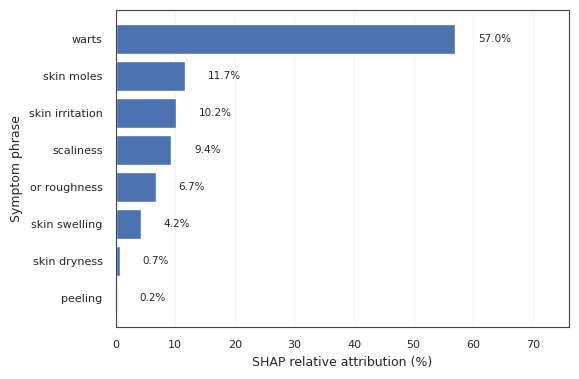

In [68]:
# ============================================================
# REPRESENTATIVE XAI CASE — SHAP PHRASE ATTRIBUTION
# (LIG agreement shown as a marker only, not part of the score)
# Compact figure
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Copy existing phrase-level XAI result (SHAP-based)
# ------------------------------------------------------------

plot_df = xai_phrase_table.copy()


# ------------------------------------------------------------
# 2. Keep strongest phrases for compact figure
#    (bars use magnitude = relative_attribution_percent,
#    all starting from 0)
# ------------------------------------------------------------

MAX_PHRASES = 8

plot_df = (
    plot_df
    .sort_values("relative_attribution_percent", ascending=False)
    .head(MAX_PHRASES)
    .sort_values("relative_attribution_percent", ascending=True)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Plot (bars = SHAP magnitude, all starting from 0;
#    hatch pattern flags LIG disagreement)
# ------------------------------------------------------------

plt.figure(figsize=(5.8, 3.8))

bars = plt.barh(
    plot_df["phrase"],
    plot_df["relative_attribution_percent"],
)

# Optional visual cue: hatch the bar if LIG disagrees with SHAP direction
for bar, agrees in zip(bars, plot_df["ig_shap_agreement"]):
    if not agrees:
        bar.set_hatch("//")
        bar.set_alpha(0.7)


# ------------------------------------------------------------
# 4. Add percentage labels at the end of each bar
# ------------------------------------------------------------

max_value = plot_df["relative_attribution_percent"].max()
label_offset = max_value * 0.05 + 1.0

for index, row in enumerate(plot_df.itertuples()):
    value = float(row.relative_attribution_percent)

    plt.text(
        value + label_offset, index, f"{value:.1f}%",
        va="center", ha="left", fontsize=7.5,
    )

plt.xlim(0, max_value * 1.3 + 2)


# ------------------------------------------------------------
# 5. Formatting
# ------------------------------------------------------------

plt.xlabel("SHAP relative attribution (%)", fontsize=9)
plt.ylabel("Symptom phrase", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()


# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

plt.savefig("representative_xai_phrase_attribution.png", dpi=300, bbox_inches="tight")
plt.savefig("representative_xai_phrase_attribution.pdf", bbox_inches="tight")
plt.show()

In [69]:
# ============================================================
# SUPPRESS PER-SAMPLE LIG TABLES DURING MODULE 13G
#
# This cell does not change:
# - LIG calculation
# - SHAP calculation
# - Attribution values
# - Agreement metrics
# - Spearman correlation
# - Top-3 or Top-5 overlap
# - Bootstrap confidence intervals
#
# It only suppresses print() and display() outputs generated
# inside explain_patient_with_lig().
# ============================================================

from IPython.utils.io import capture_output


# Preserve the original LIG function only once.
# This prevents recursive wrapping if this cell is rerun.
if (
    "_original_explain_patient_with_lig"
    not in globals()
):

    _original_explain_patient_with_lig = (
        explain_patient_with_lig
    )


def explain_patient_with_lig(
    *args,
    **kwargs,
):
    """
    Run the original LIG function without displaying
    its internal token-level and word-level tables.

    The original result dictionary is returned unchanged.
    """

    with capture_output():

        lig_result_suppressed = (
            _original_explain_patient_with_lig(
                *args,
                **kwargs,
            )
        )

    return lig_result_suppressed


print(
    "Per-sample LIG tables are suppressed. "
    "Module 13G calculation logic is unchanged."
)

Per-sample LIG tables are suppressed. Module 13G calculation logic is unchanged.


In [70]:
# ============================================================
# MISSING HELPER — build_shap_word_table_for_row()
#
# Reusable version of the Module 13C/13D inline SHAP word-level
# attribution logic. Required by Module 13G-FULL but was never
# defined as a standalone function in the original notebook.
# ============================================================

import io
import contextlib
import numpy as np
import pandas as pd


def build_shap_word_table_for_row(
    row_index,
    max_evals=300,
    batch_size=8,
):
    """
    Compute word-level Partition SHAP attribution for one
    locked-test patient, explaining the model's Top-1
    predicted class.

    Returns (patient_text, word_table), where word_table has
    columns: char_start, char_end, word, shap_attribution,
    absolute_shap_attribution, normalized_shap_attribution.
    """

    row_index = int(row_index)

    patient_text = str(
        test_locked_df.iloc[row_index]["symptom_text"]
    )

    predicted_class = int(
        test_predictions[row_index]
    )

    # --------------------------------------------------------
    # Run Partition SHAP (suppress its internal progress bar)
    # --------------------------------------------------------

    with contextlib.redirect_stdout(io.StringIO()):
        explanation = partition_shap_explainer(
            [patient_text],
            outputs=[predicted_class],
            max_evals=int(max_evals),
            batch_size=int(batch_size),
        )

    shap_values = np.asarray(
        explanation.values[0]
    ).squeeze()

    if shap_values.ndim != 1:
        shap_values = shap_values.reshape(-1)

    shap_tokens = np.asarray(
        explanation.data[0],
        dtype=object,
    ).reshape(-1)

    usable_length = min(
        len(shap_tokens),
        len(shap_values),
    )

    shap_tokens = shap_tokens[:usable_length]
    shap_values = shap_values[:usable_length]

    valid_mask = np.asarray(
        [
            str(token).strip() != ""
            for token in shap_tokens
        ],
        dtype=bool,
    )

    shap_tokens = shap_tokens[valid_mask]
    shap_values = shap_values[valid_mask]

    # --------------------------------------------------------
    # Align SHAP values with exact tokenizer character offsets
    # (identical approach to Module 13D)
    # --------------------------------------------------------

    offset_encoded = tokenizer(
        patient_text,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_offsets_mapping=True,
        add_special_tokens=True,
    )

    all_offsets = np.asarray(
        offset_encoded["offset_mapping"],
        dtype=np.int64,
    )

    valid_offset_mask = np.asarray(
        [
            int(end) > int(start)
            for start, end in all_offsets
        ],
        dtype=bool,
    )

    content_offsets = all_offsets[valid_offset_mask]

    if len(shap_values) != len(content_offsets):
        raise RuntimeError(
            "SHAP-token count does not match tokenizer offset "
            f"count for row_index={row_index}.\n"
            f"SHAP values: {len(shap_values)}\n"
            f"Content offsets: {len(content_offsets)}"
        )

    shap_offset_records = []

    for attribution, offsets in zip(shap_values, content_offsets):
        start = int(offsets[0])
        end = int(offsets[1])

        shap_offset_records.append({
            "char_start": start,
            "char_end": end,
            "surface_piece": patient_text[start:end],
            "shap_attribution": float(attribution),
        })

    shap_offset_table = pd.DataFrame(shap_offset_records)

    # --------------------------------------------------------
    # Merge subword pieces into exact surface words
    # (identical logic to Module 13D)
    # --------------------------------------------------------

    shap_word_records = []
    current_word = None

    for row in shap_offset_table.itertuples(index=False):

        start = int(row.char_start)
        end = int(row.char_end)
        value = float(row.shap_attribution)

        if current_word is None:
            current_word = {
                "char_start": start,
                "char_end": end,
                "shap_attribution": value,
            }
            continue

        gap_text = patient_text[current_word["char_end"]:start]

        same_surface_word = (
            start <= current_word["char_end"]
            or (
                start == current_word["char_end"]
                and not gap_text.isspace()
            )
        )

        if same_surface_word:
            current_word["char_end"] = max(current_word["char_end"], end)
            current_word["shap_attribution"] += value
        else:
            current_word["word"] = patient_text[
                current_word["char_start"]:current_word["char_end"]
            ]
            shap_word_records.append(current_word)
            current_word = {
                "char_start": start,
                "char_end": end,
                "shap_attribution": value,
            }

    if current_word is not None:
        current_word["word"] = patient_text[
            current_word["char_start"]:current_word["char_end"]
        ]
        shap_word_records.append(current_word)

    word_table = pd.DataFrame(shap_word_records)

    if len(word_table) == 0:
        word_table = pd.DataFrame(
            columns=[
                "char_start", "char_end", "word",
                "shap_attribution", "absolute_shap_attribution",
                "normalized_shap_attribution",
            ]
        )
        return patient_text, word_table

    word_table["absolute_shap_attribution"] = (
        word_table["shap_attribution"].abs()
    )

    total_abs = float(word_table["absolute_shap_attribution"].sum())

    if total_abs > 1e-12:
        word_table["normalized_shap_attribution"] = (
            word_table["shap_attribution"] / total_abs
        )
    else:
        word_table["normalized_shap_attribution"] = 0.0

    word_table = (
        word_table
        .sort_values("char_start")
        .reset_index(drop=True)
    )

    return patient_text, word_table


print("build_shap_word_table_for_row() defined successfully.")

build_shap_word_table_for_row() defined successfully.


In [71]:
# ============================================================
# MODULE 13G-FULL — FULL LOCKED-TEST LIG–SHAP AGREEMENT
#
# Runs the SAME evaluation as Module 13G (cell 75) on EVERY
# row of test_locked_df instead of a 100-case diverse sample.
#
# Reused, unmodified from the original notebook:
#   - calculate_xai_agreement()      (Module 13G logic)
#   - bootstrap_mean_ci()            (Module 13G logic)
#   - explain_patient_with_lig()     (Module 13B, must already be defined)
#   - build_shap_word_table_for_row()(Module 13C/13D, must already be defined)
#   - build_phrase_level_attributions() (Module 13E, must already be defined)
#
# Added only for the full-scale run:
#   - looping over the entire locked test set
#   - checkpointing / resume support
#   - explicit valid-Spearman sample count
#
# NOTE: "edl_uncertainty" naming removed. Uses
# test_softmax_uncertainty (= 1 - top1_calibrated_probability),
# which is NOT true evidential/Dirichlet uncertainty.
# ============================================================

import io
import os
import json
import time
import contextlib
import numpy as np
import pandas as pd

from scipy.stats import spearmanr


# ------------------------------------------------------------
# STEP 0 — Verify required variables/functions exist
# ------------------------------------------------------------

required_full_run_variables = [
    "flat_model",
    "tokenizer",
    "test_locked_df",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "test_softmax_uncertainty",
    "index_to_disease",
    "DEVICE",
    "CONFIG",
    "DIRS",
    "layer_integrated_gradients",
    "partition_shap_explainer",
    "explain_patient_with_lig",
    "build_shap_word_table_for_row",
    "build_phrase_level_attributions",
]

missing_full_run_variables = [
    name for name in required_full_run_variables
    if name not in globals()
]

if missing_full_run_variables:
    raise RuntimeError(
        "Missing required objects for the full-scale XAI run: "
        + ", ".join(missing_full_run_variables)
        + ". Run Modules 1–13F (through the SHAP/phrase-attribution "
        + "cells) before executing this cell."
    )

print("All required variables/functions for the full-scale run are present.")
print("Locked test set size:", len(test_locked_df))


# ------------------------------------------------------------
# STEP 1 — Configuration (identical hyperparameters to the
# original 100-case Module 13G run, for numerical comparability)
# ------------------------------------------------------------

XAI_LIG_STEPS = 64
XAI_SHAP_MAX_EVALS = 500
XAI_BOOTSTRAP_ITERATIONS = 2000
XAI_RANDOM_SEED = 42

CHECKPOINT_EVERY = 100  # save progress every N newly completed cases

XAI_FULL_DIR = DIRS["results"] / "xai_full_calibrated_probability"
XAI_FULL_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_RESULTS_PATH = XAI_FULL_DIR / "lig_shap_full_checkpoint.csv"
FAILED_ROWS_PATH = XAI_FULL_DIR / "lig_shap_full_failed_rows.csv"

FINAL_RESULTS_PATH = XAI_FULL_DIR / "lig_shap_full_results.csv"
FINAL_CI_PATH = XAI_FULL_DIR / "lig_shap_full_bootstrap_confidence_intervals.csv"
FINAL_CORRECT_VS_INCORRECT_PATH = XAI_FULL_DIR / "lig_shap_full_correct_vs_incorrect.csv"
FINAL_SUMMARY_PATH = XAI_FULL_DIR / "lig_shap_full_summary.json"


# ------------------------------------------------------------
# STEP 2 — calculate_xai_agreement()
# Reused verbatim from Module 13G (cell 75). No methodology
# changes: same word-level offset alignment, same L1
# normalization, same direction/Spearman/top-k definitions.
# ------------------------------------------------------------

def calculate_xai_agreement(
    row_index,
    lig_steps=64,
    shap_max_evals=500,
):
    row_index = int(row_index)

    # Suppress the normal LIG printout
    with contextlib.redirect_stdout(io.StringIO()):
        lig_result_local = explain_patient_with_lig(
            row_index=row_index,
            n_steps=int(lig_steps),
        )

    patient_text = str(lig_result_local["patient_text"])

    # Partition SHAP
    _, shap_words = build_shap_word_table_for_row(
        row_index=row_index,
        max_evals=int(shap_max_evals),
    )

    # LIG word table
    lig_words = (
        lig_result_local["word_table"][
            ["char_start", "char_end", "word", "lig_attribution", "normalized_attribution"]
        ]
        .rename(columns={"normalized_attribution": "normalized_lig_attribution"})
        .copy()
    )

    # Exact offset-based alignment
    alignment = pd.merge(
        lig_words,
        shap_words[["char_start", "char_end", "shap_attribution", "normalized_shap_attribution"]],
        on=["char_start", "char_end"],
        how="outer",
    )

    alignment["word"] = alignment.apply(
        lambda row: (
            row["word"]
            if pd.notna(row["word"])
            else patient_text[int(row["char_start"]):int(row["char_end"])]
        ),
        axis=1,
    )

    numeric_columns = [
        "lig_attribution",
        "normalized_lig_attribution",
        "shap_attribution",
        "normalized_shap_attribution",
    ]

    for column in numeric_columns:
        alignment[column] = alignment[column].fillna(0.0).astype(float)

    alignment = alignment.sort_values("char_start").reset_index(drop=True)

    # Ignore zero-zero pairs
    informative_words = alignment[
        (alignment["lig_attribution"].abs() + alignment["shap_attribution"].abs()) > 1e-12
    ].copy()

    number_of_words = int(len(informative_words))

    if number_of_words > 0:
        same_word_direction = (
            np.sign(informative_words["lig_attribution"])
            == np.sign(informative_words["shap_attribution"])
        )
        word_agreement_count = int(same_word_direction.sum())
        word_direction_agreement = float(same_word_direction.mean())
    else:
        word_agreement_count = 0
        word_direction_agreement = np.nan

    # Word importance rank correlation
    if (
        number_of_words >= 2
        and informative_words["normalized_lig_attribution"].abs().nunique() > 1
        and informative_words["normalized_shap_attribution"].abs().nunique() > 1
    ):
        spearman_value = float(
            spearmanr(
                informative_words["normalized_lig_attribution"].abs(),
                informative_words["normalized_shap_attribution"].abs(),
            ).statistic
        )
    else:
        spearman_value = np.nan

    # Phrase-level explanation
    phrase_table = build_phrase_level_attributions(
        alignment_table=alignment,
        original_text=patient_text,
    )

    number_of_phrases = int(len(phrase_table))

    if number_of_phrases > 0:
        phrase_agreement_count = int(phrase_table["ig_shap_agreement"].sum())
        phrase_direction_agreement = float(phrase_table["ig_shap_agreement"].mean())
    else:
        phrase_agreement_count = 0
        phrase_direction_agreement = np.nan

    def phrase_overlap_at_k(k):
        if number_of_phrases == 0:
            return np.nan

        effective_k = min(int(k), number_of_phrases)

        top_lig = set(
            phrase_table.assign(score=phrase_table["lig_attribution"].abs())
            .sort_values("score", ascending=False)
            .head(effective_k)["phrase"]
            .tolist()
        )

        top_shap = set(
            phrase_table.assign(score=phrase_table["shap_attribution"].abs())
            .sort_values("score", ascending=False)
            .head(effective_k)["phrase"]
            .tolist()
        )

        return float(len(top_lig & top_shap) / effective_k)

    predicted_class = int(test_predictions[row_index])
    true_class = int(test_true_labels[row_index])

    return {
        "row_index": row_index,
        "prediction_correct": bool(predicted_class == true_class),
        "true_disease": str(index_to_disease[true_class]),
        "predicted_disease": str(index_to_disease[predicted_class]),
        "calibrated_confidence": float(test_calibrated_probs[row_index, predicted_class]),
        "softmax_uncertainty": float(test_softmax_uncertainty[row_index]),
        "number_of_words": number_of_words,
        "word_agreement_count": word_agreement_count,
        "word_direction_agreement": word_direction_agreement,
        "word_importance_spearman": spearman_value,
        "number_of_phrases": number_of_phrases,
        "phrase_agreement_count": phrase_agreement_count,
        "phrase_direction_agreement": phrase_direction_agreement,
        "top3_phrase_overlap": phrase_overlap_at_k(3),
        "top5_phrase_overlap": phrase_overlap_at_k(5),
    }


# ------------------------------------------------------------
# STEP 3 — bootstrap_mean_ci()
# Reused verbatim from Module 13G (cell 75).
# ------------------------------------------------------------

def bootstrap_mean_ci(values, iterations=2000, seed=42):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return (np.nan, np.nan, np.nan)

    local_rng = np.random.default_rng(seed)
    bootstrap_means = np.empty(iterations, dtype=np.float64)

    for index in range(iterations):
        sample = local_rng.choice(values, size=len(values), replace=True)
        bootstrap_means[index] = sample.mean()

    return (
        float(values.mean()),
        float(np.quantile(bootstrap_means, 0.025)),
        float(np.quantile(bootstrap_means, 0.975)),
    )


# ------------------------------------------------------------
# STEP 4 — Resume from checkpoint if one exists
# ------------------------------------------------------------

all_indices = np.arange(len(test_locked_df), dtype=int)

if CHECKPOINT_RESULTS_PATH.exists():
    checkpoint_df = pd.read_csv(CHECKPOINT_RESULTS_PATH)
    agreement_records = checkpoint_df.to_dict("records")
    completed_row_indices = set(checkpoint_df["row_index"].astype(int).tolist())
    print(f"Resuming from checkpoint: {len(completed_row_indices)} cases already completed.")
else:
    agreement_records = []
    completed_row_indices = set()
    print("No checkpoint found. Starting a fresh full-scale run.")

if FAILED_ROWS_PATH.exists():
    failed_rows_df = pd.read_csv(FAILED_ROWS_PATH)
    failed_records = failed_rows_df.to_dict("records")
    failed_row_indices = set(failed_rows_df["row_index"].astype(int).tolist())
else:
    failed_records = []
    failed_row_indices = set()

remaining_indices = [
    idx for idx in all_indices
    if idx not in completed_row_indices and idx not in failed_row_indices
]

print(f"Total locked-test cases: {len(all_indices)}")
print(f"Already completed: {len(completed_row_indices)}")
print(f"Previously failed (will be skipped): {len(failed_row_indices)}")
print(f"Remaining to process: {len(remaining_indices)}")


# ------------------------------------------------------------
# STEP 5 — Main loop with progress reporting + checkpointing
# ------------------------------------------------------------

print("=" * 80)
print("MODULE 13G-FULL — FULL LOCKED-TEST LIG–SHAP AGREEMENT")
print("=" * 80)

run_start_time = time.time()
since_checkpoint_count = 0

for position, row_index in enumerate(remaining_indices, start=1):

    case_start_time = time.time()

    try:
        record = calculate_xai_agreement(
            row_index=int(row_index),
            lig_steps=XAI_LIG_STEPS,
            shap_max_evals=XAI_SHAP_MAX_EVALS,
        )

        record["runtime_seconds"] = float(time.time() - case_start_time)
        agreement_records.append(record)
        since_checkpoint_count += 1

        if position % 10 == 0 or position == len(remaining_indices):
            elapsed = time.time() - run_start_time
            avg_runtime = elapsed / position
            eta_seconds = avg_runtime * (len(remaining_indices) - position)
            print(
                f"Completed {len(agreement_records)}/{len(all_indices)} total "
                f"({position}/{len(remaining_indices)} this run) | "
                f"correct={record['prediction_correct']} | "
                f"phrase_agree={record['phrase_direction_agreement']:.3f} | "
                f"avg={avg_runtime:.2f}s/case | "
                f"ETA={eta_seconds / 60:.1f} min"
            )

    except Exception as error:
        failed_records.append({
            "row_index": int(row_index),
            "error_type": type(error).__name__,
            "error_message": str(error),
        })
        print(f"FAILED row_index={int(row_index)} | {type(error).__name__}: {error}")

    # Periodic checkpoint save
    if since_checkpoint_count >= CHECKPOINT_EVERY:
        pd.DataFrame(agreement_records).to_csv(CHECKPOINT_RESULTS_PATH, index=False)
        pd.DataFrame(failed_records).to_csv(FAILED_ROWS_PATH, index=False)
        since_checkpoint_count = 0
        print(f"  [checkpoint saved: {len(agreement_records)} completed, {len(failed_records)} failed]")

# Final checkpoint save after loop ends
pd.DataFrame(agreement_records).to_csv(CHECKPOINT_RESULTS_PATH, index=False)
pd.DataFrame(failed_records).to_csv(FAILED_ROWS_PATH, index=False)

xai_full_df = pd.DataFrame(agreement_records)

if len(xai_full_df) == 0:
    raise RuntimeError("No XAI evaluation sample completed in the full-scale run.")

print("\nFull-scale run finished.")
print(f"Completed: {len(xai_full_df)} / {len(all_indices)}")
print(f"Failed: {len(failed_records)}")


# ------------------------------------------------------------
# STEP 6 — Weighted metrics (identical logic to Module 13G)
# ------------------------------------------------------------

total_words = int(xai_full_df["number_of_words"].sum())
total_word_agreements = int(xai_full_df["word_agreement_count"].sum())
weighted_word_agreement = (
    total_word_agreements / total_words if total_words > 0 else np.nan
)

total_phrases = int(xai_full_df["number_of_phrases"].sum())
total_phrase_agreements = int(xai_full_df["phrase_agreement_count"].sum())
weighted_phrase_agreement = (
    total_phrase_agreements / total_phrases if total_phrases > 0 else np.nan
)


# ------------------------------------------------------------
# STEP 7 — Bootstrap confidence intervals (identical logic),
# now also reporting the valid (non-NaN) sample size per metric
# ------------------------------------------------------------

metrics_for_ci = {
    "word_direction_agreement": xai_full_df["word_direction_agreement"],
    "word_importance_spearman": xai_full_df["word_importance_spearman"],
    "phrase_direction_agreement": xai_full_df["phrase_direction_agreement"],
    "top3_phrase_overlap": xai_full_df["top3_phrase_overlap"],
    "top5_phrase_overlap": xai_full_df["top5_phrase_overlap"],
}

ci_records = []

for metric_name, metric_values in metrics_for_ci.items():
    mean_value, lower_ci, upper_ci = bootstrap_mean_ci(
        values=metric_values,
        iterations=XAI_BOOTSTRAP_ITERATIONS,
        seed=XAI_RANDOM_SEED,
    )

    n_valid = int(metric_values.notna().sum())

    ci_records.append({
        "metric": metric_name,
        "n_valid": n_valid,
        "n_total_cases": int(len(xai_full_df)),
        "mean": mean_value,
        "ci_95_lower": lower_ci,
        "ci_95_upper": upper_ci,
    })

xai_full_ci_df = pd.DataFrame(ci_records)

valid_spearman_sample_count = int(
    xai_full_df["word_importance_spearman"].notna().sum()
)


# ------------------------------------------------------------
# STEP 8 — Correct vs incorrect summary (identical logic)
# ------------------------------------------------------------

correct_vs_incorrect_full = (
    xai_full_df
    .groupby("prediction_correct")
    .agg(
        samples=("row_index", "count"),
        mean_confidence=("calibrated_confidence", "mean"),
        mean_uncertainty=("softmax_uncertainty", "mean"),
        mean_word_direction_agreement=("word_direction_agreement", "mean"),
        mean_word_importance_spearman=("word_importance_spearman", "mean"),
        valid_spearman_count=("word_importance_spearman", "count"),
        mean_phrase_direction_agreement=("phrase_direction_agreement", "mean"),
        mean_top3_phrase_overlap=("top3_phrase_overlap", "mean"),
        mean_top5_phrase_overlap=("top5_phrase_overlap", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# STEP 9 — Final summary
# ------------------------------------------------------------

final_xai_full_summary = {
    "sample_scope": "full_locked_test_set",
    "total_locked_test_rows": int(len(test_locked_df)),
    "requested_samples": int(len(all_indices)),
    "completed_samples": int(len(xai_full_df)),
    "failed_samples": int(len(failed_records)),
    "correct_samples_completed": int(xai_full_df["prediction_correct"].sum()),
    "incorrect_samples_completed": int((~xai_full_df["prediction_correct"]).sum()),
    "total_words_evaluated": total_words,
    "total_phrases_evaluated": total_phrases,
    "weighted_word_direction_agreement": float(weighted_word_agreement),
    "weighted_phrase_direction_agreement": float(weighted_phrase_agreement),
    "mean_word_importance_spearman": float(xai_full_df["word_importance_spearman"].mean()),
    "valid_spearman_sample_count": valid_spearman_sample_count,
    "mean_top3_phrase_overlap": float(xai_full_df["top3_phrase_overlap"].mean()),
    "mean_top5_phrase_overlap": float(xai_full_df["top5_phrase_overlap"].mean()),
    "mean_runtime_seconds": float(xai_full_df["runtime_seconds"].mean()),
}

print("\n" + "=" * 80)
print("FINAL FULL-SCALE XAI AGREEMENT SUMMARY")
print("=" * 80)
print(json.dumps(final_xai_full_summary, indent=2))

print("\nBootstrap 95% confidence intervals (with valid sample sizes):")
display(xai_full_ci_df)

print("\nCorrect vs incorrect comparison:")
display(correct_vs_incorrect_full)


# ------------------------------------------------------------
# STEP 10 — Save final results
# ------------------------------------------------------------

xai_full_df.to_csv(FINAL_RESULTS_PATH, index=False)
xai_full_ci_df.to_csv(FINAL_CI_PATH, index=False)
correct_vs_incorrect_full.to_csv(FINAL_CORRECT_VS_INCORRECT_PATH, index=False)

with open(FINAL_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(final_xai_full_summary, file, indent=2)

print(f"\nFull-scale ({len(xai_full_df)}-case) XAI evaluation saved to:")
print(f"  {FINAL_RESULTS_PATH}")
print(f"  {FINAL_CI_PATH}")
print(f"  {FINAL_CORRECT_VS_INCORRECT_PATH}")
print(f"  {FINAL_SUMMARY_PATH}")

if len(failed_records) > 0:
    print(f"\n{len(failed_records)} case(s) failed and were skipped — see {FAILED_ROWS_PATH}")

All required variables/functions for the full-scale run are present.
Locked test set size: 9435
No checkpoint found. Starting a fresh full-scale run.
Total locked-test cases: 9435
Already completed: 0
Previously failed (will be skipped): 0
Remaining to process: 9435
MODULE 13G-FULL — FULL LOCKED-TEST LIG–SHAP AGREEMENT
Completed 10/9435 total (10/9435 this run) | correct=True | phrase_agree=0.875 | avg=0.90s/case | ETA=141.9 min
Completed 20/9435 total (20/9435 this run) | correct=True | phrase_agree=1.000 | avg=0.92s/case | ETA=145.0 min
Completed 30/9435 total (30/9435 this run) | correct=True | phrase_agree=0.857 | avg=0.92s/case | ETA=143.6 min
Completed 40/9435 total (40/9435 this run) | correct=True | phrase_agree=0.857 | avg=0.92s/case | ETA=144.4 min
Completed 50/9435 total (50/9435 this run) | correct=True | phrase_agree=1.000 | avg=0.91s/case | ETA=141.9 min
Completed 60/9435 total (60/9435 this run) | correct=True | phrase_agree=0.800 | avg=0.89s/case | ETA=138.9 min
Complet

,metric,n_valid,n_total_cases,mean,ci_95_lower,ci_95_upper
0,word_direction_agreement,9435,9435,0.811370,0.808885,0.813933
1,word_importance_spearman,9435,9435,0.394170,0.387942,0.399859
2,phrase_direction_agreement,9435,9435,0.898325,0.895628,0.900973
3,top3_phrase_overlap,9435,9435,0.668716,0.663734,0.673345
4,top5_phrase_overlap,9435,9435,0.874610,0.871330,0.877774



Correct vs incorrect comparison:


,prediction_correct,samples,mean_confidence,mean_uncertainty,mean_word_direction_agreement,mean_word_importance_spearman,valid_spearman_count,mean_phrase_direction_agreement,mean_top3_phrase_overlap,mean_top5_phrase_overlap,mean_runtime_seconds
0,False,1238,0.583575,0.416425,0.762557,0.286647,1238,0.851932,0.745288,0.930533,0.696276
1,True,8197,0.951655,0.048345,0.818742,0.410410,8197,0.905332,0.657151,0.866164,0.862090



Full-scale (9435-case) XAI evaluation saved to:
  /kaggle/working/reliable_disease_framework/results/xai_full_calibrated_probability/lig_shap_full_results.csv
  /kaggle/working/reliable_disease_framework/results/xai_full_calibrated_probability/lig_shap_full_bootstrap_confidence_intervals.csv
  /kaggle/working/reliable_disease_framework/results/xai_full_calibrated_probability/lig_shap_full_correct_vs_incorrect.csv
  /kaggle/working/reliable_disease_framework/results/xai_full_calibrated_probability/lig_shap_full_summary.json


In [72]:
# ============================================================
# FINAL TREATMENT-RETRIEVAL GATE — SGR/RCPS-STYLE THRESHOLD
# (Bonferroni-corrected Clopper–Pearson search)
#
# Data source:
#   model_validation_df ONLY (leakage-free w.r.t. temperature
#   fitting and Mondrian threshold fitting).
#
# Uses (already fitted, NOT refit here):
#   - flat_model, LEARNED_TEMPERATURE
#   - class_thresholds (Mondrian, fit on conformal_calibration_df)
#   - build_prediction_sets()
#
# Does NOT touch or inspect the locked test set.
# Selects and FREEZES exactly one threshold tau.
# ============================================================

import json
import numpy as np
import pandas as pd
from scipy.stats import binomtest

# ------------------------------------------------------------
# 1. Configuration for this gate-selection step
# ------------------------------------------------------------

CANDIDATE_THRESHOLDS = [0.80, 0.85, 0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

TARGET_RISK_R_STAR = 0.005   # r*  = 0.5%
DELTA = 0.05                 # overall failure probability (95% confidence)

N_THRESHOLDS = len(CANDIDATE_THRESHOLDS)
DELTA_CORRECTED = DELTA / N_THRESHOLDS          # Bonferroni correction
CONFIDENCE_LEVEL_CORRECTED = 1.0 - DELTA_CORRECTED


# ------------------------------------------------------------
# 2. Required-variable checks
# ------------------------------------------------------------

required_variables = [
    "flat_model",
    "LEARNED_TEMPERATURE",
    "class_thresholds",
    "build_prediction_sets",
    "model_validation_df",
    "NUM_DISEASES",
    "DIRS",
]

missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
    )

if len(model_validation_df) == 0:
    raise RuntimeError("model_validation_df is empty.")


# ------------------------------------------------------------
# 3. Forward pass on model_validation_df (no fitting)
# ------------------------------------------------------------

model_validation_result = predict_dataframe(
    model=flat_model,
    dataframe=model_validation_df,
    include_embeddings=False,
)

model_validation_logits = np.asarray(
    model_validation_result["logits"], dtype=np.float32
)

model_validation_labels = model_validation_df["label"].to_numpy(dtype=np.int64)

expected_shape = (len(model_validation_df), NUM_DISEASES)
if model_validation_logits.shape != expected_shape:
    raise RuntimeError(
        f"Unexpected model_validation logits shape: {model_validation_logits.shape}. "
        f"Expected {expected_shape}."
    )
if not np.isfinite(model_validation_logits).all():
    raise RuntimeError("model_validation logits contain NaN or infinity.")


# ------------------------------------------------------------
# 4. Apply ALREADY-FITTED temperature (no refitting)
# ------------------------------------------------------------

model_validation_probs = apply_temperature_to_logits(
    model_validation_logits, temperature=LEARNED_TEMPERATURE
)

if not np.isfinite(model_validation_probs).all():
    raise RuntimeError("model_validation probabilities contain NaN or infinity.")
if not np.allclose(model_validation_probs.sum(axis=1), 1.0, atol=1e-5):
    raise RuntimeError("model_validation probability rows do not sum to 1.")


# ------------------------------------------------------------
# 5. Build Mondrian conformal sets using ALREADY-FITTED
#    class_thresholds (fit on conformal_calibration_df, NOT here)
# ------------------------------------------------------------

model_validation_sets = build_prediction_sets(
    probabilities=model_validation_probs,
    thresholds=class_thresholds,
)

model_validation_set_sizes = np.asarray(
    [len(s) for s in model_validation_sets], dtype=np.int64
)

singleton_mask_val = model_validation_set_sizes == 1
n_singleton_val = int(singleton_mask_val.sum())

if n_singleton_val == 0:
    raise RuntimeError(
        "No singleton Mondrian cases found in model_validation_df — "
        "cannot run the gate-threshold search."
    )

singleton_class_val = np.asarray(
    [
        model_validation_sets[i][0] if singleton_mask_val[i] else -1
        for i in range(len(model_validation_sets))
    ],
    dtype=np.int64,
)

row_indices_val = np.arange(len(model_validation_labels))

singleton_confidence_val = model_validation_probs[
    row_indices_val, np.clip(singleton_class_val, 0, NUM_DISEASES - 1)
]

singleton_correct_val = (
    singleton_class_val == model_validation_labels
).astype(np.float64)

sc_conf = singleton_confidence_val[singleton_mask_val]
sc_correct = singleton_correct_val[singleton_mask_val]


# ------------------------------------------------------------
# 6. Bonferroni-corrected Clopper–Pearson threshold search
#    (selection happens HERE — model_validation_df only)
# ------------------------------------------------------------

records = []
selected_tau = None
selected_record = None

for tau in CANDIDATE_THRESHOLDS:
    accepted_mask = sc_conf >= tau
    n_accepted = int(accepted_mask.sum())

    if n_accepted > 0:
        n_errors = int((1.0 - sc_correct[accepted_mask]).sum())
        empirical_error_rate = float(n_errors / n_accepted)
        cp_upper = float(
            binomtest(n_errors, n_accepted)
            .proportion_ci(confidence_level=CONFIDENCE_LEVEL_CORRECTED, method="exact")
            .high
        )
    else:
        n_errors = 0
        empirical_error_rate = np.nan
        cp_upper = np.nan

    passes = bool(n_accepted > 0 and cp_upper <= TARGET_RISK_R_STAR)

    record = {
        "threshold_tau": tau,
        "n_accepted": n_accepted,
        "acceptance_rate": float(n_accepted / n_singleton_val),
        "n_errors": n_errors,
        "empirical_conditional_error_rate": empirical_error_rate,
        "clopper_pearson_upper_bonferroni": cp_upper,
        "passes_target_risk": passes,
    }
    records.append(record)

    if passes and selected_tau is None:
        selected_tau = tau
        selected_record = record

threshold_search_df = pd.DataFrame(records)


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print("=" * 80)
print("GATE-THRESHOLD SEARCH — model_validation_df (singleton-only)")
print("=" * 80)
print(f"Target risk r*:            {TARGET_RISK_R_STAR}")
print(f"Overall delta:             {DELTA}")
print(f"Thresholds tested:         {N_THRESHOLDS}")
print(f"Bonferroni-corrected delta:{DELTA_CORRECTED:.5f}")
print(f"Per-test confidence level: {CONFIDENCE_LEVEL_CORRECTED:.5f}")
print(f"Total singleton cases:     {n_singleton_val}")
print()

pd.set_option("display.float_format", lambda x: f"{x:.5f}")
display(threshold_search_df)

if selected_tau is None:
    raise RuntimeError(
        "No candidate threshold satisfies the target risk at the "
        "Bonferroni-corrected confidence level. Consider a finer grid "
        "or a less strict target risk."
    )

print()
print(f"SELECTED / FROZEN THRESHOLD: tau = {selected_tau}")
print(f"  n_accepted = {selected_record['n_accepted']}")
print(f"  n_errors = {selected_record['n_errors']}")
print(f"  empirical error rate = {selected_record['empirical_conditional_error_rate']:.5f}")
print(f"  Clopper-Pearson UCB (Bonferroni-corrected) = {selected_record['clopper_pearson_upper_bonferroni']:.5f}")


# ------------------------------------------------------------
# 8. Freeze and save (locked test set NOT touched anywhere above)
# ------------------------------------------------------------

RETRIEVAL_CONFIDENCE_THRESHOLD = float(selected_tau)

CONFIG["retrieval_confidence_threshold"] = RETRIEVAL_CONFIDENCE_THRESHOLD

gate_threshold_record = {
    "method": "SGR/RCPS-style selection with guaranteed risk "
              "(Geifman & El-Yaniv, 2017; Bates et al., 2021), "
              "exact Clopper-Pearson upper bound",
    "selection_split": "model_validation_df",
    "candidate_thresholds": CANDIDATE_THRESHOLDS,
    "target_risk_r_star": TARGET_RISK_R_STAR,
    "delta_overall": DELTA,
    "delta_bonferroni_corrected": DELTA_CORRECTED,
    "confidence_level_per_test": CONFIDENCE_LEVEL_CORRECTED,
    "n_singleton_calibration_cases": n_singleton_val,
    "selected_tau": RETRIEVAL_CONFIDENCE_THRESHOLD,
    "selected_n_accepted": selected_record["n_accepted"],
    "selected_n_errors": selected_record["n_errors"],
    "selected_empirical_error_rate": selected_record["empirical_conditional_error_rate"],
    "selected_clopper_pearson_upper_bonferroni": selected_record["clopper_pearson_upper_bonferroni"],
    "locked_test_used_for_selection": False,
}

with open(DIRS["conformal"] / "retrieval_gate_threshold.json", "w", encoding="utf-8") as f:
    json.dump(gate_threshold_record, f, indent=2)

threshold_search_df.to_csv(
    DIRS["conformal"] / "retrieval_gate_threshold_search.csv", index=False
)

print("\nRetrieval-gate threshold frozen and saved:")
print(f"  CONFIG['retrieval_confidence_threshold'] = {RETRIEVAL_CONFIDENCE_THRESHOLD}")
print(f"  {DIRS['conformal'] / 'retrieval_gate_threshold.json'}")
print(f"  {DIRS['conformal'] / 'retrieval_gate_threshold_search.csv'}")

GATE-THRESHOLD SEARCH — model_validation_df (singleton-only)
Target risk r*:            0.005
Overall delta:             0.05
Thresholds tested:         10
Bonferroni-corrected delta:0.00500
Per-test confidence level: 0.99500
Total singleton cases:     3251



,threshold_tau,n_accepted,acceptance_rate,n_errors,empirical_conditional_error_rate,clopper_pearson_upper_bonferroni,passes_target_risk
0,0.80000,3129,0.96247,49,0.01566,0.02297,False
1,0.85000,3101,0.95386,40,0.01290,0.01969,False
2,0.90000,3066,0.94309,28,0.00913,0.01509,False
3,0.92000,3045,0.93663,24,0.00788,0.01354,False
4,0.94000,3017,0.92802,18,0.00597,0.01109,False
5,0.95000,2985,0.91818,15,0.00503,0.00987,False
6,0.96000,2962,0.91110,10,0.00338,0.00761,False
7,0.97000,2932,0.90188,9,0.00307,0.00720,False
8,0.98000,2878,0.88527,6,0.00208,0.00580,False
9,0.99000,2647,0.81421,0,0.00000,0.00226,True



SELECTED / FROZEN THRESHOLD: tau = 0.99
  n_accepted = 2647
  n_errors = 0
  empirical error rate = 0.00000
  Clopper-Pearson UCB (Bonferroni-corrected) = 0.00226

Retrieval-gate threshold frozen and saved:
  CONFIG['retrieval_confidence_threshold'] = 0.99
  /kaggle/working/reliable_disease_framework/conformal/retrieval_gate_threshold.json
  /kaggle/working/reliable_disease_framework/conformal/retrieval_gate_threshold_search.csv


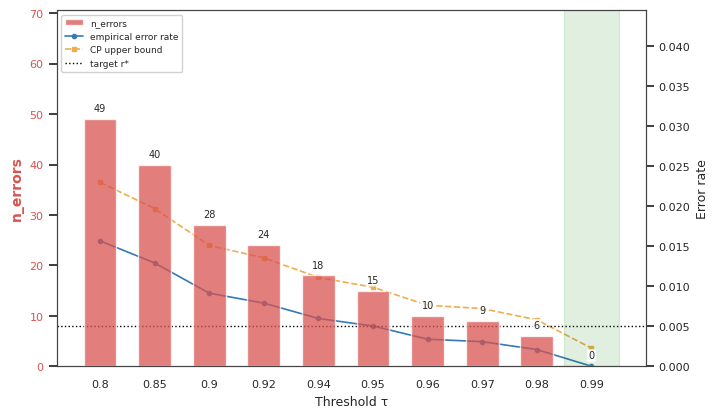

In [73]:
# ============================================================
# FIGURE — ERROR COUNT vs THRESHOLD (tau)  [fixed version]
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(7.2, 4.2))

taus = threshold_search_df["threshold_tau"]

# --- Left axis: n_errors (bar) ---
bars = ax1.bar(
    taus.astype(str),
    threshold_search_df["n_errors"],
    color="#d9534f",
    alpha=0.75,
    width=0.6,
    label="n_errors",
)
ax1.set_xlabel("Threshold τ", fontsize=9)
ax1.set_ylabel("n_errors", color="#d9534f", fontsize=10, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#d9534f", labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# extra headroom so bar-top numbers never collide with the line plot
max_err = threshold_search_df["n_errors"].max()
ax1.set_ylim(0, max_err * 1.4 + 2)

# annotate bar values INSIDE/just above each bar, with a white box
# so it never visually collides with the line markers behind it
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        zorder=10,
    )

# --- Right axis: empirical error rate & CP upper bound (line) ---
ax2 = ax1.twinx()
ax2.plot(
    taus.astype(str),
    threshold_search_df["empirical_conditional_error_rate"],
    marker="o", markersize=3, linewidth=1.2, color="#337ab7", label="empirical error rate",
)
ax2.plot(
    taus.astype(str),
    threshold_search_df["clopper_pearson_upper_bonferroni"],
    marker="s", markersize=3, linewidth=1.2, linestyle="--", color="#f0ad4e",
    label="CP upper bound",
)
ax2.axhline(
    TARGET_RISK_R_STAR, color="black", linestyle=":", linewidth=1, label="target r*",
)
ax2.set_ylabel("Error rate", fontsize=9)
ax2.tick_params(axis="y", labelsize=8)

# headroom on the line axis too, so markers sit clearly below bar-top labels
max_line_val = np.nanmax(
    threshold_search_df[
        ["empirical_conditional_error_rate", "clopper_pearson_upper_bonferroni"]
    ].values
)
ax2.set_ylim(0, max_line_val * 1.5 + 0.01)

# --- Fix twin-axes draw order: bring ax1 (bars + annotations) to the
#     front so line markers from ax2 never render on top of the numbers ---
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# --- Highlight selected/frozen tau ---
if selected_tau is not None:
    selected_idx = list(taus).index(selected_tau)
    ax1.axvspan(selected_idx - 0.5, selected_idx + 0.5, color="green", alpha=0.12)

# --- Combined legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper left", fontsize=6.5, framealpha=0.9,
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE AS PNG to /kaggle/working
# ------------------------------------------------------------
plt.savefig(
    "/kaggle/working/gate_threshold_search_figure.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [74]:
# ============================================================
# FINAL LOCKED-TEST EVALUATION — TREATMENT-RETRIEVAL GATE
#
# Threshold used: tau = 0.99 (FROZEN, selected earlier on
# model_validation_df — NOT re-selected, NOT tuned here).
#
# This cell performs exactly ONE evaluation of the locked test
# set. No search, no threshold sweep, no refitting.
# ============================================================

import json
import numpy as np
import pandas as pd
from scipy.stats import binomtest

# ------------------------------------------------------------
# 1. Frozen threshold — must match the value selected earlier
# ------------------------------------------------------------

FROZEN_RETRIEVAL_THRESHOLD = 0.99

if "CONFIG" in globals() and "retrieval_confidence_threshold" in CONFIG:
    if float(CONFIG["retrieval_confidence_threshold"]) != FROZEN_RETRIEVAL_THRESHOLD:
        raise RuntimeError(
            "Mismatch between frozen CONFIG threshold "
            f"({CONFIG['retrieval_confidence_threshold']}) and the value "
            f"used in this evaluation cell ({FROZEN_RETRIEVAL_THRESHOLD}). "
            "Resolve this before evaluating the locked test set."
        )


# ------------------------------------------------------------
# 2. Required-variable checks (locked-test outputs must already
#    exist from the Final Locked-Test section; nothing is
#    recomputed or retrained here)
# ------------------------------------------------------------

required_variables = [
    "test_true_labels",
    "test_predictions",
    "test_calibrated_probs",
    "class_thresholds",
    "build_prediction_sets",
    "NUM_DISEASES",
    "DIRS",
]

missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
    )


# ------------------------------------------------------------
# 3. Mondrian singleton sets on the locked test set
#    Reuse test_mondrian_set_sizes / test_mondrian_sets if they
#    already exist (Module 14A); otherwise build them from the
#    already-fitted class_thresholds. Either way, NOTHING is
#    refit here.
# ------------------------------------------------------------

test_probs_final = np.asarray(test_calibrated_probs, dtype=np.float64)
test_labels_final = np.asarray(test_true_labels, dtype=np.int64).reshape(-1)

n_test_total = int(len(test_labels_final))

if "test_mondrian_set_sizes" in globals() and "test_mondrian_sets" in globals():
    set_sizes_final = np.asarray(test_mondrian_set_sizes, dtype=np.int64)
    sets_final = test_mondrian_sets
else:
    sets_final = build_prediction_sets(
        probabilities=test_probs_final,
        thresholds=class_thresholds,
    )
    set_sizes_final = np.asarray([len(s) for s in sets_final], dtype=np.int64)

if len(set_sizes_final) != n_test_total:
    raise RuntimeError("Mondrian set-size array length does not match locked-test size.")

singleton_mask_final = set_sizes_final == 1
n_singleton_final = int(singleton_mask_final.sum())
singleton_rate_final = float(n_singleton_final / n_test_total)

singleton_class_final = np.asarray(
    [sets_final[i][0] if singleton_mask_final[i] else -1 for i in range(n_test_total)],
    dtype=np.int64,
)

row_idx_final = np.arange(n_test_total)

singleton_confidence_final = test_probs_final[
    row_idx_final, np.clip(singleton_class_final, 0, NUM_DISEASES - 1)
]

singleton_correct_final = (singleton_class_final == test_labels_final).astype(bool)


# ------------------------------------------------------------
# 4. Apply the FROZEN gate: singleton AND confidence >= tau
#    No tuning. tau is fixed above.
# ------------------------------------------------------------

retrieval_accepted_mask = singleton_mask_final & (
    singleton_confidence_final >= FROZEN_RETRIEVAL_THRESHOLD
)

n_accepted = int(retrieval_accepted_mask.sum())
acceptance_rate = float(n_accepted / n_test_total)

n_correct_accepted = int(singleton_correct_final[retrieval_accepted_mask].sum())
n_incorrect_accepted = int(n_accepted - n_correct_accepted)

conditional_error_rate = (
    float(n_incorrect_accepted / n_accepted) if n_accepted > 0 else float("nan")
)

if n_accepted > 0:
    cp_ci = binomtest(n_incorrect_accepted, n_accepted).proportion_ci(
        confidence_level=0.95, method="exact"
    )
    cp_low = float(cp_ci.low)
    cp_high = float(cp_ci.high)
else:
    cp_low = float("nan")
    cp_high = float("nan")


# ------------------------------------------------------------
# 5. Report
# ------------------------------------------------------------

print("=" * 80)
print("FINAL LOCKED-TEST EVALUATION — TREATMENT-RETRIEVAL GATE (tau = 0.99, FROZEN)")
print("=" * 80)
print(f"Total test cases:                 {n_test_total}")
print(f"Singleton cases:                  {n_singleton_final} ({singleton_rate_final:.4f})")
print(f"Retrieval-accepted cases:         {n_accepted} ({acceptance_rate:.4f})")
print(f"  Correct among accepted:         {n_correct_accepted}")
print(f"  Incorrect among accepted:       {n_incorrect_accepted}")
print(f"Conditional error rate:           {conditional_error_rate:.5f}")
print(f"Exact 95% Clopper-Pearson CI:     [{cp_low:.5f}, {cp_high:.5f}]")


# ------------------------------------------------------------
# 6. Save results (locked-test, one-time evaluation)
# ------------------------------------------------------------

locked_test_gate_results = {
    "frozen_threshold_tau": FROZEN_RETRIEVAL_THRESHOLD,
    "threshold_selected_on": "model_validation_df",
    "n_test_total": n_test_total,
    "n_singleton": n_singleton_final,
    "singleton_rate": singleton_rate_final,
    "n_retrieval_accepted": n_accepted,
    "retrieval_acceptance_rate": acceptance_rate,
    "n_correct_accepted": n_correct_accepted,
    "n_incorrect_accepted": n_incorrect_accepted,
    "conditional_error_rate": conditional_error_rate,
    "clopper_pearson_95_low": cp_low,
    "clopper_pearson_95_high": cp_high,
}

RESULTS_PATH = DIRS["results"] / "treatment_retrieval_gate" / "locked_test_gate_evaluation.json"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(locked_test_gate_results, f, indent=2)

print(f"\nSaved: {RESULTS_PATH}")

FINAL LOCKED-TEST EVALUATION — TREATMENT-RETRIEVAL GATE (tau = 0.99, FROZEN)
Total test cases:                 9435
Singleton cases:                  7747 (0.8211)
Retrieval-accepted cases:         6209 (0.6581)
  Correct among accepted:         6202
  Incorrect among accepted:       7
Conditional error rate:           0.00113
Exact 95% Clopper-Pearson CI:     [0.00045, 0.00232]

Saved: /kaggle/working/reliable_disease_framework/results/treatment_retrieval_gate/locked_test_gate_evaluation.json


In [77]:
# ============================================================
# TREATMENT KNOWLEDGE BASE — DATASET LOAD + EXACT-MATCH INDEX
#
# Stripped down from Modules 14B1-14B3 / 14B3b:
#   - Loads the reviewed treatment JSON
#   - Builds treatment_df + normalized_disease
#   - Builds the exact-match lookup index
#
# Removed on purpose:
#   - SapBERT semantic embeddings (unused by the frozen gate,
#     which only ever performs exact-name matching)
#   - PubMed corroboration (not part of the frozen decision)
# ============================================================

import json
import re
from pathlib import Path
import pandas as pd

TREATMENT_JSON_PATH = Path(
    "/kaggle/input/datasets/tahaminaakter12/treatment-info-new/disease_treatment_info_205_with_sources.json"
)

if not TREATMENT_JSON_PATH.exists():
    raise FileNotFoundError(f"Treatment JSON was not found:\n{TREATMENT_JSON_PATH}")

with open(TREATMENT_JSON_PATH, "r", encoding="utf-8") as file:
    treatment_data = json.load(file)

if not isinstance(treatment_data, list):
    raise TypeError("The treatment JSON root must be a list.")


def normalize_disease_name(value):
    text = str(value).strip().lower().replace("_", " ")
    return re.sub(r"\s+", " ", text).strip()


def clean_treatment_text(value):
    return re.sub(r"\s+", " ", str(value).strip()).strip()


treatment_df = pd.DataFrame(treatment_data)

required_columns = {"disease", "treatment"}
missing_columns = required_columns - set(treatment_df.columns)
if missing_columns:
    raise KeyError("Missing required JSON fields: " + ", ".join(sorted(missing_columns)))

treatment_df["disease"] = treatment_df["disease"].astype(str).str.strip()
treatment_df["treatment"] = treatment_df["treatment"].apply(clean_treatment_text)
treatment_df["normalized_disease"] = treatment_df["disease"].apply(normalize_disease_name)

if treatment_df["normalized_disease"].eq("").any():
    raise ValueError("Empty disease names found in the treatment knowledge base.")
if treatment_df["treatment"].eq("").any():
    raise ValueError("Empty treatment texts found in the treatment knowledge base.")

duplicate_mask = treatment_df["normalized_disease"].duplicated(keep=False)
if duplicate_mask.any():
    raise ValueError(
        "Duplicate disease entries detected:\n"
        + "\n".join(sorted(treatment_df.loc[duplicate_mask, "normalized_disease"].unique()))
    )

treatment_df.reset_index(drop=True, inplace=True)

# Exact-match lookup: normalized_disease -> row index
treatment_exact_index = {
    normalized_name: row_index
    for row_index, normalized_name in enumerate(treatment_df["normalized_disease"])
}

assert len(treatment_exact_index) == len(treatment_df), (
    "treatment_exact_index size does not match treatment_df rows."
)

print("Treatment knowledge base loaded:", len(treatment_df), "entries.")
print("Exact-match index built:", len(treatment_exact_index), "entries.")

Treatment knowledge base loaded: 205 entries.
Exact-match index built: 205 entries.


In [79]:
# ============================================================
# FINAL TREATMENT RETRIEVAL — FROZEN GATE
#
# Retrieval fires ONLY when:
#   Mondrian conformal set is a singleton
#   AND singleton calibrated confidence >= 0.99 (FROZEN)
#
# All other cases -> information-only / abstain.
# No tuning, no retraining, no threshold search here.
# ============================================================

import numpy as np

FROZEN_RETRIEVAL_THRESHOLD = 0.99

if "CONFIG" in globals() and "retrieval_confidence_threshold" in CONFIG:
    if float(CONFIG["retrieval_confidence_threshold"]) != FROZEN_RETRIEVAL_THRESHOLD:
        raise RuntimeError(
            "Mismatch between frozen CONFIG threshold "
            f"({CONFIG['retrieval_confidence_threshold']}) and the value "
            f"used here ({FROZEN_RETRIEVAL_THRESHOLD})."
        )

required_variables = [
    "test_mondrian_sets",
    "test_mondrian_set_sizes",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "index_to_disease",
    "treatment_df",
    "treatment_exact_index",
    "normalize_disease_name",
]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError("Missing required variables: " + ", ".join(missing_variables))

test_set_sizes_array = np.asarray(test_mondrian_set_sizes, dtype=np.int64).reshape(-1)
test_predictions_array = np.asarray(test_predictions, dtype=np.int64).reshape(-1)
test_true_labels_array = np.asarray(test_true_labels, dtype=np.int64).reshape(-1)
test_probs_array = np.asarray(test_calibrated_probs, dtype=np.float64)
number_of_rows = len(test_set_sizes_array)


def retrieve_exact_treatment(disease_name):
    normalized_name = normalize_disease_name(disease_name)
    if normalized_name not in treatment_exact_index:
        return {"found": False, "matched_disease": None, "treatment": None, "match_type": "not_found"}
    kb_row = treatment_df.iloc[int(treatment_exact_index[normalized_name])]
    return {
        "found": True,
        "matched_disease": str(kb_row["disease"]),
        "treatment": str(kb_row["treatment"]),
        "match_type": "exact_reviewed_match",
    }


def run_final_treatment_retrieval_for_row(row_index, verbose=False):
    row_index = int(row_index)
    if row_index < 0 or row_index >= number_of_rows:
        raise IndexError(f"row_index {row_index} outside valid range 0-{number_of_rows - 1}.")

    conformal_set = np.asarray(test_mondrian_sets[row_index], dtype=np.int64).reshape(-1)
    set_size = int(test_set_sizes_array[row_index])

    top1_class = int(test_predictions_array[row_index])
    true_class = int(test_true_labels_array[row_index])
    top1_disease = str(index_to_disease[top1_class])
    true_disease = str(index_to_disease[true_class])

    singleton_disease = None
    singleton_confidence = None
    singleton_correct = None
    retrieval_result = None
    treatment_gate_open = False
    treatment_retrieved = False

    if set_size == 0:
        decision = "ABSTAIN_EMPTY_SET"
        reason = "No disease was included in the Mondrian conformal prediction set."

    elif set_size > 1:
        decision = "ABSTAIN_MULTIPLE_SET"
        reason = "Multiple plausible diseases were included in the Mondrian conformal prediction set."

    else:
        singleton_class = int(conformal_set[0])
        singleton_disease = str(index_to_disease[singleton_class])
        singleton_confidence = float(test_probs_array[row_index, singleton_class])
        singleton_correct = bool(singleton_class == true_class)

        if singleton_confidence >= FROZEN_RETRIEVAL_THRESHOLD:
            treatment_gate_open = True
            retrieval_result = retrieve_exact_treatment(singleton_disease)

            if retrieval_result["found"]:
                treatment_retrieved = True
                decision = "TREATMENT_RETRIEVED"
                reason = (
                    "Singleton conformal set with calibrated confidence "
                    f">= {FROZEN_RETRIEVAL_THRESHOLD}, and an exact reviewed "
                    "treatment entry was found."
                )
            else:
                decision = "GATE_OPEN_TREATMENT_NOT_FOUND"
                reason = (
                    "Singleton conformal set with calibrated confidence "
                    f">= {FROZEN_RETRIEVAL_THRESHOLD}, but no exact reviewed "
                    "treatment entry was found."
                )
        else:
            decision = "ABSTAIN_LOW_CONFIDENCE_SINGLETON"
            reason = (
                "Singleton conformal set, but calibrated confidence "
                f"{singleton_confidence:.4f} is below the frozen gate "
                f"threshold {FROZEN_RETRIEVAL_THRESHOLD}."
            )

    output = {
        "row_index": row_index,
        "true_disease": true_disease,
        "predicted_disease": top1_disease,
        "prediction_correct": bool(top1_class == true_class),
        "conformal_set_size": set_size,
        "singleton_disease": singleton_disease,
        "singleton_calibrated_confidence": singleton_confidence,
        "singleton_disease_correct": singleton_correct,
        "treatment_gate_open": treatment_gate_open,
        "treatment_retrieved": treatment_retrieved,
        "retrieval_decision": decision,
        "retrieval_reason": reason,
        "retrieved_disease": retrieval_result["matched_disease"] if (retrieval_result and retrieval_result["found"]) else None,
        "retrieved_treatment": retrieval_result["treatment"] if (retrieval_result and retrieval_result["found"]) else None,
    }

    if verbose:
        print("=" * 80)
        print("FINAL TREATMENT RETRIEVAL (frozen gate, tau =", FROZEN_RETRIEVAL_THRESHOLD, ")")
        print("=" * 80)
        for key, value in output.items():
            print(f"{key}: {value}")

    return output


# Example: run on the first singleton case for a sanity check
singleton_indices = np.where(test_set_sizes_array == 1)[0]
if len(singleton_indices) == 0:
    raise RuntimeError("No singleton Mondrian cases were found.")

example_result = run_final_treatment_retrieval_for_row(
    row_index=int(singleton_indices[0]), verbose=True
)

FINAL TREATMENT RETRIEVAL (frozen gate, tau = 0.99 )
row_index: 1
true_disease: neuralgia
predicted_disease: neuralgia
prediction_correct: True
conformal_set_size: 1
singleton_disease: neuralgia
singleton_calibrated_confidence: 0.8964115381240845
singleton_disease_correct: True
treatment_gate_open: False
treatment_retrieved: False
retrieval_decision: ABSTAIN_LOW_CONFIDENCE_SINGLETON
retrieval_reason: Singleton conformal set, but calibrated confidence 0.8964 is below the frozen gate threshold 0.99.
retrieved_disease: None
retrieved_treatment: None


In [80]:
# ============================================================
# FINAL MAIN-DESIGN CELL — SINGLE-PATIENT INFERENCE + OUTPUT
#
# Pipeline (frozen — no retraining / retuning / threshold changes):
#   1. Predict the disease            -> flat_model + LEARNED_TEMPERATURE
#   2. Build the Mondrian conformal
#      prediction set                 -> class_thresholds,
#                                         build_prediction_sets()
#   3. Branch on conformal-set cardinality:
#        Empty     -> abstain, clinician referral, NO treatment
#        Singleton -> disease + calibrated confidence + XAI
#                     (SHAP = patient-facing, LIG = independent
#                     cross-check, exactly as already implemented
#                     in Modules 13B-13E). Treatment is retrieved
#                     ONLY if calibrated confidence >= the frozen
#                     gate threshold tau = 0.99; otherwise all other
#                     information is still shown, but no treatment,
#                     and clinician review is recommended.
#        Multiple  -> full conformal disease set, ranked by
#                     calibrated confidence, with XAI for the
#                     TOP-RANKED disease only. NO treatment is ever
#                     provided in this branch; clinician review is
#                     recommended.
#   4. Every branch ends with the fixed safety disclaimer.
#
# Reuses ONLY already-fitted / already-frozen pipeline components:
#   flat_model, LEARNED_TEMPERATURE, class_thresholds,
#   build_prediction_sets(), test_mondrian_sets / test_mondrian_set_sizes,
#   explain_patient_with_lig(), build_shap_word_table_for_row(),
#   partition_shap_explainer, build_phrase_level_attributions(),
#   retrieve_exact_treatment(), treatment_df, treatment_exact_index,
#   FROZEN_RETRIEVAL_THRESHOLD (= 0.99, frozen earlier via SGR/RCPS
#   selection on model_validation_df).
#
# No retraining. No retuning. No threshold is changed anywhere
# in this cell.
# ============================================================

import io
import contextlib
import numpy as np
import pandas as pd

SAFETY_DISCLAIMER = (
    "This system is intended for decision support and is not a "
    "diagnostic tool. The output should be interpreted as "
    "decision-support information and verified by a qualified "
    "healthcare professional before clinical use."
)

MULTIPLE_SET_CLOSING_NOTE = (
    "More than one possible disease was identified. The most likely "
    "disease and its supporting symptoms are shown. Further clinical "
    "assessment is recommended."
)

# ------------------------------------------------------------
# 0. Required-variable checks. Nothing below is recomputed,
#    refit, or retrained — every object here must already exist
#    from earlier (already-run) cells in this notebook.
# ------------------------------------------------------------

required_variables = [
    "test_locked_df",
    "test_predictions",
    "test_true_labels",
    "test_calibrated_probs",
    "test_mondrian_sets",
    "test_mondrian_set_sizes",
    "index_to_disease",
    "class_thresholds",
    "flat_model",
    "tokenizer",
    "LEARNED_TEMPERATURE",
    "CONFIG",
    "explain_patient_with_lig",
    "build_shap_word_table_for_row",
    "build_phrase_level_attributions",
    "partition_shap_explainer",
    "treatment_df",
    "treatment_exact_index",
    "normalize_disease_name",
    "retrieve_exact_treatment",
    "FROZEN_RETRIEVAL_THRESHOLD",
]

missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
        + ". Run the earlier modules (prediction, Mondrian calibration, "
        "LIG/SHAP setup, treatment knowledge base, frozen retrieval gate) "
        "before running this cell."
    )


# ------------------------------------------------------------
# 1. SELECT ONE PATIENT / INPUT
#
# PATIENT_ROW_INDEX identifies one patient from the frozen locked
# test set (test_locked_df). Change this single value to run the
# pipeline on a different patient — nothing else in this cell needs
# to change.
# ------------------------------------------------------------

PATIENT_ROW_INDEX = 0

number_of_test_rows = int(len(test_locked_df))

if not (0 <= PATIENT_ROW_INDEX < number_of_test_rows):
    raise IndexError(
        f"PATIENT_ROW_INDEX must be between 0 and {number_of_test_rows - 1}."
    )

patient_text = str(
    test_locked_df.iloc[PATIENT_ROW_INDEX]["symptom_text"]
)


# ------------------------------------------------------------
# 2. STEP 1 — PREDICT THE DISEASE
# (already-frozen flat-model top-1 prediction, reused as-is)
# ------------------------------------------------------------

predicted_class = int(test_predictions[PATIENT_ROW_INDEX])
predicted_disease = str(index_to_disease[predicted_class])
predicted_confidence = float(
    test_calibrated_probs[PATIENT_ROW_INDEX, predicted_class]
)


# ------------------------------------------------------------
# 3. STEP 2 — BUILD THE MONDRIAN CONFORMAL PREDICTION SET
# (already-frozen class_thresholds, reused as-is)
# ------------------------------------------------------------

conformal_set = np.asarray(
    test_mondrian_sets[PATIENT_ROW_INDEX], dtype=np.int64
).reshape(-1)

conformal_set_size = int(test_mondrian_set_sizes[PATIENT_ROW_INDEX])

ranked_conformal_diseases = sorted(
    (
        (
            int(class_index),
            str(index_to_disease[int(class_index)]),
            float(test_calibrated_probs[PATIENT_ROW_INDEX, int(class_index)]),
        )
        for class_index in conformal_set
    ),
    key=lambda record: record[2],
    reverse=True,
)

# Patient-facing disease prediction set: a single disease name when
# the conformal set is a singleton, or a list of disease names when
# it contains multiple plausible diseases.
if conformal_set_size == 1:
    disease_prediction_set_display = ranked_conformal_diseases[0][1]
else:
    disease_prediction_set_display = [
        disease_name for _, disease_name, _ in ranked_conformal_diseases
    ]


# ------------------------------------------------------------
# HELPER — SHAP + LIG explanation for one (row, target-class)
# pair. SHAP is the patient-facing attribution (Modules 13C-13E);
# LIG is retained only as an independent cross-check flag, exactly
# as already established earlier in the notebook. This helper
# reuses the already-initialized layer_integrated_gradients /
# partition_shap_explainer objects and only lets the target CLASS
# vary — the same mechanism already used in Module 13C
# (partition_shap_explainer(..., outputs=[class])). It introduces
# no new explainer, no new model, and no new threshold.
# ------------------------------------------------------------

def explain_disease_for_patient(
    row_index,
    target_class,
    lig_steps=64,
    shap_max_evals=300,
):
    row_index = int(row_index)
    target_class = int(target_class)

    with contextlib.redirect_stdout(io.StringIO()):
        lig_result_local = explain_patient_with_lig(
            row_index=row_index,
            n_steps=int(lig_steps),
            target_class=target_class,
        )

    text_for_row = str(lig_result_local["patient_text"])

    # Reuse the existing reusable helper directly when explaining
    # the model's own top-1 class (the common case, identical to
    # Module 13G-FULL's usage).
    if target_class == int(test_predictions[row_index]):

        _, shap_words = build_shap_word_table_for_row(
            row_index=row_index,
            max_evals=int(shap_max_evals),
        )

    else:
        # Same Partition SHAP mechanism as build_shap_word_table_for_row
        # (Modules 13C/13D), applied to a non-top-1 conformal-set class
        # using the already-fitted partition_shap_explainer.
        with contextlib.redirect_stdout(io.StringIO()):
            explanation = partition_shap_explainer(
                [text_for_row],
                outputs=[target_class],
                max_evals=int(shap_max_evals),
                batch_size=8,
            )

        shap_values = np.asarray(explanation.values[0]).squeeze()
        if shap_values.ndim != 1:
            shap_values = shap_values.reshape(-1)

        shap_tokens = np.asarray(
            explanation.data[0], dtype=object
        ).reshape(-1)

        usable_length = min(len(shap_tokens), len(shap_values))
        shap_tokens = shap_tokens[:usable_length]
        shap_values = shap_values[:usable_length]

        valid_mask = np.asarray(
            [str(token).strip() != "" for token in shap_tokens],
            dtype=bool,
        )
        shap_tokens = shap_tokens[valid_mask]
        shap_values = shap_values[valid_mask]

        offset_encoded = tokenizer(
            text_for_row,
            truncation=True,
            max_length=int(CONFIG["max_length"]),
            return_offsets_mapping=True,
            add_special_tokens=True,
        )
        all_offsets = np.asarray(
            offset_encoded["offset_mapping"], dtype=np.int64
        )
        valid_offset_mask = np.asarray(
            [int(end) > int(start) for start, end in all_offsets],
            dtype=bool,
        )
        content_offsets = all_offsets[valid_offset_mask]

        if len(shap_values) != len(content_offsets):
            raise RuntimeError(
                "SHAP-token count does not match tokenizer offset count "
                f"for row_index={row_index}, target_class={target_class}."
            )

        shap_offset_records = []
        for attribution, offsets in zip(shap_values, content_offsets):
            start = int(offsets[0])
            end = int(offsets[1])
            shap_offset_records.append(
                {
                    "char_start": start,
                    "char_end": end,
                    "shap_attribution": float(attribution),
                }
            )
        shap_offset_table = pd.DataFrame(shap_offset_records)

        shap_word_records = []
        current_word = None

        for row in shap_offset_table.itertuples(index=False):
            start = int(row.char_start)
            end = int(row.char_end)
            value = float(row.shap_attribution)

            if current_word is None:
                current_word = {
                    "char_start": start,
                    "char_end": end,
                    "shap_attribution": value,
                }
                continue

            gap_text = text_for_row[current_word["char_end"]:start]
            same_surface_word = (
                start <= current_word["char_end"]
                or (
                    start == current_word["char_end"]
                    and not gap_text.isspace()
                )
            )

            if same_surface_word:
                current_word["char_end"] = max(current_word["char_end"], end)
                current_word["shap_attribution"] += value
            else:
                current_word["word"] = text_for_row[
                    current_word["char_start"]:current_word["char_end"]
                ]
                shap_word_records.append(current_word)
                current_word = {
                    "char_start": start,
                    "char_end": end,
                    "shap_attribution": value,
                }

        if current_word is not None:
            current_word["word"] = text_for_row[
                current_word["char_start"]:current_word["char_end"]
            ]
            shap_word_records.append(current_word)

        shap_words = pd.DataFrame(shap_word_records)

        if len(shap_words) == 0:
            shap_words = pd.DataFrame(
                columns=[
                    "char_start", "char_end", "word",
                    "shap_attribution", "absolute_shap_attribution",
                    "normalized_shap_attribution",
                ]
            )
        else:
            shap_words["absolute_shap_attribution"] = (
                shap_words["shap_attribution"].abs()
            )
            total_abs = float(shap_words["absolute_shap_attribution"].sum())
            if total_abs > 1e-12:
                shap_words["normalized_shap_attribution"] = (
                    shap_words["shap_attribution"] / total_abs
                )
            else:
                shap_words["normalized_shap_attribution"] = 0.0
            shap_words = (
                shap_words.sort_values("char_start").reset_index(drop=True)
            )

    lig_words = (
        lig_result_local["word_table"][
            [
                "char_start", "char_end", "word",
                "lig_attribution", "normalized_attribution",
            ]
        ]
        .rename(columns={"normalized_attribution": "normalized_lig_attribution"})
        .copy()
    )

    alignment = pd.merge(
        lig_words,
        shap_words[
            [
                "char_start", "char_end",
                "shap_attribution", "normalized_shap_attribution",
            ]
        ],
        on=["char_start", "char_end"],
        how="outer",
    )

    alignment["word"] = alignment.apply(
        lambda row: (
            row["word"] if pd.notna(row["word"])
            else text_for_row[int(row["char_start"]):int(row["char_end"])]
        ),
        axis=1,
    )

    for column in [
        "lig_attribution", "normalized_lig_attribution",
        "shap_attribution", "normalized_shap_attribution",
    ]:
        alignment[column] = alignment[column].fillna(0.0).astype(float)

    alignment = alignment.sort_values("char_start").reset_index(drop=True)

    phrase_table = build_phrase_level_attributions(
        alignment_table=alignment,
        original_text=text_for_row,
    )

    return {
        "row_index": row_index,
        "target_class": target_class,
        "target_disease": str(index_to_disease[target_class]),
        "phrase_table": phrase_table,
    }


def display_xai_contribution(xai_result, top_n=8):
    """
    Patient-friendly XAI display — mirrors the exact reporting
    format already used in Module 13E (SHAP-based, LIG as an
    independent agreement cross-check only).
    """

    phrase_table = xai_result["phrase_table"]

    print(f"\nXAI contribution for: {xai_result['target_disease']}")

    if phrase_table is None or len(phrase_table) == 0:
        print("- No phrase-level attribution could be computed for this case.")
        return

    supporting_phrases = phrase_table[phrase_table["direction"] == "supports"].head(top_n)
    opposing_phrases = phrase_table[phrase_table["direction"] == "opposes"].head(top_n)

    print("\nSupporting phrases:")

    if len(supporting_phrases) == 0:
        print("- No supporting phrase identified.")
    else:
        for rank, row in enumerate(supporting_phrases.itertuples(), start=1):
            agreement_note = "LIG agrees" if row.ig_shap_agreement else "LIG disagrees"
            print(
                f"{rank}. {row.phrase} "
                f"({row.relative_attribution_percent:.1f}% relative attribution, "
                f"{agreement_note})"
            )

    print("\nOpposing phrases:")

    if len(opposing_phrases) == 0:
        print("- No opposing phrase identified.")
    else:
        for rank, row in enumerate(opposing_phrases.itertuples(), start=1):
            agreement_note = "LIG agrees" if row.ig_shap_agreement else "LIG disagrees"
            print(
                f"{rank}. {row.phrase} "
                f"({row.relative_attribution_percent:.1f}% relative attribution, "
                f"{agreement_note})"
            )


def display_disease_ranking(ranked_diseases):
    """
    Patient-friendly ranked-disease display for the multiple-set
    branch, e.g.:
        1. Asthma — 77.13% confidence
        2. Acute bronchitis — 20.36% confidence
    """

    print("\nPredicted disease ranking:")

    for rank, (class_index, disease_name, confidence) in enumerate(
        ranked_diseases, start=1
    ):
        print(f"{rank}. {disease_name} — {confidence * 100:.2f}% confidence")


# ============================================================
# STEP 3 — BRANCH ON MONDRIAN CONFORMAL SET CARDINALITY
# ============================================================

print("=" * 80)
print("PATIENT REPORT")
print("=" * 80)
print(f"Patient symptom text: {patient_text}")
print(f"\nModel top-1 predicted disease: {predicted_disease}")
print(f"Model top-1 calibrated confidence: {predicted_confidence:.4f}")
print(f"\nDisease prediction set: {disease_prediction_set_display}")

if conformal_set_size == 0:

    # --------------------------------------------------------
    # EMPTY SET
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: EMPTY CONFORMAL SET")
    print("-" * 80)
    print(
        "No disease met the required calibrated-confidence level for "
        "this patient's symptoms under the frozen Mondrian conformal "
        "thresholds. The model is NOT sufficiently confident in any "
        "single disease (or small set of diseases) to support a "
        "decision-support output for this patient."
    )
    print("\nRecommendation: refer this case to a clinician for direct evaluation.")
    print("No treatment is provided.")

elif conformal_set_size == 1:

    # --------------------------------------------------------
    # SINGLETON SET
    # --------------------------------------------------------

    singleton_class, singleton_disease, singleton_confidence = (
        ranked_conformal_diseases[0]
    )

    print("\n" + "-" * 80)
    print("RESULT: SINGLETON CONFORMAL SET")
    print("-" * 80)
    print(f"Predicted disease: {singleton_disease}")
    print(f"Calibrated confidence: {singleton_confidence:.4f}")

    singleton_xai = explain_disease_for_patient(
        row_index=PATIENT_ROW_INDEX,
        target_class=singleton_class,
    )
    display_xai_contribution(singleton_xai)

    if singleton_confidence >= FROZEN_RETRIEVAL_THRESHOLD:

        retrieval_result = retrieve_exact_treatment(singleton_disease)

        if retrieval_result["found"]:
            print(f"\nTreatment: {retrieval_result['treatment']}")
        else:
            print(
                "\nNo doctor-reviewed treatment entry was found in the "
                "knowledge base for this disease."
            )
            print("No treatment is provided. Recommend clinician review.")

    else:
        print(
            f"\nCalibrated confidence {singleton_confidence:.4f} is BELOW the "
            f"frozen treatment threshold (tau = {FROZEN_RETRIEVAL_THRESHOLD}). "
            "All other information above is shown, but no treatment is "
            "provided."
        )
        print("Recommendation: clinician review.")

else:

    # --------------------------------------------------------
    # MULTIPLE-DISEASE SET
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: MULTIPLE-DISEASE CONFORMAL SET")
    print("-" * 80)
    print(f"Number of plausible diseases in the conformal set: {conformal_set_size}")

    display_disease_ranking(ranked_conformal_diseases)

    top_ranked_class, top_ranked_disease, top_ranked_confidence = (
        ranked_conformal_diseases[0]
    )

    print(f"\nXAI is provided for the TOP-RANKED disease only: {top_ranked_disease}")

    multiple_set_xai = explain_disease_for_patient(
        row_index=PATIENT_ROW_INDEX,
        target_class=top_ranked_class,
    )
    display_xai_contribution(multiple_set_xai)

    print(f"\n{MULTIPLE_SET_CLOSING_NOTE}")


# ------------------------------------------------------------
# FINAL SAFETY NOTE (shown for every branch)
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(SAFETY_DISCLAIMER)
print("=" * 80)

PATIENT REPORT
Patient symptom text: cough, coughing up sputum, difficulty breathing, fever, sharp chest pain, wheezing

Model top-1 predicted disease: asthma
Model top-1 calibrated confidence: 0.7713

Disease prediction set: ['asthma', 'acute bronchitis']

--------------------------------------------------------------------------------
RESULT: MULTIPLE-DISEASE CONFORMAL SET
--------------------------------------------------------------------------------
Number of plausible diseases in the conformal set: 2

Predicted disease ranking:
1. asthma — 77.13% confidence
2. acute bronchitis — 20.36% confidence

XAI is provided for the TOP-RANKED disease only: asthma

XAI contribution for: asthma

Supporting phrases:
1. coughing up sputum (69.0% relative attribution, LIG agrees)
2. wheezing (10.5% relative attribution, LIG agrees)
3. difficulty breathing (6.2% relative attribution, LIG agrees)
4. fever (2.6% relative attribution, LIG agrees)

Opposing phrases:
1. sharp chest pain (6.2% relative

In [81]:
!apt-get update && apt-get install -y zstd

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease   
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease                        
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]       
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [114 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [359 B]      
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packa

In [82]:
# 1. Install Ollama inside the Kaggle environment
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%#####################                           66.6%#####################################                   76.6%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [83]:
import subprocess
import time

# 1. Start the 'ollama serve' command in the background
# We use 'nohup' so it doesn't stop if the cell finishes running
subprocess.Popen("nohup ollama serve > /tmp/ollama.log 2>&1 &", shell=True)

# 2. Wait for the server to wake up
print("Starting Ollama server...")
time.sleep(10) 
print("Server should be ready!")

Starting Ollama server...
Server should be ready!


In [87]:
!pip install ollama

In [89]:
!ollama pull deepseek-r1:8b

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest 
pulling e6a7edc1a4d7:   0% ▕                  ▏  13 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   1% ▕                  ▏  51 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   3% ▕                  ▏ 133 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   4% ▕                  ▏ 220 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   5% ▕                  ▏ 258 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   6% ▕█                 ▏ 321 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   7% ▕█                 ▏ 380 MB/5.2 GB                  pulling manifest 
pulling e6a7edc1a4d7:   8% ▕█                 ▏ 411 MB/5.2 GB      

In [90]:
# ============================================================
# SHAP XAI CONTRIBUTION (NO SUPPORT/OPPOSE SPLIT, NO LIG)
# + DEEPSEEK EXPLANATION (SHAP-grounded natural explanation)
# ============================================================

import re
import io
import contextlib
import html
import numpy as np
import pandas as pd
import ollama

from IPython.display import display, HTML

DEEPSEEK_XAI_MODEL = "deepseek-r1:8b"


# ------------------------------------------------------------
# 1. REQUIRED OBJECTS
# ------------------------------------------------------------

required_variables = [
    "test_locked_df",
    "test_predictions",
    "test_calibrated_probs",
    "index_to_disease",
    "build_shap_word_table_for_row",
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + ". Run the earlier SHAP setup "
        "(partition_shap_explainer, "
        "build_shap_word_table_for_row) first."
    )


# ------------------------------------------------------------
# 2. SHAP-ONLY PHRASE-LEVEL CONTRIBUTION
# ------------------------------------------------------------

def build_shap_phrase_contribution(word_table, original_text):
    """
    Groups SHAP word-level attributions into
    punctuation-delimited phrases and ranks them
    by contribution magnitude only.

    No support/oppose direction.
    No LIG.
    """

    table = (
        word_table
        .sort_values("char_start")
        .reset_index(drop=True)
        .copy()
    )

    phrase_spans = []
    phrase_start = 0

    for match in re.finditer(r"[,;.!?]+", original_text):

        phrase_end = match.start()

        if phrase_end > phrase_start:

            raw_phrase = original_text[
                phrase_start:phrase_end
            ]

            left_trim = (
                len(raw_phrase)
                - len(raw_phrase.lstrip())
            )

            right_trimmed = raw_phrase.rstrip()

            clean_start = (
                phrase_start + left_trim
            )

            clean_end = (
                phrase_start
                + len(right_trimmed)
            )

            if clean_end > clean_start:

                phrase_spans.append({
                    "char_start": clean_start,
                    "char_end": clean_end,
                    "phrase": original_text[
                        clean_start:clean_end
                    ],
                })

        phrase_start = match.end()

    if phrase_start < len(original_text):

        raw_phrase = original_text[
            phrase_start:
        ]

        left_trim = (
            len(raw_phrase)
            - len(raw_phrase.lstrip())
        )

        right_trimmed = raw_phrase.rstrip()

        clean_start = (
            phrase_start + left_trim
        )

        clean_end = (
            phrase_start
            + len(right_trimmed)
        )

        if clean_end > clean_start:

            phrase_spans.append({
                "char_start": clean_start,
                "char_end": clean_end,
                "phrase": original_text[
                    clean_start:clean_end
                ],
            })

    phrase_records = []

    for phrase_span in phrase_spans:

        phrase_start = int(
            phrase_span["char_start"]
        )

        phrase_end = int(
            phrase_span["char_end"]
        )

        phrase_words = table[
            (table["char_end"] > phrase_start)
            & (table["char_start"] < phrase_end)
        ]

        if len(phrase_words) == 0:
            continue

        shap_score = float(
            phrase_words[
                "shap_attribution"
            ].sum()
        )

        phrase_records.append({
            "phrase": phrase_span["phrase"],
            "char_start": phrase_start,
            "char_end": phrase_end,
            "word_count": int(
                len(phrase_words)
            ),
            "contribution_magnitude": abs(
                shap_score
            ),
        })

    phrase_table = pd.DataFrame(
        phrase_records
    )

    if len(phrase_table) == 0:
        return phrase_table

    total_magnitude = float(
        phrase_table[
            "contribution_magnitude"
        ].sum()
    )

    if total_magnitude > 1e-12:

        phrase_table[
            "relative_attribution_percent"
        ] = (
            phrase_table[
                "contribution_magnitude"
            ]
            / total_magnitude
            * 100.0
        )

    else:

        phrase_table[
            "relative_attribution_percent"
        ] = 0.0

    return (
        phrase_table
        .sort_values(
            "contribution_magnitude",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 3. CLEAN DEEPSEEK OUTPUT
# ------------------------------------------------------------

def clean_deepseek_text(text):

    cleaned_text = str(text).strip()

    # Remove hidden reasoning
    cleaned_text = re.sub(
        r"<think>.*?</think>",
        "",
        cleaned_text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    # Remove accidental markdown headings
    cleaned_text = re.sub(
        r"^\s*#+\s*",
        "",
        cleaned_text,
    )

    # Remove accidental bullets
    cleaned_text = re.sub(
        r"^\s*[-*•]\s*",
        "",
        cleaned_text,
    )

    # Remove common casual openers
    cleaned_text = re.sub(
        r"^(okay|ok|sure|alright|well|so)[,.\s]+",
        "",
        cleaned_text,
        flags=re.IGNORECASE,
    )

    # Normalize whitespace
    cleaned_text = re.sub(
        r"\s+",
        " ",
        cleaned_text,
    )

    return cleaned_text.strip()


# ------------------------------------------------------------
# 4. PHRASE TABLE -> PROMPT TEXT
# ------------------------------------------------------------

def phrase_table_to_prompt_text(phrase_df):

    if (
        phrase_df is None
        or len(phrase_df) == 0
    ):

        return (
            "Contributing symptom phrases "
            "(ranked from highest to lowest "
            "contribution): None identified."
        )

    phrase_lines = []

    for rank, row in enumerate(
        phrase_df.itertuples(index=False),
        start=1
    ):

        attribution_text = format(
            float(
                row.relative_attribution_percent
            ),
            ".1f"
        )

        phrase_lines.append(
            f"{rank}. {row.phrase}: "
            f"{attribution_text}%"
        )

    return (
        "Contributing symptom phrases "
        "(ranked from highest to lowest "
        "contribution):\n"
        + "\n".join(phrase_lines)
    )


# ------------------------------------------------------------
# 5. DEEPSEEK XAI EXPLANATION
# ------------------------------------------------------------

def generate_deepseek_xai_explanation(
    patient_text,
    explained_disease,
    phrase_table
):

    phrase_text = (
        phrase_table_to_prompt_text(
            phrase_table
        )
    )

    phrase_count = (
        0
        if phrase_table is None
        else len(phrase_table)
    )

    prompt = """
You are generating a natural-language explanation
of a clinical-text disease-classification model's
prediction.

Your explanation must be grounded in the supplied
patient symptom text, predicted disease, and SHAP
attribution evidence.

Patient symptom text:
{patient_text}

Predicted disease:
{explained_disease}

{phrase_text}

The percentages represent the relative SHAP
contribution magnitude of the supplied symptom
phrases to the model's prediction.

A larger percentage means that the phrase had a
greater relative influence on the model's decision.
A smaller percentage means that it had less relative
influence.

Task:

Write a short, natural, human-friendly explanation
of the model's prediction.

Start by stating that the model predicted the
specified disease based on the symptom text input.

Then explain naturally which symptoms had the
greatest influence, which had smaller influence,
and which had the least influence.

Include the supplied percentage for every symptom.

The explanation should sound like a person explaining
what influenced the model's decision rather than
simply reading a ranked table.

You may briefly summarize the overall pattern of
the model's decision, but remain grounded in the
supplied SHAP evidence.

Do not create new clinical reasoning.

Important phrase-preservation rules:

- Preserve every symptom phrase EXACTLY as it
  appears in the supplied SHAP phrase list.

- Do not split multi-word symptom phrases.

- Do not insert words inside a symptom phrase.

- Do not remove words from a symptom phrase.

- Do not replace a phrase with a synonym.

- Do not paraphrase symptom phrases.

- Each symptom phrase must appear as one continuous
  phrase.

- Keep all words within each symptom phrase together
  and in the same order.

- Do not hyphenate or otherwise alter multi-word
  symptom phrases.

Strict rules:

1. Start directly with the prediction.

2. Mention every supplied symptom phrase at least once.

3. Preserve the exact wording of every supplied
   symptom phrase.

4. Preserve the SHAP ranking.

5. The highest-percentage phrase must be described
   as having the greatest or strongest influence.

6. Lower-ranked phrases must be described as having
   comparatively smaller influence.

7. Include the actual SHAP percentage for every
   phrase.

8. Do not change, reinterpret, or recalculate any
   supplied attribution percentage.

9. Use natural wording and vary sentence structure.

10. Avoid repeatedly writing exactly
    "X contributed Y%" for every symptom.

11. Use simple language that a general reader
    can understand.

12. Do not simply reproduce the ranked list.
    Turn the information into a coherent short
    explanation.

13. Do not introduce any new symptom, patient
    information, disease, cause, treatment, or
    unrelated medical fact.

14. Do not claim that any symptom is clinically
    characteristic, diagnostic, typical, common,
    causal, or medically associated with the
    predicted disease unless that information is
    explicitly supplied.

15. Do not infer a clinical relationship between
    symptoms. Only describe their relative influence
    on the model's prediction according to the
    supplied SHAP evidence.

16. Do not provide another diagnosis.

17. Do not provide treatment recommendations or
    medical advice.

18. Do not claim that the explanation proves or
    clinically validates the predicted disease.

19. Do not use headings, bullet points, JSON,
    hidden reasoning, or disclaimers.

20. Return only the explanation as normal
    continuous prose.

21. There are exactly {phrase_count} supplied
    symptom phrases. Your explanation must account
    for all {phrase_count} phrases.
""".format(
        patient_text=str(patient_text),
        explained_disease=str(explained_disease),
        phrase_text=phrase_text,
        phrase_count=phrase_count,
    ).strip()

    try:

        response = ollama.chat(
            model=DEEPSEEK_XAI_MODEL,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            options={
                "temperature": 0
            },
        )

        explanation = clean_deepseek_text(
            response["message"]["content"]
        )

        # Preserve exact symptom phrases
        # after generation.
        if (
            phrase_table is not None
            and len(phrase_table) > 0
        ):

            original_phrases = [
                str(p).strip()
                for p in phrase_table[
                    "phrase"
                ].tolist()
                if str(p).strip()
            ]

            # Remove unnecessary quotation marks
            # around complete symptom phrases.
            for phrase in sorted(
                original_phrases,
                key=len,
                reverse=True
            ):

                escaped_phrase = re.escape(
                    phrase
                )

                explanation = re.sub(
                    rf"""['"]\s*(
                        {escaped_phrase}
                    )\s*['"]""",
                    r"\1",
                    explanation,
                    flags=(
                        re.IGNORECASE
                        | re.VERBOSE
                    ),
                )

        explanation = re.sub(
            r"\s+",
            " ",
            explanation
        ).strip()

        return (
            explanation
            if explanation
            else (
                "DeepSeek XAI explanation "
                "was not available."
            )
        )

    except Exception as error:

        return (
            "DeepSeek XAI explanation could "
            "not be generated "
            f"({type(error).__name__})."
        )


# ------------------------------------------------------------
# 6. PRINT SHAP CONTRIBUTION
# ------------------------------------------------------------

def print_phrase_contribution(phrase_df):

    if (
        phrase_df is None
        or len(phrase_df) == 0
    ):

        print(
            "- No contributing phrase identified."
        )

        return

    for rank, row in enumerate(
        phrase_df.itertuples(index=False),
        start=1
    ):

        attribution_text = format(
            float(
                row.relative_attribution_percent
            ),
            ".1f"
        )

        print(
            f"{rank}. {row.phrase} "
            f"— {attribution_text}%"
        )


# ------------------------------------------------------------
# 7. RUN
# ------------------------------------------------------------

PATIENT_ROW_INDEX = 0

patient_text = str(
    test_locked_df.iloc[
        PATIENT_ROW_INDEX
    ]["symptom_text"]
)

predicted_class = int(
    test_predictions[
        PATIENT_ROW_INDEX
    ]
)

predicted_disease = str(
    index_to_disease[
        predicted_class
    ]
)

predicted_confidence = float(
    test_calibrated_probs[
        PATIENT_ROW_INDEX,
        predicted_class
    ]
)

with contextlib.redirect_stdout(
    io.StringIO()
):

    _, shap_word_table = (
        build_shap_word_table_for_row(
            row_index=PATIENT_ROW_INDEX,
            max_evals=500,
        )
    )

xai_phrase_table = (
    build_shap_phrase_contribution(
        word_table=shap_word_table,
        original_text=patient_text,
    )
)


# ------------------------------------------------------------
# 8. PRINT SHAP RESULTS
# ------------------------------------------------------------

print("=" * 80)
print("SHAP XAI CONTRIBUTION")
print("=" * 80)

print(
    "Predicted disease:",
    predicted_disease
)

print(
    "Calibrated confidence:",
    f"{predicted_confidence:.4f}"
)

print("\nContributing phrases:")

print_phrase_contribution(
    xai_phrase_table
)


# ------------------------------------------------------------
# 9. GENERATE DEEPSEEK EXPLANATION
# ------------------------------------------------------------

deepseek_xai_explanation = (
    generate_deepseek_xai_explanation(
        patient_text=patient_text,
        explained_disease=predicted_disease,
        phrase_table=xai_phrase_table,
    )
)


# ------------------------------------------------------------
# 10. DISPLAY DEEPSEEK EXPLANATION
#     Prevent awkward visual word breaking
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("DeepSeek XAI explanation:")
print("-" * 80)

# Escape HTML-sensitive characters first
safe_explanation = html.escape(
    deepseek_xai_explanation
)

# Display as continuous natural prose
# without forced word breaking.
display(
    HTML(
        f"""
        <div style="
            font-family: Arial, sans-serif;
            font-size: 14px;
            line-height: 1.65;
            white-space: normal;
            overflow-wrap: normal;
            word-break: normal;
            max-width: 1100px;
        ">
            {safe_explanation}
        </div>
        """
    )
)

SHAP XAI CONTRIBUTION
Predicted disease: asthma
Calibrated confidence: 0.7713

Contributing phrases:
1. coughing up sputum — 69.0%
2. wheezing — 10.5%
3. sharp chest pain — 6.2%
4. difficulty breathing — 6.2%
5. cough — 5.6%
6. fever — 2.6%

--------------------------------------------------------------------------------
DeepSeek XAI explanation:
--------------------------------------------------------------------------------


In [91]:
# ============================================================
# COMBINED CELL — GENERATE 100 DEEPSEEK EXPLANATIONS
# + CORRECTED EVALUATION (3 METRICS TOGETHER)
#   1. Top-K Phrase Coverage (exact match)
#   2. Numeric Attribution Fidelity (percentage-level, exact-matched)
#   3. Attribution Hallucination Rate (percentage-level, exact-matched)
# ============================================================

import re
import io
import html
import contextlib
import json
import numpy as np
import pandas as pd
import ollama
from pathlib import Path

DEEPSEEK_XAI_MODEL = "deepseek-r1:8b"

results_dir = Path(DIRS["results"])
results_dir.mkdir(parents=True, exist_ok=True)
generation_output_path = results_dir / "deepseek_xai_evaluation_generation.csv"
evaluation_output_path = results_dir / "deepseek_xai_evaluation_row_level_corrected.csv"
summary_output_path = results_dir / "deepseek_xai_evaluation_summary_corrected.json"

REQUIRED = [
    "flat_model", "tokenizer", "test_locked_df", "test_predictions",
    "test_calibrated_probs", "index_to_disease", "build_shap_word_table_for_row",
]
missing = [n for n in REQUIRED if n not in globals()]
if missing:
    raise RuntimeError("Missing required objects: " + ", ".join(missing))


# ============================================================
# PART A — SHAP -> PHRASE-LEVEL CONTRIBUTION
# ============================================================

def build_shap_phrase_contribution(word_table, original_text):
    table = word_table.sort_values("char_start").reset_index(drop=True).copy()

    phrase_spans = []
    phrase_start = 0

    for match in re.finditer(r"[,;.!?]+", original_text):
        phrase_end = match.start()
        if phrase_end > phrase_start:
            raw = original_text[phrase_start:phrase_end]
            left_trim = len(raw) - len(raw.lstrip())
            right_trimmed = raw.rstrip()
            cs = phrase_start + left_trim
            ce = phrase_start + len(right_trimmed)
            if ce > cs:
                phrase_spans.append({"char_start": cs, "char_end": ce, "phrase": original_text[cs:ce]})
        phrase_start = match.end()

    if phrase_start < len(original_text):
        raw = original_text[phrase_start:]
        left_trim = len(raw) - len(raw.lstrip())
        right_trimmed = raw.rstrip()
        cs = phrase_start + left_trim
        ce = phrase_start + len(right_trimmed)
        if ce > cs:
            phrase_spans.append({"char_start": cs, "char_end": ce, "phrase": original_text[cs:ce]})

    records = []
    for span in phrase_spans:
        ps, pe = int(span["char_start"]), int(span["char_end"])
        words = table[(table["char_end"] > ps) & (table["char_start"] < pe)]
        if len(words) == 0:
            continue
        shap_score = float(words["shap_attribution"].sum())
        records.append({
            "phrase": span["phrase"],
            "char_start": ps,
            "char_end": pe,
            "word_count": int(len(words)),
            "contribution_magnitude": abs(shap_score),
        })

    phrase_table = pd.DataFrame(records)
    if len(phrase_table) == 0:
        return phrase_table

    total = float(phrase_table["contribution_magnitude"].sum())
    if total > 1e-12:
        phrase_table["relative_attribution_percent"] = phrase_table["contribution_magnitude"] / total * 100.0
    else:
        phrase_table["relative_attribution_percent"] = 0.0

    return phrase_table.sort_values("contribution_magnitude", ascending=False).reset_index(drop=True)


# ============================================================
# PART B — DEEPSEEK EXPLANATION GENERATION
# ============================================================

def clean_deepseek_text(text):
    t = str(text).strip()
    t = re.sub(r"<think>.*?</think>", "", t, flags=re.DOTALL | re.IGNORECASE)
    t = re.sub(r"^\s*#+\s*", "", t)
    t = re.sub(r"^\s*[-*•]\s*", "", t)
    t = re.sub(r"^(okay|ok|sure|alright|well|so)[,.\s]+", "", t, flags=re.IGNORECASE)
    t = re.sub(r"\s+", " ", t)
    return t.strip()


def phrase_table_to_prompt_text(phrase_df):
    if phrase_df is None or len(phrase_df) == 0:
        return "Contributing symptom phrases (ranked from highest to lowest contribution): None identified."
    lines = []
    for rank, row in enumerate(phrase_df.itertuples(index=False), start=1):
        pct = format(float(row.relative_attribution_percent), ".1f")
        lines.append(f"{rank}. {row.phrase}: {pct}%")
    return "Contributing symptom phrases (ranked from highest to lowest contribution):\n" + "\n".join(lines)


def generate_deepseek_xai_explanation(patient_text, explained_disease, phrase_table):
    phrase_text = phrase_table_to_prompt_text(phrase_table)
    phrase_count = 0 if phrase_table is None else len(phrase_table)

    prompt = """
You are generating a natural-language explanation
of a clinical-text disease-classification model's
prediction.

Your explanation must be grounded in the supplied
patient symptom text, predicted disease, and SHAP
attribution evidence.

Patient symptom text:
{patient_text}

Predicted disease:
{explained_disease}

{phrase_text}

The percentages represent the relative SHAP
contribution magnitude of the supplied symptom
phrases to the model's prediction.

A larger percentage means that the phrase had a
greater relative influence on the model's decision.
A smaller percentage means that it had less relative
influence.

Task:

Write a short, natural, human-friendly explanation
of the model's prediction.

Start by stating that the model predicted the
specified disease based on the symptom text input.

Then explain naturally which symptoms had the
greatest influence, which had smaller influence,
and which had the least influence.

Include the supplied percentage for every symptom.

The explanation should sound like a person explaining
what influenced the model's decision rather than
simply reading a ranked table.

You may briefly summarize the overall pattern of
the model's decision, but remain grounded in the
supplied SHAP evidence.

Do not create new clinical reasoning.

Important phrase-preservation rules:

- Preserve every symptom phrase EXACTLY as it
  appears in the supplied SHAP phrase list.
- Do not split multi-word symptom phrases.
- Do not insert words inside a symptom phrase.
- Do not remove words from a symptom phrase.
- Do not replace a phrase with a synonym.
- Do not paraphrase symptom phrases.
- Each symptom phrase must appear as one continuous
  phrase.
- Keep all words within each symptom phrase together
  and in the same order.
- Do not hyphenate or otherwise alter multi-word
  symptom phrases.

Strict rules:

1. Start directly with the prediction.
2. Mention every supplied symptom phrase at least once.
3. Preserve the exact wording of every supplied
   symptom phrase.
4. Preserve the SHAP ranking.
5. The highest-percentage phrase must be described
   as having the greatest or strongest influence.
6. Lower-ranked phrases must be described as having
   comparatively smaller influence.
7. Include the actual SHAP percentage for every
   phrase.
8. Do not change, reinterpret, or recalculate any
   supplied attribution percentage.
9. Use natural wording and vary sentence structure.
10. Avoid repeatedly writing exactly
    "X contributed Y%" for every symptom.
11. Use simple language that a general reader
    can understand.
12. Do not simply reproduce the ranked list.
    Turn the information into a coherent short
    explanation.
13. Do not introduce any new symptom, patient
    information, disease, cause, treatment, or
    unrelated medical fact.
14. Do not claim that any symptom is clinically
    characteristic, diagnostic, typical, common,
    causal, or medically associated with the
    predicted disease unless that information is
    explicitly supplied.
15. Do not infer a clinical relationship between
    symptoms. Only describe their relative influence
    on the model's prediction according to the
    supplied SHAP evidence.
16. Do not provide another diagnosis.
17. Do not provide treatment recommendations or
    medical advice.
18. Do not claim that the explanation proves or
    clinically validates the predicted disease.
19. Do not use headings, bullet points, JSON,
    hidden reasoning, or disclaimers.
20. Return only the explanation as normal
    continuous prose.
21. There are exactly {phrase_count} supplied
    symptom phrases. Your explanation must account
    for all {phrase_count} phrases.
""".format(
        patient_text=str(patient_text),
        explained_disease=str(explained_disease),
        phrase_text=phrase_text,
        phrase_count=phrase_count,
    ).strip()

    try:
        response = ollama.chat(
            model=DEEPSEEK_XAI_MODEL,
            messages=[{"role": "user", "content": prompt}],
            options={"temperature": 0},
        )
        explanation = clean_deepseek_text(response["message"]["content"])

        if phrase_table is not None and len(phrase_table) > 0:
            original_phrases = [str(p).strip() for p in phrase_table["phrase"].tolist() if str(p).strip()]
            for phrase in sorted(original_phrases, key=len, reverse=True):
                escaped = re.escape(phrase)
                explanation = re.sub(
                    rf"""['"]\s*({escaped})\s*['"]""",
                    r"\1",
                    explanation,
                    flags=re.IGNORECASE | re.VERBOSE,
                )

        explanation = re.sub(r"\s+", " ", explanation).strip()
        return explanation if explanation else "DeepSeek XAI explanation was not available."

    except Exception as error:
        return f"DeepSeek XAI explanation could not be generated ({type(error).__name__})."


# ============================================================
# PART C — STRATIFIED SAMPLE OF 100 LOCKED-TEST CASES
# ============================================================

def stratified_random_sample(df, class_column, n_samples=100, random_state=42):
    if n_samples > len(df):
        raise ValueError("n_samples cannot exceed dataframe length.")

    class_counts = df[class_column].value_counts()
    exact_targets = class_counts / len(df) * n_samples
    target_counts = np.floor(exact_targets).astype(int)
    remaining = n_samples - int(target_counts.sum())
    fractional = exact_targets - np.floor(exact_targets)
    order = fractional.sort_values(ascending=False).index
    for cls in order[:remaining]:
        target_counts.loc[cls] += 1

    parts = []
    for cls, count in target_counts.items():
        if count <= 0:
            continue
        class_df = df[df[class_column] == cls]
        parts.append(class_df.sample(n=int(count), random_state=random_state))

    if not parts:
        raise ValueError("No samples were selected.")

    sampled_df = pd.concat(parts, axis=0)
    return sampled_df.sample(frac=1.0, random_state=random_state)


# ============================================================
# PART D — GENERATE 100 EXPLANATIONS
# ============================================================

N_EVAL = 100
RANDOM_STATE = 42

sampled_df = stratified_random_sample(
    df=test_locked_df,
    class_column="label",
    n_samples=N_EVAL,
    random_state=RANDOM_STATE,
)

print(f"Selected {len(sampled_df)} stratified locked-test cases.")
print("\n" + "=" * 70)
print("STEP 1: GENERATING DEEPSEEK EXPLANATIONS")
print("=" * 70)

generation_records = []
# row_idx এখানে original positional index (test_locked_df.iloc-এর সাথে মিলে)
sampled_positions = sampled_df.index.tolist()

for counter, row_idx in enumerate(sampled_positions, start=1):
    patient_text = str(test_locked_df.iloc[row_idx]["symptom_text"])
    predicted_class = int(test_predictions[row_idx])
    explained_disease = index_to_disease[predicted_class]

    with contextlib.redirect_stdout(io.StringIO()):
        _, shap_word_table = build_shap_word_table_for_row(row_index=row_idx, max_evals=500)

    phrase_table = build_shap_phrase_contribution(shap_word_table, patient_text)

    explanation = generate_deepseek_xai_explanation(patient_text, explained_disease, phrase_table)

    # Generation-time phrase_table-ও সাথে সাথে save করে রাখছি (JSON string হিসেবে)
    # যাতে evaluation-এ আবার SHAP চালাতে না হয় -> drift এড়ানো যায়
    phrase_table_json = phrase_table.to_json(orient="records")

    generation_records.append({
        "row_index": row_idx,
        "patient_text": patient_text,
        "predicted_disease": explained_disease,
        "explanation": explanation,
        "phrase_table_json": phrase_table_json,
    })

    print(f"[{counter}/{len(sampled_positions)}] Generated explanation for row {row_idx}")

generation_df = pd.DataFrame(generation_records)
generation_df.to_csv(generation_output_path, index=False, encoding="utf-8-sig")
print("\nGeneration results saved to:", generation_output_path)


# ============================================================
# PART E — EVALUATION HELPERS (3 METRICS, PERCENTAGE-LEVEL)
# ============================================================

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def find_exact_occurrences(text, phrase):
    text_norm = normalize_text(text)
    phrase_norm = normalize_text(phrase)
    if not phrase_norm:
        return []
    pattern = re.escape(phrase_norm)
    return [(m.start(), m.end()) for m in re.finditer(pattern, text_norm)]


def extract_percentage_matches(text):
    pattern = r"(?<!\d)(\d+(?:\.\d+)?)\s*%"
    matches = []
    for idx, m in enumerate(re.finditer(pattern, str(text))):
        matches.append({"idx": idx, "value": float(m.group(1)), "start": m.start(), "end": m.end()})
    return matches


def prepare_phrase_table(phrase_table):
    df = phrase_table.copy()
    required = ["phrase", "relative_attribution_percent"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing SHAP columns: {missing}")
    df["phrase"] = df["phrase"].astype(str).str.strip()
    df["relative_attribution_percent"] = pd.to_numeric(df["relative_attribution_percent"], errors="coerce")
    df = df.dropna(subset=["phrase", "relative_attribution_percent"]).reset_index(drop=True)
    df["shap_rank"] = np.arange(1, len(df) + 1)
    return df


def match_percentages_to_phrases(explanation, phrase_table):
    ranked_phrases = phrase_table["phrase"].tolist()
    percentages = extract_percentage_matches(explanation)

    phrase_occurrences = []
    for rank, phrase in enumerate(ranked_phrases, start=1):
        for start, end in find_exact_occurrences(explanation, phrase):
            phrase_occurrences.append({"phrase": phrase, "rank": rank, "start": start, "end": end})

    if not percentages:
        return [], []
    if not phrase_occurrences:
        return [], percentages

    candidate_pairs = []
    for pi, pct in enumerate(percentages):
        pct_center = (pct["start"] + pct["end"]) / 2.0
        for phi, ph in enumerate(phrase_occurrences):
            ph_center = (ph["start"] + ph["end"]) / 2.0
            candidate_pairs.append((abs(pct_center - ph_center), pi, phi))
    candidate_pairs.sort(key=lambda x: x[0])

    used_pct, used_phrase, associations = set(), set(), []
    for dist, pi, phi in candidate_pairs:
        if pi in used_pct or phi in used_phrase:
            continue
        used_pct.add(pi)
        used_phrase.add(phi)
        associations.append({
            "percentage_idx": pi,
            "generated_percent": percentages[pi]["value"],
            "phrase": phrase_occurrences[phi]["phrase"],
            "phrase_rank": phrase_occurrences[phi]["rank"],
            "distance": dist,
        })

    unsupported = [percentages[pi] for pi in range(len(percentages)) if pi not in used_pct]
    return associations, unsupported


def calculate_top_k_coverage(explanation, phrase_table, k):
    top_k = phrase_table.head(k)
    if len(top_k) == 0:
        return np.nan
    explanation_norm = normalize_text(explanation)
    covered = sum(1 for phrase in top_k["phrase"] if normalize_text(phrase) in explanation_norm)
    return covered / len(top_k)


def calculate_numeric_fidelity(associations, phrase_table):
    if len(associations) == 0:
        return np.nan
    expected_map = {row.phrase: round(float(row.relative_attribution_percent), 1) for row in phrase_table.itertuples()}
    correct, valid = 0, 0
    for a in associations:
        expected = expected_map.get(a["phrase"])
        if expected is None:
            continue
        valid += 1
        if np.isclose(a["generated_percent"], expected, atol=0.05):
            correct += 1
    return correct / valid if valid > 0 else np.nan


def calculate_hallucination_rate(associations, unsupported):
    total = len(associations) + len(unsupported)
    return len(unsupported) / total if total > 0 else np.nan


def evaluate_single_explanation(explanation, phrase_table):
    phrase_table = prepare_phrase_table(phrase_table)
    top3 = calculate_top_k_coverage(explanation, phrase_table, k=3)
    top5 = calculate_top_k_coverage(explanation, phrase_table, k=5)
    associations, unsupported = match_percentages_to_phrases(explanation, phrase_table)
    numeric_fidelity = calculate_numeric_fidelity(associations, phrase_table)
    hallucination_rate = calculate_hallucination_rate(associations, unsupported)
    return {
        "top3_phrase_coverage": top3,
        "top5_phrase_coverage": top5,
        "numeric_attribution_fidelity": numeric_fidelity,
        "attribution_hallucination_rate": hallucination_rate,
        "n_percentages_total": len(associations) + len(unsupported),
        "n_percentages_unsupported": len(unsupported),
        "unsupported_details": unsupported,
    }


# ============================================================
# PART F — RUN EVALUATION (reuses generation-time phrase_table
# saved in phrase_table_json -> no SHAP re-computation drift)
# ============================================================

print("\n" + "=" * 70)
print("STEP 2: EVALUATING GENERATED EXPLANATIONS (3 METRICS)")
print("=" * 70)

evaluation_records = []

for counter, record in enumerate(generation_df.itertuples(), start=1):
    row_idx = record.row_index
    explanation = record.explanation
    phrase_table = pd.read_json(io.StringIO(record.phrase_table_json), orient="records")

    metrics = evaluate_single_explanation(explanation, phrase_table)

    evaluation_records.append({
        "row_index": row_idx,
        "patient_text": record.patient_text,
        "predicted_disease": record.predicted_disease,
        "explanation": explanation,
        "top3_phrase_coverage": metrics["top3_phrase_coverage"],
        "top5_phrase_coverage": metrics["top5_phrase_coverage"],
        "numeric_attribution_fidelity": metrics["numeric_attribution_fidelity"],
        "attribution_hallucination_rate": metrics["attribution_hallucination_rate"],
        "n_percentages_total": metrics["n_percentages_total"],
        "n_percentages_unsupported": metrics["n_percentages_unsupported"],
        "unsupported_details": json.dumps(metrics["unsupported_details"], ensure_ascii=False),
    })

    print(f"[{counter}/{len(generation_df)}] Evaluated row {row_idx}")

evaluation_df = pd.DataFrame(evaluation_records)
evaluation_df.to_csv(evaluation_output_path, index=False, encoding="utf-8-sig")


# ============================================================
# PART G — SUMMARY
# ============================================================

total_pct_all = evaluation_df["n_percentages_total"].sum()
total_unsupported_all = evaluation_df["n_percentages_unsupported"].sum()

summary_metrics = {
    "n_evaluated": int(len(evaluation_df)),
    "top3_phrase_coverage": float(evaluation_df["top3_phrase_coverage"].mean()),
    "top5_phrase_coverage": float(evaluation_df["top5_phrase_coverage"].mean()),
    "numeric_attribution_fidelity": float(evaluation_df["numeric_attribution_fidelity"].mean()),
    "attribution_hallucination_rate_percentage_level": (
        float(total_unsupported_all / total_pct_all) if total_pct_all > 0 else np.nan
    ),
    "attribution_hallucination_rate_case_level": float(
        (evaluation_df["n_percentages_unsupported"] > 0).mean()
    ),
}

with open(summary_output_path, "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4, ensure_ascii=False)

print("\n" + "=" * 70)
print("CORRECTED DEEPSEEK XAI EVALUATION SUMMARY")
print("=" * 70)
for k, v in summary_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")
print("=" * 70)
print("\nGeneration saved to:", generation_output_path)
print("Row-level evaluation saved to:", evaluation_output_path)
print("Summary saved to:", summary_output_path)

Selected 100 stratified locked-test cases.

STEP 1: GENERATING DEEPSEEK EXPLANATIONS
[1/100] Generated explanation for row 7579
[2/100] Generated explanation for row 8299
[3/100] Generated explanation for row 8222
[4/100] Generated explanation for row 8470
[5/100] Generated explanation for row 7691
[6/100] Generated explanation for row 7819
[7/100] Generated explanation for row 7946
[8/100] Generated explanation for row 8074
[9/100] Generated explanation for row 8137
[10/100] Generated explanation for row 8464
[11/100] Generated explanation for row 8307
[12/100] Generated explanation for row 8345
[13/100] Generated explanation for row 7864
[14/100] Generated explanation for row 7652
[15/100] Generated explanation for row 7127
[16/100] Generated explanation for row 8067
[17/100] Generated explanation for row 7995
[18/100] Generated explanation for row 7229
[19/100] Generated explanation for row 6972
[20/100] Generated explanation for row 8180
[21/100] Generated explanation for row 7048


In [92]:
# ============================================================
# NUMERIC ATTRIBUTION FIDELITY — STANDALONE (v2)
# Sentence-scoped, order-preserving matching
# (fixes the "X and Y ... A% and B% respectively" mis-pairing bug)
# ============================================================

import re
import io
import json
import numpy as np
import pandas as pd
from pathlib import Path

results_dir = Path(DIRS["results"])
generation_output_path = results_dir / "deepseek_xai_evaluation_generation.csv"

if not generation_output_path.exists():
    raise FileNotFoundError(f"Generation file not found:\n{generation_output_path}")

generation_df = pd.read_csv(generation_output_path, encoding="utf-8-sig")

required_columns = ["row_index", "patient_text", "predicted_disease", "explanation", "phrase_table_json"]
missing_columns = [c for c in required_columns if c not in generation_df.columns]
if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}. "
        "phrase_table_json is required — use the CSV produced by the combined generation cell."
    )

print(f"Loaded {len(generation_df)} existing DeepSeek explanations.")


# ------------------------------------------------------------
# 1. TEXT NORMALIZATION
# ------------------------------------------------------------

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# ------------------------------------------------------------
# 2. EXACT PHRASE OCCURRENCE SEARCH (within a given text span)
# ------------------------------------------------------------

def find_exact_occurrences(text, phrase):
    text_norm = normalize_text(text)
    phrase_norm = normalize_text(phrase)
    if not phrase_norm:
        return []
    pattern = re.escape(phrase_norm)
    return [(m.start(), m.end()) for m in re.finditer(pattern, text_norm)]


# ------------------------------------------------------------
# 3. EXTRACT ALL PERCENTAGE OCCURRENCES (within a given text span)
# ------------------------------------------------------------

def extract_percentage_matches(text):
    pattern = r"(?<!\d)(\d+(?:\.\d+)?)\s*%"
    matches = []
    for idx, m in enumerate(re.finditer(pattern, str(text))):
        matches.append({"idx": idx, "value": float(m.group(1)), "start": m.start(), "end": m.end()})
    return matches


# ------------------------------------------------------------
# 4. SENTENCE SPLITTING (keeps character spans in the original text)
# ------------------------------------------------------------

def get_sentences_with_spans(text):
    text = str(text)
    spans = []
    start = 0
    for m in re.finditer(r"(?<=[.!?])\s+", text):
        end = m.start()
        if end > start:
            spans.append((start, end))
        start = m.end()
    if start < len(text):
        spans.append((start, len(text)))
    return spans


# ------------------------------------------------------------
# 5. PREPARE SHAP PHRASE TABLE
# ------------------------------------------------------------

def prepare_phrase_table(phrase_table):
    df = phrase_table.copy()
    required = ["phrase", "relative_attribution_percent"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing SHAP columns: {missing}")
    df["phrase"] = df["phrase"].astype(str).str.strip()
    df["relative_attribution_percent"] = pd.to_numeric(df["relative_attribution_percent"], errors="coerce")
    df = df.dropna(subset=["phrase", "relative_attribution_percent"]).reset_index(drop=True)
    df["shap_rank"] = np.arange(1, len(df) + 1)
    return df


# ------------------------------------------------------------
# 6. SENTENCE-SCOPED, ORDER-PRESERVING MATCHING (v2)
# ------------------------------------------------------------

def match_percentages_to_phrases_v2(explanation, phrase_table):
    """
    Associates percentages with SHAP phrases separately within each sentence.

    - If the number of phrases found in a sentence equals the number of
      percentages found in that sentence, pair them in left-to-right
      positional order (correctly handles the "respectively" pattern,
      e.g. "X and Y contributed A% and B% respectively").
    - If the counts don't match, fall back to sentence-scoped
      distance-based matching (never matches across sentence boundaries).
    """
    ranked_phrases = phrase_table["phrase"].tolist()
    sentence_spans = get_sentences_with_spans(explanation)

    associations = []
    unsupported = []

    for sent_start, sent_end in sentence_spans:
        sentence = explanation[sent_start:sent_end]

        pct_matches = extract_percentage_matches(sentence)
        if not pct_matches:
            continue

        phrase_hits = []
        for phrase in ranked_phrases:
            occ = find_exact_occurrences(sentence, phrase)
            if occ:
                first_start, _ = occ[0]
                phrase_hits.append((first_start, phrase))
        phrase_hits.sort(key=lambda x: x[0])

        if not phrase_hits:
            # Percentages exist in this sentence but no SHAP phrase is present
            unsupported.extend(pct_matches)
            continue

        if len(phrase_hits) == len(pct_matches):
            # Counts match -> pair by positional order
            for (pos, phrase), pct in zip(phrase_hits, pct_matches):
                associations.append({
                    "generated_percent": pct["value"],
                    "phrase": phrase,
                })
        else:
            # Counts don't match -> sentence-scoped distance-based fallback
            used_pct, used_phrase = set(), set()
            pairs = []
            for pi, pct in enumerate(pct_matches):
                pct_center = (pct["start"] + pct["end"]) / 2.0
                for phi, (pos, phrase) in enumerate(phrase_hits):
                    dist = abs(pct_center - pos)
                    pairs.append((dist, pi, phi))
            pairs.sort(key=lambda x: x[0])

            for dist, pi, phi in pairs:
                if pi in used_pct or phi in used_phrase:
                    continue
                used_pct.add(pi)
                used_phrase.add(phi)
                associations.append({
                    "generated_percent": pct_matches[pi]["value"],
                    "phrase": phrase_hits[phi][1],
                })

            for pi in range(len(pct_matches)):
                if pi not in used_pct:
                    unsupported.append(pct_matches[pi])

    return associations, unsupported


# ------------------------------------------------------------
# 7. NUMERIC ATTRIBUTION FIDELITY (single explanation)
# ------------------------------------------------------------

def calculate_numeric_fidelity(explanation, phrase_table):
    phrase_table = prepare_phrase_table(phrase_table)
    associations, _ = match_percentages_to_phrases_v2(explanation, phrase_table)

    if len(associations) == 0:
        return np.nan

    expected_map = {
        row.phrase: round(float(row.relative_attribution_percent), 1)
        for row in phrase_table.itertuples()
    }

    correct, valid = 0, 0
    for a in associations:
        expected = expected_map.get(a["phrase"])
        if expected is None:
            continue
        valid += 1
        if np.isclose(a["generated_percent"], expected, atol=0.05):
            correct += 1

    return correct / valid if valid > 0 else np.nan


# ------------------------------------------------------------
# 8. RUN ON ALL 100 SAVED EXPLANATIONS
# ------------------------------------------------------------

fidelity_records = []

for counter, record in enumerate(generation_df.itertuples(), start=1):
    phrase_table = pd.read_json(io.StringIO(record.phrase_table_json), orient="records")

    fidelity = calculate_numeric_fidelity(record.explanation, phrase_table)

    fidelity_records.append({
        "row_index": record.row_index,
        "predicted_disease": record.predicted_disease,
        "numeric_attribution_fidelity": fidelity,
    })

    print(f"[{counter}/{len(generation_df)}] row {record.row_index} -> fidelity = {fidelity}")

fidelity_df = pd.DataFrame(fidelity_records)

fidelity_output_path = results_dir / "numeric_attribution_fidelity_row_level_v2.csv"
fidelity_df.to_csv(fidelity_output_path, index=False, encoding="utf-8-sig")

avg_fidelity = float(fidelity_df["numeric_attribution_fidelity"].mean())
n_nan = int(fidelity_df["numeric_attribution_fidelity"].isna().sum())

print("\n" + "=" * 60)
print("NUMERIC ATTRIBUTION FIDELITY (v2) — SUMMARY")
print("=" * 60)
print(f"n evaluated: {len(fidelity_df)}")
print(f"n with no matched percentage (NaN): {n_nan}")
print(f"Average Numeric Attribution Fidelity: {avg_fidelity:.4f}")
print("=" * 60)
print("\nRow-level saved to:", fidelity_output_path)

Loaded 100 existing DeepSeek explanations.
[1/100] row 7579 -> fidelity = nan
[2/100] row 8299 -> fidelity = 1.0
[3/100] row 8222 -> fidelity = 1.0
[4/100] row 8470 -> fidelity = 1.0
[5/100] row 7691 -> fidelity = 1.0
[6/100] row 7819 -> fidelity = 1.0
[7/100] row 7946 -> fidelity = 1.0
[8/100] row 8074 -> fidelity = 1.0
[9/100] row 8137 -> fidelity = 1.0
[10/100] row 8464 -> fidelity = 1.0
[11/100] row 8307 -> fidelity = 1.0
[12/100] row 8345 -> fidelity = 1.0
[13/100] row 7864 -> fidelity = 1.0
[14/100] row 7652 -> fidelity = 1.0
[15/100] row 7127 -> fidelity = 1.0
[16/100] row 8067 -> fidelity = 1.0
[17/100] row 7995 -> fidelity = 1.0
[18/100] row 7229 -> fidelity = 1.0
[19/100] row 6972 -> fidelity = 1.0
[20/100] row 8180 -> fidelity = nan
[21/100] row 7048 -> fidelity = 1.0
[22/100] row 7714 -> fidelity = 1.0
[23/100] row 7494 -> fidelity = 1.0
[24/100] row 8510 -> fidelity = 1.0
[25/100] row 8190 -> fidelity = 0.6666666666666666
[26/100] row 8617 -> fidelity = 1.0
[27/100] row 78

In [94]:
# ============================================================
# INSPECT THE 3 NaN-FIDELITY ROWS
# ============================================================

import io
import pandas as pd
from pathlib import Path

results_dir = Path(DIRS["results"])
generation_output_path = results_dir / "deepseek_xai_evaluation_generation.csv"

generation_df = pd.read_csv(generation_output_path, encoding="utf-8-sig")

nan_row_indices = [7579, 8180, 7896]

for row_idx in nan_row_indices:
    record = generation_df[generation_df["row_index"] == row_idx]
    if record.empty:
        print(f"row_index {row_idx} not found in generation_df.")
        continue

    record = record.iloc[0]
    phrase_table = pd.read_json(io.StringIO(record["phrase_table_json"]), orient="records")

    print("=" * 90)
    print(f"ROW INDEX: {row_idx}")
    print("=" * 90)

    print("\nPredicted disease:", record["predicted_disease"])

    print("\nPatient text:")
    print(record["patient_text"])

    print("\nSHAP phrase table:")
    print(phrase_table[["phrase", "relative_attribution_percent"]].to_string(index=False))

    print("\nGenerated explanation:")
    print(record["explanation"])

    # Quick check: does the explanation contain any "%" at all?
    has_percent = "%" in str(record["explanation"])
    print(f"\nContains '%' symbol: {has_percent}")

    print("\n")

ROW INDEX: 7579

Predicted disease: idiopathic irregular menstrual cycle

Patient text:
cramps and spasms, frequent menstruation, infertility, intermenstrual bleeding, lower abdominal pain, painful menstruation, pelvic pain, unpredictable menstruation

SHAP phrase table:
                    phrase  relative_attribution_percent
unpredictable menstruation                      28.17242
     frequent menstruation                      25.98130
               infertility                      22.09772
      painful menstruation                      10.33167
               pelvic pain                       8.91940
   intermenstrual bleeding                       2.17395
         cramps and spasms                       1.97328
      lower abdominal pain                       0.35026

Generated explanation:
The model predicted idiopathic irregular menstrual cycle based on the provided symptom text. The strongest influence came from the observation of unpredictable menstruation, which contributed

In [95]:
# ============================================================
# FINAL PATIENT REPORT -- SINGLE-PATIENT INFERENCE + OUTPUT
#
# Pipeline (frozen -- no retraining / retuning / threshold changes):
#   1. Predict the disease            -> flat_model + LEARNED_TEMPERATURE
#   2. Build the Mondrian conformal
#      prediction set                 -> class_thresholds,
#                                         build_prediction_sets()
#   3. Branch on conformal-set cardinality:
#
#        EMPTY set:
#          -> Output is ONLY a clinician-referral message.
#             No disease, no confidence, no SHAP, no XAI, no treatment.
#
#        SINGLETON set:
#          -> disease name + calibrated confidence
#             + SHAP-based symptom contribution
#             + DeepSeek natural-language XAI explanation
#          -> IF calibrated confidence >= FROZEN_RETRIEVAL_THRESHOLD:
#                 treatment is ADDITIONALLY shown, alongside the
#                 confidence / SHAP contribution / XAI explanation
#             ELSE:
#                 no treatment; clinician review recommended
#
#        MULTIPLE-disease set:
#          -> full ranked disease set is shown
#          -> for the single highest-confidence disease only:
#                 calibrated confidence
#                 + SHAP-based symptom contribution
#                 + DeepSeek XAI explanation
#          -> NO treatment is EVER shown in this branch
#          -> system always refers the case to a clinician, since it
#             is not sure between multiple diseases
#
#   4. Every branch ends with the SAME clinical note, including the
#      empty-set branch.
#
# Reuses ONLY already-fitted / already-frozen pipeline components
# already defined earlier in the notebook -- nothing is retrained,
# retuned, or re-thresholded here:
#   flat_model, LEARNED_TEMPERATURE, class_thresholds,
#   test_mondrian_sets / test_mondrian_set_sizes, index_to_disease,
#   test_predictions, test_true_labels, test_calibrated_probs,
#   partition_shap_explainer, build_shap_word_table_for_row(),
#   build_shap_phrase_contribution(), generate_deepseek_xai_explanation(),
#   retrieve_exact_treatment(), treatment_df, treatment_exact_index,
#   normalize_disease_name(), FROZEN_RETRIEVAL_THRESHOLD.
# ============================================================

import io
import contextlib
import html
import numpy as np
import pandas as pd
from IPython.display import display, HTML

CLINICAL_NOTE = (
    "This system is intended for decision support and is not a "
    "diagnostic tool. The output should be interpreted as "
    "decision-support information and verified by a qualified "
    "healthcare professional before clinical use."
)

# ------------------------------------------------------------
# 0. Required-variable checks. Nothing below is recomputed,
#    refit, or retrained -- every object here must already exist
#    from earlier (already-run) cells in this notebook.
# ------------------------------------------------------------

required_variables = [
    "test_locked_df", "test_predictions", "test_true_labels",
    "test_calibrated_probs", "test_mondrian_sets", "test_mondrian_set_sizes",
    "index_to_disease", "class_thresholds", "flat_model", "tokenizer",
    "LEARNED_TEMPERATURE", "CONFIG", "partition_shap_explainer",
    "build_shap_word_table_for_row", "build_shap_phrase_contribution",
    "generate_deepseek_xai_explanation", "treatment_df",
    "treatment_exact_index", "normalize_disease_name",
    "retrieve_exact_treatment", "FROZEN_RETRIEVAL_THRESHOLD",
]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
        + ". Run the earlier modules (prediction, Mondrian calibration, "
        "SHAP setup, DeepSeek XAI setup, treatment knowledge base, "
        "frozen retrieval gate) before running this cell."
    )


# ------------------------------------------------------------
# 1. SELECT ONE PATIENT
#
# PATIENT_ROW_INDEX identifies one patient from the frozen locked
# test set (test_locked_df). Change this single value to run the
# pipeline on a different patient -- nothing else in this cell
# needs to change.
# ------------------------------------------------------------

PATIENT_ROW_INDEX = 0

number_of_test_rows = int(len(test_locked_df))
if not (0 <= PATIENT_ROW_INDEX < number_of_test_rows):
    raise IndexError(
        f"PATIENT_ROW_INDEX must be between 0 and {number_of_test_rows - 1}."
    )

patient_text = str(test_locked_df.iloc[PATIENT_ROW_INDEX]["symptom_text"])


# ------------------------------------------------------------
# 2. STEP 1 -- top-1 prediction (already-frozen flat model)
# ------------------------------------------------------------

predicted_class = int(test_predictions[PATIENT_ROW_INDEX])
predicted_disease = str(index_to_disease[predicted_class])


# ------------------------------------------------------------
# 3. STEP 2 -- Mondrian conformal prediction set (already frozen)
# ------------------------------------------------------------

conformal_set = np.asarray(
    test_mondrian_sets[PATIENT_ROW_INDEX], dtype=np.int64
).reshape(-1)
conformal_set_size = int(test_mondrian_set_sizes[PATIENT_ROW_INDEX])

ranked_conformal_diseases = sorted(
    (
        (
            int(class_index),
            str(index_to_disease[int(class_index)]),
            float(test_calibrated_probs[PATIENT_ROW_INDEX, int(class_index)]),
        )
        for class_index in conformal_set
    ),
    key=lambda record: record[2],
    reverse=True,
)


# ------------------------------------------------------------
# HELPER -- SHAP word-level table for an arbitrary target class.
#
# Reuses build_shap_word_table_for_row() when the target class is
# already the model's top-1 prediction for this row (the common
# case). Otherwise falls back to a direct Partition SHAP call on
# the requested class using the SAME already-fitted
# partition_shap_explainer (identical mechanism already used for
# non-top-1 classes elsewhere in the notebook). No new explainer,
# no new model, no new threshold is introduced.
# ------------------------------------------------------------

def get_shap_word_table_for_class(row_index, target_class, max_evals=300, batch_size=8):
    row_index = int(row_index)
    target_class = int(target_class)

    if target_class == int(test_predictions[row_index]):
        with contextlib.redirect_stdout(io.StringIO()):
            _, word_table = build_shap_word_table_for_row(
                row_index=row_index,
                max_evals=int(max_evals),
                batch_size=int(batch_size),
            )
        return word_table

    text_for_row = str(test_locked_df.iloc[row_index]["symptom_text"])

    with contextlib.redirect_stdout(io.StringIO()):
        explanation = partition_shap_explainer(
            [text_for_row],
            outputs=[target_class],
            max_evals=int(max_evals),
            batch_size=int(batch_size),
        )

    shap_values = np.asarray(explanation.values[0]).squeeze()
    if shap_values.ndim != 1:
        shap_values = shap_values.reshape(-1)

    shap_tokens = np.asarray(explanation.data[0], dtype=object).reshape(-1)
    usable_length = min(len(shap_tokens), len(shap_values))
    shap_tokens = shap_tokens[:usable_length]
    shap_values = shap_values[:usable_length]

    valid_mask = np.asarray(
        [str(token).strip() != "" for token in shap_tokens], dtype=bool
    )
    shap_tokens = shap_tokens[valid_mask]
    shap_values = shap_values[valid_mask]

    offset_encoded = tokenizer(
        text_for_row,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    all_offsets = np.asarray(offset_encoded["offset_mapping"], dtype=np.int64)
    valid_offset_mask = np.asarray(
        [int(end) > int(start) for start, end in all_offsets], dtype=bool
    )
    content_offsets = all_offsets[valid_offset_mask]

    if len(shap_values) != len(content_offsets):
        raise RuntimeError(
            "SHAP-token count does not match tokenizer offset count "
            f"for row_index={row_index}, target_class={target_class}."
        )

    offset_records = []
    for attribution, offsets in zip(shap_values, content_offsets):
        start, end = int(offsets[0]), int(offsets[1])
        offset_records.append(
            {"char_start": start, "char_end": end, "shap_attribution": float(attribution)}
        )
    offset_table = pd.DataFrame(offset_records)

    word_records = []
    current_word = None
    for row in offset_table.itertuples(index=False):
        start, end, value = int(row.char_start), int(row.char_end), float(row.shap_attribution)
        if current_word is None:
            current_word = {"char_start": start, "char_end": end, "shap_attribution": value}
            continue
        gap_text = text_for_row[current_word["char_end"]:start]
        same_word = (
            start <= current_word["char_end"]
            or (start == current_word["char_end"] and not gap_text.isspace())
        )
        if same_word:
            current_word["char_end"] = max(current_word["char_end"], end)
            current_word["shap_attribution"] += value
        else:
            current_word["word"] = text_for_row[current_word["char_start"]:current_word["char_end"]]
            word_records.append(current_word)
            current_word = {"char_start": start, "char_end": end, "shap_attribution": value}
    if current_word is not None:
        current_word["word"] = text_for_row[current_word["char_start"]:current_word["char_end"]]
        word_records.append(current_word)

    word_table = pd.DataFrame(word_records)
    if len(word_table) == 0:
        return pd.DataFrame(
            columns=[
                "char_start", "char_end", "word", "shap_attribution",
                "absolute_shap_attribution", "normalized_shap_attribution",
            ]
        )

    word_table["absolute_shap_attribution"] = word_table["shap_attribution"].abs()
    total_abs = float(word_table["absolute_shap_attribution"].sum())
    word_table["normalized_shap_attribution"] = (
        word_table["shap_attribution"] / total_abs if total_abs > 1e-12 else 0.0
    )
    return word_table.sort_values("char_start").reset_index(drop=True)


def get_symptom_contribution_and_explanation(row_index, target_class, text_for_row):
    """
    Returns (phrase_table, deepseek_explanation) for one
    (row, disease) pair -- SHAP-based symptom contribution plus the
    DeepSeek natural-language XAI explanation grounded in it.
    Reuses build_shap_phrase_contribution() and
    generate_deepseek_xai_explanation() exactly as already defined
    earlier in the notebook.
    """
    word_table = get_shap_word_table_for_class(row_index=row_index, target_class=target_class)
    phrase_table = build_shap_phrase_contribution(word_table=word_table, original_text=text_for_row)
    disease_name = str(index_to_disease[int(target_class)])
    explanation = generate_deepseek_xai_explanation(
        patient_text=text_for_row,
        explained_disease=disease_name,
        phrase_table=phrase_table,
    )
    return phrase_table, explanation


def print_symptom_contribution(phrase_table):
    if phrase_table is None or len(phrase_table) == 0:
        print("- No contributing symptom phrase identified.")
        return
    for rank, row in enumerate(phrase_table.itertuples(index=False), start=1):
        print(f"{rank}. {row.phrase} \u2014 {row.relative_attribution_percent:.1f}%")


def display_deepseek_explanation(explanation_text):
    safe_explanation = html.escape(str(explanation_text))
    display(HTML(
        f"""<div style="font-family: Arial, sans-serif; font-size: 14px;
        line-height: 1.65; white-space: normal; overflow-wrap: normal;
        word-break: normal; max-width: 1100px;">{safe_explanation}</div>"""
    ))


def display_disease_ranking(ranked_diseases):
    print("\nDisease prediction set (ranked by calibrated confidence):")
    for rank, (_, disease_name, confidence) in enumerate(ranked_diseases, start=1):
        print(f"{rank}. {disease_name} \u2014 {confidence * 100:.2f}% confidence")


# ============================================================
# STEP 3 -- BRANCH ON MONDRIAN CONFORMAL SET CARDINALITY
# ============================================================

print("=" * 80)
print("PATIENT REPORT")
print("=" * 80)
print(f"Patient symptom text: {patient_text}")

if conformal_set_size == 0:

    # --------------------------------------------------------
    # EMPTY SET -- output is ONLY the clinician-referral message.
    # No disease, no confidence, no SHAP, no XAI, no treatment.
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: EMPTY CONFORMAL SET")
    print("-" * 80)
    print(
        "The reported symptoms do not provide enough information for a "
        "sufficiently reliable disease prediction."
    )
    print("\nRecommendation: refer this case to a clinician for direct evaluation.")

elif conformal_set_size == 1:

    # --------------------------------------------------------
    # SINGLETON SET -- disease + confidence + SHAP contribution
    # + DeepSeek XAI explanation. Treatment is added ONLY if the
    # frozen gate threshold is crossed.
    # --------------------------------------------------------

    singleton_class, singleton_disease, singleton_confidence = ranked_conformal_diseases[0]

    print("\n" + "-" * 80)
    print("RESULT: SINGLETON CONFORMAL SET")
    print("-" * 80)
    print(f"Predicted disease: {singleton_disease}")
    print(f"Calibrated confidence: {singleton_confidence:.4f}")

    phrase_table, deepseek_explanation = get_symptom_contribution_and_explanation(
        row_index=PATIENT_ROW_INDEX,
        target_class=singleton_class,
        text_for_row=patient_text,
    )

    print("\nSHAP-based symptom contribution:")
    print_symptom_contribution(phrase_table)

    print("\nDeepSeek XAI explanation:")
    display_deepseek_explanation(deepseek_explanation)

    if singleton_confidence >= FROZEN_RETRIEVAL_THRESHOLD:

        retrieval_result = retrieve_exact_treatment(singleton_disease)

        if retrieval_result["found"]:
            print(f"\nTreatment: {retrieval_result['treatment']}")
        else:
            print(
                "\nNo doctor-reviewed treatment entry was found in the "
                "knowledge base for this disease."
            )
            print("No treatment is provided. Recommend clinician review.")

    else:
        print("Recommendation: clinician review.")

else:

    # --------------------------------------------------------
    # MULTIPLE-DISEASE SET -- full ranked set shown; SHAP
    # contribution + DeepSeek XAI explanation ONLY for the single
    # highest-confidence disease. No treatment is EVER shown here;
    # system always refers the case to a clinician.
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: MULTIPLE-DISEASE CONFORMAL SET")
    print("-" * 80)
    print(f"Number of plausible diseases in the conformal set: {conformal_set_size}")

    display_disease_ranking(ranked_conformal_diseases)

    top_ranked_class, top_ranked_disease, top_ranked_confidence = ranked_conformal_diseases[0]

    print(f"\nHighest-confidence disease: {top_ranked_disease}")
    print(f"Calibrated confidence: {top_ranked_confidence:.4f}")

    phrase_table, deepseek_explanation = get_symptom_contribution_and_explanation(
        row_index=PATIENT_ROW_INDEX,
        target_class=top_ranked_class,
        text_for_row=patient_text,
    )

    print("\nSHAP-based symptom contribution:")
    print_symptom_contribution(phrase_table)

    print("\nDeepSeek XAI explanation:")
    display_deepseek_explanation(deepseek_explanation)

    print(
        "\nMultiple plausible diseases were identified and the system is "
        "not sufficiently sure between them. No treatment is provided."
    )
    print("Recommendation: refer this case to a clinician.")


# ------------------------------------------------------------
# FINAL CLINICAL NOTE -- shown for EVERY branch, including the
# empty-set branch.
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(CLINICAL_NOTE)
print("=" * 80)

PATIENT REPORT
Patient symptom text: cough, coughing up sputum, difficulty breathing, fever, sharp chest pain, wheezing

--------------------------------------------------------------------------------
RESULT: MULTIPLE-DISEASE CONFORMAL SET
--------------------------------------------------------------------------------
Number of plausible diseases in the conformal set: 2

Disease prediction set (ranked by calibrated confidence):
1. asthma — 77.13% confidence
2. acute bronchitis — 20.36% confidence

Highest-confidence disease: asthma
Calibrated confidence: 0.7713

SHAP-based symptom contribution:
1. coughing up sputum — 69.0%
2. wheezing — 10.5%
3. sharp chest pain — 6.2%
4. difficulty breathing — 6.2%
5. cough — 5.6%
6. fever — 2.6%

DeepSeek XAI explanation:



Multiple plausible diseases were identified and the system is not sufficiently sure between them. No treatment is provided.
Recommendation: refer this case to a clinician.

This system is intended for decision support and is not a diagnostic tool. The output should be interpreted as decision-support information and verified by a qualified healthcare professional before clinical use.


In [96]:
# ============================================================
# FINAL PATIENT REPORT -- SINGLE-PATIENT INFERENCE + OUTPUT
#
# Pipeline (frozen -- no retraining / retuning / threshold changes):
#   1. Predict the disease            -> flat_model + LEARNED_TEMPERATURE
#   2. Build the Mondrian conformal
#      prediction set                 -> class_thresholds,
#                                         build_prediction_sets()
#   3. Branch on conformal-set cardinality:
#
#        EMPTY set:
#          -> Output is ONLY a clinician-referral message.
#             No disease, no confidence, no SHAP, no XAI, no treatment.
#
#        SINGLETON set:
#          -> disease name + calibrated confidence
#             + SHAP-based symptom contribution
#             + DeepSeek natural-language XAI explanation
#          -> IF calibrated confidence >= FROZEN_RETRIEVAL_THRESHOLD:
#                 treatment is ADDITIONALLY shown, alongside the
#                 confidence / SHAP contribution / XAI explanation
#             ELSE:
#                 no treatment; clinician review recommended
#
#        MULTIPLE-disease set:
#          -> full ranked disease set is shown
#          -> for the single highest-confidence disease only:
#                 calibrated confidence
#                 + SHAP-based symptom contribution
#                 + DeepSeek XAI explanation
#          -> NO treatment is EVER shown in this branch
#          -> system always refers the case to a clinician, since it
#             is not sure between multiple diseases
#
#   4. Every branch ends with the SAME clinical note, including the
#      empty-set branch.
#
# Reuses ONLY already-fitted / already-frozen pipeline components
# already defined earlier in the notebook -- nothing is retrained,
# retuned, or re-thresholded here:
#   flat_model, LEARNED_TEMPERATURE, class_thresholds,
#   test_mondrian_sets / test_mondrian_set_sizes, index_to_disease,
#   test_predictions, test_true_labels, test_calibrated_probs,
#   partition_shap_explainer, build_shap_word_table_for_row(),
#   build_shap_phrase_contribution(), generate_deepseek_xai_explanation(),
#   retrieve_exact_treatment(), treatment_df, treatment_exact_index,
#   normalize_disease_name(), FROZEN_RETRIEVAL_THRESHOLD.
# ============================================================

import io
import contextlib
import html
import numpy as np
import pandas as pd
from IPython.display import display, HTML

CLINICAL_NOTE = (
    "This system is intended for decision support and is not a "
    "diagnostic tool. The output should be interpreted as "
    "decision-support information and verified by a qualified "
    "healthcare professional before clinical use."
)

# ------------------------------------------------------------
# 0. Required-variable checks. Nothing below is recomputed,
#    refit, or retrained -- every object here must already exist
#    from earlier (already-run) cells in this notebook.
# ------------------------------------------------------------

required_variables = [
    "test_locked_df", "test_predictions", "test_true_labels",
    "test_calibrated_probs", "test_mondrian_sets", "test_mondrian_set_sizes",
    "index_to_disease", "class_thresholds", "flat_model", "tokenizer",
    "LEARNED_TEMPERATURE", "CONFIG", "partition_shap_explainer",
    "build_shap_word_table_for_row", "build_shap_phrase_contribution",
    "generate_deepseek_xai_explanation", "treatment_df",
    "treatment_exact_index", "normalize_disease_name",
    "retrieve_exact_treatment", "FROZEN_RETRIEVAL_THRESHOLD",
]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing_variables)
        + ". Run the earlier modules (prediction, Mondrian calibration, "
        "SHAP setup, DeepSeek XAI setup, treatment knowledge base, "
        "frozen retrieval gate) before running this cell."
    )


# ------------------------------------------------------------
# 1. SELECT ONE PATIENT
#
# PATIENT_ROW_INDEX identifies one patient from the frozen locked
# test set (test_locked_df). Change this single value to run the
# pipeline on a different patient -- nothing else in this cell
# needs to change.
# ------------------------------------------------------------

PATIENT_ROW_INDEX = 1000

number_of_test_rows = int(len(test_locked_df))
if not (0 <= PATIENT_ROW_INDEX < number_of_test_rows):
    raise IndexError(
        f"PATIENT_ROW_INDEX must be between 0 and {number_of_test_rows - 1}."
    )

patient_text = str(test_locked_df.iloc[PATIENT_ROW_INDEX]["symptom_text"])


# ------------------------------------------------------------
# 2. STEP 1 -- top-1 prediction (already-frozen flat model)
# ------------------------------------------------------------

predicted_class = int(test_predictions[PATIENT_ROW_INDEX])
predicted_disease = str(index_to_disease[predicted_class])


# ------------------------------------------------------------
# 3. STEP 2 -- Mondrian conformal prediction set (already frozen)
# ------------------------------------------------------------

conformal_set = np.asarray(
    test_mondrian_sets[PATIENT_ROW_INDEX], dtype=np.int64
).reshape(-1)
conformal_set_size = int(test_mondrian_set_sizes[PATIENT_ROW_INDEX])

ranked_conformal_diseases = sorted(
    (
        (
            int(class_index),
            str(index_to_disease[int(class_index)]),
            float(test_calibrated_probs[PATIENT_ROW_INDEX, int(class_index)]),
        )
        for class_index in conformal_set
    ),
    key=lambda record: record[2],
    reverse=True,
)


# ------------------------------------------------------------
# HELPER -- SHAP word-level table for an arbitrary target class.
#
# Reuses build_shap_word_table_for_row() when the target class is
# already the model's top-1 prediction for this row (the common
# case). Otherwise falls back to a direct Partition SHAP call on
# the requested class using the SAME already-fitted
# partition_shap_explainer (identical mechanism already used for
# non-top-1 classes elsewhere in the notebook). No new explainer,
# no new model, no new threshold is introduced.
# ------------------------------------------------------------

def get_shap_word_table_for_class(row_index, target_class, max_evals=300, batch_size=8):
    row_index = int(row_index)
    target_class = int(target_class)

    if target_class == int(test_predictions[row_index]):
        with contextlib.redirect_stdout(io.StringIO()):
            _, word_table = build_shap_word_table_for_row(
                row_index=row_index,
                max_evals=int(max_evals),
                batch_size=int(batch_size),
            )
        return word_table

    text_for_row = str(test_locked_df.iloc[row_index]["symptom_text"])

    with contextlib.redirect_stdout(io.StringIO()):
        explanation = partition_shap_explainer(
            [text_for_row],
            outputs=[target_class],
            max_evals=int(max_evals),
            batch_size=int(batch_size),
        )

    shap_values = np.asarray(explanation.values[0]).squeeze()
    if shap_values.ndim != 1:
        shap_values = shap_values.reshape(-1)

    shap_tokens = np.asarray(explanation.data[0], dtype=object).reshape(-1)
    usable_length = min(len(shap_tokens), len(shap_values))
    shap_tokens = shap_tokens[:usable_length]
    shap_values = shap_values[:usable_length]

    valid_mask = np.asarray(
        [str(token).strip() != "" for token in shap_tokens], dtype=bool
    )
    shap_tokens = shap_tokens[valid_mask]
    shap_values = shap_values[valid_mask]

    offset_encoded = tokenizer(
        text_for_row,
        truncation=True,
        max_length=int(CONFIG["max_length"]),
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    all_offsets = np.asarray(offset_encoded["offset_mapping"], dtype=np.int64)
    valid_offset_mask = np.asarray(
        [int(end) > int(start) for start, end in all_offsets], dtype=bool
    )
    content_offsets = all_offsets[valid_offset_mask]

    if len(shap_values) != len(content_offsets):
        raise RuntimeError(
            "SHAP-token count does not match tokenizer offset count "
            f"for row_index={row_index}, target_class={target_class}."
        )

    offset_records = []
    for attribution, offsets in zip(shap_values, content_offsets):
        start, end = int(offsets[0]), int(offsets[1])
        offset_records.append(
            {"char_start": start, "char_end": end, "shap_attribution": float(attribution)}
        )
    offset_table = pd.DataFrame(offset_records)

    word_records = []
    current_word = None
    for row in offset_table.itertuples(index=False):
        start, end, value = int(row.char_start), int(row.char_end), float(row.shap_attribution)
        if current_word is None:
            current_word = {"char_start": start, "char_end": end, "shap_attribution": value}
            continue
        gap_text = text_for_row[current_word["char_end"]:start]
        same_word = (
            start <= current_word["char_end"]
            or (start == current_word["char_end"] and not gap_text.isspace())
        )
        if same_word:
            current_word["char_end"] = max(current_word["char_end"], end)
            current_word["shap_attribution"] += value
        else:
            current_word["word"] = text_for_row[current_word["char_start"]:current_word["char_end"]]
            word_records.append(current_word)
            current_word = {"char_start": start, "char_end": end, "shap_attribution": value}
    if current_word is not None:
        current_word["word"] = text_for_row[current_word["char_start"]:current_word["char_end"]]
        word_records.append(current_word)

    word_table = pd.DataFrame(word_records)
    if len(word_table) == 0:
        return pd.DataFrame(
            columns=[
                "char_start", "char_end", "word", "shap_attribution",
                "absolute_shap_attribution", "normalized_shap_attribution",
            ]
        )

    word_table["absolute_shap_attribution"] = word_table["shap_attribution"].abs()
    total_abs = float(word_table["absolute_shap_attribution"].sum())
    word_table["normalized_shap_attribution"] = (
        word_table["shap_attribution"] / total_abs if total_abs > 1e-12 else 0.0
    )
    return word_table.sort_values("char_start").reset_index(drop=True)


def get_symptom_contribution_and_explanation(row_index, target_class, text_for_row):
    """
    Returns (phrase_table, deepseek_explanation) for one
    (row, disease) pair -- SHAP-based symptom contribution plus the
    DeepSeek natural-language XAI explanation grounded in it.
    Reuses build_shap_phrase_contribution() and
    generate_deepseek_xai_explanation() exactly as already defined
    earlier in the notebook.
    """
    word_table = get_shap_word_table_for_class(row_index=row_index, target_class=target_class)
    phrase_table = build_shap_phrase_contribution(word_table=word_table, original_text=text_for_row)
    disease_name = str(index_to_disease[int(target_class)])
    explanation = generate_deepseek_xai_explanation(
        patient_text=text_for_row,
        explained_disease=disease_name,
        phrase_table=phrase_table,
    )
    return phrase_table, explanation


def print_symptom_contribution(phrase_table):
    if phrase_table is None or len(phrase_table) == 0:
        print("- No contributing symptom phrase identified.")
        return
    for rank, row in enumerate(phrase_table.itertuples(index=False), start=1):
        print(f"{rank}. {row.phrase} \u2014 {row.relative_attribution_percent:.1f}%")


def display_deepseek_explanation(explanation_text):
    safe_explanation = html.escape(str(explanation_text))
    display(HTML(
        f"""<div style="font-family: Arial, sans-serif; font-size: 14px;
        line-height: 1.65; white-space: normal; overflow-wrap: normal;
        word-break: normal; max-width: 1100px;">{safe_explanation}</div>"""
    ))


def display_disease_ranking(ranked_diseases):
    print("\nDisease prediction set (ranked by calibrated confidence):")
    for rank, (_, disease_name, confidence) in enumerate(ranked_diseases, start=1):
        print(f"{rank}. {disease_name} \u2014 {confidence * 100:.2f}% confidence")


# ============================================================
# STEP 3 -- BRANCH ON MONDRIAN CONFORMAL SET CARDINALITY
# ============================================================

print("=" * 80)
print("PATIENT REPORT")
print("=" * 80)
print(f"Patient symptom text: {patient_text}")

if conformal_set_size == 0:

    # --------------------------------------------------------
    # EMPTY SET -- output is ONLY the clinician-referral message.
    # No disease, no confidence, no SHAP, no XAI, no treatment.
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: EMPTY CONFORMAL SET")
    print("-" * 80)
    print(
        "The reported symptoms do not provide enough information for a "
        "sufficiently reliable disease prediction."
    )
    print("\nRecommendation: refer this case to a clinician for direct evaluation.")

elif conformal_set_size == 1:

    # --------------------------------------------------------
    # SINGLETON SET -- disease + confidence + SHAP contribution
    # + DeepSeek XAI explanation. Treatment is added ONLY if the
    # frozen gate threshold is crossed.
    # --------------------------------------------------------

    singleton_class, singleton_disease, singleton_confidence = ranked_conformal_diseases[0]

    print("\n" + "-" * 80)
    print("RESULT: SINGLETON CONFORMAL SET")
    print("-" * 80)
    print(f"Predicted disease: {singleton_disease}")
    print(f"Calibrated confidence: {singleton_confidence:.4f}")

    phrase_table, deepseek_explanation = get_symptom_contribution_and_explanation(
        row_index=PATIENT_ROW_INDEX,
        target_class=singleton_class,
        text_for_row=patient_text,
    )

    print("\nSHAP-based symptom contribution:")
    print_symptom_contribution(phrase_table)

    print("\nDeepSeek XAI explanation:")
    display_deepseek_explanation(deepseek_explanation)

    if singleton_confidence >= FROZEN_RETRIEVAL_THRESHOLD:

        retrieval_result = retrieve_exact_treatment(singleton_disease)

        if retrieval_result["found"]:
            print(f"\nTreatment: {retrieval_result['treatment']}")
        else:
            print(
                "\nNo doctor-reviewed treatment entry was found in the "
                "knowledge base for this disease."
            )
            print("No treatment is provided. Recommend clinician review.")

    else:
        print("Recommendation: clinician review.")

else:

    # --------------------------------------------------------
    # MULTIPLE-DISEASE SET -- full ranked set shown; SHAP
    # contribution + DeepSeek XAI explanation ONLY for the single
    # highest-confidence disease. No treatment is EVER shown here;
    # system always refers the case to a clinician.
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("RESULT: MULTIPLE-DISEASE CONFORMAL SET")
    print("-" * 80)
    print(f"Number of plausible diseases in the conformal set: {conformal_set_size}")

    display_disease_ranking(ranked_conformal_diseases)

    top_ranked_class, top_ranked_disease, top_ranked_confidence = ranked_conformal_diseases[0]

    print(f"\nHighest-confidence disease: {top_ranked_disease}")
    print(f"Calibrated confidence: {top_ranked_confidence:.4f}")

    phrase_table, deepseek_explanation = get_symptom_contribution_and_explanation(
        row_index=PATIENT_ROW_INDEX,
        target_class=top_ranked_class,
        text_for_row=patient_text,
    )

    print("\nSHAP-based symptom contribution:")
    print_symptom_contribution(phrase_table)

    print("\nDeepSeek XAI explanation:")
    display_deepseek_explanation(deepseek_explanation)

    print(
        "\nMultiple plausible diseases were identified and the system is "
        "not sufficiently sure between them. No treatment is provided."
    )
    print("Recommendation: refer this case to a clinician.")


# ------------------------------------------------------------
# FINAL CLINICAL NOTE -- shown for EVERY branch, including the
# empty-set branch.
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(CLINICAL_NOTE)
print("=" * 80)

PATIENT REPORT
Patient symptom text: burning abdominal pain, changes in stool appearance, heartburn, sharp abdominal pain, sharp chest pain, upper abdominal pain, vomiting

--------------------------------------------------------------------------------
RESULT: SINGLETON CONFORMAL SET
--------------------------------------------------------------------------------
Predicted disease: gastroduodenal ulcer
Calibrated confidence: 0.9960

SHAP-based symptom contribution:
1. changes in stool appearance — 62.8%
2. heartburn — 13.5%
3. upper abdominal pain — 13.3%
4. vomiting — 4.6%
5. burning abdominal pain — 3.6%
6. sharp chest pain — 1.2%
7. sharp abdominal pain — 1.0%

DeepSeek XAI explanation:



Treatment: You should avoid NSAIDs, smoking, alcohol, and irritating foods, and treat H. pylori if present.

This system is intended for decision support and is not a diagnostic tool. The output should be interpreted as decision-support information and verified by a qualified healthcare professional before clinical use.
